## This notebook will do some behavioral analysis on muscimol sessions as well as generate poster-ready figures for those analyses.

In [ ]:
# to add deps:
# !uv add npc_sessions --optional dr -q

In [1]:
!uv sync --extra dr -q
# restart kernel after running!

In [1]:
import os
import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as st
import datetime
import zoneinfo
import npc_sessions
import npc_lims
from npc_sessions import DynamicRoutingSession
from dynamic_routing_analysis import data_utils, spike_utils



In [3]:
#ORB!
session = '767405_2025-05-19'
session = npc_sessions.Session(session)
session.trials[:]

NoCredentialsError: Unable to locate credentials

#### ORB data 


In [4]:
#start by making a dataframe with your columns and data of interest. you can make a function that takes session_id and loops thru to return the trials information you want averaged and contactenated
muscimol_data_orb = []

def extract_base_id(session_id):
    return "_".join(session_id.split("_")[:-1])

#def(mouse, perturbation or control)
session_ids = ['728053_2024-11-18','728053_2024-11-19', '728053_2024-11-20', '728053_2024-11-21','774470_2025-07-29','774470_2025-07-30','782106_2025-07-07','782106_2025-07-14','782106_2025-07-08', '782106_2025-07-15','767405_2025-05-19','767405_2025-05-20', '767405_2025-05-28', '767405_2025-05-29','739828_2025-02-10','739828_2025-02-11','739828_2025-02-17', '739828_2025-02-18','774916_2025-03-24', '774916_2025-03-25', '774916_2025-03-31', '774916_2025-04-01', '772657_2025-02-24', '772657_2025-02-25', '772657_2025-03-03', '772657_2025-03-04']
control = ['728053_2024-11-18', '728053_2024-11-20','774470_2025-07-29','782106_2025-07-07','782106_2025-07-14','767405_2025-05-28','767405_2025-05-19','739828_2025-02-10','739828_2025-02-17','772657_2025-02-24', '772657_2025-03-03', '774916_2025-03-24', '774916_2025-03-31']
perturbation = ['728053_2024-11-19', '728053_2024-11-21','774470_2025-07-30','782106_2025-07-08', '782106_2025-07-15','767405_2025-05-29','767405_2025-05-20','739828_2025-02-11','739828_2025-02-18', '772657_2025-02-25', '772657_2025-03-04','774916_2025-03-25', '774916_2025-04-01']
# quiescent_violations = {
#     'control': [47, 44, 79, 40, 36, 37, 32, 7, 62, 22, 20],
#     'perturbation':[42, 87, 209, 66, 88, 74, 82, 21, 47, 34, 56]
# }
# qv = { 'qv': [47, 42, 44, 79, 87, 209, 40, 66, 36, 88, 37, 74, 32, 82, 7, 21, 62, 47, 22, 34, 20, 56 ] }


vis_first_perturbations = []
aud_first_perturbations=[]
# quiescent_violations = [47, 42, 44, 79, 87, 209, 40, 66, 36, 88, 37, 74, 32, 82, 7, 21, 62, 47, 22, 34, 20, 56]


for i, session_id in enumerate(session_ids):
    session = npc_sessions.Session(session_id)
   
    
#vis nontarget in vis context
    vis_nontarget_vis_context = session.trials[:].query(
    "rewarded_modality == 'vis' & is_response == True & is_vis_nontarget == True")
    all_vis_nontargets_vis_context = session.trials[:].query(
    "rewarded_modality == 'vis' & is_vis_nontarget == True")
    vis_nontarget_vis_context_responses = (len(vis_nontarget_vis_context)) / (len(all_vis_nontargets_vis_context))

#aud nontarget in vis context
    aud_nontarget_vis_context = session.trials[:].query(
    "rewarded_modality == 'vis' & is_aud_nontarget == True & is_response == True")
    all_aud_nontargets_vis_context = session.trials[:].query(
    "rewarded_modality == 'vis' & is_aud_nontarget == True")
    aud_nontarget_vis_context_responses = (len(aud_nontarget_vis_context)) / (len(all_aud_nontargets_vis_context))

# vis nontarget in aud context
    vis_nontarget_aud_context = session.trials[:].query(
    "rewarded_modality == 'aud' & is_response == True & is_vis_nontarget == True")
    all_vis_nontargets_aud_context = session.trials[:].query(
    "rewarded_modality == 'aud' & is_vis_nontarget == True")
    vis_nontarget_aud_context_responses = (len(vis_nontarget_aud_context)) / (len(all_vis_nontargets_aud_context))

#aud nontarget in aud context
    aud_nontarget_aud_context = session.trials[:].query(
    "rewarded_modality == 'aud' & is_aud_nontarget == True & is_response == True")
    all_aud_nontargets_aud_context = session.trials[:].query(
    "rewarded_modality == 'aud' & is_aud_nontarget == True")
    aud_nontarget_aud_context_responses = (len(aud_nontarget_aud_context)) / (len(all_aud_nontargets_aud_context))

#aud target in aud context
    aud_target_responses_in_aud_context = session.trials[:].query(
    "is_response == True & is_aud_target == True & rewarded_modality == 'aud'")
    all_aud_targets_aud_context = session.trials[:].query(
    "is_aud_target == True & rewarded_modality == 'aud'")
    auditory_target_in_auditory_context = (len(aud_target_responses_in_aud_context)/(len(all_aud_targets_aud_context)))

#vis target in vis context
    vis_rewarded_responses_in_vis_context = session.trials[:].query(
    "is_response == True & is_vis_target == True & rewarded_modality == 'vis'")
    all_vis_rewarded_responses_in_vis_context = session.trials[:].query(
    "is_vis_target == True & rewarded_modality == 'vis'")
    visual_target_in_visual_context = (len(vis_rewarded_responses_in_vis_context)/(len(all_vis_rewarded_responses_in_vis_context)))

#aud target in vis context
    aud_rewarded_responses_in_vis_context = session.trials[:].query(
    "is_response == True & is_aud_target == True & rewarded_modality == 'vis'")
    all_rewarded_responses_in_vis_context = session.trials[:].query(
    "is_aud_target == True & rewarded_modality == 'vis'")
    auditory_target_in_visual_context = (len(aud_rewarded_responses_in_vis_context)/(len(all_rewarded_responses_in_vis_context)))

#vis target in aud context
    vis_rewarded_responses_in_aud_context = session.trials[:].query(
    "is_response == True & is_vis_target == True & rewarded_modality == 'aud'")
    all_rewarded_responses_in_aud_context = session.trials[:].query(
    "is_vis_target == True & rewarded_modality == 'aud'")
    visual_target_in_auditory_context = (len(vis_rewarded_responses_in_aud_context)/(len(all_rewarded_responses_in_aud_context)))

#catch trials
    catch_responses = session.trials[:].query(
    'is_response == True & is_catch == True')
    all_catch = session.trials[:].query(
    'is_catch == True')
    catch_trials = (len(catch_responses)/(len(all_catch)))

#quiescent violations
    quiescent_violations = [22, 66, 28, 69, 47, 42, 44, 79, 87, 209, 40, 66, 36, 88, 37, 74, 32, 82, 7, 21, 62, 47, 22, 34, 20, 56]
    total_vis_quiescent_violations = [18, 45, 18, 33, 14, 17, 22, 22, 36, 73, 37, 24, 28, 35, 21, 23, 22, 40, 4, 8, 47, 17, 12, 25, 5, 23]
    total_aud_quiescent_violations = [4, 21, 9, 27, 33, 24, 22, 55, 51, 129, 3, 37, 13, 49, 12, 51, 10, 42, 2, 13, 15, 30, 10, 9, 15, 31]
    vis_quiescent_violations = [(18/22), (45/66), (18/28), (33/69), (14/47), (17/42), (22/44),(22/79), (36/87), (73/209), (37/40), (24/66), (28/36), (35/88), (21/37), (23/74), (22/32), (40/82), (4/7), (8/21), (47/62), (17/47), (12/22), (25/34), (5/20), (23/56)]
    aud_quiescent_violations = [(4/22), (21/66), (9/28), (27/69), (33/47), (24/42), (22/44),(55/79), (51/87), (129/209),(3/40), (37/66), (13/36), (49/88), (12/37),(51/74), (10/32), (42/82), (2/7), (13/21), (15/62), (30/47), (10/22), (9/34), (15/20), (31/56)]

    result = dict(
                    session_id=session,
                    control = session_id in control,
                    perturbation = session_id in perturbation,
                    vis_nontarget_vis_context_responses=vis_nontarget_vis_context_responses,
                    aud_nontarget_vis_context_responses=aud_nontarget_vis_context_responses,
                    vis_nontarget_aud_context_responses=vis_nontarget_aud_context_responses,
                    aud_nontarget_aud_context_responses=aud_nontarget_aud_context_responses,
                    auditory_target_in_visual_context=auditory_target_in_visual_context,
                    visual_target_in_auditory_context=visual_target_in_auditory_context,
                    visual_target_in_visual_context=visual_target_in_visual_context,
                    auditory_target_in_auditory_context=auditory_target_in_auditory_context,
                    catch_trials=catch_trials,
                    quiescent_violations=quiescent_violations[i],
                    total_vis_quiescent_violations=total_vis_quiescent_violations[i],
                    total_aud_quiescent_violations=total_aud_quiescent_violations[i],
                    vis_quiescent_violations=vis_quiescent_violations[i],
                    aud_quiescent_violations=aud_quiescent_violations[i]
                    )
    
#     if session in perturbation:
#             result['perturbation'] = True
#     else:
#             result['control'] = True

    muscimol_data_orb.append(result)

# print(muscimol_data)
muscimol_df_orb = pd.DataFrame(muscimol_data_orb)
print(muscimol_df_orb)

    # df = session_id, correct_vis_responses, correct_aud_responses, aggregated_correct_context_responses, control or perturbation session
    # new_df = mouse, session_id, averaged_aggregate_correct_responses_control_within_session, averaged_aggregate_correct_responses_perturbation_within_session, 
    # plot pair previous date with next date with sessions, and plot a population trend between those two sessions, color code by mouse



NoCredentialsError: Unable to locate credentials

In [22]:
print(info(catch_trials))

NameError: name 'info' is not defined

In [74]:
# #plot raw respones between control and perturbation in a bar chart

# import seaborn as sns

# muscimol_df_orb['session_id'] = muscimol_df_orb['session_id'].astype(str)

# avg_values = {
#     'Condition': ['Control', 'Perturbation'],

#     'aud_nontarget_vis_context_responses': [
#     muscimol_df_orb[muscimol_df_orb['control']]['aud_nontarget_vis_context_responses'].mean(),
#     muscimol_df_orb[muscimol_df_orb['perturbation']]['aud_nontarget_vis_context_responses'].mean()
#     ],

#     'vis_nontarget_vis_context_responses': [
#     muscimol_df_orb[muscimol_df_orb['control']]['vis_nontarget_vis_context_responses'].mean(),
#     muscimol_df_orb[muscimol_df_orb['perturbation']]['vis_nontarget_vis_context_responses'].mean()
#         ],

#     'vis_nontarget_aud_context_responses': [
#     muscimol_df_orb[muscimol_df_orb['control']]['vis_nontarget_aud_context_responses'].mean(),
#     muscimol_df_orb[muscimol_df_orb['perturbation']]['vis_nontarget_aud_context_responses'].mean()
#         ],
#     'aud_nontarget_aud_context_responses': [
#     muscimol_df_orb[muscimol_df_orb['control']]['aud_nontarget_aud_context_responses'].mean(),
#     muscimol_df_orb[muscimol_df_orb['perturbation']]['aud_nontarget_aud_context_responses'].mean()
#           ],
          
#     'auditory_target_in_visual_context': [
#     muscimol_df_orb[muscimol_df_orb['control']]['auditory_target_in_visual_context'].mean(),
#     muscimol_df_orb[muscimol_df_orb['perturbation']]['auditory_target_in_visual_context'].mean()
#               ],

#      'visual_target_in_visual_context':[
#         muscimol_df_orb[muscimol_df_orb['control']]['visual_target_in_visual_context'].mean(),
#         muscimol_df_orb[muscimol_df_orb['perturbation']]['visual_target_in_visual_context'].mean()
#     ],

#     'visual_target_in_auditory_context': [
#     muscimol_df_orb[muscimol_df_orb['control']]['visual_target_in_auditory_context'].mean(),
#     muscimol_df_orb[muscimol_df_orb['perturbation']]['visual_target_in_auditory_context'].mean()
#                   ],

#     'auditory_target_in_auditory_context':[
#         muscimol_df_orb[muscimol_df_orb['control']]['auditory_target_in_auditory_context'].mean(),
#         muscimol_df_orb[muscimol_df_orb['perturbation']]['auditory_target_in_auditory_context'].mean()
#     ],
#  'catch_trials':[
#         muscimol_df_orb[muscimol_df_orb['control']]['catch_trials'].mean(),
#         muscimol_df_orb[muscimol_df_orb['perturbation']]['catch_trials'].mean()
#     ]
# #  'Total Vis Target Aud Context':[
# #         muscimol_df_orb[muscimol_df_orb['control']]['total_vis_rewarded_responses_in_aud_context'].mean(),
# #         muscimol_df_orb[muscimol_df_orb['perturbation']]['total_vis_rewarded_responses_in_aud_context'].mean()
# #     ]

# }

# # Create a DataFrame from the dictionary
# avg_values_df = pd.DataFrame(avg_values)

# avg_values_melted = avg_values_df.melt(id_vars='Condition', var_name='Category', value_name='Mean Value')

# # Plotting the bar plot
# plt.figure(figsize=(16, 12))
# ax = sns.barplot(x='Category', y='Mean Value', hue='Condition', data=avg_values_melted)
# plt.xlabel('Category')
# plt.xticks(rotation=45)
# plt.ylabel('mean response rate')
# plt.title('response rate to target + nontarget stimuli in different contexts in ORB-lesion mice vs control')
# plt.legend(loc='upper right')
# plt.show()

# # Show the plot
# plt.tight_layout()
# plt.show()



In [256]:
quiescent_violations = {
    'control': [47, 44, 79, 40, 36, 37, 32, 7, 62, 22, 20],
    'perturbation':[42, 87, 209, 66, 88, 74, 82, 21, 47, 34, 56]
}

muscimol_df_orb_quiescent_violations = pd.DataFrame(quiescent_violations)

## ORB bar plot summary

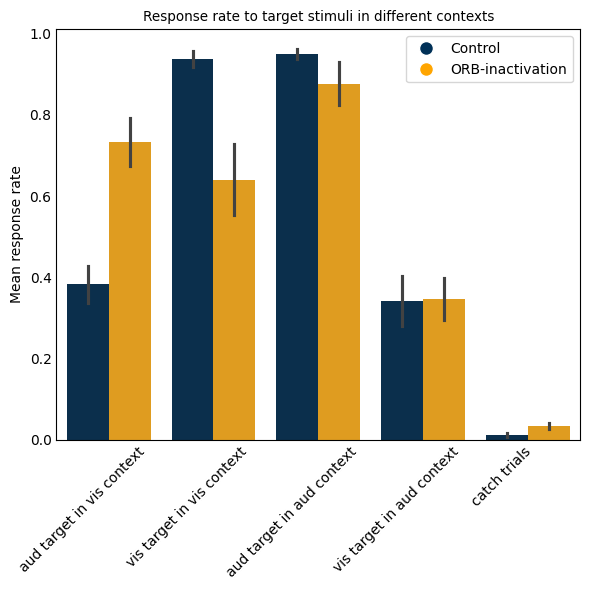

In [11]:
import seaborn as sns

muscimol_df_orb['session_id'] = muscimol_df_orb['session_id'].astype(str)

avg_values = {
    'Condition': ['Control', 'Perturbation'],

    # 'both targets': [
    # muscimol_df[muscimol_df['control']]['both_targets'].mean(),
    # muscimol_df[muscimol_df['perturbation']]['both_targets'].mean()
    # ],
    # 'auditory target':[
    #     muscimol_df[muscimol_df['control']]['auditory_target'].mean(),
    #     muscimol_df[muscimol_df['perturbation']]['auditory_target'].mean()
    # ],
    # 'visual target':[
    #     muscimol_df[muscimol_df['control']]['visual_target'].mean(),
    #     muscimol_df[muscimol_df['perturbation']]['visual_target'].mean()
    # ],
     'aud target in vis context':[
        muscimol_df_orb[muscimol_df_orb['control']]['auditory_target_in_visual_context'].values,
        muscimol_df_orb[muscimol_df_orb['perturbation']]['auditory_target_in_visual_context'].values
    ],
     'vis target in vis context':[
        muscimol_df_orb[muscimol_df_orb['control']]['visual_target_in_visual_context'].values,
        muscimol_df_orb[muscimol_df_orb['perturbation']]['visual_target_in_visual_context'].values
    ],
     'aud target in aud context':[
        muscimol_df_orb[muscimol_df_orb['control']]['auditory_target_in_auditory_context'].values,
        muscimol_df_orb[muscimol_df_orb['perturbation']]['auditory_target_in_auditory_context'].values
    ],
     'vis target in aud context':[
        muscimol_df_orb[muscimol_df_orb['control']]['visual_target_in_auditory_context'].values,
        muscimol_df_orb[muscimol_df_orb['perturbation']]['visual_target_in_auditory_context'].values
    ],

    'catch trials' :[
        muscimol_df_orb[muscimol_df_orb['control']]['catch_trials'].values,
        muscimol_df_orb[muscimol_df_orb['perturbation']]['catch_trials'].values
    ]

}

# Create a DataFrame from the dictionary
avg_values_df = pd.DataFrame(avg_values)

avg_values_melted = avg_values_df.melt(id_vars='Condition', var_name='Category', value_name='Mean Value')

# Plotting the bar plot
plt.figure(figsize=(6, 6))
ax = sns.barplot(x='Category', y='Mean Value', hue='Condition', errorbar='se',
                 data=avg_values_melted.explode('Mean Value'), palette=['#003057', '#FFA500'])

plt.xlabel('')
plt.xticks(rotation = 45)
current_ticks = ax.get_xticks()
new_ticks = [tick - 0.25 for tick in current_ticks] # Adjust the value as needed
ax.set_xticks(new_ticks)

ax.tick_params(axis='both', which='both', length=0)


plt.ylabel('Mean response rate', fontsize = 10)
plt.title('Response rate to target stimuli in different contexts', fontsize = 9.75)
# plt.legend(loc='upper right')
# plt.legend(['Control', 'ORB-lesion'])
# plt.show()
plt.tight_layout()

handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='#003057', markersize=10),
        plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='#FFA500', markersize=10)]
labels = ['Control', 'ORB-inactivation']
plt.legend(handles, labels, loc='upper right')
            # bbox_to_anchor=(1, 1))

plt.tight_layout()

# plt.savefig(r"C:\Users\vayle.lafehr\Desktop\perturbation_analysis_figures\mean_response_rate_targets.png", dpi=300)

plt.show()
# for condition in ['Control', 'Perturbation']:
#     for category in avg_values.keys():
#         if category != 'Condition':
#             x_coords = avg_values_melted[(avg_values_melted['Condition'] == condition) & (avg_values_melted['Category'] == category)].index[0]
#             y_coords = muscimol_df_orb.loc[muscimol_df_orb[condition.lower()], category.lower().replace(' ', '_').replace('-', '_')].values
#             plt.scatter([x_coords + (0.2 if condition == 'Perturbation' else -0.2)]*len(y_coords), y_coords, color='black', alpha=0.5)


# new_labels = ['all target stimuli', 'auditory target', 'visual target', 'auditory target in visual context', 'visual target in visual context', 'auditory target in auditory context','visual target in auditory context', 'catch trials' ]
# # ax.set_xticklabels(new_labels, fontsize = 12, rotation=35,)



# # Show the plot
# plt.tight_layout()
# plt.show()



C:\Users\vayle.lafehr\AppData\Local\Temp\ipykernel_28244\1818140789.py:62: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', len(unique_mice))


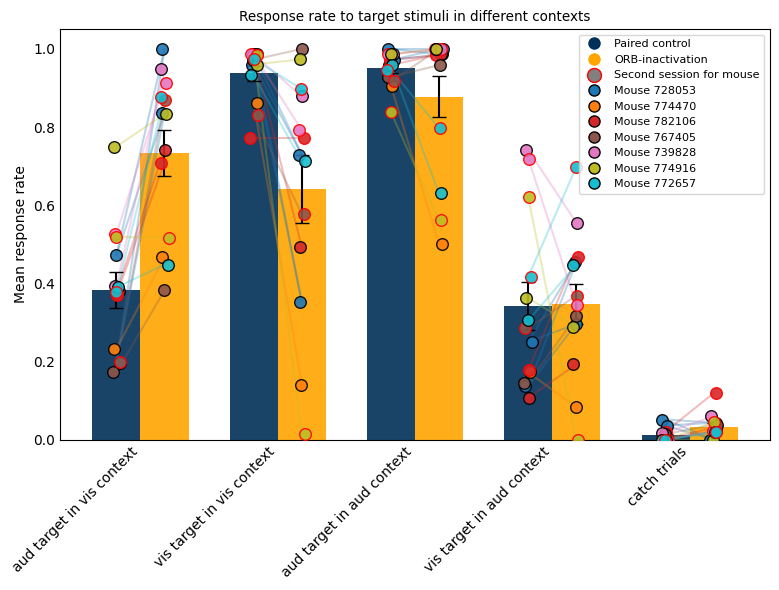

In [13]:
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
from datetime import timedelta

# Extract mouse ID function
def extract_mouse_id(x):
    s = str(x)
    match = re.search(r"\('(\d+)_", s)
    if match:
        return match.group(1)
    if '_' in s:
        return s.split('_')[0].split('(')[-1].strip("'")
    return s

# Extract date function
def extract_date_from_session(session_id):
    s = str(session_id)
    match = re.search(r'(\d{4}-\d{2}-\d{2})', s)
    if match:
        try:
            return pd.to_datetime(match.group(1))
        except ValueError:
            pass
    return None

# Add mouse ID and date to muscimol_df_orbm
muscimol_df_orb['mouse_id'] = muscimol_df_orb['session_id'].apply(extract_mouse_id)
muscimol_df_orb['date'] = muscimol_df_orb['session_id'].apply(extract_date_from_session)

# Identify sessions with gaps > 4 days FROM THE FIRST SESSION
def has_large_gap_from_first(df, max_days=4):
    """Returns set of session_ids that come >max_days after the FIRST session for that mouse"""
    df_sorted = df.sort_values(['mouse_id', 'date']).reset_index(drop=True)
    sessions_after_gap = set()
    
    for mouse_id in df_sorted['mouse_id'].unique():
        mouse_sessions = df_sorted[df_sorted['mouse_id'] == mouse_id].copy()
        
        if len(mouse_sessions) > 0:
            # Get the FIRST session date for this mouse
            first_date = mouse_sessions.iloc[0]['date']
            
            # Check all subsequent sessions against the FIRST date
            for i in range(1, len(mouse_sessions)):
                current_date = mouse_sessions.iloc[i]['date']
                days_from_first = abs((current_date - first_date).days)
                
                if days_from_first > max_days:
                    session_id = str(mouse_sessions.iloc[i]['session_id'])
                    sessions_after_gap.add(session_id)
    
    return sessions_after_gap

# Get sessions with gaps from first session
gap_sessions = has_large_gap_from_first(muscimol_df_orb, max_days=4)

# Create color map for mouse IDs
unique_mice = muscimol_df_orb['mouse_id'].unique()
colors = plt.cm.get_cmap('tab10', len(unique_mice))
mouse_color_map = {mouse: colors(i) for i, mouse in enumerate(unique_mice)}

# Separate control and perturbation data
control_data = muscimol_df_orb[muscimol_df_orb['control']].copy()
perturb_data = muscimol_df_orb[muscimol_df_orb['perturbation']].copy()

# Define categories
categories = ['aud target in vis context', 'vis target in vis context', 
              'aud target in aud context', 'vis target in aud context', 'catch trials']
columns = ['auditory_target_in_visual_context', 'visual_target_in_visual_context',
           'auditory_target_in_auditory_context', 'visual_target_in_auditory_context', 'catch_trials']

# Create figure
fig, ax = plt.subplots(figsize=(8, 6))

# Calculate means and SEMs for each category
x_positions = np.arange(len(categories))
bar_width = 0.35

control_means = [control_data[col].mean() for col in columns]
control_sems = [control_data[col].sem() for col in columns]
perturb_means = [perturb_data[col].mean() for col in columns]
perturb_sems = [perturb_data[col].sem() for col in columns]

# Plot bars
ax.bar(x_positions - bar_width/2, control_means, bar_width, 
       yerr=control_sems, color='#003057', label='Control', capsize=5, alpha=0.9)
ax.bar(x_positions + bar_width/2, perturb_means, bar_width,
       yerr=perturb_sems, color='#FFA500', label='Perturbation', capsize=5, alpha=0.9)

# Draw lines connecting paired points (same mouse, within 3 days)
for i, col in enumerate(columns):
    for _, control_row in control_data.iterrows():
        mouse_id = control_row['mouse_id']
        control_date = control_row['date']
        control_val = control_row[col]
        
        # Find matching perturbation sessions for this mouse within 3 days
        matching_perturb = perturb_data[
            (perturb_data['mouse_id'] == mouse_id) &
            (abs((perturb_data['date'] - control_date).dt.days) <= 3)
        ]
        
        for _, perturb_row in matching_perturb.iterrows():
            perturb_val = perturb_row[col]
            # Draw line
            ax.plot([i - bar_width/2, i + bar_width/2], 
                   [control_val, perturb_val],
                   color=mouse_color_map[mouse_id], 
                   alpha=0.3, linewidth=1.5, zorder=1)

# Add individual data points with JITTER and RED BORDER for gap sessions
jitter_amount = 0.03  # Adjust this value to control spacing

for i, col in enumerate(columns):
    # Control points with jitter
    for idx, row in control_data.iterrows():
        jitter = np.random.uniform(-jitter_amount, jitter_amount)
        session_str = str(row['session_id'])
        has_gap = session_str in gap_sessions
        
        ax.scatter(i - bar_width/2 + jitter, row[col], 
                  color=mouse_color_map[row['mouse_id']], 
                  edgecolors='red' if has_gap else 'black',
                  s=70, alpha=0.9, 
                  linewidth=1 if has_gap else 1, 
                  zorder=3)
    
    # Perturbation points with jitter
    for idx, row in perturb_data.iterrows():
        jitter = np.random.uniform(-jitter_amount, jitter_amount)
        session_str = str(row['session_id'])
        has_gap = session_str in gap_sessions
        
        ax.scatter(i + bar_width/2 + jitter, row[col],
                  color=mouse_color_map[row['mouse_id']],
                  edgecolors='red' if has_gap else 'black',
                  s=70, alpha=0.9, 
                  linewidth=1 if has_gap else 1,
                  zorder=3)

# Formatting
ax.set_xticks(x_positions)
ax.set_xticklabels(categories, rotation=45, ha='right')
ax.tick_params(axis='both', which='both', length=0)
ax.set_ylabel('Mean response rate', fontsize=10)
ax.set_title('Response rate to target stimuli in different contexts', fontsize=9.75)

# Create ALL legend handles in one list
condition_handles = [
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='#003057', markersize=10, label='Paired control'),
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='#FFA500', markersize=10, label='ORB-inactivation')
]

gap_handle = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='gray',
                        markeredgecolor='red', markersize=10, linewidth=2.5, 
                        label='Second session for mouse')]

mouse_handles = [
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=mouse_color_map[mouse], 
               markeredgecolor='black', markersize=8, linewidth=1, label=f'Mouse {mouse}')
    for mouse in unique_mice
]

# Combine ALL handles into ONE legend
all_handles = condition_handles + gap_handle + mouse_handles
ax.legend(handles=all_handles, loc='upper right', frameon=True, fontsize=8)

plt.tight_layout()
plt.show()

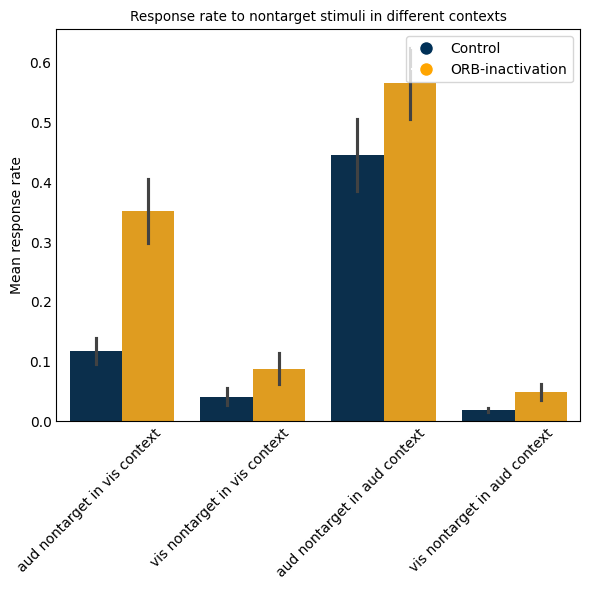

In [155]:
import seaborn as sns

muscimol_df_orb['session_id'] = muscimol_df_orb['session_id'].astype(str)

avg_values = {
    'Condition': ['Control', 'Perturbation'],

    # 'both targets': [
    # muscimol_df[muscimol_df['control']]['both_targets'].mean(),
    # muscimol_df[muscimol_df['perturbation']]['both_targets'].mean()
    # ],
    # 'auditory target':[
    #     muscimol_df[muscimol_df['control']]['auditory_target'].mean(),
    #     muscimol_df[muscimol_df['perturbation']]['auditory_target'].mean()
    # ],
    # 'visual target':[
    #     muscimol_df[muscimol_df['control']]['visual_target'].mean(),
    #     muscimol_df[muscimol_df['perturbation']]['visual_target'].mean()
    # ],
     'aud nontarget in vis context':[
        muscimol_df_orb[muscimol_df_orb['control']]['aud_nontarget_vis_context_responses'].values,
        muscimol_df_orb[muscimol_df_orb['perturbation']]['aud_nontarget_vis_context_responses'].values
    ],
     'vis nontarget in vis context':[
        muscimol_df_orb[muscimol_df_orb['control']]['vis_nontarget_vis_context_responses'].values,
        muscimol_df_orb[muscimol_df_orb['perturbation']]['vis_nontarget_vis_context_responses'].values
    ],
     'aud nontarget in aud context':[
        muscimol_df_orb[muscimol_df_orb['control']]['aud_nontarget_aud_context_responses'].values,
        muscimol_df_orb[muscimol_df_orb['perturbation']]['aud_nontarget_aud_context_responses'].values
    ],
     'vis nontarget in aud context':[
        muscimol_df_orb[muscimol_df_orb['control']]['vis_nontarget_aud_context_responses'].values,
        muscimol_df_orb[muscimol_df_orb['perturbation']]['vis_nontarget_aud_context_responses'].values
    ],

    # 'catch trials' :[
    #     muscimol_df_orb[muscimol_df_orb['control']]['catch_trials'].values,
    #     muscimol_df_orb[muscimol_df_orb['perturbation']]['catch_trials'].values
    # ]

}

# Create a DataFrame from the dictionary
avg_values_df = pd.DataFrame(avg_values)

avg_values_melted = avg_values_df.melt(id_vars='Condition', var_name='Category', value_name='Mean Value')

# Plotting the bar plot
plt.figure(figsize=(6, 6))
ax = sns.barplot(x='Category', y='Mean Value', hue='Condition', errorbar='se',
                 data=avg_values_melted.explode('Mean Value'), palette=['#003057', '#FFA500'])

plt.xlabel('')
plt.xticks(rotation = 45)
current_ticks = ax.get_xticks()
new_ticks = [tick - 0.25 for tick in current_ticks] # Adjust the value as needed
ax.set_xticks(new_ticks)

ax.tick_params(axis='both', which='both', length=0)


plt.ylabel('Mean response rate', fontsize = 10)
plt.title('Response rate to nontarget stimuli in different contexts', fontsize = 9.75)
# plt.legend(loc='upper right')
# plt.legend(['Control', 'ORB-lesion'])
# plt.show()
plt.tight_layout()

handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='#003057', markersize=10),
        plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='#FFA500', markersize=10)]
labels = ['Control', 'ORB-inactivation']
plt.legend(handles, labels, loc='upper right')
            # bbox_to_anchor=(1, 1))

plt.tight_layout()

plt.savefig(r"C:\Users\vayle.lafehr\Desktop\perturbation_analysis_figures\mean_response_rate_NONtargets.png", dpi=300)

plt.show()

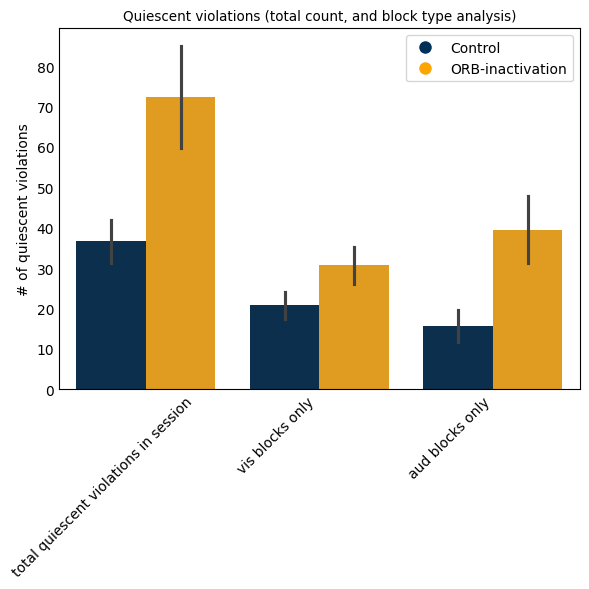

In [156]:
import seaborn as sns

muscimol_df_orb['session_id'] = muscimol_df_orb['session_id'].astype(str)

avg_values = {
    'Condition': ['Control', 'Perturbation'],

    # 'both targets': [
    # muscimol_df[muscimol_df['control']]['both_targets'].mean(),
    # muscimol_df[muscimol_df['perturbation']]['both_targets'].mean()
    # ],
    # 'auditory target':[
    #     muscimol_df[muscimol_df['control']]['auditory_target'].mean(),
    #     muscimol_df[muscimol_df['perturbation']]['auditory_target'].mean()
    # ],
    # 'visual target':[
    #     muscimol_df[muscimol_df['control']]['visual_target'].mean(),
    #     muscimol_df[muscimol_df['perturbation']]['visual_target'].mean()
    # ],
     'total quiescent violations in session':[
        muscimol_df_orb[muscimol_df_orb['control']]['quiescent_violations'].values,
        muscimol_df_orb[muscimol_df_orb['perturbation']]['quiescent_violations'].values
    ],
     'vis blocks only':[
        muscimol_df_orb[muscimol_df_orb['control']]['total_vis_quiescent_violations'].values,
        muscimol_df_orb[muscimol_df_orb['perturbation']]['total_vis_quiescent_violations'].values
    ],
     'aud blocks only':[
        muscimol_df_orb[muscimol_df_orb['control']]['total_aud_quiescent_violations'].values,
        muscimol_df_orb[muscimol_df_orb['perturbation']]['total_aud_quiescent_violations'].values
    ],
    #  'vis target in aud context':[
    #     muscimol_df_orb[muscimol_df_orb['control']]['visual_target_in_auditory_context'].values,
    #     muscimol_df_orb[muscimol_df_orb['perturbation']]['visual_target_in_auditory_context'].values
    # ],

    # 'catch trials' :[
    #     muscimol_df_orb[muscimol_df_orb['control']]['catch_trials'].values,
    #     muscimol_df_orb[muscimol_df_orb['perturbation']]['catch_trials'].values
    # ]

}

# Create a DataFrame from the dictionary
avg_values_df = pd.DataFrame(avg_values)

avg_values_melted = avg_values_df.melt(id_vars='Condition', var_name='Category', value_name='Mean Value')

# Plotting the bar plot
plt.figure(figsize=(6, 6))
ax = sns.barplot(x='Category', y='Mean Value', hue='Condition', errorbar='se',
                 data=avg_values_melted.explode('Mean Value'), palette=['#003057', '#FFA500'])

plt.xlabel('')
plt.xticks(rotation = 45)
current_ticks = ax.get_xticks()
new_ticks = [tick - 0.25 for tick in current_ticks] # Adjust the value as needed
ax.set_xticks(new_ticks)

ax.tick_params(axis='both', which='both', length=0)


plt.ylabel('# of quiescent violations', fontsize = 10)
plt.title('Quiescent violations (total count, and block type analysis)', fontsize = 9.75)
# plt.legend(loc='upper right')
# plt.legend(['Control', 'ORB-lesion'])
# plt.show()
plt.tight_layout()

handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='#003057', markersize=10),
        plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='#FFA500', markersize=10)]
labels = ['Control', 'ORB-inactivation']
plt.legend(handles, labels, loc='upper right')
            # bbox_to_anchor=(1, 1))

plt.tight_layout()

# plt.savefig(r"C:\Users\vayle.lafehr\Desktop\perturbation_analysis_figures\mean_response_rate_targets.png", dpi=300)

plt.show()
# for condition in ['Control', 'Perturbation']:
#     for category in avg_values.keys():
#         if category != 'Condition':
#             x_coords = avg_values_melted[(avg_values_melted['Condition'] == condition) & (avg_values_melted['Category'] == category)].index[0]
#             y_coords = muscimol_df_orb.loc[muscimol_df_orb[condition.lower()], category.lower().replace(' ', '_').replace('-', '_')].values
#             plt.scatter([x_coords + (0.2 if condition == 'Perturbation' else -0.2)]*len(y_coords), y_coords, color='black', alpha=0.5)


# new_labels = ['all target stimuli', 'auditory target', 'visual target', 'auditory target in visual context', 'visual target in visual context', 'auditory target in auditory context','visual target in auditory context', 'catch trials' ]
# # ax.set_xticklabels(new_labels, fontsize = 12, rotation=35,)



# # Show the plot
# plt.tight_layout()
# plt.show()



In [148]:
def extract_base_id(session_id):
    return "_".join(session_id.split("_")[:-1])

In [50]:
# Calculate IQR bounds
Q1 = muscimol_df_orb['quiescent_violations'].quantile(0.25)
Q3 = muscimol_df_orb['quiescent_violations'].quantile(0.75)
IQR = Q3 - Q1

# Define bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filter out outliers
muscimol_df_orb_filtered = muscimol_df_orb[
    (muscimol_df_orb['quiescent_violations'] >= lower_bound) &
    (muscimol_df_orb['quiescent_violations'] <= upper_bound)
]

In [45]:
control_df_clean = remove_outliers_iqr(control_df, 'quiescent_violations')
perturb_df_clean = remove_outliers_iqr(perturb_df, 'quiescent_violations')


In [51]:
muscimol_df_orb_filtered = muscimol_df_orb[muscimol_df_orb['quiescent_violations'] != 209]

print(muscimol_df_orb_filtered)

                                    session_id  control  perturbation  \
0   DynamicRoutingSession('728053_2024-11-18')     True         False   
1   DynamicRoutingSession('728053_2024-11-19')    False          True   
2   DynamicRoutingSession('728053_2024-11-20')     True         False   
3   DynamicRoutingSession('728053_2024-11-21')    False          True   
4   DynamicRoutingSession('774470_2025-07-29')     True         False   
5   DynamicRoutingSession('774470_2025-07-30')    False          True   
6   DynamicRoutingSession('782106_2025-07-07')     True         False   
7   DynamicRoutingSession('782106_2025-07-14')     True         False   
8   DynamicRoutingSession('782106_2025-07-08')    False          True   
10  DynamicRoutingSession('767405_2025-05-19')     True         False   
11  DynamicRoutingSession('767405_2025-05-20')    False          True   
12  DynamicRoutingSession('767405_2025-05-28')     True         False   
13  DynamicRoutingSession('767405_2025-05-29')    F

In [52]:
print(muscimol_df_orb[muscimol_df_orb['quiescent_violations'] == 209])

                                   session_id  control  perturbation  \
9  DynamicRoutingSession('782106_2025-07-15')    False          True   

   vis_nontarget_vis_context_responses  aud_nontarget_vis_context_responses  \
9                             0.333333                             0.254902   

   vis_nontarget_aud_context_responses  aud_nontarget_aud_context_responses  \
9                             0.163265                             0.612245   

   auditory_target_in_visual_context  visual_target_in_auditory_context  \
9                           0.709091                           0.468085   

   visual_target_in_visual_context  auditory_target_in_auditory_context  \
9                         0.771429                             0.984127   

   catch_trials  quiescent_violations  total_vis_quiescent_violations  \
9      0.119048                   209                              73   

   total_aud_quiescent_violations  vis_quiescent_violations  \
9                        

In [53]:
muscimol_df_orb_filtered['base_id'] = muscimol_df_orb_filtered['session_id'].apply(extract_base_id)
muscimol_df_orb_filtered['day'] = muscimol_df_orb_filtered['session_id'].apply(lambda x: x.split("_")[-1])

# Separate control and perturbation
control_df = muscimol_df_orb_filtered[muscimol_df_orb_filtered['control']]
perturb_df = muscimol_df_orb_filtered[muscimol_df_orb_filtered['perturbation']]

# Merge on base_id
paired_df = pd.merge(control_df, perturb_df, on='base_id', suffixes=('_control', '_perturb'))

# Filter where control day < perturbation day
paired_df = paired_df[paired_df['day_control'] < paired_df['day_perturb']]

C:\Users\vayle.lafehr\AppData\Local\Temp\ipykernel_32080\3251027125.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  muscimol_df_orb_filtered['base_id'] = muscimol_df_orb_filtered['session_id'].apply(extract_base_id)
C:\Users\vayle.lafehr\AppData\Local\Temp\ipykernel_32080\3251027125.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  muscimol_df_orb_filtered['day'] = muscimol_df_orb_filtered['session_id'].apply(lambda x: x.split("_")[-1])


## ORB quiescent violations

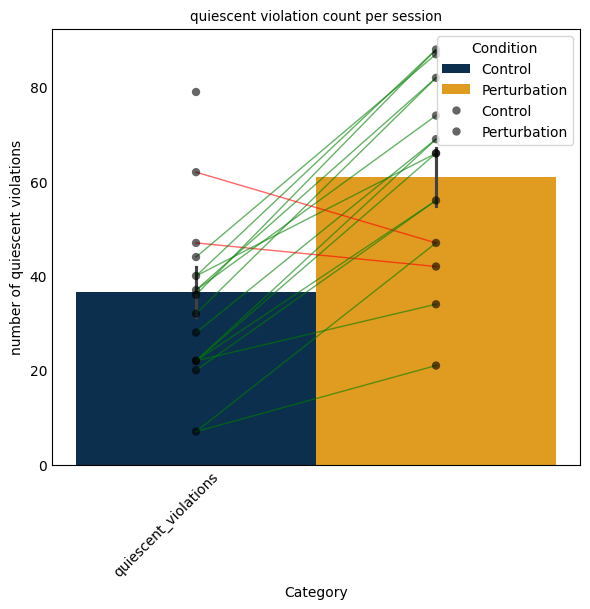

In [149]:
import seaborn as sns

muscimol_df_orb_filtered['session_id'] = muscimol_df_orb_filtered['session_id'].astype(str)

# avg_values = {
#     'Condition': ['Control', 'Perturbation'],

#     'quiescent_violations' :[
#         muscimol_df_orb_filtered[muscimol_df_orb_filtered['control']]['quiescent_violations'].values,
#         muscimol_df_orb_filtered[muscimol_df_orb_filtered['perturbation']]['quiescent_violations'].values,
#     ]
# }
avg_values_clean = {
    'Condition': ['Control', 'Perturbation'],
    'quiescent_violations': [
        muscimol_df_orb_filtered.loc[muscimol_df_orb_filtered['control'], 'quiescent_violations'].tolist(),
        muscimol_df_orb_filtered.loc[muscimol_df_orb_filtered['perturbation'], 'quiescent_violations'].tolist()
    ]
}


# Create a DataFrame from the dictionary
avg_values_df = pd.DataFrame(avg_values_clean)

avg_values_melted = avg_values_df.melt(id_vars='Condition', var_name='Category', value_name='Mean Value')

# Plotting the bar plot
plt.figure(figsize=(6, 6))
ax = sns.barplot(x='Category', y='Mean Value', hue='Condition', errorbar='se',
                 data=avg_values_melted.explode('Mean Value'), palette=['#003057', '#FFA500'])

plt.xlabel('')
plt.xticks(rotation = 45)
current_ticks = ax.get_xticks()
new_ticks = [tick - 0.25 for tick in current_ticks] # Adjust the value as needed
ax.set_xticks(new_ticks)

ax.tick_params(axis='both', which='both', length=0)


plt.ylabel('number of quiescent violations', fontsize = 10)
plt.title('quiescent violation count per session', fontsize = 9.75)
# plt.legend(loc='upper right')
# plt.legend(['Control', 'ORB-lesion'])
# plt.show()
plt.tight_layout()

handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='#003057', markersize=10),
        plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='#FFA500', markersize=10)]
labels = ['Control', 'ORB-inactivation']
plt.legend(handles, labels, loc='upper right')
            # bbox_to_anchor=(1, 1))

plt.tight_layout()

# plt.savefig(r"C:\Users\vayle.lafehr\Desktop\perturbation_analysis_figures\mean_response_rate_both_targets&contexts.png", dpi=300)

sns.stripplot(
    x='Category',
    y='Mean Value',
    hue='Condition',
    data=avg_values_melted.explode('Mean Value'),
    dodge=True,        # separates points by hue
    jitter=False,       # adds horizontal jitter for visibility
    alpha=0.6,         # transparency for overlapping points
    palette=["#000000", "#000000"],
    marker='o',
    size=6
)

for _, row in paired_df.iterrows():
    x_control = 0  # index of 'quiescent_violations' bar
    x_perturb = 0  # same bar, but dodge shifts it

    # Get dodge offset from Seaborn (usually ~0.2)
    dodge_offset = 0.2

    x1 = x_control - dodge_offset
    x2 = x_perturb + dodge_offset
    y1 = row['quiescent_violations_control']
    y2 = row['quiescent_violations_perturb']
  

    plt.plot([x1, x2], [y1, y2], color = 'green' if y2 > y1 else 'red'
, linestyle='-', linewidth=1, alpha=0.6)
    
plt.savefig(r"Z:\vayle\muscimol_ORB_behavior_plots\quiescent_violations", dpi=300)



# plt.show()


In [41]:
print(muscimol_data_orb['quiescent_violations'])

TypeError: list indices must be integers or slices, not str

## ORB: quiescent vios unity line scatter plot

C:\Users\vayle.lafehr\AppData\Local\Temp\ipykernel_32080\129277263.py:35: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', len(unique_groups))


(66, 22, '728053')
(69, 28, '728053')
(74, 37, '739828')
(82, 32, '739828')
(34, 22, '772657')
(56, 20, '772657')
(21, 7, '774916')
(47, 62, '774916')
(66, 40, '767405')
(88, 36, '767405')
(87, 44, '782106')
(209, 79, '782106')
(42, 47, '774470')


<Figure size 2000x2000 with 0 Axes>

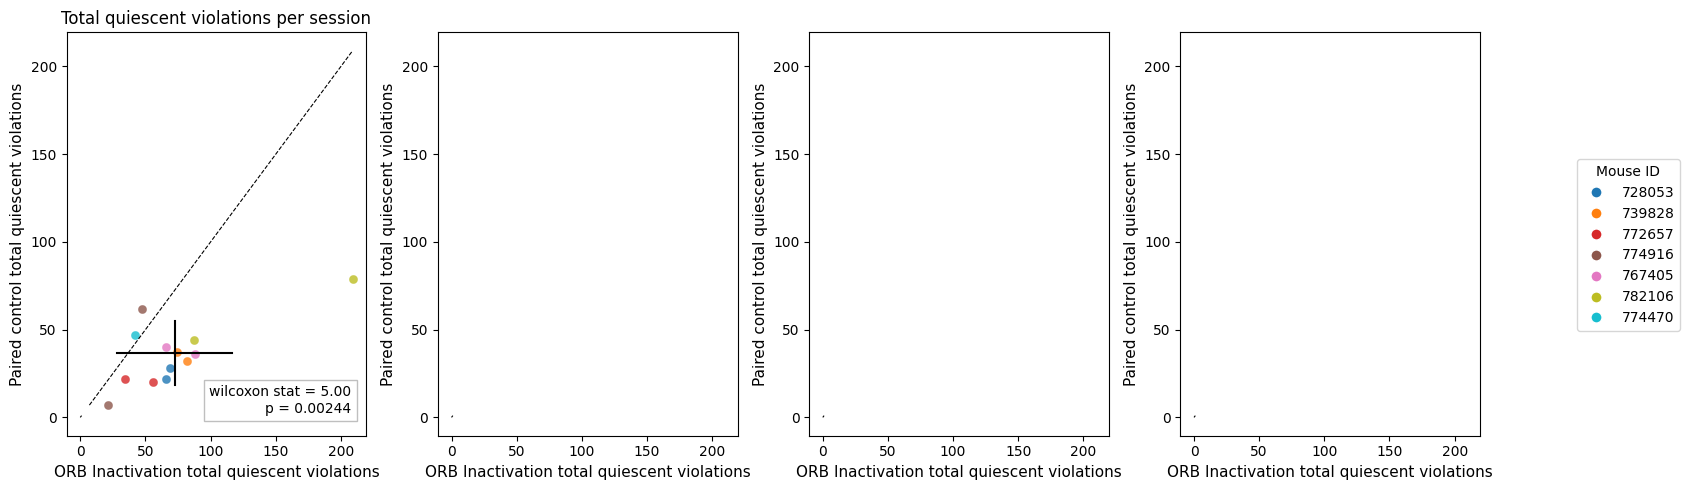

In [165]:
import matplotlib.pyplot as plt
from datetime import datetime
from scipy import stats

result = dict(
    session_id=str(session.session_id) if hasattr(session, 'session_id') else str(session),
    # ...other fields...
)

#clean
import re

def extract_mouse_id(x):
    # Always convert to string
    s = str(x)
    # Try to extract the mouse ID using regex
    match = re.search(r"\('(\d+)_", s)
    if match:
        return match.group(1)
    # fallback: try splitting
    if '_' in s:
        return s.split('_')[0].split('(')[-1].strip("'")
    return s

muscimol_df_orb['color_group'] = muscimol_df_orb['session_id'].apply(extract_mouse_id)

# # Sort by date
muscimol_df_orb['date'] = muscimol_df_orb['session_id'].apply(
    lambda x: datetime.strptime(str(x).split('_')[1].split("'")[0], '%Y-%m-%d')
)
muscimol_df_orb = muscimol_df_orb.sort_values(by='date').reset_index(drop=True)

# unique colors bymouse ID
unique_groups = muscimol_df_orb['color_group'].unique()
colors = plt.cm.get_cmap('tab10', len(unique_groups))
color_map = {group: colors(i) for i, group in enumerate(unique_groups)}

# Pair control and perturbation sessions
paired_data_qv = []
for i in range(1, len(muscimol_df_orb), 2):
    row1 = muscimol_df_orb.loc[i - 1]
    row2 = muscimol_df_orb.loc[i]
    if row1['control']:
        control_val = row1['quiescent_violations']
        perturb_val = row2['quiescent_violations']
        color_group = row1['color_group']
    else:
        control_val = row2['quiescent_violations']
        perturb_val = row1['quiescent_violations']
        color_group = row2['color_group']
    paired_data_qv.append((perturb_val, control_val, color_group))
    


# Create scatter plot with x = perturbation, y = control
plt.figure(figsize=(20, 20))

# data = [paired_data_vis_vis, paired_data_aud_vis]
# for datum in data:
#     for x, y, group in datum:
#         print((x,y,group))
#         plt.scatter(x, y, color=color_map[group], label=group, alpha=0.8, linewidth = 0.2)
#         plt.scatter(x, y, color=color_map[group], label=group, alpha=0.8)

fig, axes = plt.subplots(1, 4, figsize=(15, 5), sharex=True, sharey=True)

contexts = ['Total quiescent violations per session']
data = [paired_data_qv]

#make test star for plot

    
#organize paired data

paired_data_sets ={
    'quiescent_violations': paired_data_qv
}
    

#mean cross


for ax, (label, paired_data) in zip(axes, paired_data_sets.items()):
    x_vals = [x for x, _, _ in paired_data]
    y_vals = [y for _, y, _ in paired_data]
    # print(f"{label} - x_vals: {x_vals}, y_vals: {y_vals}")
    
    x_mean, y_mean = np.mean(x_vals), np.mean(y_vals)
    x_std, y_std = np.std(x_vals), np.std(y_vals)
    ax.plot([x_mean - x_std, x_mean +x_std], [y_mean, y_mean], color='black', lw=1.5)
    ax.plot([x_mean, x_mean], [y_mean - y_std, y_mean + y_std], color='black', lw=1.5)


    for ax, datum, title in zip(axes, data, contexts):
        for x, y, group in datum:
            print((x, y, group))
            ax.scatter(x, y, color=color_map[group], alpha=0.8, linewidth=0.2)





# for ax in axes:
    # ax.errorbar(np.mean(x_vals), np.mean(y_vals), xerr=x_std, yerr=y_std, fmt='o', color='black', markersize=5, label='Mean ± Std Dev', alpha=0.5)
# unity line

for ax in axes:
    ax.plot([0, 1], [0, 1], 'k--', linewidth=0.8)  # Unity line for each subplot
# plt.plot([0, 1], [0, 1], 'k--')


# ax.set_xlim(0, 1)
# ax.set_ylim(0, 1)
#adds space to plot size
# x_vals = [x for x, _, _ in paired_data]
# y_vals = [y for _, y, _ in paired_data]

# x_min, x_max = min(x_vals), max(x_vals)
# y_min, y_max = min(y_vals), max(y_vals)

# padding_x = (x_max - x_min) * 0.05  # 5% padding
# padding_y = (y_max - y_min) * 0.05

# ax.set_xlim(x_min - padding_x, x_max + padding_x)
# ax.set_ylim(y_min - padding_y, y_max + padding_y)


for ax, x_label in zip(axes, 'ORB Inactivation total quiescent violations'):
    ax.set_xlabel('ORB Inactivation total quiescent violations', fontsize =11)


for ax, y_label in zip(axes, 'Paired control total quiescent violations'):
    ax.set_ylabel('Paired control total quiescent violations', fontsize=11)
# ax.set_title(f'{c for c in contexts}', fontsize=12)

for ax, title in zip(axes, contexts):
    ax.set_title(f'{title}', fontsize=12)

for ax in axes:
    ax.yaxis.set_tick_params(labelleft=True)
# ax.grid(True)
# ...existing code...
for ax, (label, paired_data) in zip(axes, paired_data_sets.items()):
    x_vals = [x for x, _, _ in paired_data]
    y_vals = [y for _, y, _ in paired_data]
    min_val = min(x_vals + y_vals)
    max_val = max(x_vals + y_vals)
    ax.plot([min_val, max_val], [min_val, max_val], 'k--', linewidth=0.8)  # Unity line
# ...existing code...
    # Run paired t-test
    # ...existing code...
   # ...existing code...
from scipy.stats import wilcoxon

wilcoxon_stat, p_val = wilcoxon(x_vals, y_vals)
ax.text(0.95, 0.05, f'wilcoxon stat = {wilcoxon_stat:.2f}\np = {p_val:.3g}',
        transform=ax.transAxes, fontsize=10,
        verticalalignment='bottom', horizontalalignment='right',
        bbox=dict(facecolor='white', alpha=0.5, edgecolor='gray'))
# ...existing code...

# Create legend with unique mouse IDs
# handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=color_map[group], markersize=8) for group in unique_groups]
# plt.legend(handles, unique_groups, title="Mouse ID", bbox_to_anchor=(1.05, 1), loc='upper left')

handles = [plt.Line2D([0], [0], marker='o', color='w',
                      markerfacecolor=color_map[group], markersize=8)
           for group in unique_groups]
fig.legend(handles, unique_groups, title="Mouse ID",
           bbox_to_anchor=(1.05, 0.5), loc='center left')

plt.tight_layout()


plt.savefig(r"Z:\vayle\muscimol_ORB_behavior_plots\ORB_quiescent_violations_population_effects_unity_line_scatter_plot", dpi=300)
plt.show()

(45, 18, '728053')
(33, 18, '728053')
(23, 21, '739828')
(40, 22, '739828')
(25, 12, '772657')
(23, 5, '772657')
(8, 4, '774916')
(17, 47, '774916')
(24, 37, '767405')
(35, 28, '767405')
(36, 22, '782106')
(73, 22, '782106')
(17, 14, '774470')


C:\Users\vayle.lafehr\AppData\Local\Temp\ipykernel_32080\2255993552.py:35: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', len(unique_groups))


<Figure size 2000x2000 with 0 Axes>

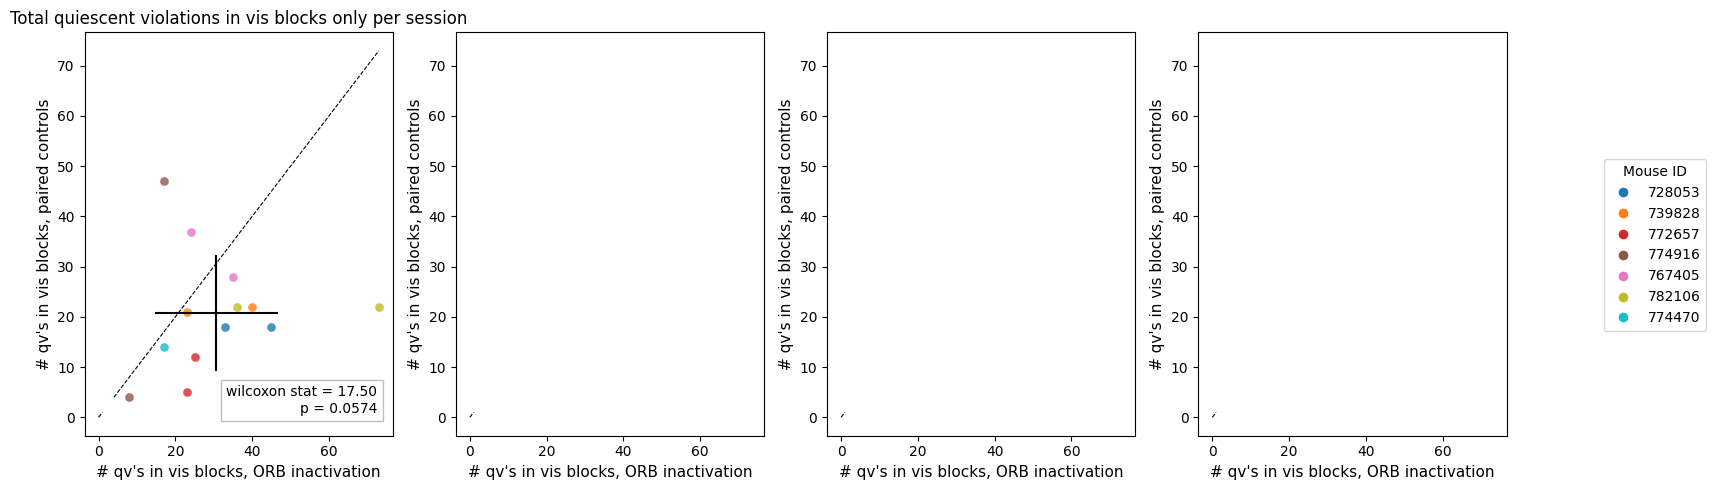

In [166]:
import matplotlib.pyplot as plt
from datetime import datetime
from scipy import stats

result = dict(
    session_id=str(session.session_id) if hasattr(session, 'session_id') else str(session),
    # ...other fields...
)

#clean
import re

def extract_mouse_id(x):
    # Always convert to string
    s = str(x)
    # Try to extract the mouse ID using regex
    match = re.search(r"\('(\d+)_", s)
    if match:
        return match.group(1)
    # fallback: try splitting
    if '_' in s:
        return s.split('_')[0].split('(')[-1].strip("'")
    return s

muscimol_df_orb['color_group'] = muscimol_df_orb['session_id'].apply(extract_mouse_id)

# # Sort by date
muscimol_df_orb['date'] = muscimol_df_orb['session_id'].apply(
    lambda x: datetime.strptime(str(x).split('_')[1].split("'")[0], '%Y-%m-%d')
)
muscimol_df_orb = muscimol_df_orb.sort_values(by='date').reset_index(drop=True)

# unique colors bymouse ID
unique_groups = muscimol_df_orb['color_group'].unique()
colors = plt.cm.get_cmap('tab10', len(unique_groups))
color_map = {group: colors(i) for i, group in enumerate(unique_groups)}

# Pair control and perturbation sessions
paired_data_qv = []
for i in range(1, len(muscimol_df_orb), 2):
    row1 = muscimol_df_orb.loc[i - 1]
    row2 = muscimol_df_orb.loc[i]
    if row1['control']:
        control_val = row1['total_vis_quiescent_violations']
        perturb_val = row2['total_vis_quiescent_violations']
        color_group = row1['color_group']
    else:
        control_val = row2['total_vis_quiescent_violations']
        perturb_val = row1['total_vis_quiescent_violations']
        color_group = row2['color_group']
    paired_data_qv.append((perturb_val, control_val, color_group))
    


# Create scatter plot with x = perturbation, y = control
plt.figure(figsize=(20, 20))

# data = [paired_data_vis_vis, paired_data_aud_vis]
# for datum in data:
#     for x, y, group in datum:
#         print((x,y,group))
#         plt.scatter(x, y, color=color_map[group], label=group, alpha=0.8, linewidth = 0.2)
#         plt.scatter(x, y, color=color_map[group], label=group, alpha=0.8)

fig, axes = plt.subplots(1, 4, figsize=(15, 5), sharex=True, sharey=True)

contexts = ['Total quiescent violations in vis blocks only per session']
data = [paired_data_qv]

#make test star for plot

    
#organize paired data

paired_data_sets ={
    'total_vis_quiescent_violations': paired_data_qv
}
    

#mean cross


for ax, (label, paired_data) in zip(axes, paired_data_sets.items()):
    x_vals = [x for x, _, _ in paired_data]
    y_vals = [y for _, y, _ in paired_data]
    # print(f"{label} - x_vals: {x_vals}, y_vals: {y_vals}")
    
    x_mean, y_mean = np.mean(x_vals), np.mean(y_vals)
    x_std, y_std = np.std(x_vals), np.std(y_vals)
    ax.plot([x_mean - x_std, x_mean +x_std], [y_mean, y_mean], color='black', lw=1.5)
    ax.plot([x_mean, x_mean], [y_mean - y_std, y_mean + y_std], color='black', lw=1.5)


    for ax, datum, title in zip(axes, data, contexts):
        for x, y, group in datum:
            print((x, y, group))
            ax.scatter(x, y, color=color_map[group], alpha=0.8, linewidth=0.2)





# for ax in axes:
    # ax.errorbar(np.mean(x_vals), np.mean(y_vals), xerr=x_std, yerr=y_std, fmt='o', color='black', markersize=5, label='Mean ± Std Dev', alpha=0.5)
# unity line

for ax in axes:
    ax.plot([0, 1], [0, 1], 'k--', linewidth=0.8)  # Unity line for each subplot
# plt.plot([0, 1], [0, 1], 'k--')


# ax.set_xlim(0, 1)
# ax.set_ylim(0, 1)
#adds space to plot size
# x_vals = [x for x, _, _ in paired_data]
# y_vals = [y for _, y, _ in paired_data]

# x_min, x_max = min(x_vals), max(x_vals)
# y_min, y_max = min(y_vals), max(y_vals)

# padding_x = (x_max - x_min) * 0.05  # 5% padding
# padding_y = (y_max - y_min) * 0.05

# ax.set_xlim(x_min - padding_x, x_max + padding_x)
# ax.set_ylim(y_min - padding_y, y_max + padding_y)


for ax, x_label in zip(axes, "# qv's in vis blocks, ORB inactivation"):
    ax.set_xlabel("# qv's in vis blocks, ORB inactivation", fontsize =11)


for ax, y_label in zip(axes, "# qv's in vis blocks, paired controls"):
    ax.set_ylabel("# qv's in vis blocks, paired controls", fontsize=11)
# ax.set_title(f'{c for c in contexts}', fontsize=12)

for ax, title in zip(axes, contexts):
    ax.set_title(f'{title}', fontsize=12)

for ax in axes:
    ax.yaxis.set_tick_params(labelleft=True)
# ax.grid(True)
# ...existing code...
for ax, (label, paired_data) in zip(axes, paired_data_sets.items()):
    x_vals = [x for x, _, _ in paired_data]
    y_vals = [y for _, y, _ in paired_data]
    min_val = min(x_vals + y_vals)
    max_val = max(x_vals + y_vals)
    ax.plot([min_val, max_val], [min_val, max_val], 'k--', linewidth=0.8)  # Unity line
# ...existing code...
    # Run paired t-test
    # ...existing code...
   # ...existing code...
from scipy.stats import wilcoxon

wilcoxon_stat, p_val = wilcoxon(x_vals, y_vals)
ax.text(0.95, 0.05, f'wilcoxon stat = {wilcoxon_stat:.2f}\np = {p_val:.3g}',
        transform=ax.transAxes, fontsize=10,
        verticalalignment='bottom', horizontalalignment='right',
        bbox=dict(facecolor='white', alpha=0.5, edgecolor='gray'))
# ...existing code...

# Create legend with unique mouse IDs
# handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=color_map[group], markersize=8) for group in unique_groups]
# plt.legend(handles, unique_groups, title="Mouse ID", bbox_to_anchor=(1.05, 1), loc='upper left')

handles = [plt.Line2D([0], [0], marker='o', color='w',
                      markerfacecolor=color_map[group], markersize=8)
           for group in unique_groups]
fig.legend(handles, unique_groups, title="Mouse ID",
           bbox_to_anchor=(1.05, 0.5), loc='center left')

plt.tight_layout()


# plt.savefig(r"Z:\vayle\muscimol_ORB_behavior_plots\ORB_population_effects_unity_line_scatter_plot", dpi=300)
plt.show()

(21, 4, '728053')
(27, 9, '728053')
(51, 12, '739828')
(42, 10, '739828')
(9, 10, '772657')
(31, 15, '772657')
(13, 2, '774916')
(30, 15, '774916')
(37, 3, '767405')
(49, 13, '767405')
(51, 22, '782106')
(129, 55, '782106')
(24, 33, '774470')


C:\Users\vayle.lafehr\AppData\Local\Temp\ipykernel_32080\1599901079.py:35: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', len(unique_groups))


<Figure size 2000x2000 with 0 Axes>

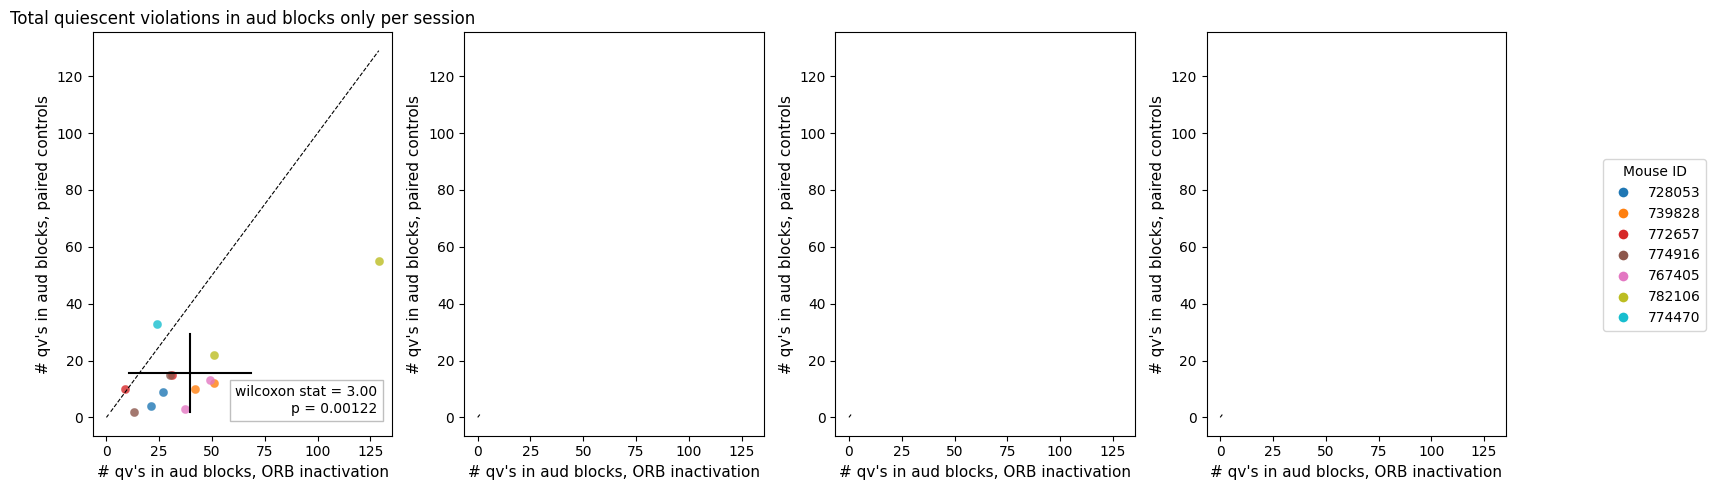

In [167]:
import matplotlib.pyplot as plt
from datetime import datetime
from scipy import stats

result = dict(
    session_id=str(session.session_id) if hasattr(session, 'session_id') else str(session),
    # ...other fields...
)

#clean
import re

def extract_mouse_id(x):
    # Always convert to string
    s = str(x)
    # Try to extract the mouse ID using regex
    match = re.search(r"\('(\d+)_", s)
    if match:
        return match.group(1)
    # fallback: try splitting
    if '_' in s:
        return s.split('_')[0].split('(')[-1].strip("'")
    return s

muscimol_df_orb['color_group'] = muscimol_df_orb['session_id'].apply(extract_mouse_id)

# # Sort by date
muscimol_df_orb['date'] = muscimol_df_orb['session_id'].apply(
    lambda x: datetime.strptime(str(x).split('_')[1].split("'")[0], '%Y-%m-%d')
)
muscimol_df_orb = muscimol_df_orb.sort_values(by='date').reset_index(drop=True)

# unique colors bymouse ID
unique_groups = muscimol_df_orb['color_group'].unique()
colors = plt.cm.get_cmap('tab10', len(unique_groups))
color_map = {group: colors(i) for i, group in enumerate(unique_groups)}

# Pair control and perturbation sessions
paired_data_qv = []
for i in range(1, len(muscimol_df_orb), 2):
    row1 = muscimol_df_orb.loc[i - 1]
    row2 = muscimol_df_orb.loc[i]
    if row1['control']:
        control_val = row1['total_aud_quiescent_violations']
        perturb_val = row2['total_aud_quiescent_violations']
        color_group = row1['color_group']
    else:
        control_val = row2['total_aud_quiescent_violations']
        perturb_val = row1['total_aud_quiescent_violations']
        color_group = row2['color_group']
    paired_data_qv.append((perturb_val, control_val, color_group))
    


# Create scatter plot with x = perturbation, y = control
plt.figure(figsize=(20, 20))

# data = [paired_data_vis_vis, paired_data_aud_vis]
# for datum in data:
#     for x, y, group in datum:
#         print((x,y,group))
#         plt.scatter(x, y, color=color_map[group], label=group, alpha=0.8, linewidth = 0.2)
#         plt.scatter(x, y, color=color_map[group], label=group, alpha=0.8)

fig, axes = plt.subplots(1, 4, figsize=(15, 5), sharex=True, sharey=True)

contexts = ['Total quiescent violations in aud blocks only per session']
data = [paired_data_qv]

#make test star for plot

    
#organize paired data

paired_data_sets ={
    'total_aud_quiescent_violations': paired_data_qv
}
    

#mean cross


for ax, (label, paired_data) in zip(axes, paired_data_sets.items()):
    x_vals = [x for x, _, _ in paired_data]
    y_vals = [y for _, y, _ in paired_data]
    # print(f"{label} - x_vals: {x_vals}, y_vals: {y_vals}")
    
    x_mean, y_mean = np.mean(x_vals), np.mean(y_vals)
    x_std, y_std = np.std(x_vals), np.std(y_vals)
    ax.plot([x_mean - x_std, x_mean +x_std], [y_mean, y_mean], color='black', lw=1.5)
    ax.plot([x_mean, x_mean], [y_mean - y_std, y_mean + y_std], color='black', lw=1.5)


    for ax, datum, title in zip(axes, data, contexts):
        for x, y, group in datum:
            print((x, y, group))
            ax.scatter(x, y, color=color_map[group], alpha=0.8, linewidth=0.2)





# for ax in axes:
    # ax.errorbar(np.mean(x_vals), np.mean(y_vals), xerr=x_std, yerr=y_std, fmt='o', color='black', markersize=5, label='Mean ± Std Dev', alpha=0.5)
# unity line

for ax in axes:
    ax.plot([0, 1], [0, 1], 'k--', linewidth=0.8)  # Unity line for each subplot
# plt.plot([0, 1], [0, 1], 'k--')


# ax.set_xlim(0, 1)
# ax.set_ylim(0, 1)
#adds space to plot size
# x_vals = [x for x, _, _ in paired_data]
# y_vals = [y for _, y, _ in paired_data]

# x_min, x_max = min(x_vals), max(x_vals)
# y_min, y_max = min(y_vals), max(y_vals)

# padding_x = (x_max - x_min) * 0.05  # 5% padding
# padding_y = (y_max - y_min) * 0.05

# ax.set_xlim(x_min - padding_x, x_max + padding_x)
# ax.set_ylim(y_min - padding_y, y_max + padding_y)


for ax, x_label in zip(axes, "# qv's in aud blocks, ORB inactivation"):
    ax.set_xlabel("# qv's in aud blocks, ORB inactivation", fontsize =11)


for ax, y_label in zip(axes, "# qv's in aud blocks, paired controls"):
    ax.set_ylabel("# qv's in aud blocks, paired controls", fontsize=11)
# ax.set_title(f'{c for c in contexts}', fontsize=12)

for ax, title in zip(axes, contexts):
    ax.set_title(f'{title}', fontsize=12)

for ax in axes:
    ax.yaxis.set_tick_params(labelleft=True)
# ax.grid(True)
# ...existing code...
for ax, (label, paired_data) in zip(axes, paired_data_sets.items()):
    x_vals = [x for x, _, _ in paired_data]
    y_vals = [y for _, y, _ in paired_data]
    min_val = min(x_vals + y_vals)
    max_val = max(x_vals + y_vals)
    ax.plot([min_val, max_val], [min_val, max_val], 'k--', linewidth=0.8)  # Unity line
# ...existing code...
    # Run paired t-test
    # ...existing code...
   # ...existing code...
from scipy.stats import wilcoxon

wilcoxon_stat, p_val = wilcoxon(x_vals, y_vals)
ax.text(0.95, 0.05, f'wilcoxon stat = {wilcoxon_stat:.2f}\np = {p_val:.3g}',
        transform=ax.transAxes, fontsize=10,
        verticalalignment='bottom', horizontalalignment='right',
        bbox=dict(facecolor='white', alpha=0.5, edgecolor='gray'))
# ...existing code...

# Create legend with unique mouse IDs
# handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=color_map[group], markersize=8) for group in unique_groups]
# plt.legend(handles, unique_groups, title="Mouse ID", bbox_to_anchor=(1.05, 1), loc='upper left')

handles = [plt.Line2D([0], [0], marker='o', color='w',
                      markerfacecolor=color_map[group], markersize=8)
           for group in unique_groups]
fig.legend(handles, unique_groups, title="Mouse ID",
           bbox_to_anchor=(1.05, 0.5), loc='center left')

plt.tight_layout()


# plt.savefig(r"Z:\vayle\muscimol_ORB_behavior_plots\ORB_population_effects_unity_line_scatter_plot", dpi=300)
plt.show()

C:\Users\vayle.lafehr\AppData\Local\Temp\ipykernel_32080\4198049699.py:35: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', len(unique_groups))


["DynamicRoutingSession('728053_2024-11-19')", "DynamicRoutingSession('728053_2024-11-21')", "DynamicRoutingSession('739828_2025-02-11')", "DynamicRoutingSession('739828_2025-02-18')", "DynamicRoutingSession('772657_2025-02-25')", "DynamicRoutingSession('772657_2025-03-04')", "DynamicRoutingSession('774916_2025-03-25')", "DynamicRoutingSession('774916_2025-04-01')", "DynamicRoutingSession('767405_2025-05-20')", "DynamicRoutingSession('767405_2025-05-29')", "DynamicRoutingSession('782106_2025-07-08')", "DynamicRoutingSession('782106_2025-07-15')", "DynamicRoutingSession('774470_2025-07-30')"]
                                    session_id  vis_quiescent_violations  \
1   DynamicRoutingSession('728053_2024-11-19')                  0.681818   
3   DynamicRoutingSession('728053_2024-11-21')                  0.478261   
5   DynamicRoutingSession('739828_2025-02-11')                  0.310811   
7   DynamicRoutingSession('739828_2025-02-18')                  0.487805   
9   DynamicRoutingSes

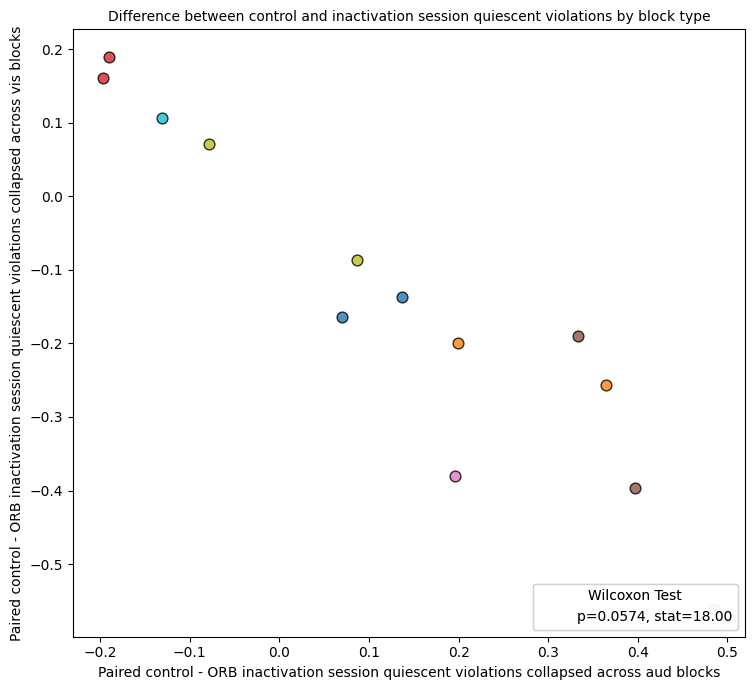

<Figure size 640x480 with 0 Axes>

In [168]:
import matplotlib.pyplot as plt
from datetime import datetime
from scipy import stats

result = dict(
    session_id=str(session.session_id) if hasattr(session, 'session_id') else str(session),
    # ...other fields...
)

#clean
import re

def extract_mouse_id(x):
    # Always convert to string
    s = str(x)
    # Try to extract the mouse ID using regex
    match = re.search(r"\('(\d+)_", s)
    if match:
        return match.group(1)
    # fallback: try splitting
    if '_' in s:
        return s.split('_')[0].split('(')[-1].strip("'")
    return s

muscimol_df_orb['color_group'] = muscimol_df_orb['session_id'].apply(extract_mouse_id)

# # Sort by date
muscimol_df_orb['date'] = muscimol_df_orb['session_id'].apply(
    lambda x: datetime.strptime(str(x).split('_')[1].split("'")[0], '%Y-%m-%d')
)
muscimol_df_orb = muscimol_df_orb.sort_values(by='date').reset_index(drop=True)

# unique colors bymouse ID
unique_groups = muscimol_df_orb['color_group'].unique()
colors = plt.cm.get_cmap('tab10', len(unique_groups))
color_map = {group: colors(i) for i, group in enumerate(unique_groups)}

# Pair control and perturbation sessions
# ...existing code...
# Select only perturbation rows and get their session_id
perturbation_sessions = muscimol_df_orb[muscimol_df_orb['perturbation']]
print(perturbation_sessions['session_id'].tolist())

# If you want to get specific columns for each perturbation session:
# Example: vis_quiescent_violations, aud_quiescent_violations, color_group
perturbation_data = perturbation_sessions[['session_id', 'vis_quiescent_violations', 'aud_quiescent_violations', 'color_group']]
print(perturbation_data)



#control data
control_sessions = muscimol_df_orb[muscimol_df_orb['control']]
print(control_sessions['session_id'].tolist())

# If you want to get specific columns for each perturbation session:
# Example: vis_quiescent_violations, aud_quiescent_violations, color_group
control_data = control_sessions[['session_id', 'vis_quiescent_violations', 'aud_quiescent_violations', 'color_group']]
print(control_data)

#make a df with the diffs
diffs = perturbation_data.copy()
diffs['vis_quiescent_violations'] = perturbation_data['vis_quiescent_violations'] - control_data['vis_quiescent_violations'].values
diffs['aud_quiescent_violations'] = perturbation_data['aud_quiescent_violations'] - control_data['aud_quiescent_violations'].values
# print(diffs)

# # ...existing code...
import matplotlib.pyplot as plt
from scipy.stats import wilcoxon
# perturbation_sessions = muscimol_df_orb[muscimol_df_orb['perturbation']]
# # Get paired values
aud_vals = diffs['aud_quiescent_violations'].values
vis_vals = diffs['vis_quiescent_violations'].values

# # Wilcoxon signed-rank test
stat, p = wilcoxon(aud_vals, vis_vals)
print(f"Wilcoxon signed-rank test: statistic={stat:.2f}, p-value={p:.3g}")

# # ...existing code..

plt.figure(figsize=(9,7))

min_val = min(x_vals + y_vals)
max_val = max(x_vals + y_vals)
ax.plot([min_val, max_val], [min_val, max_val], 'k--', linewidth=1)  # Unity line
for i, row in diffs.iterrows():
    x = row['aud_quiescent_violations']
    y = row['vis_quiescent_violations']
    mouse_id = row['color_group']
    plt.scatter(x, y, color=color_map[mouse_id], s=60, alpha=0.8, edgecolor='k')

plt.xlabel("Paired control - ORB inactivation session quiescent violations collapsed across aud blocks")
plt.ylabel("Paired control - ORB inactivation session quiescent violations collapsed across vis blocks")
plt.title("Difference between control and inactivation session quiescent violations by block type", fontsize=10)

# Build legend handles for each mouse
import matplotlib.patches as mpatches
handles = [mpatches.Patch(color=color_map[group], label=group) for group in unique_groups]
plt.legend(handles=handles, title="Mouse ID", bbox_to_anchor=(1.01, 1), loc='upper left')

# Separate legend for Wilcoxon value (upper right)
wilcoxon_patch = mpatches.Patch(color='white', label=f'p={p:.3g}, stat={stat:.2f}')
plt.gca().add_artist(plt.legend(handles=[wilcoxon_patch], loc='lower right', frameon=True, title="Wilcoxon Test"))

plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.show()


plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.show()
# ...existing code...

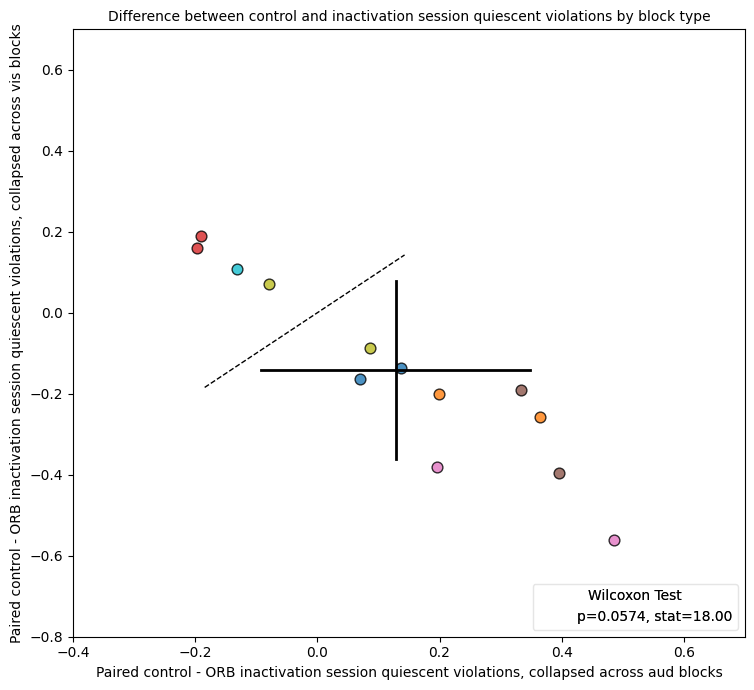

In [169]:
plt.figure(figsize=(9,7))

  # Unity line

# Calculate mean and std for cross
x_vals = diffs['aud_quiescent_violations'].values
y_vals = diffs['vis_quiescent_violations'].values
x_mean, y_mean = np.mean(x_vals), np.mean(y_vals)
x_std, y_std = np.std(x_vals), np.std(y_vals)

min_val = min(x_vals + y_vals)
max_val = max(x_vals + y_vals)
plt.plot([min_val, max_val], [min_val, max_val], 'k--', linewidth=1)

# Draw mean cross
plt.plot([x_mean - x_std, x_mean + x_std], [y_mean, y_mean], color='black', lw=2)
plt.plot([x_mean, x_mean], [y_mean - y_std, y_mean + y_std], color='black', lw=2)

for i, row in diffs.iterrows():
    x = row['aud_quiescent_violations']
    y = row['vis_quiescent_violations']
    mouse_id = row['color_group']
    plt.scatter(x, y, color=color_map[mouse_id], s=60, alpha=0.8, edgecolor='k')

plt.xlabel("Paired control - ORB inactivation session quiescent violations, collapsed across aud blocks")
plt.ylabel("Paired control - ORB inactivation session quiescent violations, collapsed across vis blocks")
plt.title("Difference between control and inactivation session quiescent violations by block type", fontsize=10)

import matplotlib.patches as mpatches
handles = [mpatches.Patch(color=color_map[group], label=group) for group in unique_groups]
plt.legend(handles=handles, title="Mouse ID", bbox_to_anchor=(1.01, 1), loc='upper left')

wilcoxon_patch = mpatches.Patch(color='white', label=f'p={p:.3g}, stat={stat:.2f}')
plt.gca().add_artist(plt.legend(handles=[wilcoxon_patch], loc='lower right', frameon=True, title="Wilcoxon Test", framealpha=0.3))

plt.xlim(-0.4, 0.7)
plt.ylim(-0.8, 0.7)

plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.show()

["DynamicRoutingSession('728053_2024-11-19')", "DynamicRoutingSession('728053_2024-11-21')", "DynamicRoutingSession('739828_2025-02-11')", "DynamicRoutingSession('739828_2025-02-18')", "DynamicRoutingSession('772657_2025-02-25')", "DynamicRoutingSession('772657_2025-03-04')", "DynamicRoutingSession('774916_2025-03-25')", "DynamicRoutingSession('774916_2025-04-01')", "DynamicRoutingSession('767405_2025-05-20')", "DynamicRoutingSession('767405_2025-05-29')", "DynamicRoutingSession('782106_2025-07-08')", "DynamicRoutingSession('782106_2025-07-15')", "DynamicRoutingSession('774470_2025-07-30')"]
["DynamicRoutingSession('728053_2024-11-18')", "DynamicRoutingSession('728053_2024-11-20')", "DynamicRoutingSession('739828_2025-02-10')", "DynamicRoutingSession('739828_2025-02-17')", "DynamicRoutingSession('772657_2025-02-24')", "DynamicRoutingSession('772657_2025-03-03')", "DynamicRoutingSession('774916_2025-03-24')", "DynamicRoutingSession('774916_2025-03-31')", "DynamicRoutingSession('767405_2

C:\Users\vayle.lafehr\AppData\Local\Temp\ipykernel_32080\2259288280.py:36: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', len(unique_groups))


<Figure size 700x700 with 0 Axes>

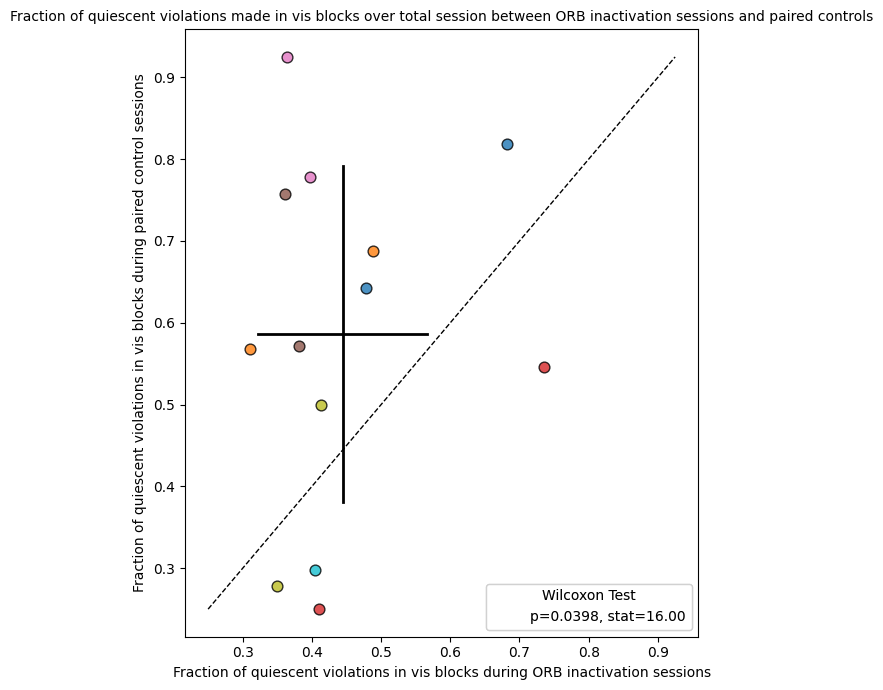

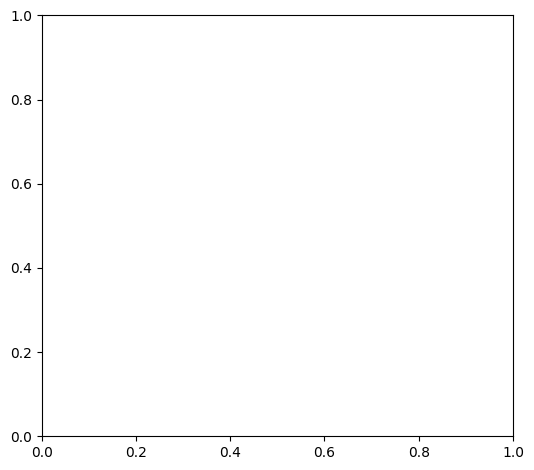

In [170]:
#just plot control day on y axis for vis blocks
import matplotlib.pyplot as plt
from datetime import datetime
from scipy import stats

result = dict(
    session_id=str(session.session_id) if hasattr(session, 'session_id') else str(session),
    # ...other fields...
)

#clean
import re

def extract_mouse_id(x):
    # Always convert to string
    s = str(x)
    # Try to extract the mouse ID using regex
    match = re.search(r"\('(\d+)_", s)
    if match:
        return match.group(1)
    # fallback: try splitting
    if '_' in s:
        return s.split('_')[0].split('(')[-1].strip("'")
    return s

muscimol_df_orb['color_group'] = muscimol_df_orb['session_id'].apply(extract_mouse_id)

# # Sort by date
muscimol_df_orb['date'] = muscimol_df_orb['session_id'].apply(
    lambda x: datetime.strptime(str(x).split('_')[1].split("'")[0], '%Y-%m-%d')
)
muscimol_df_orb = muscimol_df_orb.sort_values(by='date').reset_index(drop=True)

# unique colors bymouse ID
unique_groups = muscimol_df_orb['color_group'].unique()
colors = plt.cm.get_cmap('tab10', len(unique_groups))
color_map = {group: colors(i) for i, group in enumerate(unique_groups)}

# Pair control and perturbation sessions
# ...existing code...
# Select only perturbation rows and get their session_id
perturbation_sessions = muscimol_df_orb[muscimol_df_orb['perturbation']]
print(perturbation_sessions['session_id'].tolist())

# If you want to get specific columns for each perturbation session:
# Example: vis_quiescent_violations, aud_quiescent_violations, color_group
perturbation_data = perturbation_sessions[['session_id', 'vis_quiescent_violations', 'aud_quiescent_violations', 'color_group']]
# print(perturbation_data)



#control data
control_sessions = muscimol_df_orb[muscimol_df_orb['control']]
print(control_sessions['session_id'].tolist())

# If you want to get specific columns for each perturbation session:
# Example: vis_quiescent_violations, aud_quiescent_violations, color_group
control_data = control_sessions[['session_id', 'vis_quiescent_violations', 'aud_quiescent_violations', 'color_group']]
# print(control_data)


# # ...existing code...
import matplotlib.pyplot as plt
from scipy.stats import wilcoxon
# perturbation_sessions = muscimol_df_orb[muscimol_df_orb['perturbation']]
# # Get paired values
vis_vals_control = control_sessions['vis_quiescent_violations'].values
vis_vals_perturbation = perturbation_sessions['vis_quiescent_violations'].values

# ...existing code...

# Create a DataFrame with control and perturbation values for visual quiescent violations
vis_qv_df = pd.DataFrame({
    'vis_quiescent_violations_control': control_sessions['vis_quiescent_violations'].values,
    'vis_quiescent_violations_perturbation': perturbation_sessions['vis_quiescent_violations'].values
})

print(vis_qv_df)

# ...existing code...
# # Wilcoxon signed-rank test
stat, p = wilcoxon(vis_vals_control, vis_vals_perturbation)
print(f"Wilcoxon signed-rank test: statistic={stat:.2f}, p-value={p:.3g}")

# # # ...existing code..

plt.figure(figsize=(7,7))

# Example data: replace with your actual paired values
x_vals = vis_qv_df['vis_quiescent_violations_perturbation'].values
y_vals = vis_qv_df['vis_quiescent_violations_control'].values

plt.figure(figsize=(7, 7))

# Unity line
min_val = min(np.min(x_vals), np.min(y_vals))
max_val = max(np.max(x_vals), np.max(y_vals))
plt.plot([min_val, max_val], [min_val, max_val], 'k--', linewidth=1, label='Unity line')

# Mean cross
x_mean, y_mean = np.mean(x_vals), np.mean(y_vals)
x_std, y_std = np.std(x_vals), np.std(y_vals)
plt.plot([x_mean - x_std, x_mean + x_std], [y_mean, y_mean], color='black', lw=2)  # horizontal arm
plt.plot([x_mean, x_mean], [y_mean - y_std, y_mean + y_std], color='black', lw=2)  # vertical arm

 # Unity line
# # ...existing code...
for i, row in vis_qv_df.iterrows():
    # Get mouse_id from control_sessions (assumes same order as vis_qv_df)
    mouse_id = control_sessions.iloc[i]['color_group']
    color = color_map.get(mouse_id, 'gray')
    x = row['vis_quiescent_violations_perturbation']
    y = row['vis_quiescent_violations_control']
    plt.scatter(x, y, color=color, s=60, alpha=0.8, edgecolor='k')

# min_val = min(x_vals + y_vals)
# max_val = max(x_vals + y_vals)
# ax.plot([min_val, max_val], [min_val, max_val], 'k--', linewidth=1) 

# ...existing code...

plt.xlabel("Fraction of quiescent violations in vis blocks during ORB inactivation sessions")
plt.ylabel("Fraction of quiescent violations in vis blocks during paired control sessions")
plt.title("Fraction of quiescent violations made in vis blocks over total session between ORB inactivation sessions and paired controls", fontsize=10)

# Build legend handles for each mouse
import matplotlib.patches as mpatches
handles = [mpatches.Patch(color=color_map[group], label=group) for group in unique_groups]
plt.legend(handles=handles, title="Mouse ID", bbox_to_anchor=(1.01, 1), loc='upper left')

# Separate legend for Wilcoxon value (upper right)
wilcoxon_patch = mpatches.Patch(color='white', label=f'p={p:.3g}, stat={stat:.2f}')
plt.gca().add_artist(plt.legend(handles=[wilcoxon_patch], loc='lower right', frameon=True, title="Wilcoxon Test"))

plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.show()

plt.xlim(0, 1)
plt.ylim(0, 1)

plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.show()
# ...existing code...

["DynamicRoutingSession('728053_2024-11-19')", "DynamicRoutingSession('728053_2024-11-21')", "DynamicRoutingSession('739828_2025-02-11')", "DynamicRoutingSession('739828_2025-02-18')", "DynamicRoutingSession('772657_2025-02-25')", "DynamicRoutingSession('772657_2025-03-04')", "DynamicRoutingSession('774916_2025-03-25')", "DynamicRoutingSession('774916_2025-04-01')", "DynamicRoutingSession('767405_2025-05-20')", "DynamicRoutingSession('767405_2025-05-29')", "DynamicRoutingSession('782106_2025-07-08')", "DynamicRoutingSession('782106_2025-07-15')", "DynamicRoutingSession('774470_2025-07-30')"]
["DynamicRoutingSession('728053_2024-11-18')", "DynamicRoutingSession('728053_2024-11-20')", "DynamicRoutingSession('739828_2025-02-10')", "DynamicRoutingSession('739828_2025-02-17')", "DynamicRoutingSession('772657_2025-02-24')", "DynamicRoutingSession('772657_2025-03-03')", "DynamicRoutingSession('774916_2025-03-24')", "DynamicRoutingSession('774916_2025-03-31')", "DynamicRoutingSession('767405_2

C:\Users\vayle.lafehr\AppData\Local\Temp\ipykernel_32080\2649676044.py:36: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', len(unique_groups))


<Figure size 700x700 with 0 Axes>

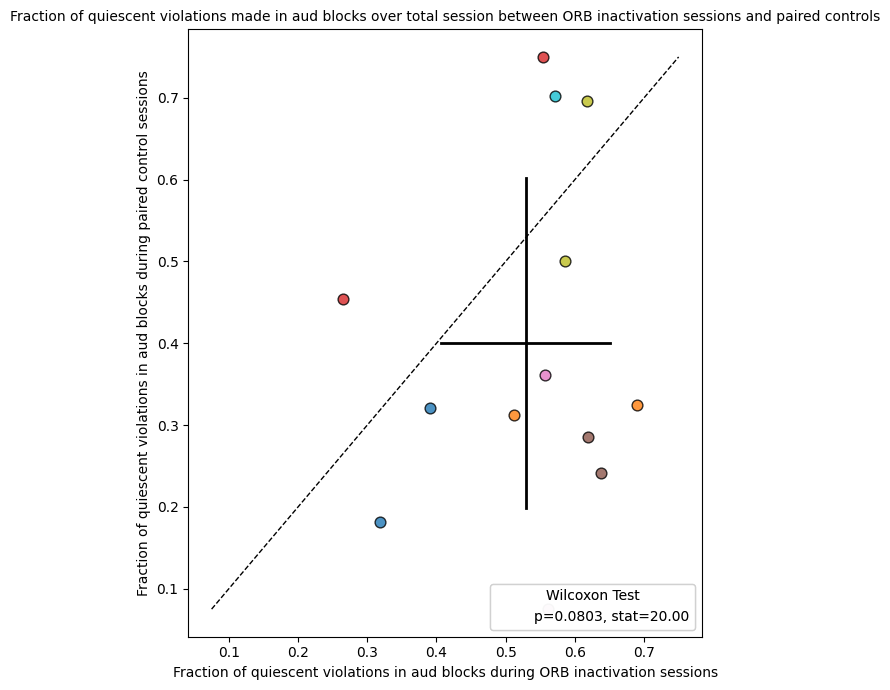

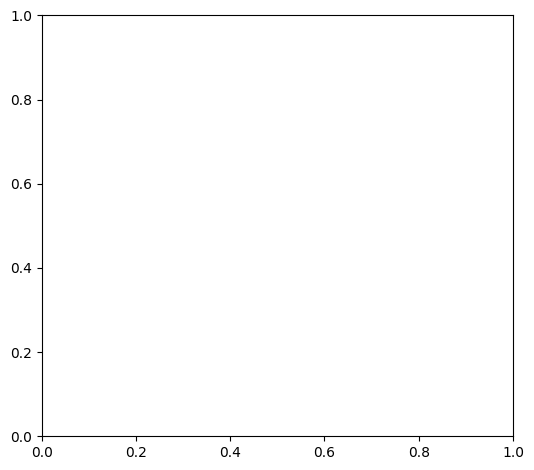

In [171]:
#just plot control day on y axis for vis blocks
import matplotlib.pyplot as plt
from datetime import datetime
from scipy import stats

result = dict(
    session_id=str(session.session_id) if hasattr(session, 'session_id') else str(session),
    # ...other fields...
)

#clean
import re

def extract_mouse_id(x):
    # Always convert to string
    s = str(x)
    # Try to extract the mouse ID using regex
    match = re.search(r"\('(\d+)_", s)
    if match:
        return match.group(1)
    # fallback: try splitting
    if '_' in s:
        return s.split('_')[0].split('(')[-1].strip("'")
    return s

muscimol_df_orb['color_group'] = muscimol_df_orb['session_id'].apply(extract_mouse_id)

# # Sort by date
muscimol_df_orb['date'] = muscimol_df_orb['session_id'].apply(
    lambda x: datetime.strptime(str(x).split('_')[1].split("'")[0], '%Y-%m-%d')
)
muscimol_df_orb = muscimol_df_orb.sort_values(by='date').reset_index(drop=True)

# unique colors bymouse ID
unique_groups = muscimol_df_orb['color_group'].unique()
colors = plt.cm.get_cmap('tab10', len(unique_groups))
color_map = {group: colors(i) for i, group in enumerate(unique_groups)}

# Pair control and perturbation sessions
# ...existing code...
# Select only perturbation rows and get their session_id
perturbation_sessions = muscimol_df_orb[muscimol_df_orb['perturbation']]
print(perturbation_sessions['session_id'].tolist())

# If you want to get specific columns for each perturbation session:
# Example: vis_quiescent_violations, aud_quiescent_violations, color_group
perturbation_data = perturbation_sessions[['session_id', 'vis_quiescent_violations', 'aud_quiescent_violations', 'color_group']]
# print(perturbation_data)



#control data
control_sessions = muscimol_df_orb[muscimol_df_orb['control']]
print(control_sessions['session_id'].tolist())

# If you want to get specific columns for each perturbation session:
# Example: vis_quiescent_violations, aud_quiescent_violations, color_group
control_data = control_sessions[['session_id', 'vis_quiescent_violations', 'aud_quiescent_violations', 'color_group']]
# print(control_data)


# # ...existing code...
import matplotlib.pyplot as plt
from scipy.stats import wilcoxon
# perturbation_sessions = muscimol_df_orb[muscimol_df_orb['perturbation']]
# # Get paired values
aud_vals_control = control_sessions['aud_quiescent_violations'].values
aud_vals_perturbation = perturbation_sessions['aud_quiescent_violations'].values

# ...existing code...

# Create a DataFrame with control and perturbation values for auditory quiescent violations
aud_qv_df = pd.DataFrame({
    'aud_quiescent_violations_control': control_sessions['aud_quiescent_violations'].values,
    'aud_quiescent_violations_perturbation': perturbation_sessions['aud_quiescent_violations'].values
})

print(aud_qv_df)

# ...existing code...
# # Wilcoxon signed-rank test
stat, p = wilcoxon(aud_vals_control, aud_vals_perturbation)
print(f"Wilcoxon signed-rank test: statistic={stat:.2f}, p-value={p:.3g}")

# # # ...existing code..

plt.figure(figsize=(7,7))

# Example data: replace with your actual paired values
x_vals = aud_qv_df['aud_quiescent_violations_perturbation'].values
y_vals = aud_qv_df['aud_quiescent_violations_control'].values

plt.figure(figsize=(7, 7))

# Unity line
min_val = min(np.min(x_vals), np.min(y_vals))
max_val = max(np.max(x_vals), np.max(y_vals))
plt.plot([min_val, max_val], [min_val, max_val], 'k--', linewidth=1, label='Unity line')

# Mean cross
x_mean, y_mean = np.mean(x_vals), np.mean(y_vals)
x_std, y_std = np.std(x_vals), np.std(y_vals)
plt.plot([x_mean - x_std, x_mean + x_std], [y_mean, y_mean], color='black', lw=2)  # horizontal arm
plt.plot([x_mean, x_mean], [y_mean - y_std, y_mean + y_std], color='black', lw=2)  # vertical arm

 # Unity line
# # ...existing code...
for i, row in aud_qv_df.iterrows():
    # Get mouse_id from control_sessions (assumes same order as vis_qv_df)
    mouse_id = control_sessions.iloc[i]['color_group']
    color = color_map.get(mouse_id, 'gray')
    x = row['aud_quiescent_violations_perturbation']
    y = row['aud_quiescent_violations_control']
    plt.scatter(x, y, color=color, s=60, alpha=0.8, edgecolor='k')

# min_val = min(x_vals + y_vals)
# max_val = max(x_vals + y_vals)
# ax.plot([min_val, max_val], [min_val, max_val], 'k--', linewidth=1) 

# ...existing code...

plt.xlabel("Fraction of quiescent violations in aud blocks during ORB inactivation sessions")
plt.ylabel("Fraction of quiescent violations in aud blocks during paired control sessions")
plt.title("Fraction of quiescent violations made in aud blocks over total session between ORB inactivation sessions and paired controls", fontsize=10)

# Build legend handles for each mouse
import matplotlib.patches as mpatches
handles = [mpatches.Patch(color=color_map[group], label=group) for group in unique_groups]
plt.legend(handles=handles, title="Mouse ID", bbox_to_anchor=(1.01, 1), loc='upper left')

# Separate legend for Wilcoxon value (upper right)
wilcoxon_patch = mpatches.Patch(color='white', label=f'p={p:.3g}, stat={stat:.2f}')
plt.gca().add_artist(plt.legend(handles=[wilcoxon_patch], loc='lower right', frameon=True, title="Wilcoxon Test"))

plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.show()

plt.xlim(0, 1)
plt.ylim(0, 1)

plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.show()

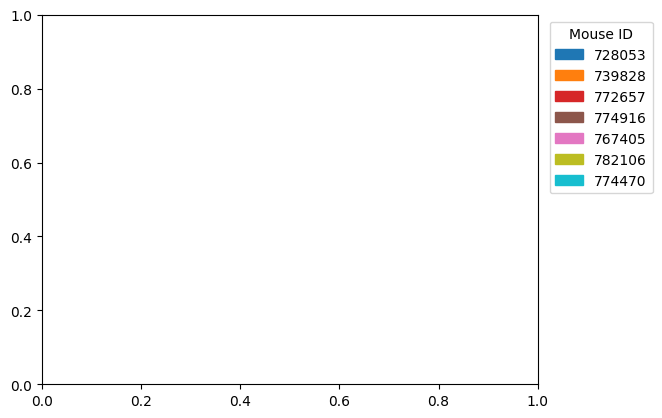

In [99]:
import matplotlib.patches as mpatches
handles = [mpatches.Patch(color=color_map[group], label=group) for group in unique_groups]
plt.legend(handles=handles, title="Mouse ID", bbox_to_anchor=(1.01, 1), loc='upper left')

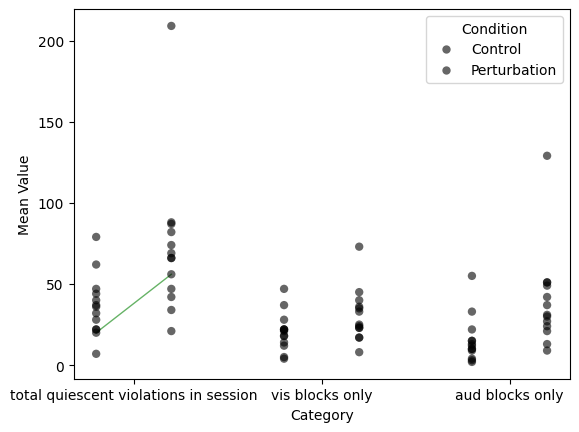

In [172]:

sns.stripplot(
        x='Category',
        y='Mean Value',
        hue='Condition',
        data=avg_values_melted.explode('Mean Value'),
        dodge=True,        # separates points by hue
        jitter=False,       # adds horizontal jitter for visibility
        alpha=0.6,         # transparency for overlapping points
        palette=["#000000", "#000000"],
        marker='o',
        size=6
)

for _, row in paired_df.iterrows():
        x_control = 0  # index of 'quiescent_violations' bar
        x_perturb = 0  # same bar, but dodge shifts it

        # Get dodge offset from Seaborn (usually ~0.2)
        dodge_offset = 0.2

        x1 = x_control - dodge_offset
        x2 = x_perturb + dodge_offset
        y1 = row['quiescent_violations_control']
        y2 = row['quiescent_violations_perturb']
    

plt.plot([x1, x2], [y1, y2], color = 'green' if y2 > y1 else 'red'
    , linestyle='-', linewidth=1, alpha=0.6)
        

In [85]:
from pathlib import Path
import os

from allensdk.core.reference_space_cache import ReferenceSpaceCache

In [86]:
output_dir = '.'

In [79]:
print(avg_values_melted.explode('Mean Value')['Mean Value'].unique())

[47 44 79 40 36 37 32 7 62 22 20 42 87 66 88 74 82 21 34 56]


In [ ]:
# avg_melted_values = avg_values_melted.explode('Mean Value')
# avg_melted_values

,Condition,Category,Mean Value
0,Control,aud_nontarget_vis_context_responses,0.227022
1,Perturbation,aud_nontarget_vis_context_responses,0.303482
2,Control,vis_nontarget_vis_context_responses,0.078516
3,Perturbation,vis_nontarget_vis_context_responses,0.028995
4,Control,vis_nontarget_aud_context_responses,0.020811
5,Perturbation,vis_nontarget_aud_context_responses,0.074064
6,Control,aud_nontarget_aud_context_responses,0.419019
7,Perturbation,aud_nontarget_aud_context_responses,0.673517
8,Control,auditory_target_in_visual_context,0.612851
9,Perturbation,auditory_target_in_visual_context,0.610777


In [11]:

control_values=avg_values_melted.query('Condition=="Control" and Category=="auditory target in visual context"')['Mean Value'].values[0]
perturb_values=avg_values_melted.query('Condition=="Perturbation" and Category=="auditory target in visual context"')['Mean Value'].values[0]

from scipy import stats

t_stat,p_val=stats.ttest_rel(control_values,perturb_values)
print(t_stat, p_val)
# avg_values_df
# x_coords
# sns.load_dataset('tips')


-4.7673390525886274 0.0007600900420603416


In [524]:
control_values=avg_values_melted.query('Condition=="Control" and Category=="visual target in auditory context"')['Mean Value'].values[0]
perturb_values=avg_values_melted.query('Condition=="Perturbation" and Category=="visual target in auditory context"')['Mean Value'].values[0]

from scipy import stats

t_stat,p_val=stats.ttest_rel(control_values,perturb_values)

IndexError: index 0 is out of bounds for axis 0 with size 0

In [477]:
control_values

array([0.47272727, 0.19672131, 0.39285714, 0.52631579, 0.75      ,
       0.51851852, 0.38983051, 0.37704918])

## ORB single bar plots

C:\Users\vayle.lafehr\AppData\Local\Temp\ipykernel_32080\3047957001.py:28: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', len(unique_groups))


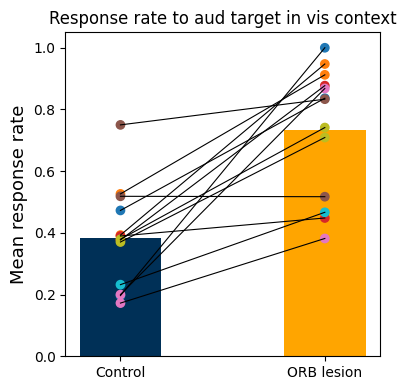

In [173]:
from datetime import datetime, timedelta


muscimol_df_orb['session_id'] = muscimol_df_orb['session_id'].astype(str)

avg_control = muscimol_df_orb[muscimol_df_orb['control']]['auditory_target_in_visual_context'].mean()
avg_perturbation = muscimol_df_orb[muscimol_df_orb['perturbation']]['auditory_target_in_visual_context'].mean()


# Create a bar plot comparing perturbation vs control bars with averages
plt.figure(figsize=(4, 4))
bar_width = 0.4

bars = ['Control', 'ORB lesion']
y_pos = range(len(bars))
averages = [avg_control, avg_perturbation]

plt.bar(y_pos, averages, color=['#003057', '#FFA500'], width=bar_width)

# plt.xlabel('Perturbation Condition')
plt.ylabel('Mean response rate', fontsize = 13)
plt.title('Response rate to aud target in vis context', fontsize = 11.9)
plt.xticks(y_pos, bars)

muscimol_df_orb['color_group'] = muscimol_df_orb['session_id'].apply(lambda x: x.split('_')[0].split('(')[1].strip("'"))

unique_groups = muscimol_df_orb['color_group'].unique()
colors = plt.cm.get_cmap('tab10', len(unique_groups))
color_map = {group: colors(i) for i, group in enumerate(unique_groups)}

control_points = muscimol_df_orb[muscimol_df_orb['control']]['auditory_target_in_visual_context']
perturbation_points = muscimol_df_orb[muscimol_df_orb['perturbation']]['auditory_target_in_visual_context']

control_colors = muscimol_df_orb[muscimol_df_orb['control']]['color_group'].map(color_map)
perturbation_colors = muscimol_df_orb[muscimol_df_orb['perturbation']]['color_group'].map(color_map)

plt.scatter([0]*len(control_points), control_points, color=control_colors, zorder=2)
plt.scatter([1]*len(perturbation_points), perturbation_points, color=perturbation_colors, zorder=2)


muscimol_df_orb['date'] = muscimol_df_orb['session_id'].apply(lambda x: datetime.strptime(x.split('_')[1].split("'")[0], '%Y-%m-%d'))
            
for i in range(1, len(muscimol_df_orb), 2):
    x_coords = [0 if muscimol_df_orb.loc[i-1, 'control'] else 1, 0 if muscimol_df_orb.loc[i, 'control'] else 1]
    y_coords = [muscimol_df_orb.loc[i-1, 'auditory_target_in_visual_context'], muscimol_df_orb.loc[i, 'auditory_target_in_visual_context']]
    plt.plot(x_coords, y_coords, color='black', linestyle='-', linewidth=0.8)


# for i in range(len(muscimol_df_orb)):
#     session_id_label = muscimol_df_orb.loc[i, 'session_id'].replace("DynamicRoutingSession", "")
#     if muscimol_df_orb.loc[i, 'control']:
#         plt.text(0, muscimol_df_orb.loc[i, 'auditory_target_in_visual_context'] + 0.009 * i, session_id_label, fontsize=6, rotation=5, va='bottom')
#     else:
#         plt.text(1, muscimol_df_orb.loc[i, 'auditory_target_in_visual_context']+ 0.006 * i - 0.003 * len(muscimol_df_orb), session_id_label, fontsize=6, rotation=0, ha='left')


# handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=color_map[group], markersize=10) for group in unique_groups]
# labels = unique_groups
# plt.legend(handles, labels, title="Mouse")


# Show the plot
plt.tight_layout()

plt.savefig(r"C:\Users\vayle.lafehr\Desktop\perturbation_analysis_figures\response_rate_aud_target_vis_context.png", dpi=300)
plt.savefig(r"Z:\vayle\muscimol_ORB_behavior_plots", dpi=300)
plt.show()


C:\Users\vayle.lafehr\AppData\Local\Temp\ipykernel_32080\673045661.py:28: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', len(unique_groups))


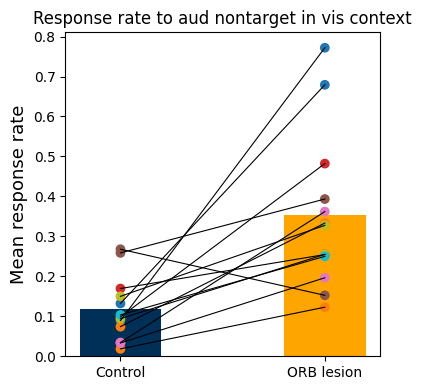

In [174]:
from datetime import datetime, timedelta


muscimol_df_orb['session_id'] = muscimol_df_orb['session_id'].astype(str)

avg_control = muscimol_df_orb[muscimol_df_orb['control']]['aud_nontarget_vis_context_responses'].mean()
avg_perturbation = muscimol_df_orb[muscimol_df_orb['perturbation']]['aud_nontarget_vis_context_responses'].mean()


# Create a bar plot comparing perturbation vs control bars with averages
plt.figure(figsize=(4, 4))
bar_width = 0.4

bars = ['Control', 'ORB lesion']
y_pos = range(len(bars))
averages = [avg_control, avg_perturbation]

plt.bar(y_pos, averages, color=['#003057', '#FFA500'], width=bar_width)

# plt.xlabel('Perturbation Condition')
plt.ylabel('Mean response rate', fontsize = 13)
plt.title('Response rate to aud nontarget in vis context', fontsize = 11.9)
plt.xticks(y_pos, bars)

muscimol_df_orb['color_group'] = muscimol_df_orb['session_id'].apply(lambda x: x.split('_')[0].split('(')[1].strip("'"))

unique_groups = muscimol_df_orb['color_group'].unique()
colors = plt.cm.get_cmap('tab10', len(unique_groups))
color_map = {group: colors(i) for i, group in enumerate(unique_groups)}

control_points = muscimol_df_orb[muscimol_df_orb['control']]['aud_nontarget_vis_context_responses']
perturbation_points = muscimol_df_orb[muscimol_df_orb['perturbation']]['aud_nontarget_vis_context_responses']

control_colors = muscimol_df_orb[muscimol_df_orb['control']]['color_group'].map(color_map)
perturbation_colors = muscimol_df_orb[muscimol_df_orb['perturbation']]['color_group'].map(color_map)

plt.scatter([0]*len(control_points), control_points, color=control_colors, zorder=2)
plt.scatter([1]*len(perturbation_points), perturbation_points, color=perturbation_colors, zorder=2)


muscimol_df_orb['date'] = muscimol_df_orb['session_id'].apply(lambda x: datetime.strptime(x.split('_')[1].split("'")[0], '%Y-%m-%d'))
            
for i in range(1, len(muscimol_df_orb), 2):
    x_coords = [0 if muscimol_df_orb.loc[i-1, 'control'] else 1, 0 if muscimol_df_orb.loc[i, 'control'] else 1]
    y_coords = [muscimol_df_orb.loc[i-1, 'aud_nontarget_vis_context_responses'], muscimol_df_orb.loc[i, 'aud_nontarget_vis_context_responses']]
    plt.plot(x_coords, y_coords, color='black', linestyle='-', linewidth=0.8)


# for i in range(len(muscimol_df)):
#     session_id_label = muscimol_df.loc[i, 'session_id'].replace("DynamicRoutingSession", "")
#     if muscimol_df.loc[i, 'control']:
#         plt.text(0, muscimol_df.loc[i, 'visual_target_in_visual_context'] + 0.009 * i, session_id_label, fontsize=6, rotation=5, va='bottom')
#     else:
#         plt.text(1, muscimol_df.loc[i, 'visual_target_in_visual_context']+ 0.006 * i - 0.003 * len(muscimol_df), session_id_label, fontsize=6, rotation=0, ha='left')


# handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=color_map[group], markersize=10) for group in unique_groups]
# labels = unique_groups
# plt.legend(handles, labels, title="Mouse")


# Show the plot
plt.tight_layout()

# plt.savefig(r"C:\Users\vayle.lafehr\Desktop\perturbation_analysis_figures\response_rate_vis_target_vis_context.png", dpi=300)
plt.show()

C:\Users\vayle.lafehr\AppData\Local\Temp\ipykernel_32080\1319991102.py:28: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', len(unique_groups))


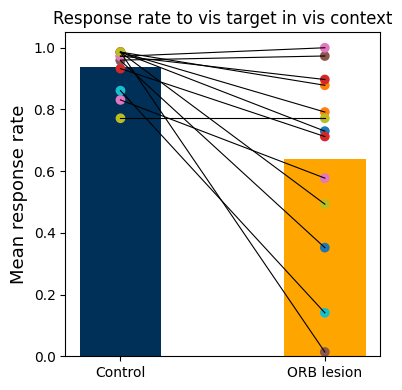

In [175]:
from datetime import datetime, timedelta


muscimol_df_orb['session_id'] = muscimol_df_orb['session_id'].astype(str)

avg_control = muscimol_df_orb[muscimol_df_orb['control']]['visual_target_in_visual_context'].mean()
avg_perturbation = muscimol_df_orb[muscimol_df_orb['perturbation']]['visual_target_in_visual_context'].mean()


# Create a bar plot comparing perturbation vs control bars with averages
plt.figure(figsize=(4, 4))
bar_width = 0.4

bars = ['Control', 'ORB lesion']
y_pos = range(len(bars))
averages = [avg_control, avg_perturbation]

plt.bar(y_pos, averages, color=['#003057', '#FFA500'], width=bar_width)

# plt.xlabel('Perturbation Condition')
plt.ylabel('Mean response rate', fontsize = 13)
plt.title('Response rate to vis target in vis context', fontsize = 11.9)
plt.xticks(y_pos, bars)

muscimol_df_orb['color_group'] = muscimol_df_orb['session_id'].apply(lambda x: x.split('_')[0].split('(')[1].strip("'"))

unique_groups = muscimol_df_orb['color_group'].unique()
colors = plt.cm.get_cmap('tab10', len(unique_groups))
color_map = {group: colors(i) for i, group in enumerate(unique_groups)}

control_points = muscimol_df_orb[muscimol_df_orb['control']]['visual_target_in_visual_context']
perturbation_points = muscimol_df_orb[muscimol_df_orb['perturbation']]['visual_target_in_visual_context']

control_colors = muscimol_df_orb[muscimol_df_orb['control']]['color_group'].map(color_map)
perturbation_colors = muscimol_df_orb[muscimol_df_orb['perturbation']]['color_group'].map(color_map)

plt.scatter([0]*len(control_points), control_points, color=control_colors, zorder=2)
plt.scatter([1]*len(perturbation_points), perturbation_points, color=perturbation_colors, zorder=2)


muscimol_df_orb['date'] = muscimol_df_orb['session_id'].apply(lambda x: datetime.strptime(x.split('_')[1].split("'")[0], '%Y-%m-%d'))
            
for i in range(1, len(muscimol_df_orb), 2):
    x_coords = [0 if muscimol_df_orb.loc[i-1, 'control'] else 1, 0 if muscimol_df_orb.loc[i, 'control'] else 1]
    y_coords = [muscimol_df_orb.loc[i-1, 'visual_target_in_visual_context'], muscimol_df_orb.loc[i, 'visual_target_in_visual_context']]
    plt.plot(x_coords, y_coords, color='black', linestyle='-', linewidth=0.8)


# for i in range(len(muscimol_df)):
#     session_id_label = muscimol_df.loc[i, 'session_id'].replace("DynamicRoutingSession", "")
#     if muscimol_df.loc[i, 'control']:
#         plt.text(0, muscimol_df.loc[i, 'visual_target_in_visual_context'] + 0.009 * i, session_id_label, fontsize=6, rotation=5, va='bottom')
#     else:
#         plt.text(1, muscimol_df.loc[i, 'visual_target_in_visual_context']+ 0.006 * i - 0.003 * len(muscimol_df), session_id_label, fontsize=6, rotation=0, ha='left')


# handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=color_map[group], markersize=10) for group in unique_groups]
# labels = unique_groups
# plt.legend(handles, labels, title="Mouse")


# Show the plot
plt.tight_layout()

# plt.savefig(r"C:\Users\vayle.lafehr\Desktop\perturbation_analysis_figures\response_rate_vis_target_vis_context.png", dpi=300)
plt.show()

C:\Users\vayle.lafehr\AppData\Local\Temp\ipykernel_32080\3240390784.py:28: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', len(unique_groups))


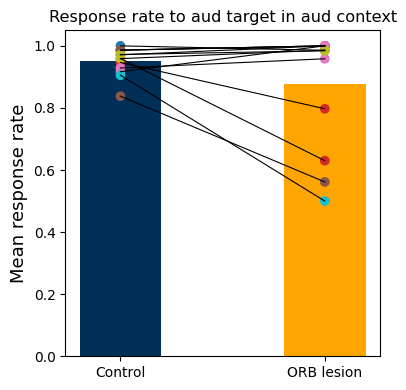

In [176]:
from datetime import datetime, timedelta


muscimol_df_orb['session_id'] = muscimol_df_orb['session_id'].astype(str)

avg_control = muscimol_df_orb[muscimol_df_orb['control']]['auditory_target_in_auditory_context'].mean()
avg_perturbation = muscimol_df_orb[muscimol_df_orb['perturbation']]['auditory_target_in_auditory_context'].mean()


# Create a bar plot comparing perturbation vs control bars with averages
plt.figure(figsize=(4, 4))
bar_width = 0.4

bars = ['Control', 'ORB lesion']
y_pos = range(len(bars))
averages = [avg_control, avg_perturbation]

plt.bar(y_pos, averages, color=['#003057', '#FFA500'], width=bar_width)

# plt.xlabel('Perturbation Condition')
plt.ylabel('Mean response rate', fontsize = 13)
plt.title('Response rate to aud target in aud context', fontsize =11.6)
plt.xticks(y_pos, bars)

muscimol_df_orb['color_group'] = muscimol_df_orb['session_id'].apply(lambda x: x.split('_')[0].split('(')[1].strip("'"))

unique_groups = muscimol_df_orb['color_group'].unique()
colors = plt.cm.get_cmap('tab10', len(unique_groups))
color_map = {group: colors(i) for i, group in enumerate(unique_groups)}

control_points = muscimol_df_orb[muscimol_df_orb['control']]['auditory_target_in_auditory_context']
perturbation_points = muscimol_df_orb[muscimol_df_orb['perturbation']]['auditory_target_in_auditory_context']

control_colors = muscimol_df_orb[muscimol_df_orb['control']]['color_group'].map(color_map)
perturbation_colors = muscimol_df_orb[muscimol_df_orb['perturbation']]['color_group'].map(color_map)

plt.scatter([0]*len(control_points), control_points, color=control_colors, zorder=2)
plt.scatter([1]*len(perturbation_points), perturbation_points, color=perturbation_colors, zorder=2)


muscimol_df_orb['date'] = muscimol_df_orb['session_id'].apply(lambda x: datetime.strptime(x.split('_')[1].split("'")[0], '%Y-%m-%d'))
            
for i in range(1, len(muscimol_df_orb), 2):
    x_coords = [0 if muscimol_df_orb.loc[i-1, 'control'] else 1, 0 if muscimol_df_orb.loc[i, 'control'] else 1]
    y_coords = [muscimol_df_orb.loc[i-1, 'auditory_target_in_auditory_context'], muscimol_df_orb.loc[i, 'auditory_target_in_auditory_context']]
    plt.plot(x_coords, y_coords, color='black', linestyle='-', linewidth=0.8)


# for i in range(len(muscimol_df)):
#     session_id_label = muscimol_df.loc[i, 'session_id'].replace("DynamicRoutingSession", "")
#     if muscimol_df.loc[i, 'control']:
#         plt.text(0, muscimol_df.loc[i, 'visual_target_in_visual_context'] + 0.009 * i, session_id_label, fontsize=6, rotation=5, va='bottom')
#     else:
#         plt.text(1, muscimol_df.loc[i, 'visual_target_in_visual_context']+ 0.006 * i - 0.003 * len(muscimol_df), session_id_label, fontsize=6, rotation=0, ha='left')


# handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=color_map[group], markersize=10) for group in unique_groups]
# labels = unique_groups
# plt.legend(handles, labels, title="Mouse")


# Show the plot
plt.tight_layout()

# plt.savefig(r"C:\Users\vayle.lafehr\Desktop\perturbation_analysis_figures\response_rate_aud_target_aud_context.png", dpi=300)
plt.show()

C:\Users\vayle.lafehr\AppData\Local\Temp\ipykernel_32080\3931108057.py:30: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', len(unique_groups))


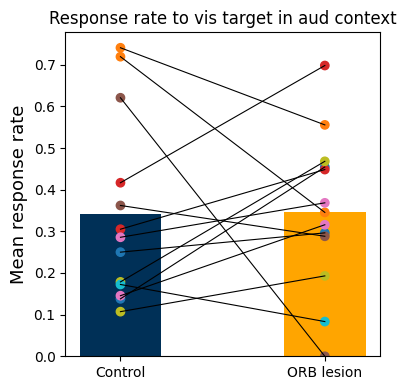

In [177]:
from datetime import datetime, timedelta


muscimol_df_orb['session_id'] = muscimol_df_orb['session_id'].astype(str)

avg_control = muscimol_df_orb[muscimol_df_orb['control']]['visual_target_in_auditory_context'].mean()
avg_perturbation = muscimol_df_orb[muscimol_df_orb['perturbation']]['visual_target_in_auditory_context'].mean()


# Create a bar plot comparing perturbation vs control bars with averages
plt.figure(figsize=(4, 4))
bar_width = 0.4

bars = ['Control', 'ORB lesion']
y_pos = range(len(bars))
averages = [avg_control, avg_perturbation]

plt.bar(y_pos, averages, color=['#003057', '#FFA500'], width=bar_width)

# plt.xlabel('Perturbation Condition')
plt.ylabel('Mean response rate', fontsize = 13)
plt.title('Response rate to vis target in aud context', fontsize = 11.9)
plt.xticks(y_pos, bars)

ax.yaxis.set_major_locator(plt.MultipleLocator(0.05))

muscimol_df_orb['color_group'] = muscimol_df_orb['session_id'].apply(lambda x: x.split('_')[0].split('(')[1].strip("'"))

unique_groups = muscimol_df_orb['color_group'].unique()
colors = plt.cm.get_cmap('tab10', len(unique_groups))
color_map = {group: colors(i) for i, group in enumerate(unique_groups)}

control_points = muscimol_df_orb[muscimol_df_orb['control']]['visual_target_in_auditory_context']
perturbation_points = muscimol_df_orb[muscimol_df_orb['perturbation']]['visual_target_in_auditory_context']

control_colors = muscimol_df_orb[muscimol_df_orb['control']]['color_group'].map(color_map)
perturbation_colors = muscimol_df_orb[muscimol_df_orb['perturbation']]['color_group'].map(color_map)

plt.scatter([0]*len(control_points), control_points, color=control_colors, zorder=2)
plt.scatter([1]*len(perturbation_points), perturbation_points, color=perturbation_colors, zorder=2)


muscimol_df_orb['date'] = muscimol_df_orb['session_id'].apply(lambda x: datetime.strptime(x.split('_')[1].split("'")[0], '%Y-%m-%d'))
            
for i in range(1, len(muscimol_df_orb), 2):
    x_coords = [0 if muscimol_df_orb.loc[i-1, 'control'] else 1, 0 if muscimol_df_orb.loc[i, 'control'] else 1]
    y_coords = [muscimol_df_orb.loc[i-1, 'visual_target_in_auditory_context'], muscimol_df_orb.loc[i, 'visual_target_in_auditory_context']]
    plt.plot(x_coords, y_coords, color='black', linestyle='-', linewidth=0.8)


# for i in range(len(muscimol_df)):
#     session_id_label = muscimol_df.loc[i, 'session_id'].replace("DynamicRoutingSession", "")
#     if muscimol_df.loc[i, 'control']:
#         plt.text(0, muscimol_df.loc[i, 'visual_target_in_visual_context'] + 0.009 * i, session_id_label, fontsize=6, rotation=5, va='bottom')
#     else:
#         plt.text(1, muscimol_df.loc[i, 'visual_target_in_visual_context']+ 0.006 * i - 0.003 * len(muscimol_df), session_id_label, fontsize=6, rotation=0, ha='left')


# handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=color_map[group], markersize=10) for group in unique_groups]
# labels = unique_groups
# plt.legend(handles, labels, title="Mouse")


# Show the plot
plt.tight_layout()

# plt.savefig(r"C:\Users\vayle.lafehr\Desktop\perturbation_analysis_figures\response_rate_vis_target_aud_context.png", dpi=300)
plt.show()

C:\Users\vayle.lafehr\AppData\Local\Temp\ipykernel_32080\2697638257.py:30: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', len(unique_groups))


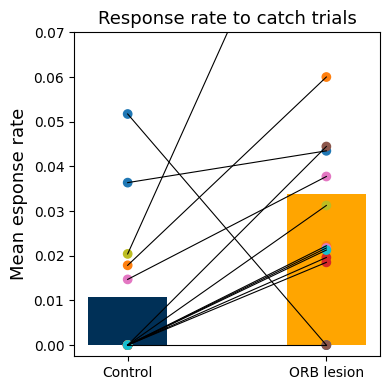

In [178]:
#catch_trials

from datetime import datetime, timedelta


muscimol_df_orb['session_id'] = muscimol_df_orb['session_id'].astype(str)

avg_control = muscimol_df_orb[muscimol_df_orb['control']]['catch_trials'].mean()
avg_perturbation = muscimol_df_orb[muscimol_df_orb['perturbation']]['catch_trials'].mean()


# Create a bar plot comparing perturbation vs control bars with averages
plt.figure(figsize=(4, 4))
bar_width = 0.4

bars = ['Control', 'ORB lesion']
y_pos = range(len(bars))
averages = [avg_control, avg_perturbation]

plt.bar(y_pos, averages, color=['#003057', '#FFA500'], width=bar_width)

# plt.xlabel('Perturbation Condition')
plt.ylabel('Mean esponse rate', fontsize = 13)
plt.title('Response rate to catch trials', fontsize = 13)
plt.xticks(y_pos, bars)

muscimol_df_orb['color_group'] = muscimol_df_orb['session_id'].apply(lambda x: x.split('_')[0].split('(')[1].strip("'"))

unique_groups = muscimol_df_orb['color_group'].unique()
colors = plt.cm.get_cmap('tab10', len(unique_groups))
color_map = {group: colors(i) for i, group in enumerate(unique_groups)}

control_points = muscimol_df_orb[muscimol_df_orb['control']]['catch_trials']
perturbation_points = muscimol_df_orb[muscimol_df_orb['perturbation']]['catch_trials']

control_colors = muscimol_df_orb[muscimol_df_orb['control']]['color_group'].map(color_map)
perturbation_colors = muscimol_df_orb[muscimol_df_orb['perturbation']]['color_group'].map(color_map)

plt.scatter([0]*len(control_points), control_points, color=control_colors, zorder=2)
plt.scatter([1]*len(perturbation_points), perturbation_points, color=perturbation_colors, zorder=2)


muscimol_df_orb['date'] = muscimol_df_orb['session_id'].apply(lambda x: datetime.strptime(x.split('_')[1].split("'")[0], '%Y-%m-%d'))
            
for i in range(1, len(muscimol_df_orb), 2):
    x_coords = [0 if muscimol_df_orb.loc[i-1, 'control'] else 1, 0 if muscimol_df_orb.loc[i, 'control'] else 1]
    y_coords = [muscimol_df_orb.loc[i-1, 'catch_trials'], muscimol_df_orb.loc[i, 'catch_trials']]
    plt.plot(x_coords, y_coords, color='black', linestyle='-', linewidth=0.8)


# for i in range(len(muscimol_df)):
#     session_id_label = muscimol_df.loc[i, 'session_id'].replace("DynamicRoutingSession", "")
#     if muscimol_df.loc[i, 'control']:
#         plt.text(0, muscimol_df.loc[i, 'visual_target_in_visual_context'] + 0.009 * i, session_id_label, fontsize=6, rotation=5, va='bottom')
#     else:
#         plt.text(1, muscimol_df.loc[i, 'visual_target_in_visual_context']+ 0.006 * i - 0.003 * len(muscimol_df), session_id_label, fontsize=6, rotation=0, ha='left')


# handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=color_map[group], markersize=10) for group in unique_groups]
# labels = unique_groups
# plt.legend(handles, labels, title="Mouse")

# ax.yaxis.set_major_locator(plt.MultipleLocator(0.0025))


ax = plt.gca()
ax.set_ylim(-0.0025, 0.07)

# Show the plot
plt.tight_layout()

# plt.savefig(r"C:\Users\vayle.lafehr\Desktop\perturbation_analysis_figures\catch_trials.png", dpi=300)
plt.show()

## ORB scatter plot unity line

C:\Users\vayle.lafehr\AppData\Local\Temp\ipykernel_32080\775575399.py:19: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', len(unique_groups))


(0.8363636363636363, 0.4727272727272727, '728053')
(1.0, 0.19672131147540983, '728053')
(0.9473684210526315, 0.39285714285714285, '739828')
(0.9122807017543859, 0.5263157894736842, '739828')
(0.4482758620689655, 0.3898305084745763, '772657')
(0.8771929824561403, 0.3770491803278688, '772657')
(0.8333333333333334, 0.75, '774916')
(0.5172413793103449, 0.5185185185185185, '774916')
(0.38181818181818183, 0.1724137931034483, '767405')
(0.8679245283018868, 0.2, '767405')
(0.7413793103448276, 0.3793103448275862, '782106')
(0.7090909090909091, 0.37037037037037035, '782106')
(0.4666666666666667, 0.23214285714285715, '774470')


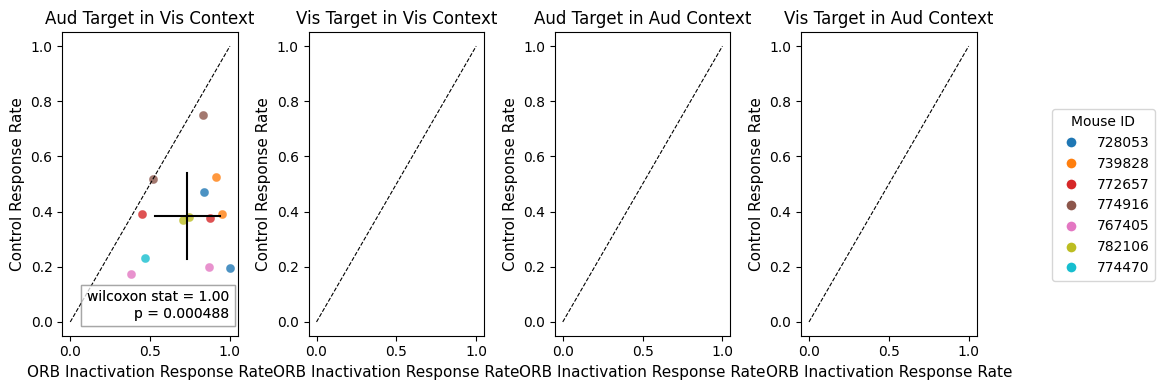

In [179]:
import matplotlib.pyplot as plt
from datetime import datetime
from scipy import stats


#clean
muscimol_df_orb['color_group'] = muscimol_df_orb['session_id'].apply(
    lambda x: x.split('_')[0].split('(')[1].strip("'")
)

# Sort by date
muscimol_df_orb['date'] = muscimol_df_orb['session_id'].apply(
    lambda x: datetime.strptime(x.split('_')[1].split("'")[0], '%Y-%m-%d')
)
muscimol_df_orb = muscimol_df_orb.sort_values(by='date').reset_index(drop=True)

# unique colors bymouse ID
unique_groups = muscimol_df_orb['color_group'].unique()
colors = plt.cm.get_cmap('tab10', len(unique_groups))
color_map = {group: colors(i) for i, group in enumerate(unique_groups)}

# Pair control and perturbation sessions
paired_data_vis_vis = []
for i in range(1, len(muscimol_df_orb), 2):
    row1 = muscimol_df_orb.loc[i - 1]
    row2 = muscimol_df_orb.loc[i]
    if row1['control']:
        control_val = row1['visual_target_in_visual_context']
        perturb_val = row2['visual_target_in_visual_context']
        color_group = row1['color_group']
    else:
        control_val = row2['visual_target_in_visual_context']
        perturb_val = row1['visual_target_in_visual_context']
        color_group = row2['color_group']
    paired_data_vis_vis.append((perturb_val, control_val, color_group))

    paired_data_aud_vis = []
for i in range(1, len(muscimol_df_orb), 2):
    row1 = muscimol_df_orb.loc[i - 1]
    row2 = muscimol_df_orb.loc[i]
    if row1['control']:
        control_val_1 = row1['auditory_target_in_visual_context']
        perturb_val_1 = row2['auditory_target_in_visual_context']
        color_group = row1['color_group']
    else:
        control_val_1 = row2['auditory_target_in_visual_context']
        perturb_val_1 = row1['auditory_target_in_visual_context']
        color_group = row2['color_group']
    paired_data_aud_vis.append((perturb_val_1, control_val_1, color_group))

    paired_data_vis_aud = []
for i in range(1, len(muscimol_df_orb), 2):
    row1 = muscimol_df_orb.loc[i - 1]
    row2 = muscimol_df_orb.loc[i]
    if row1['control']:
        control_val_2 = row1['visual_target_in_auditory_context']
        perturb_val_2 = row2['visual_target_in_auditory_context']
        color_group = row1['color_group']
    else:
        control_val_2 = row2['visual_target_in_auditory_context']
        perturb_val_2 = row1['visual_target_in_auditory_context']
        color_group = row2['color_group']
    paired_data_vis_aud.append((perturb_val_2, control_val_2, color_group))

    paired_data_aud_aud = []
for i in range(1, len(muscimol_df_orb), 2):
    row1 = muscimol_df_orb.loc[i - 1]
    row2 = muscimol_df_orb.loc[i]
    if row1['control']:
        control_val_3 = row1['auditory_target_in_auditory_context']
        perturb_val_3 = row2['auditory_target_in_auditory_context']
        color_group = row1['color_group']
    else:
        control_val_3 = row2['auditory_target_in_auditory_context']
        perturb_val_3 = row1['auditory_target_in_auditory_context']
        color_group = row2['color_group']
    paired_data_aud_aud.append((perturb_val_3, control_val_3, color_group))

# Create scatter plot with x = perturbation, y = control
# plt.figure(figsize=(20, 20))

# data = [paired_data_vis_vis, paired_data_aud_vis]
# for datum in data:
#     for x, y, group in datum:
#         print((x,y,group))
#         plt.scatter(x, y, color=color_map[group], label=group, alpha=0.8, linewidth = 0.2)
#         plt.scatter(x, y, color=color_map[group], label=group, alpha=0.8)

fig, axes = plt.subplots(1, 4, figsize=(10, 4), sharex=True, sharey=True)

contexts = ['Aud Target in Vis Context','Vis Target in Vis Context', 'Aud Target in Aud Context', 'Vis Target in Aud Context']
data = [paired_data_aud_vis]
        # paired_data_vis_vis, paired_data_aud_aud, paired_data_vis_aud]

#make test star for plot


    
#organize paired data

paired_data_sets ={
    'aud_vis': paired_data_aud_vis,
    # 'vis_vis': paired_data_vis_vis,
    # 'aud_aud': paired_data_aud_aud,
    # 'vis_aud': paired_data_vis_aud,
}
    

#mean cross


for ax, (label, paired_data) in zip(axes, paired_data_sets.items()):
    x_vals = [x for x, _, _ in paired_data]
    y_vals = [y for _, y, _ in paired_data]
    # print(f"{label} - x_vals: {x_vals}, y_vals: {y_vals}")
    
    x_mean, y_mean = np.mean(x_vals), np.mean(y_vals)
    x_std, y_std = np.std(x_vals), np.std(y_vals)
    ax.plot([x_mean - x_std, x_mean +x_std], [y_mean, y_mean], color='black', lw=1.5)
    ax.plot([x_mean, x_mean], [y_mean - y_std, y_mean + y_std], color='black', lw=1.5)


    for ax, datum, title in zip(axes, data, contexts):
        for x, y, group in datum:
            print((x, y, group))
            ax.scatter(x, y, color=color_map[group], alpha=0.8, linewidth=0.2)





# for ax in axes:
    # ax.errorbar(np.mean(x_vals), np.mean(y_vals), xerr=x_std, yerr=y_std, fmt='o', color='black', markersize=5, label='Mean ± Std Dev', alpha=0.5)
# unity line

for ax in axes:
    ax.plot([0, 1], [0, 1], 'k--', linewidth=0.8)  # Unity line for each subplot
# plt.plot([0, 1], [0, 1], 'k--')


# ax.set_xlim(0, 1)
# ax.set_ylim(0, 1)
#adds space to plot size
# x_vals = [x for x, _, _ in paired_data]
# y_vals = [y for _, y, _ in paired_data]

# x_min, x_max = min(x_vals), max(x_vals)
# y_min, y_max = min(y_vals), max(y_vals)

# padding_x = (x_max - x_min) * 0.05  # 5% padding
# padding_y = (y_max - y_min) * 0.05

# ax.set_xlim(x_min - padding_x, x_max + padding_x)
# ax.set_ylim(y_min - padding_y, y_max + padding_y)


for ax, x_label in zip(axes, 'ORB Inactivation Response Rate'):
    ax.set_xlabel('ORB Inactivation Response Rate', fontsize =11)


for ax, y_label in zip(axes, 'Control Response Rate'):
    ax.set_ylabel('Control Response Rate', fontsize=11)
# ax.set_title(f'{c for c in contexts}', fontsize=12)

for ax, title in zip(axes, contexts):
    ax.set_title(f'{title}', fontsize=12)

for ax in axes:
    ax.yaxis.set_tick_params(labelleft=True)
# ax.grid(True)
for ax, (label, paired_data) in zip(axes, paired_data_sets.items()):
    x_vals = [x for x, _, _ in paired_data]  # Perturbation
    y_vals = [y for _, y, _ in paired_data]  # Control

    # Run paired t-test
    from scipy.stats import wilcoxon

    wilcoxon_stat, p_val = wilcoxon(x_vals, y_vals)
    ax.text(0.95, 0.05, f'wilcoxon stat = {wilcoxon_stat:.2f}\np = {p_val:.3g}',
                    transform=ax.transAxes, fontsize=10,
                    verticalalignment='bottom', horizontalalignment='right',
                    bbox=dict(facecolor='white', alpha=0.5, edgecolor='gray'))


    # Plot scatter and mean cross as before...
    # [your existing plotting code here]

    # Annotate with t-test result
    ax.text(0.95, 0.05, f'wilcoxon stat = {wilcoxon_stat:.2f}\np = {p_val:.3g}',
            transform=ax.transAxes, fontsize=10,
            verticalalignment='bottom', horizontalalignment='right', bbox=dict(facecolor='white', alpha=0.5, edgecolor='gray'))

# Create legend with unique mouse IDs
# handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=color_map[group], markersize=8) for group in unique_groups]
# plt.legend(handles, unique_groups, title="Mouse ID", bbox_to_anchor=(1.05, 1), loc='upper left')

handles = [plt.Line2D([0], [0], marker='o', color='w',
                      markerfacecolor=color_map[group], markersize=8)
           for group in unique_groups]
fig.legend(handles, unique_groups, title="Mouse ID",
           bbox_to_anchor=(1.05, 0.5), loc='center left')

plt.tight_layout()


plt.savefig(r"Z:\vayle\muscimol_ORB_behavior_plots\ORB_target_stim_population_effects_unity_line_scatter_plot", dpi=300)
plt.show()
# plt.grid(True)
# plt.tight_layout()
# plt.show()


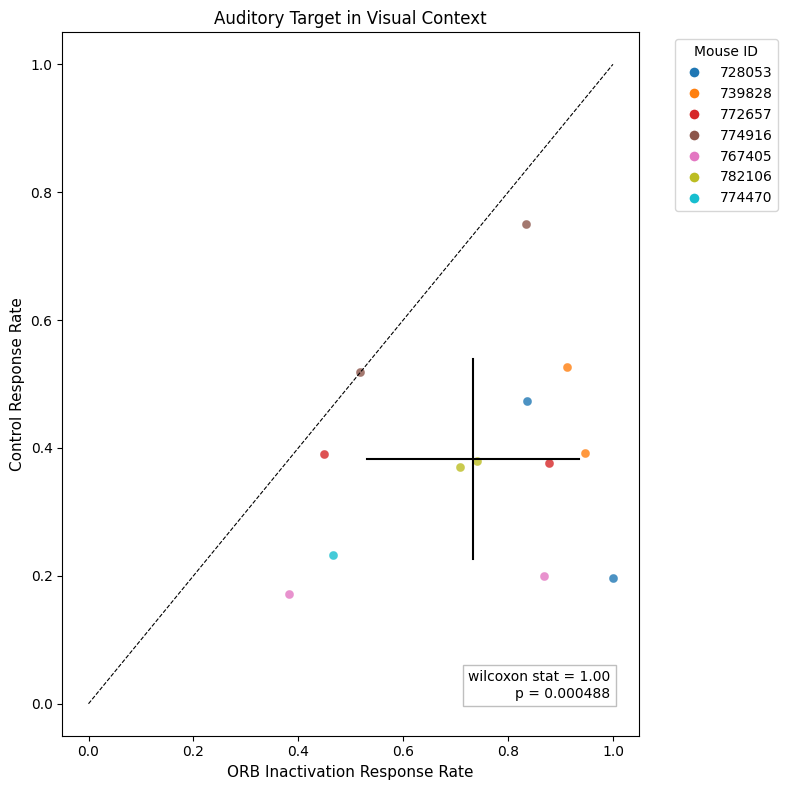

In [55]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import wilcoxon

# Assume muscimol_df_orb and previous cleaning steps are done

# --- Pair control and perturbation sessions for auditory target in visual context ---
paired_data_aud_vis = []
for i in range(1, len(muscimol_df_orb), 2):
    row1 = muscimol_df_orb.loc[i - 1]
    row2 = muscimol_df_orb.loc[i]
    if row1['control']:
        control_val = row1['auditory_target_in_visual_context']
        perturb_val = row2['auditory_target_in_visual_context']
        color_group = row1['color_group']
    else:
        control_val = row2['auditory_target_in_visual_context']
        perturb_val = row1['auditory_target_in_visual_context']
        color_group = row2['color_group']
    paired_data_aud_vis.append((perturb_val, control_val, color_group))

# --- Plot only one graph ---
fig, ax = plt.subplots(figsize=(8, 8))

# Scatter plot
for x, y, group in paired_data_aud_vis:
    ax.scatter(x, y, color=color_map[group], alpha=0.8, linewidth=0.2)

# Mean cross
x_vals = [x for x, _, _ in paired_data_aud_vis]
y_vals = [y for _, y, _ in paired_data_aud_vis]
x_mean, y_mean = np.mean(x_vals), np.mean(y_vals)
x_std, y_std = np.std(x_vals), np.std(y_vals)
ax.plot([x_mean - x_std, x_mean + x_std], [y_mean, y_mean], color='black', lw=1.5)
ax.plot([x_mean, x_mean], [y_mean - y_std, y_mean + y_std], color='black', lw=1.5)

# Unity line
ax.plot([0, 1], [0, 1], 'k--', linewidth=0.8)

# Axis labels and title
ax.set_xlabel('ORB Inactivation Response Rate', fontsize=11)
ax.set_ylabel('Control Response Rate', fontsize=11)
ax.set_title('Auditory Target in Visual Context', fontsize=12)

# Wilcoxon test
wilcoxon_stat, p_val = wilcoxon(x_vals, y_vals)
ax.text(0.95, 0.05, f'wilcoxon stat = {wilcoxon_stat:.2f}\np = {p_val:.3g}',
        transform=ax.transAxes, fontsize=10,
        verticalalignment='bottom', horizontalalignment='right',
        bbox=dict(facecolor='white', alpha=0.5, edgecolor='gray'))

# Legend
handles = [plt.Line2D([0], [0], marker='o', color='w',
                      markerfacecolor=color_map[group], markersize=8)
           for group in unique_groups]
ax.legend(handles, unique_groups, title="Mouse ID", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.savefig(r"Z:\vayle\muscimol_ORB_behavior_plots\ORB_target_stim_population_effects_unity_line_scatter_plot_single", dpi=300)
plt.show()

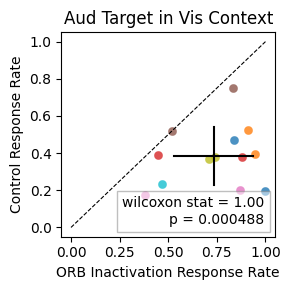

In [180]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import wilcoxon

# Assume muscimol_df_orb and previous cleaning steps are done

# --- Pair control and perturbation sessions for auditory target in visual context ---
paired_data_aud_vis = []
for i in range(1, len(muscimol_df_orb), 2):
    row1 = muscimol_df_orb.loc[i - 1]
    row2 = muscimol_df_orb.loc[i]
    if row1['control']:
        control_val = row1['auditory_target_in_visual_context']
        perturb_val = row2['auditory_target_in_visual_context']
        color_group = row1['color_group']
    else:
        control_val = row2['auditory_target_in_visual_context']
        perturb_val = row1['auditory_target_in_visual_context']
        color_group = row2['color_group']
    paired_data_aud_vis.append((perturb_val, control_val, color_group))

# --- Plot only one graph ---
fig, ax = plt.subplots(figsize=(3, 3))

# Scatter plot
for x, y, group in paired_data_aud_vis:
    ax.scatter(x, y, color=color_map[group], alpha=0.8, linewidth=0.2)

# Mean cross
x_vals = [x for x, _, _ in paired_data_aud_vis]
y_vals = [y for _, y, _ in paired_data_aud_vis]
x_mean, y_mean = np.mean(x_vals), np.mean(y_vals)
x_std, y_std = np.std(x_vals), np.std(y_vals)
ax.plot([x_mean - x_std, x_mean + x_std], [y_mean, y_mean], color='black', lw=1.5)
ax.plot([x_mean, x_mean], [y_mean - y_std, y_mean + y_std], color='black', lw=1.5)

# Unity line
ax.plot([0, 1], [0, 1], 'k--', linewidth=0.8)

# Axis labels and title
ax.set_xlabel('ORB Inactivation Response Rate', fontsize=10)
ax.set_ylabel('Control Response Rate', fontsize=10)
ax.set_title('Aud Target in Vis Context', fontsize=12)

# Wilcoxon test
wilcoxon_stat, p_val = wilcoxon(x_vals, y_vals)
ax.text(0.95, 0.05, f'wilcoxon stat = {wilcoxon_stat:.2f}\np = {p_val:.3g}',
        transform=ax.transAxes, fontsize=10,
        verticalalignment='bottom', horizontalalignment='right',
        bbox=dict(facecolor='white', alpha=0.5, edgecolor='gray'))

# Legend
handles = [plt.Line2D([0], [0], marker='o', color='w',
                      markerfacecolor=color_map[group], markersize=8)
           for group in unique_groups]
# ax.legend(handles, unique_groups, title="Mouse ID", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.savefig(r"Z:\vayle\muscimol_ORB_behavior_plots\ORB_aud_target_vis_context_unity_line_scatter", dpi=300)
plt.show()

## bar scatter plot for aud target in vis context ORB

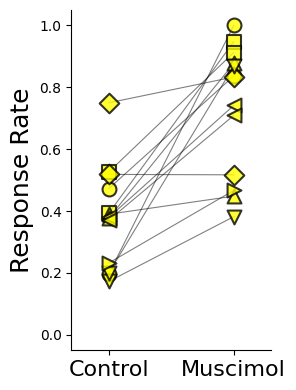

In [181]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import wilcoxon

# Pair control and perturbation sessions for auditory target in visual context
paired_data_aud_vis = []
for i in range(1, len(muscimol_df_orb), 2):
    row1 = muscimol_df_orb.loc[i - 1]
    row2 = muscimol_df_orb.loc[i]
    if row1['control']:
        control_val = row1['auditory_target_in_visual_context']
        perturb_val = row2['auditory_target_in_visual_context']
        color_group = row1['color_group']
    else:
        control_val = row2['auditory_target_in_visual_context']
        perturb_val = row1['auditory_target_in_visual_context']
        color_group = row2['color_group']
    paired_data_aud_vis.append((control_val, perturb_val, color_group))

# Create plot
fig, ax = plt.subplots(figsize=(3, 4))

# Define marker symbols for each group
unique_groups = muscimol_df_orb['color_group'].unique()
markers = ['o', 's', '^', 'D', 'v', '<', '>', 'p', '*', 'h', 'X', 'P']
marker_map = {group: markers[i % len(markers)] for i, group in enumerate(unique_groups)}

# X positions for control and muscimol
x_positions = [0, 1]

# Scatter dots and connecting lines
for ctrl, pert, group in paired_data_aud_vis:
    # Plot control point
    ax.scatter(0, ctrl, marker=marker_map[group], 
               facecolors='yellow', edgecolors='black', 
               s=100, linewidths=1.5, alpha=0.8, zorder=3)
    
    # Plot perturbation point
    ax.scatter(1, pert, marker=marker_map[group], 
               facecolors='yellow', edgecolors='black', 
               s=100, linewidths=1.5, alpha=0.8, zorder=3)
    
    # Draw connecting line
    ax.plot([0, 1], [ctrl, pert], 'k-', linewidth=0.8, alpha=0.5, zorder=2)

# # ...existing code...
# control_vals = [ctrl for ctrl, _, _ in paired_data_aud_vis]
# perturb_vals = [pert for _, pert, _ in paired_data_aud_vis]

# ctrl_mean, ctrl_std = np.mean(control_vals), np.std(control_vals)
# pert_mean, pert_std = np.mean(perturb_vals), np.std(perturb_vals)

# # Plot mean cross for control (at x=0)
# ax.plot([0, 0], [ctrl_mean - ctrl_std, ctrl_mean + ctrl_std], color='black', lw=2)  # vertical arm
# ax.plot([-0.05, 0.05], [ctrl_mean, ctrl_mean], color='black', lw=2)  # horizontal arm

# # Plot mean cross for muscimol (at x=1)
# ax.plot([1, 1], [pert_mean - pert_std, pert_mean + pert_std], color='black', lw=2)  # vertical arm
# ax.plot([0.95, 1.05], [pert_mean, pert_mean], color='black', lw=2)  # horizontal arm


# Get the current data range
buffer = 0.05
# ...existing code...
ax.margins(x=0.3, y=5)
# Axis labels and formatting
ax.set_ylim(0 - buffer, 1 + buffer)
ax.set_xticks([0, 1])
ax.set_xticklabels(['Control', 'Muscimol'], fontsize=16)
ax.set_ylabel('Response Rate', fontsize=18)
# ax.set_title('Aud Target in Vis Context', fontsize=14)

# Remove top and right spines
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

# Wilcoxon test
control_vals = [ctrl for ctrl, _, _ in paired_data_aud_vis]
perturb_vals = [pert for _, pert, _ in paired_data_aud_vis]
wilcoxon_stat, p_val = wilcoxon(control_vals, perturb_vals)
# ax.text(0.75, 0.95, f'Wilcoxon = {wilcoxon_stat:.2f}\np = {p_val:.3g}',
        # transform=ax.transAxes, fontsize=10,
        # verticalalignment='top', horizontalalignment='right',
        # bbox=dict(facecolor='white', alpha=0.7, edgecolor='gray'))

# Legend
handles = [plt.Line2D([0], [0], marker=marker_map[group], color='w',
                      markerfacecolor='yellow', markersize=8, 
                      markeredgecolor='black', markeredgewidth=1.5)
           for group in unique_groups]
# ax.legend(handles, unique_groups, title="Mouse ID", 
        #   bbox_to_anchor=(1.05, 1), loc='upper left',
        #   fontsize=8, title_fontsize=9)

plt.tight_layout()
plt.savefig(r"Z:\vayle\muscimol_ORB_behavior_plots\ORB_aud_target_vis_context_paired_plot.svg", 
            dpi=300, bbox_inches='tight')
plt.show()

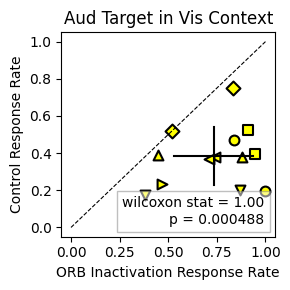

In [16]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import wilcoxon

# Assume muscimol_df_orb and previous cleaning steps are done

# --- Pair control and perturbation sessions for auditory target in visual context ---
paired_data_aud_vis = []
for i in range(1, len(muscimol_df_orb), 2):
    row1 = muscimol_df_orb.loc[i - 1]
    row2 = muscimol_df_orb.loc[i]
    if row1['control']:
        control_val = row1['auditory_target_in_visual_context']
        perturb_val = row2['auditory_target_in_visual_context']
        color_group = row1['color_group']
    else:
        control_val = row2['auditory_target_in_visual_context']
        perturb_val = row1['auditory_target_in_visual_context']
        color_group = row2['color_group']
    paired_data_aud_vis.append((perturb_val, control_val, color_group))

# --- Define marker symbols for each group ---
markers = ['o', 's', '^', 'D', 'v', '<', '>', 'p', '*', 'h']
marker_map = {group: markers[i % len(markers)] for i, group in enumerate(unique_groups)}

# --- Plot only one graph ---
fig, ax = plt.subplots(figsize=(3, 3))

# Scatter plot with different markers
for x, y, group in paired_data_aud_vis:
    ax.scatter(x, y, marker=marker_map[group], facecolors='yellow', edgecolors='black', 
               s=50, linewidths=1.5)

# Mean cross
x_vals = [x for x, _, _ in paired_data_aud_vis]
y_vals = [y for _, y, _ in paired_data_aud_vis]
x_mean, y_mean = np.mean(x_vals), np.mean(y_vals)
x_std, y_std = np.std(x_vals), np.std(y_vals)
ax.plot([x_mean - x_std, x_mean + x_std], [y_mean, y_mean], color='black', lw=1.5)
ax.plot([x_mean, x_mean], [y_mean - y_std, y_mean + y_std], color='black', lw=1.5)

# Unity line
ax.plot([0, 1], [0, 1], 'k--', linewidth=0.8)

# Axis labels and title
ax.set_xlabel('ORB Inactivation Response Rate', fontsize=10)
ax.set_ylabel('Control Response Rate', fontsize=10)
ax.set_title('Aud Target in Vis Context', fontsize=12)

# Wilcoxon test
wilcoxon_stat, p_val = wilcoxon(x_vals, y_vals)
ax.text(0.95, 0.05, f'wilcoxon stat = {wilcoxon_stat:.2f}\np = {p_val:.3g}',
        transform=ax.transAxes, fontsize=10,
        verticalalignment='bottom', horizontalalignment='right',
        bbox=dict(facecolor='white', alpha=0.5, edgecolor='gray'))

# Legend with marker symbols
handles = [plt.Line2D([0], [0], marker=marker_map[group], color='w',
                      markerfacecolor='yellow', markersize=8, markeredgecolor='black', markeredgewidth=1.5)
           for group in unique_groups]
# ax.legend(handles, unique_groups, title="Mouse ID", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.savefig(r"Z:\vayle\muscimol_ORB_behavior_plots\ORB_aud_target_vis_context_unity_line_scatter", dpi=300)
plt.show()

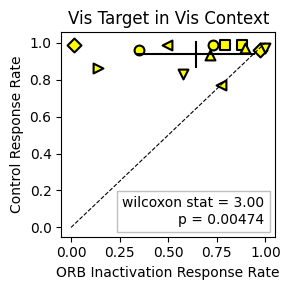

In [15]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import wilcoxon

# Assume muscimol_df_orb and previous cleaning steps are done

# --- Pair control and perturbation sessions for visual target in visual context ---
paired_data_vis_vis = []
for i in range(1, len(muscimol_df_orb), 2):
    row1 = muscimol_df_orb.loc[i - 1]
    row2 = muscimol_df_orb.loc[i]
    if row1['control']:
        control_val = row1['visual_target_in_visual_context']
        perturb_val = row2['visual_target_in_visual_context']
        color_group = row1['color_group']
    else:
        control_val = row2['visual_target_in_visual_context']
        perturb_val = row1['visual_target_in_visual_context']
        color_group = row2['color_group']
    paired_data_vis_vis.append((perturb_val, control_val, color_group))

# --- Define marker symbols for each group ---
markers = ['o', 's', '^', 'D', 'v', '<', '>', 'p', '*', 'h']
marker_map = {group: markers[i % len(markers)] for i, group in enumerate(unique_groups)}

# --- Plot only one graph ---
fig, ax = plt.subplots(figsize=(3, 3))

# Scatter plot with different markers
for x, y, group in paired_data_vis_vis:
    ax.scatter(x, y, marker=marker_map[group], facecolors='yellow', edgecolors='black', 
               s=50, linewidths=1.5)

# Mean cross
x_vals = [x for x, _, _ in paired_data_vis_vis]
y_vals = [y for _, y, _ in paired_data_vis_vis]
x_mean, y_mean = np.mean(x_vals), np.mean(y_vals)
x_std, y_std = np.std(x_vals), np.std(y_vals)
ax.plot([x_mean - x_std, x_mean + x_std], [y_mean, y_mean], color='black', lw=1.5)
ax.plot([x_mean, x_mean], [y_mean - y_std, y_mean + y_std], color='black', lw=1.5)

# Unity line
ax.plot([0, 1], [0, 1], 'k--', linewidth=0.8)

# Axis labels and title
ax.set_xlabel('ORB Inactivation Response Rate', fontsize=10)
ax.set_ylabel('Control Response Rate', fontsize=10)
ax.set_title('Vis Target in Vis Context', fontsize=12)

# Wilcoxon test
wilcoxon_stat, p_val = wilcoxon(x_vals, y_vals)
ax.text(0.95, 0.05, f'wilcoxon stat = {wilcoxon_stat:.2f}\np = {p_val:.3g}',
        transform=ax.transAxes, fontsize=10,
        verticalalignment='bottom', horizontalalignment='right',
        bbox=dict(facecolor='white', alpha=0.5, edgecolor='gray'))

# Legend with marker symbols
handles = [plt.Line2D([0], [0], marker=marker_map[group], color='w',
                      markerfacecolor='yellow', markersize=8, markeredgecolor='black', markeredgewidth=1.5)
           for group in unique_groups]
# ax.legend(handles, unique_groups, title="Mouse ID", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.savefig(r"Z:\vayle\muscimol_ORB_behavior_plots\ORB_vis_target_vis_context_unity_line_scatter", dpi=300)
plt.show()

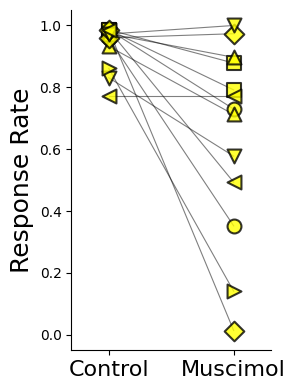

In [110]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import wilcoxon

# Pair control and perturbation sessions for auditory target in visual context
paired_data_vis_vis = []
for i in range(1, len(muscimol_df_orb), 2):
    row1 = muscimol_df_orb.loc[i - 1]
    row2 = muscimol_df_orb.loc[i]
    if row1['control']:
        control_val = row1['visual_target_in_visual_context']
        perturb_val = row2['visual_target_in_visual_context']
        color_group = row1['color_group']
    else:
        control_val = row2['visual_target_in_visual_context']
        perturb_val = row1['visual_target_in_visual_context']
        color_group = row2['color_group']
    paired_data_vis_vis.append((control_val, perturb_val, color_group))

# Create plot
fig, ax = plt.subplots(figsize=(3, 4))

# Define marker symbols for each group
unique_groups = muscimol_df_orb['color_group'].unique()
markers = ['o', 's', '^', 'D', 'v', '<', '>', 'p', '*', 'h', 'X', 'P']
marker_map = {group: markers[i % len(markers)] for i, group in enumerate(unique_groups)}

# X positions for control and muscimol
x_positions = [0, 1]

# Scatter dots and connecting lines
for ctrl, pert, group in paired_data_vis_vis:
    # Plot control point
    ax.scatter(0, ctrl, marker=marker_map[group], 
               facecolors='yellow', edgecolors='black', 
               s=100, linewidths=1.5, alpha=0.8, zorder=3)
    
    # Plot perturbation point
    ax.scatter(1, pert, marker=marker_map[group], 
               facecolors='yellow', edgecolors='black', 
               s=100, linewidths=1.5, alpha=0.8, zorder=3)
    
    # Draw connecting line
    ax.plot([0, 1], [ctrl, pert], 'k-', linewidth=0.8, alpha=0.5, zorder=2)

# ...existing code...
# control_vals = [ctrl for ctrl, _, _ in paired_data_vis_vis]
# perturb_vals = [pert for _, pert, _ in paired_data_vis_vis]

# ctrl_mean, ctrl_std = np.mean(control_vals), np.std(control_vals)
# pert_mean, pert_std = np.mean(perturb_vals), np.std(perturb_vals)

# # Plot mean cross for control (at x=0)
# ax.plot([0, 0], [ctrl_mean - ctrl_std, ctrl_mean + ctrl_std], color='black', lw=2)  # vertical arm
# ax.plot([-0.05, 0.05], [ctrl_mean, ctrl_mean], color='black', lw=2)  # horizontal arm

# # Plot mean cross for muscimol (at x=1)
# ax.plot([1, 1], [pert_mean - pert_std, pert_mean + pert_std], color='black', lw=2)  # vertical arm
# ax.plot([0.95, 1.05], [pert_mean, pert_mean], color='black', lw=2)  # horizontal arm


# Get the current data range
buffer = 0.05
# ...existing code...
ax.margins(x=0.3, y=5)
# Axis labels and formatting
ax.set_ylim(0 - buffer, 1 + buffer)
ax.set_xticks([0, 1])
ax.set_xticklabels(['Control', 'Muscimol'], fontsize=16)
ax.set_ylabel('Response Rate', fontsize=18)
# ax.set_title('Vis Target in Vis Context', fontsize=18)

# Remove top and right spines
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

# Wilcoxon test
control_vals = [ctrl for ctrl, _, _ in paired_data_vis_vis]
perturb_vals = [pert for _, pert, _ in paired_data_vis_vis]
wilcoxon_stat, p_val = wilcoxon(control_vals, perturb_vals)
# ax.text(0.75, 0.95, f'Wilcoxon = {wilcoxon_stat:.2f}\np = {p_val:.3g}',
        # transform=ax.transAxes, fontsize=10,
        # verticalalignment='top', horizontalalignment='right',
        # bbox=dict(facecolor='white', alpha=0.7, edgecolor='gray'))

# Legend
# handles = [plt.Line2D([0], [0], marker=marker_map[group], color='w',
#                       markerfacecolor='yellow', markersize=8, 
#                       markeredgecolor='black', markeredgewidth=1.5)
#            for group in unique_groups]
# ax.legend(handles, unique_groups, title="Mouse ID", 
        #   bbox_to_anchor=(1.05, 1), loc='upper left',
        #   fontsize=8, title_fontsize=9)

plt.tight_layout()
plt.savefig(r"Z:\vayle\muscimol_ORB_behavior_plots\ORB_vis_target_vis_context_paired_plot.svg", 
            dpi=300, bbox_inches='tight')
plt.show()

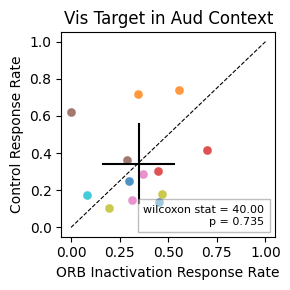

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import wilcoxon

# Assume muscimol_df_orb and previous cleaning steps are done

# --- Pair control and perturbation sessions for auditory target in visual context ---
paired_data_vis_aud = []
for i in range(1, len(muscimol_df_orb), 2):
    row1 = muscimol_df_orb.loc[i - 1]
    row2 = muscimol_df_orb.loc[i]
    if row1['control']:
        control_val = row1['visual_target_in_auditory_context']
        perturb_val = row2['visual_target_in_auditory_context']
        color_group = row1['color_group']
    else:
        control_val = row2['visual_target_in_auditory_context']
        perturb_val = row1['visual_target_in_auditory_context']
        color_group = row2['color_group']
    paired_data_vis_aud.append((perturb_val, control_val, color_group))

# --- Plot only one graph ---
fig, ax = plt.subplots(figsize=(3, 3))

# Scatter plot
for x, y, group in paired_data_vis_aud:
    ax.scatter(x, y, color=color_map[group], alpha=0.8, linewidth=0.2)

# Mean cross
x_vals = [x for x, _, _ in paired_data_vis_aud]
y_vals = [y for _, y, _ in paired_data_vis_aud]
x_mean, y_mean = np.mean(x_vals), np.mean(y_vals)
x_std, y_std = np.std(x_vals), np.std(y_vals)
ax.plot([x_mean - x_std, x_mean + x_std], [y_mean, y_mean], color='black', lw=1.5)
ax.plot([x_mean, x_mean], [y_mean - y_std, y_mean + y_std], color='black', lw=1.5)

# Unity line
ax.plot([0, 1], [0, 1], 'k--', linewidth=0.8)

# Axis labels and title
ax.set_xlabel('ORB Inactivation Response Rate', fontsize=10)
ax.set_ylabel('Control Response Rate', fontsize=10)
ax.set_title('Vis Target in Aud Context', fontsize=12)

# Wilcoxon test
wilcoxon_stat, p_val = wilcoxon(x_vals, y_vals)
ax.text(0.95, 0.05, f'wilcoxon stat = {wilcoxon_stat:.2f}\np = {p_val:.3g}',
        transform=ax.transAxes, fontsize=10,
        verticalalignment='bottom', horizontalalignment='right',
        bbox=dict(facecolor='white', alpha=0.5, edgecolor='gray'))

# Legend
handles = [plt.Line2D([0], [0], marker='o', color='w',
                      markerfacecolor=color_map[group], markersize=8)
           for group in unique_groups]
# ax.legend(handles, unique_groups, title="Mouse ID", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.savefig(r"Z:\vayle\muscimol_ORB_behavior_plots\ORB_vis_target_aud_context_unity_line_scatter", dpi=300)
plt.show()

In [5]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import wilcoxon

# Assume muscimol_df_orb and previous cleaning steps are done

# --- Pair control and perturbation sessions for auditory target in visual context ---
paired_data_vis_aud = []
for i in range(1, len(muscimol_df_orb), 2):
    row1 = muscimol_df_orb.loc[i - 1]
    row2 = muscimol_df_orb.loc[i]
    if row1['control']:
        control_val = row1['visual_target_in_auditory_context']
        perturb_val = row2['visual_target_in_auditory_context']
        color_group = row1['color_group']
    else:
        control_val = row2['visual_target_in_auditory_context']
        perturb_val = row1['visual_target_in_auditory_context']
        color_group = row2['color_group']
    paired_data_vis_aud.append((perturb_val, control_val, color_group))

# --- Plot only one graph ---
fig, ax = plt.subplots(figsize=(3, 3))

# Scatter plot with yellow symbols and black outline
for x, y, group in paired_data_vis_aud:
    ax.scatter(x, y, facecolors='yellow', edgecolors='black', 
               alpha=0.8, linewidth=1.5, s=50)

# Mean cross
x_vals = [x for x, _, _ in paired_data_vis_aud]
y_vals = [y for _, y, _ in paired_data_vis_aud]
x_mean, y_mean = np.mean(x_vals), np.mean(y_vals)
x_std, y_std = np.std(x_vals), np.std(y_vals)
ax.plot([x_mean - x_std, x_mean + x_std], [y_mean, y_mean], color='black', lw=1.5)
ax.plot([x_mean, x_mean], [y_mean - y_std, y_mean + y_std], color='black', lw=1.5)

# Unity line
ax.plot([0, 1], [0, 1], 'k--', linewidth=0.8)

# Axis labels and title
ax.set_xlabel('ORB Inactivation Response Rate', fontsize=10)
ax.set_ylabel('Control Response Rate', fontsize=10)
ax.set_title('Vis Target in Aud Context', fontsize=12)

# Wilcoxon test
wilcoxon_stat, p_val = wilcoxon(x_vals, y_vals)
ax.text(0.95, 0.05, f'wilcoxon stat = {wilcoxon_stat:.2f}\np = {p_val:.3g}',
        transform=ax.transAxes, fontsize=8,
        verticalalignment='bottom', horizontalalignment='right',
        bbox=dict(facecolor='white', alpha=0.5, edgecolor='gray'))

# Legend
handles = [plt.Line2D([0], [0], marker='o', color='w',
                      markerfacecolor='yellow', markeredgecolor='black', 
                      markeredgewidth=1.5, markersize=8)]
# ax.legend(handles, unique_groups, title="Mouse ID", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.savefig(r"Z:\vayle\muscimol_ORB_behavior_plots\ORB_vis_target_aud_context_unity_line_scatter", dpi=300)
plt.show()

KeyError: 'color_group'

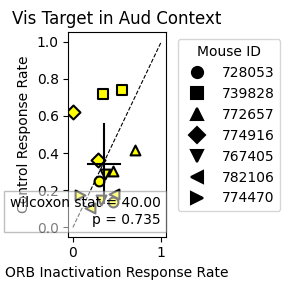

In [113]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import wilcoxon

# Assume muscimol_df_orb and previous cleaning steps are done

# --- Pair control and perturbation sessions for visual target in auditory context ---
paired_data_vis_aud = []
for i in range(1, len(muscimol_df_orb), 2):
    row1 = muscimol_df_orb.loc[i - 1]
    row2 = muscimol_df_orb.loc[i]
    if row1['control']:
        control_val = row1['visual_target_in_auditory_context']
        perturb_val = row2['visual_target_in_auditory_context']
        color_group = row1['color_group']
    else:
        control_val = row2['visual_target_in_auditory_context']
        perturb_val = row1['visual_target_in_auditory_context']
        color_group = row2['color_group']
    paired_data_vis_aud.append((perturb_val, control_val, color_group))

# --- Define marker symbols for each group ---
markers = ['o', 's', '^', 'D', 'v', '<', '>', 'p', '*', 'h']
marker_map = {group: markers[i % len(markers)] for i, group in enumerate(unique_groups)}

# --- Plot only one graph ---
fig, ax = plt.subplots(figsize=(3, 3))

# Scatter plot with different markers for each subject
for x, y, group in paired_data_vis_aud:
    ax.scatter(x, y, marker=marker_map[group], facecolors='yellow', edgecolors='black', 
               s=50, linewidths=1.5)

# Mean cross
x_vals = [x for x, _, _ in paired_data_vis_aud]
y_vals = [y for _, y, _ in paired_data_vis_aud]
x_mean, y_mean = np.mean(x_vals), np.mean(y_vals)
x_std, y_std = np.std(x_vals), np.std(y_vals)
ax.plot([x_mean - x_std, x_mean + x_std], [y_mean, y_mean], color='black', lw=1.5)
ax.plot([x_mean, x_mean], [y_mean - y_std, y_mean + y_std], color='black', lw=1.5)

# Unity line
ax.plot([0, 1], [0, 1], 'k--', linewidth=0.8)

# Axis labels and title
ax.set_xlabel('ORB Inactivation Response Rate', fontsize=10)
ax.set_ylabel('Control Response Rate', fontsize=10)
ax.set_title('Vis Target in Aud Context', fontsize=12)

# Wilcoxon test
wilcoxon_stat, p_val = wilcoxon(x_vals, y_vals)
ax.text(0.95, 0.05, f'wilcoxon stat = {wilcoxon_stat:.2f}\np = {p_val:.3g}',
        transform=ax.transAxes, fontsize=10,
        verticalalignment='bottom', horizontalalignment='right',
        bbox=dict(facecolor='white', alpha=0.5, edgecolor='gray'))

# Legend with marker symbols
handles = [plt.Line2D([0], [0], marker=marker_map[group], color='w',
                      markerfacecolor='yellow', markersize=8, markeredgecolor='black', markeredgewidth=1.5)
           for group in unique_groups]
# ax.legend(handles, unique_groups, title="Mouse ID", bbox_to_anchor=(1.05, 1), loc='upper left')
# // ...existing code...
handles = [plt.Line2D([0], [0], marker=marker_map[group], color='w',
                      markerfacecolor='black', markersize=8, markeredgecolor='black', markeredgewidth=1.5)
           for group in unique_groups]
ax.legend(handles, unique_groups, title="Mouse ID", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.savefig(r"Z:\vayle\muscimol_ORB_behavior_plots\ORB_vis_target_aud_context_unity_line_scatter", dpi=300)
plt.show()

In [24]:
# // ...existing code...
ax.text(0.95, 0.05, f'W = {wilcoxon_stat:.2f}\np = {p_val:.3g}',
        transform=ax.transAxes, fontsize=8,
        verticalalignment='bottom', horizontalalignment='right',
        bbox=dict(facecolor='white', alpha=0.5, edgecolor='gray'))
# // ...existing code...

Text(0.95, 0.05, 'W = 40.00\np = 0.735')

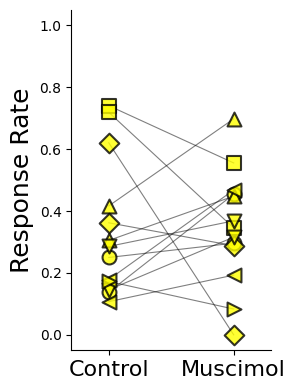

In [111]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import wilcoxon

# Pair control and perturbation sessions for auditory target in visual context
paired_data_vis_aud = []
for i in range(1, len(muscimol_df_orb), 2):
    row1 = muscimol_df_orb.loc[i - 1]
    row2 = muscimol_df_orb.loc[i]
    if row1['control']:
        control_val = row1['visual_target_in_auditory_context']
        perturb_val = row2['visual_target_in_auditory_context']
        color_group = row1['color_group']
    else:
        control_val = row2['visual_target_in_auditory_context']
        perturb_val = row1['visual_target_in_auditory_context']
        color_group = row2['color_group']
    paired_data_vis_aud.append((control_val, perturb_val, color_group))

# Create plot
fig, ax = plt.subplots(figsize=(3, 4))

# Define marker symbols for each group
unique_groups = muscimol_df_orb['color_group'].unique()
markers = ['o', 's', '^', 'D', 'v', '<', '>', 'p', '*', 'h', 'X', 'P']
marker_map = {group: markers[i % len(markers)] for i, group in enumerate(unique_groups)}

# X positions for control and muscimol
x_positions = [0, 1]

# Scatter dots and connecting lines
for ctrl, pert, group in paired_data_vis_aud:
    # Plot control point
    ax.scatter(0, ctrl, marker=marker_map[group], 
               facecolors='yellow', edgecolors='black', 
               s=100, linewidths=1.5, alpha=0.8, zorder=3)
    
    # Plot perturbation point
    ax.scatter(1, pert, marker=marker_map[group], 
               facecolors='yellow', edgecolors='black', 
               s=100, linewidths=1.5, alpha=0.8, zorder=3)
    
    # Draw connecting line
    ax.plot([0, 1], [ctrl, pert], 'k-', linewidth=0.8, alpha=0.5, zorder=2)

# ...existing code...
# control_vals = [ctrl for ctrl, _, _ in paired_data_vis_vis]
# perturb_vals = [pert for _, pert, _ in paired_data_vis_vis]

# ctrl_mean, ctrl_std = np.mean(control_vals), np.std(control_vals)
# pert_mean, pert_std = np.mean(perturb_vals), np.std(perturb_vals)

# # Plot mean cross for control (at x=0)
# ax.plot([0, 0], [ctrl_mean - ctrl_std, ctrl_mean + ctrl_std], color='black', lw=2)  # vertical arm
# ax.plot([-0.05, 0.05], [ctrl_mean, ctrl_mean], color='black', lw=2)  # horizontal arm

# # Plot mean cross for muscimol (at x=1)
# ax.plot([1, 1], [pert_mean - pert_std, pert_mean + pert_std], color='black', lw=2)  # vertical arm
# ax.plot([0.95, 1.05], [pert_mean, pert_mean], color='black', lw=2)  # horizontal arm


# Get the current data range
buffer = 0.05
# ...existing code...
ax.margins(x=0.3, y=5)
# Axis labels and formatting
ax.set_ylim(0 - buffer, 1 + buffer)
ax.set_xticks([0, 1])
ax.set_xticklabels(['Control', 'Muscimol'], fontsize=16)
ax.set_ylabel('Response Rate', fontsize=18)
# ax.set_title('Vis Target in Vis Context', fontsize=18)

# Remove top and right spines
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

# Wilcoxon test
control_vals = [ctrl for ctrl, _, _ in paired_data_vis_aud]
perturb_vals = [pert for _, pert, _ in paired_data_vis_aud]
wilcoxon_stat, p_val = wilcoxon(control_vals, perturb_vals)
# ax.text(0.75, 0.95, f'Wilcoxon = {wilcoxon_stat:.2f}\np = {p_val:.3g}',
        # transform=ax.transAxes, fontsize=10,
        # verticalalignment='top', horizontalalignment='right',
        # bbox=dict(facecolor='white', alpha=0.7, edgecolor='gray'))

# Legend
handles = [plt.Line2D([0], [0], marker=marker_map[group], color='w',
                      markerfacecolor='yellow', markersize=8, 
                      markeredgecolor='black', markeredgewidth=1.5)
           for group in unique_groups]
# ax.legend(handles, unique_groups, title="Mouse ID", 
        #   bbox_to_anchor=(1.05, 1), loc='upper left',
        #   fontsize=8, title_fontsize=9)

plt.tight_layout()
plt.savefig(r"Z:\vayle\muscimol_ORB_behavior_plots\ORB_vis_target_aud_context_paired_plot.svg", 
            dpi=300, bbox_inches='tight')
plt.show()

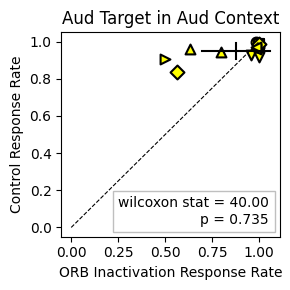

In [184]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import wilcoxon

# Assume muscimol_df_orb and previous cleaning steps are done

# --- Pair control and perturbation sessions for auditory target in auditory context ---
paired_data_aud_aud = []
for i in range(1, len(muscimol_df_orb), 2):
    row1 = muscimol_df_orb.loc[i - 1]
    row2 = muscimol_df_orb.loc[i]
    if row1['control']:
        control_val = row1['auditory_target_in_auditory_context']
        perturb_val = row2['auditory_target_in_auditory_context']
        color_group = row1['color_group']
    else:
        control_val = row2['auditory_target_in_auditory_context']
        perturb_val = row1['auditory_target_in_auditory_context']
        color_group = row2['color_group']
    paired_data_aud_aud.append((perturb_val, control_val, color_group))

# --- Define marker symbols for each group ---
markers = ['o', 's', '^', 'D', 'v', '<', '>', 'p', '*', 'h']
marker_map = {group: markers[i % len(markers)] for i, group in enumerate(unique_groups)}

# --- Plot only one graph ---
fig, ax = plt.subplots(figsize=(3, 3))

# Scatter plot with different markers for each subject
for x, y, group in paired_data_aud_aud:
    ax.scatter(x, y, marker=marker_map[group], facecolors='yellow', edgecolors='black', 
               s=50, linewidths=1.5)

# Mean cross
x_vals = [x for x, _, _ in paired_data_aud_aud]
y_vals = [y for _, y, _ in paired_data_aud_aud]
x_mean, y_mean = np.mean(x_vals), np.mean(y_vals)
x_std, y_std = np.std(x_vals), np.std(y_vals)
ax.plot([x_mean - x_std, x_mean + x_std], [y_mean, y_mean], color='black', lw=1.5)
ax.plot([x_mean, x_mean], [y_mean - y_std, y_mean + y_std], color='black', lw=1.5)

# Unity line
ax.plot([0, 1], [0, 1], 'k--', linewidth=0.8)

# Axis labels and title
ax.set_xlabel('ORB Inactivation Response Rate', fontsize=10)
ax.set_ylabel('Control Response Rate', fontsize=10)
ax.set_title('Aud Target in Aud Context', fontsize=12)

# Wilcoxon test
wilcoxon_stat, p_val = wilcoxon(x_vals, y_vals)
ax.text(0.95, 0.05, f'wilcoxon stat = {wilcoxon_stat:.2f}\np = {p_val:.3g}',
        transform=ax.transAxes, fontsize=10,
        verticalalignment='bottom', horizontalalignment='right',
        bbox=dict(facecolor='white', alpha=0.5, edgecolor='gray'))

# Legend with marker symbols
handles = [plt.Line2D([0], [0], marker=marker_map[group], color='w',
                      markerfacecolor='yellow', markersize=8, markeredgecolor='black', markeredgewidth=1.5)
           for group in unique_groups]
# ax.legend(handles, unique_groups, title="Mouse ID", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.savefig(r"Z:\vayle\muscimol_ORB_behavior_plots\ORB_aud_target_aud_context_unity_line_scatter", dpi=300)
plt.show()

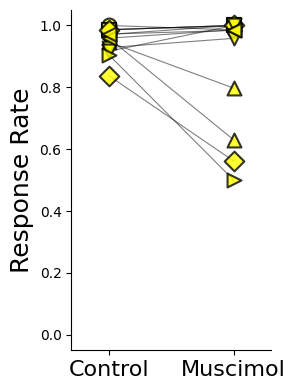

In [183]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import wilcoxon

# Pair control and perturbation sessions for auditory target in visual context
paired_data_aud_aud = []
for i in range(1, len(muscimol_df_orb), 2):
    row1 = muscimol_df_orb.loc[i - 1]
    row2 = muscimol_df_orb.loc[i]
    if row1['control']:
        control_val = row1['auditory_target_in_auditory_context']
        perturb_val = row2['auditory_target_in_auditory_context']
        color_group = row1['color_group']
    else:
        control_val = row2['auditory_target_in_auditory_context']
        perturb_val = row1['auditory_target_in_auditory_context']
        color_group = row2['color_group']
    paired_data_aud_aud.append((control_val, perturb_val, color_group))

# Create plot
fig, ax = plt.subplots(figsize=(3, 4))

# Define marker symbols for each group
unique_groups = muscimol_df_orb['color_group'].unique()
markers = ['o', 's', '^', 'D', 'v', '<', '>', 'p', '*', 'h', 'X', 'P']
marker_map = {group: markers[i % len(markers)] for i, group in enumerate(unique_groups)}

# X positions for control and muscimol
x_positions = [0, 1]

# Scatter dots and connecting lines
for ctrl, pert, group in paired_data_aud_aud:
    # Plot control point
    ax.scatter(0, ctrl, marker=marker_map[group], 
               facecolors='yellow', edgecolors='black', 
               s=100, linewidths=1.5, alpha=0.8, zorder=3)
    
    # Plot perturbation point
    ax.scatter(1, pert, marker=marker_map[group], 
               facecolors='yellow', edgecolors='black', 
               s=100, linewidths=1.5, alpha=0.8, zorder=3)
    
    # Draw connecting line
    ax.plot([0, 1], [ctrl, pert], 'k-', linewidth=0.8, alpha=0.5, zorder=2)

# ...existing code...
# control_vals = [ctrl for ctrl, _, _ in paired_data_vis_vis]
# perturb_vals = [pert for _, pert, _ in paired_data_vis_vis]

# ctrl_mean, ctrl_std = np.mean(control_vals), np.std(control_vals)
# pert_mean, pert_std = np.mean(perturb_vals), np.std(perturb_vals)

# # Plot mean cross for control (at x=0)
# ax.plot([0, 0], [ctrl_mean - ctrl_std, ctrl_mean + ctrl_std], color='black', lw=2)  # vertical arm
# ax.plot([-0.05, 0.05], [ctrl_mean, ctrl_mean], color='black', lw=2)  # horizontal arm

# # Plot mean cross for muscimol (at x=1)
# ax.plot([1, 1], [pert_mean - pert_std, pert_mean + pert_std], color='black', lw=2)  # vertical arm
# ax.plot([0.95, 1.05], [pert_mean, pert_mean], color='black', lw=2)  # horizontal arm


# Get the current data range
buffer = 0.05
# ...existing code...
ax.margins(x=0.3, y=5)
# Axis labels and formatting
ax.set_ylim(0 - buffer, 1 + buffer)
ax.set_xticks([0, 1])
ax.set_xticklabels(['Control', 'Muscimol'], fontsize=16)
ax.set_ylabel('Response Rate', fontsize=18)
# ax.set_title('Vis Target in Vis Context', fontsize=18)

# Remove top and right spines
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

# Wilcoxon test
control_vals = [ctrl for ctrl, _, _ in paired_data_aud_aud]
perturb_vals = [pert for _, pert, _ in paired_data_aud_aud]
wilcoxon_stat, p_val = wilcoxon(control_vals, perturb_vals)
# ax.text(0.75, 0.95, f'Wilcoxon = {wilcoxon_stat:.2f}\np = {p_val:.3g}',
        # transform=ax.transAxes, fontsize=10,
        # verticalalignment='top', horizontalalignment='right',
        # bbox=dict(facecolor='white', alpha=0.7, edgecolor='gray'))

# Legend
handles = [plt.Line2D([0], [0], marker=marker_map[group], color='w',
                      markerfacecolor='yellow', markersize=8, 
                      markeredgecolor='black', markeredgewidth=1.5)
           for group in unique_groups]
# ax.legend(handles, unique_groups, title="Mouse ID", 
        #   bbox_to_anchor=(1.05, 1), loc='upper left',
        #   fontsize=8, title_fontsize=9)

plt.tight_layout()
plt.savefig(r"Z:\vayle\muscimol_ORB_behavior_plots\ORB_aud_target_aud_context_paired_plot.svg", 
            dpi=300, bbox_inches='tight')
plt.show()

## Cross modal d' plots

In [ ]:
def extract_base_id(session_id):
    return "_".join(session_id.split("_")[:-1])

Mean cross-modality d-prime in visual context: -1.6919773960224582
     start_time    stop_time  block_index  n_trials  n_responses  n_hits  \
id                                                                         
0      3.236053   604.506242            0        91           21       2   
1    604.606335  1211.847935            1        87           42      23   
2   1211.914684  1816.337230            2        85           44       9   
3   1816.837633  2422.678006            3        90           45      23   
4   2423.395270  3025.682687            4        84           44      14   
5   3025.932895  3627.286161            5        88           54      23   

    n_contingent_rewards  hit_rate  false_alarm_rate  catch_response_rate  \
id                                                                          
0                      2  0.080000          0.345455             1.909091   
1                     23  0.958333          0.380000             3.230769   
2               

In [185]:
muscimol_dprime_orb = []

#def(mouse, perturbation or control)
session_ids = ['728053_2024-11-18','728053_2024-11-19', '728053_2024-11-20', '728053_2024-11-21','774470_2025-07-29','774470_2025-07-30','782106_2025-07-07','782106_2025-07-14','782106_2025-07-08', '782106_2025-07-15','767405_2025-05-19','767405_2025-05-20', '767405_2025-05-28', '767405_2025-05-29','739828_2025-02-10','739828_2025-02-11','739828_2025-02-17', '739828_2025-02-18','774916_2025-03-24', '774916_2025-03-25', '774916_2025-03-31', '774916_2025-04-01', '772657_2025-02-24', '772657_2025-02-25', '772657_2025-03-03', '772657_2025-03-04']
control = ['728053_2024-11-18', '728053_2024-11-20','774470_2025-07-29','782106_2025-07-07','782106_2025-07-14','767405_2025-05-28','767405_2025-05-19','739828_2025-02-10','739828_2025-02-17','772657_2025-02-24', '772657_2025-03-03', '774916_2025-03-24', '774916_2025-03-31']
perturbation = ['728053_2024-11-19', '728053_2024-11-21','774470_2025-07-30','782106_2025-07-08', '782106_2025-07-15','767405_2025-05-29','767405_2025-05-20','739828_2025-02-11','739828_2025-02-18', '772657_2025-02-25', '772657_2025-03-04','774916_2025-03-25', '774916_2025-04-01']
# quiescent_violations = {
#     'control': [47, 44, 79, 40, 36, 37, 32, 7, 62, 22, 20],
#     'perturbation':[42, 87, 209, 66, 88, 74, 82, 21, 47, 34, 56]
# }
# qv = { 'qv': [47, 42, 44, 79, 87, 209, 40, 66, 36, 88, 37, 74, 32, 82, 7, 21, 62, 47, 22, 34, 20, 56 ] }


vis_first_perturbations = []
aud_first_perturbations=[]
# quiescent_violations = [47, 42, 44, 79, 87, 209, 40, 66, 36, 88, 37, 74, 32, 82, 7, 21, 62, 47, 22, 34, 20, 56]


for i, session_id in enumerate(session_ids):
    session = npc_sessions.Session(session_id)
   
    
#vis cross modal d prime
    vis_context = session.performance[:].query("rewarded_modality == 'vis'")
    vis_dprimes = vis_context['cross_modality_dprime'].dropna()  # Remove NaN values
    cross_modality_dprime_vis_context = np.mean(vis_dprimes) if len(vis_dprimes) > 0 else np.nan

#aud cross modal d prime
    aud_context = session.performance[:].query("rewarded_modality == 'aud'")
    aud_dprimes = aud_context['cross_modality_dprime'].dropna()  # Remove NaN values
    cross_modality_dprime_aud_context = np.mean(aud_dprimes) if len(aud_dprimes) > 0 else np.nan



    result = dict(
                    session_id=session,
                    control = session_id in control,
                    perturbation = session_id in perturbation,
                    cross_modality_dprime_vis_context=cross_modality_dprime_vis_context,
                    cross_modality_dprime_aud_context=cross_modality_dprime_aud_context,
                    )
    
#     if session in perturbation:
#             result['perturbation'] = True
#     else:
#             result['control'] = True

    muscimol_dprime_orb.append(result)

# print(muscimol_data)
muscimol_dprime_orb = pd.DataFrame(muscimol_dprime_orb)
print(muscimol_dprime_orb)

muscimol_dprime_orb['color_group'] = muscimol_dprime_orb['session_id'].apply(extract_mouse_id)


                                    session_id  control  perturbation  \
0   DynamicRoutingSession('728053_2024-11-18')     True         False   
1   DynamicRoutingSession('728053_2024-11-19')    False          True   
2   DynamicRoutingSession('728053_2024-11-20')     True         False   
3   DynamicRoutingSession('728053_2024-11-21')    False          True   
4   DynamicRoutingSession('774470_2025-07-29')     True         False   
5   DynamicRoutingSession('774470_2025-07-30')    False          True   
6   DynamicRoutingSession('782106_2025-07-07')     True         False   
7   DynamicRoutingSession('782106_2025-07-14')     True         False   
8   DynamicRoutingSession('782106_2025-07-08')    False          True   
9   DynamicRoutingSession('782106_2025-07-15')    False          True   
10  DynamicRoutingSession('767405_2025-05-19')     True         False   
11  DynamicRoutingSession('767405_2025-05-20')    False          True   
12  DynamicRoutingSession('767405_2025-05-28')     

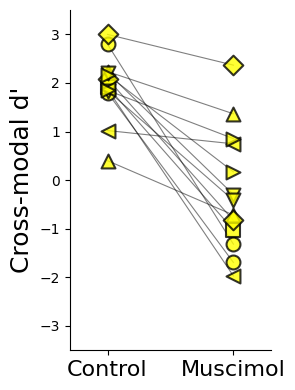

In [192]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import wilcoxon

# Pair control and perturbation sessions for auditory target in visual context
paired_data_vis_dprimes = []
for i in range(1, len(muscimol_dprime_orb), 2):
    row1 = muscimol_dprime_orb.loc[i - 1]
    row2 = muscimol_dprime_orb.loc[i]
    if row1['control']:
        control_val = row1['cross_modality_dprime_vis_context']
        perturb_val = row2['cross_modality_dprime_vis_context']
        color_group = row1['color_group']
    else:
        control_val = row2['cross_modality_dprime_vis_context']
        perturb_val = row1['cross_modality_dprime_vis_context']
        color_group = row2['color_group']
    paired_data_vis_dprimes.append((control_val, perturb_val, color_group))

# Create plot
fig, ax = plt.subplots(figsize=(3, 4))

# Define marker symbols for each group
unique_groups = muscimol_dprime_orb['color_group'].unique()
markers = ['o', 's', '^', 'D', 'v', '<', '>', 'p', '*', 'h', 'X', 'P']
marker_map = {group: markers[i % len(markers)] for i, group in enumerate(unique_groups)}

# X positions for control and muscimol
x_positions = [0, 1]

# Scatter dots and connecting lines
for ctrl, pert, group in paired_data_vis_dprimes:
    # Plot control point
    ax.scatter(0, ctrl, marker=marker_map[group], 
               facecolors='yellow', edgecolors='black', 
               s=100, linewidths=1.5, alpha=0.8, zorder=3)
    
    # Plot perturbation point
    ax.scatter(1, pert, marker=marker_map[group], 
               facecolors='yellow', edgecolors='black', 
               s=100, linewidths=1.5, alpha=0.8, zorder=3)
    
    # Draw connecting line
    ax.plot([0, 1], [ctrl, pert], 'k-', linewidth=0.8, alpha=0.5, zorder=2)

# ...existing code...
# control_vals = [ctrl for ctrl, _, _ in paired_data_vis_vis]
# perturb_vals = [pert for _, pert, _ in paired_data_vis_vis]

# ctrl_mean, ctrl_std = np.mean(control_vals), np.std(control_vals)
# pert_mean, pert_std = np.mean(perturb_vals), np.std(perturb_vals)

# # Plot mean cross for control (at x=0)
# ax.plot([0, 0], [ctrl_mean - ctrl_std, ctrl_mean + ctrl_std], color='black', lw=2)  # vertical arm
# ax.plot([-0.05, 0.05], [ctrl_mean, ctrl_mean], color='black', lw=2)  # horizontal arm

# # Plot mean cross for muscimol (at x=1)
# ax.plot([1, 1], [pert_mean - pert_std, pert_mean + pert_std], color='black', lw=2)  # vertical arm
# ax.plot([0.95, 1.05], [pert_mean, pert_mean], color='black', lw=2)  # horizontal arm


# Get the current data range
buffer = 0.5
# ...existing code...
ax.margins(x=0.3, y=5)
# Axis labels and formatting
ax.set_ylim(-3 - buffer, 3 + buffer)
ax.set_xticks([0, 1])
ax.set_xticklabels(['Control', 'Muscimol'], fontsize=16)
ax.set_ylabel("Cross-modal d'", fontsize=18)
# ax.set_title('Vis Target in Vis Context', fontsize=18)

# Remove top and right spines
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

# Wilcoxon test
control_vals = [ctrl for ctrl, _, _ in paired_data_vis_dprimes]
perturb_vals = [pert for _, pert, _ in paired_data_vis_dprimes]
wilcoxon_stat, p_val = wilcoxon(control_vals, perturb_vals)
# ax.text(0.75, 0.95, f'Wilcoxon = {wilcoxon_stat:.2f}\np = {p_val:.3g}',
        # transform=ax.transAxes, fontsize=10,
        # verticalalignment='top', horizontalalignment='right',
        # bbox=dict(facecolor='white', alpha=0.7, edgecolor='gray'))
# 
# Legend
# handles = [plt.Line2D([0], [0], marker=marker_map[group], color='w',
#                       markerfacecolor='yellow', markersize=8, 
#                       markeredgecolor='black', markeredgewidth=1.5)
#            for group in unique_groups]
# ax.legend(handles, unique_groups, title="Mouse ID", 
        #   bbox_to_anchor=(1.05, 1), loc='upper left',
        #   fontsize=8, title_fontsize=9)

plt.tight_layout()
plt.savefig(r"Z:\vayle\muscimol_ORB_behavior_plots\ORB_vis_crossmodal_dprimes.svg", 
            dpi=300, bbox_inches='tight')
plt.show()

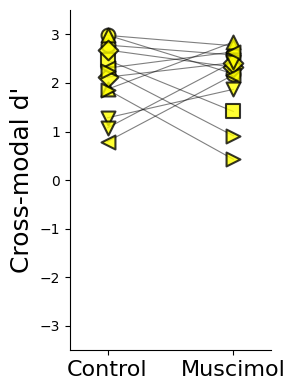

In [195]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import wilcoxon

# Pair control and perturbation sessions for auditory target in visual context
paired_data_aud_dprimes = []
for i in range(1, len(muscimol_dprime_orb), 2):
    row1 = muscimol_dprime_orb.loc[i - 1]
    row2 = muscimol_dprime_orb.loc[i]
    if row1['control']:
        control_val = row1['cross_modality_dprime_aud_context']
        perturb_val = row2['cross_modality_dprime_aud_context']
        color_group = row1['color_group']
    else:
        control_val = row2['cross_modality_dprime_aud_context']
        perturb_val = row1['cross_modality_dprime_aud_context']
        color_group = row2['color_group']
    paired_data_aud_dprimes.append((control_val, perturb_val, color_group))

# Create plot
fig, ax = plt.subplots(figsize=(3, 4))

# Define marker symbols for each group
unique_groups = muscimol_dprime_orb['color_group'].unique()
markers = ['o', 's', '^', 'D', 'v', '<', '>', 'p', '*', 'h', 'X', 'P']
marker_map = {group: markers[i % len(markers)] for i, group in enumerate(unique_groups)}

# X positions for control and muscimol
x_positions = [0, 1]

# Scatter dots and connecting lines
for ctrl, pert, group in paired_data_aud_dprimes:
    # Plot control point
    ax.scatter(0, ctrl, marker=marker_map[group], 
               facecolors='yellow', edgecolors='black', 
               s=100, linewidths=1.5, alpha=0.8, zorder=3)
    
    # Plot perturbation point
    ax.scatter(1, pert, marker=marker_map[group], 
               facecolors='yellow', edgecolors='black', 
               s=100, linewidths=1.5, alpha=0.8, zorder=3)
    
    # Draw connecting line
    ax.plot([0, 1], [ctrl, pert], 'k-', linewidth=0.8, alpha=0.5, zorder=2)

# ...existing code...
# control_vals = [ctrl for ctrl, _, _ in paired_data_vis_vis]
# perturb_vals = [pert for _, pert, _ in paired_data_vis_vis]

# ctrl_mean, ctrl_std = np.mean(control_vals), np.std(control_vals)
# pert_mean, pert_std = np.mean(perturb_vals), np.std(perturb_vals)

# # Plot mean cross for control (at x=0)
# ax.plot([0, 0], [ctrl_mean - ctrl_std, ctrl_mean + ctrl_std], color='black', lw=2)  # vertical arm
# ax.plot([-0.05, 0.05], [ctrl_mean, ctrl_mean], color='black', lw=2)  # horizontal arm

# # Plot mean cross for muscimol (at x=1)
# ax.plot([1, 1], [pert_mean - pert_std, pert_mean + pert_std], color='black', lw=2)  # vertical arm
# ax.plot([0.95, 1.05], [pert_mean, pert_mean], color='black', lw=2)  # horizontal arm


# Get the current data range
buffer = 0.5
# ...existing code...
ax.margins(x=0.3, y=5)
# Axis labels and formatting
ax.set_ylim(-3 - buffer, 3 + buffer)
ax.set_xticks([0, 1])
ax.set_xticklabels(['Control', 'Muscimol'], fontsize=16)
ax.set_ylabel("Cross-modal d'", fontsize=18)
# ax.set_title('Vis Target in Vis Context', fontsize=18)

# Remove top and right spines
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

# Wilcoxon test
control_vals = [ctrl for ctrl, _, _ in paired_data_aud_dprimes]
perturb_vals = [pert for _, pert, _ in paired_data_aud_dprimes]
wilcoxon_stat, p_val = wilcoxon(control_vals, perturb_vals)
# ax.text(0.75, 0.95, f'Wilcoxon = {wilcoxon_stat:.2f}\np = {p_val:.3g}',
#         transform=ax.transAxes, fontsize=10,
#         verticalalignment='top', horizontalalignment='right',
#         bbox=dict(facecolor='white', alpha=0.7, edgecolor='gray'))
# # 
# Legend
# handles = [plt.Line2D([0], [0], marker=marker_map[group], color='w',
#                       markerfacecolor='yellow', markersize=8, 
#                       markeredgecolor='black', markeredgewidth=1.5)
#            for group in unique_groups]
# ax.legend(handles, unique_groups, title="Mouse ID", 
        #   bbox_to_anchor=(1.05, 1), loc='upper left',
        #   fontsize=8, title_fontsize=9)

plt.tight_layout()
plt.savefig(r"Z:\vayle\muscimol_ORB_behavior_plots\ORB_aud_crossmodal_dprimes.svg", 
            dpi=300, bbox_inches='tight')
plt.show()

## ORB: Nontargets unity line scatter plot

In [ ]:
vis_nontarget_vis_context_responses=vis_nontarget_vis_context_responses,
                    aud_nontarget_vis_context_responses=aud_nontarget_vis_context_responses,
                    vis_nontarget_aud_context_responses=vis_nontarget_aud_context_responses,
                    aud_nontarget_aud_context_responses=aud_nontarget_aud_context_responses

C:\Users\vayle.lafehr\AppData\Local\Temp\ipykernel_19772\3783915495.py:19: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', len(unique_groups))


(0.6792452830188679, 0.1320754716981132, '728053')
(0.7719298245614035, 0.08928571428571429, '728053')
(0.3333333333333333, 0.07407407407407407, '739828')
(0.12280701754385964, 0.018518518518518517, '739828')
(0.2545454545454545, 0.1694915254237288, '772657')
(0.48214285714285715, 0.09836065573770492, '772657')
(0.39344262295081966, 0.25862068965517243, '774916')
(0.15254237288135594, 0.26785714285714285, '774916')
(0.19642857142857142, 0.03333333333333333, '767405')
(0.3620689655172414, 0.034482758620689655, '767405')
(0.3275862068965517, 0.15, '782106')
(0.2549019607843137, 0.09433962264150944, '782106')
(0.25, 0.10344827586206896, '774470')
(0.038461538461538464, 0.0, '728053')
(0.0, 0.0, '728053')
(0.21052631578947367, 0.06896551724137931, '739828')
(0.08771929824561403, 0.03571428571428571, '739828')
(0.01694915254237288, 0.017241379310344827, '772657')
(0.01694915254237288, 0.06557377049180328, '772657')
(0.13333333333333333, 0.1896551724137931, '774916')
(0.0, 0.0344827586206896

<Figure size 2000x2000 with 0 Axes>

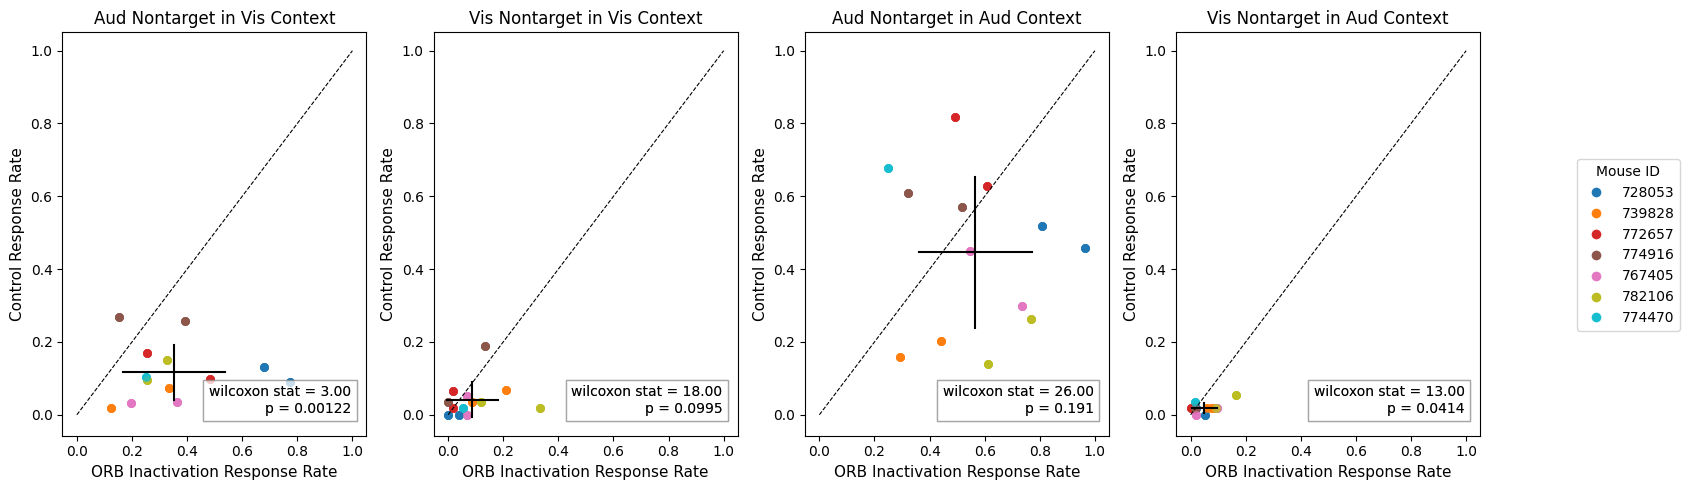

In [43]:
import matplotlib.pyplot as plt
from datetime import datetime
from scipy import stats


#clean
muscimol_df_orb['color_group'] = muscimol_df_orb['session_id'].apply(
    lambda x: x.split('_')[0].split('(')[1].strip("'")
)

# Sort by date
muscimol_df_orb['date'] = muscimol_df_orb['session_id'].apply(
    lambda x: datetime.strptime(x.split('_')[1].split("'")[0], '%Y-%m-%d')
)
muscimol_df_orb = muscimol_df_orb.sort_values(by='date').reset_index(drop=True)

# unique colors bymouse ID
unique_groups = muscimol_df_orb['color_group'].unique()
colors = plt.cm.get_cmap('tab10', len(unique_groups))
color_map = {group: colors(i) for i, group in enumerate(unique_groups)}

# Pair control and perturbation sessions
paired_data_vis_vis = []
for i in range(1, len(muscimol_df_orb), 2):
    row1 = muscimol_df_orb.loc[i - 1]
    row2 = muscimol_df_orb.loc[i]
    if row1['control']:
        control_val = row1['vis_nontarget_vis_context_responses']
        perturb_val = row2['vis_nontarget_vis_context_responses']
        color_group = row1['color_group']
    else:
        control_val = row2['vis_nontarget_vis_context_responses']
        perturb_val = row1['vis_nontarget_vis_context_responses']
        color_group = row2['color_group']
    paired_data_vis_vis.append((perturb_val, control_val, color_group))

    paired_data_aud_vis = []
for i in range(1, len(muscimol_df_orb), 2):
    row1 = muscimol_df_orb.loc[i - 1]
    row2 = muscimol_df_orb.loc[i]
    if row1['control']:
        control_val_1 = row1['aud_nontarget_vis_context_responses']
        perturb_val_1 = row2['aud_nontarget_vis_context_responses']
        color_group = row1['color_group']
    else:
        control_val_1 = row2['aud_nontarget_vis_context_responses']
        perturb_val_1 = row1['aud_nontarget_vis_context_responses']
        color_group = row2['color_group']
    paired_data_aud_vis.append((perturb_val_1, control_val_1, color_group))

    paired_data_vis_aud = []
for i in range(1, len(muscimol_df_orb), 2):
    row1 = muscimol_df_orb.loc[i - 1]
    row2 = muscimol_df_orb.loc[i]
    if row1['control']:
        control_val_2 = row1['vis_nontarget_aud_context_responses']
        perturb_val_2 = row2['vis_nontarget_aud_context_responses']
        color_group = row1['color_group']
    else:
        control_val_2 = row2['vis_nontarget_aud_context_responses']
        perturb_val_2 = row1['vis_nontarget_aud_context_responses']
        color_group = row2['color_group']
    paired_data_vis_aud.append((perturb_val_2, control_val_2, color_group))

    paired_data_aud_aud = []
for i in range(1, len(muscimol_df_orb), 2):
    row1 = muscimol_df_orb.loc[i - 1]
    row2 = muscimol_df_orb.loc[i]
    if row1['control']:
        control_val_3 = row1['aud_nontarget_aud_context_responses']
        perturb_val_3 = row2['aud_nontarget_aud_context_responses']
        color_group = row1['color_group']
    else:
        control_val_3 = row2['aud_nontarget_aud_context_responses']
        perturb_val_3 = row1['aud_nontarget_aud_context_responses']
        color_group = row2['color_group']
    paired_data_aud_aud.append((perturb_val_3, control_val_3, color_group))

# Create scatter plot with x = perturbation, y = control
plt.figure(figsize=(20, 20))

# data = [paired_data_vis_vis, paired_data_aud_vis]
# for datum in data:
#     for x, y, group in datum:
#         print((x,y,group))
#         plt.scatter(x, y, color=color_map[group], label=group, alpha=0.8, linewidth = 0.2)
#         plt.scatter(x, y, color=color_map[group], label=group, alpha=0.8)

fig, axes = plt.subplots(1, 4, figsize=(15, 5), sharex=True, sharey=True)

contexts = ['Aud Nontarget in Vis Context','Vis Nontarget in Vis Context', 'Aud Nontarget in Aud Context', 'Vis Nontarget in Aud Context']
data = [paired_data_aud_vis, paired_data_vis_vis, paired_data_aud_aud, paired_data_vis_aud]

#make test star for plot


    
#organize paired data

paired_data_sets ={
    'aud_vis': paired_data_aud_vis,
    'vis_vis': paired_data_vis_vis,
    'aud_aud': paired_data_aud_aud,
    'vis_aud': paired_data_vis_aud,
}
    

#mean cross


for ax, (label, paired_data) in zip(axes, paired_data_sets.items()):
    x_vals = [x for x, _, _ in paired_data]
    y_vals = [y for _, y, _ in paired_data]
    # print(f"{label} - x_vals: {x_vals}, y_vals: {y_vals}")
    
    x_mean, y_mean = np.mean(x_vals), np.mean(y_vals)
    x_std, y_std = np.std(x_vals), np.std(y_vals)
    ax.plot([x_mean - x_std, x_mean +x_std], [y_mean, y_mean], color='black', lw=1.5)
    ax.plot([x_mean, x_mean], [y_mean - y_std, y_mean + y_std], color='black', lw=1.5)


    for ax, datum, title in zip(axes, data, contexts):
        for x, y, group in datum:
            print((x, y, group))
            ax.scatter(x, y, color=color_map[group], alpha=0.8, linewidth=0.2)





# for ax in axes:
    # ax.errorbar(np.mean(x_vals), np.mean(y_vals), xerr=x_std, yerr=y_std, fmt='o', color='black', markersize=5, label='Mean ± Std Dev', alpha=0.5)
# unity line

for ax in axes:
    ax.plot([0, 1], [0, 1], 'k--', linewidth=0.8)  # Unity line for each subplot
# plt.plot([0, 1], [0, 1], 'k--')


# ax.set_xlim(0, 1)
# ax.set_ylim(0, 1)
#adds space to plot size
# x_vals = [x for x, _, _ in paired_data]
# y_vals = [y for _, y, _ in paired_data]

# x_min, x_max = min(x_vals), max(x_vals)
# y_min, y_max = min(y_vals), max(y_vals)

# padding_x = (x_max - x_min) * 0.05  # 5% padding
# padding_y = (y_max - y_min) * 0.05

# ax.set_xlim(x_min - padding_x, x_max + padding_x)
# ax.set_ylim(y_min - padding_y, y_max + padding_y)


for ax, x_label in zip(axes, 'ORB Inactivation Response Rate'):
    ax.set_xlabel('ORB Inactivation Response Rate', fontsize =11)


for ax, y_label in zip(axes, 'Control Response Rate'):
    ax.set_ylabel('Control Response Rate', fontsize=11)
# ax.set_title(f'{c for c in contexts}', fontsize=12)

for ax, title in zip(axes, contexts):
    ax.set_title(f'{title}', fontsize=12)

for ax in axes:
    ax.yaxis.set_tick_params(labelleft=True)
# ax.grid(True)
for ax, (label, paired_data) in zip(axes, paired_data_sets.items()):
    x_vals = [x for x, _, _ in paired_data]  # Perturbation
    y_vals = [y for _, y, _ in paired_data]  # Control

    # Run paired t-test
    from scipy.stats import wilcoxon

    wilcoxon_stat, p_val = wilcoxon(x_vals, y_vals)
    ax.text(0.95, 0.05, f'wilcoxon stat = {wilcoxon_stat:.2f}\np = {p_val:.3g}',
            transform=ax.transAxes, fontsize=10,
            verticalalignment='bottom', horizontalalignment='right',
            bbox=dict(facecolor='white', alpha=0.5, edgecolor='gray'))

    # Plot scatter and mean cross as before...
    # [your existing plotting code here]

    # Annotate with t-test result
    ax.text(0.95, 0.05, f'wilcoxon stat = {wilcoxon_stat:.2f}\np = {p_val:.3g}',
            transform=ax.transAxes, fontsize=10,
            verticalalignment='bottom', horizontalalignment='right', bbox=dict(facecolor='white', alpha=0.5, edgecolor='gray'))

# Create legend with unique mouse IDs
# handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=color_map[group], markersize=8) for group in unique_groups]
# plt.legend(handles, unique_groups, title="Mouse ID", bbox_to_anchor=(1.05, 1), loc='upper left')

handles = [plt.Line2D([0], [0], marker='o', color='w',
                      markerfacecolor=color_map[group], markersize=8)
           for group in unique_groups]
fig.legend(handles, unique_groups, title="Mouse ID",
           bbox_to_anchor=(1.05, 0.5), loc='center left')

plt.tight_layout()


plt.savefig(r"Z:\vayle\muscimol_ORB_behavior_plots\ORB_nontarget_population_effects_unity_line_scatter_plot", dpi=300)
plt.show()
# plt.grid(True)
# plt.tight_layout()
# plt.show()

In [14]:
import codecs
import json

f = codecs.open("https://alleninstitute-my.sharepoint.com/:u:/g/personal/ethan_mcbride_alleninstitute_org/EVumgfILtB9BhL2j3OEoo30BvoPa7VQrywTDElb2yqp5mw?e=fKtikx", 'r')
source = f.read()

# pd.read_ipynb(r"https://alleninstitute-my.sharepoint.com/:u:/g/personal/ethan_mcbride_alleninstitute_org/EVumgfILtB9BhL2j3OEoo30BvoPa7VQrywTDElb2yqp5mw?e=fKtikx")

OSError: [Errno 22] Invalid argument: 'https://alleninstitute-my.sharepoint.com/:u:/g/personal/ethan_mcbride_alleninstitute_org/EVumgfILtB9BhL2j3OEoo30BvoPa7VQrywTDElb2yqp5mw?e=fKtikx'

In [7]:
import polars as pl

(
    pl.read_parquet(r"C:\Users\vayle.lafehr\Downloads\vayle_perturbation_performance (1).parquet")
    # .plot.line(
    #     x='block_index',
    #     y='vis_target_response_rate',
    # )
)

start_time,stop_time,block_index,n_trials,n_responses,n_hits,n_contingent_rewards,hit_rate,false_alarm_rate,catch_response_rate,rewarded_modality,is_first_block_aud,cross_modality_dprime,signed_cross_modality_dprime,vis_dprime,aud_dprime,vis_target_response_rate,vis_nontarget_response_rate,aud_target_response_rate,aud_nontarget_response_rate,session_id,subject_id
f64,f64,i64,i64,i64,i64,i64,f64,f64,f64,str,bool,f64,f64,f64,f64,f64,f64,f64,f64,str,str
4.870766,603.922216,0,92,38,25,25,1.0,0.220339,4.75,"""aud""",true,3.3353,-3.3353,-0.022032,1.928088,0.1,0.0,1.0,0.55,"""728053_2024-11-18""","""728053"""
605.173264,1210.980256,1,88,34,22,22,0.956522,0.218182,3.4,"""vis""",true,1.711675,1.711675,3.671639,-0.985606,1.0,0.0,0.5,0.176471,"""728053_2024-11-18""","""728053"""
1211.080371,1818.722168,2,92,36,24,24,1.0,0.206897,3.6,"""aud""",true,2.561235,-2.561235,-0.022032,2.51634,0.3,0.0,1.0,0.315789,"""728053_2024-11-18""","""728053"""
1818.738884,2426.480802,3,92,37,23,23,0.958333,0.214286,3.083333,"""vis""",true,1.731664,1.731664,3.669596,-0.911358,1.0,0.0,0.5,0.157895,"""728053_2024-11-18""","""728053"""
2427.281444,3029.768988,4,92,43,25,25,1.0,0.283333,6.142857,"""aud""",true,2.439069,-2.439069,0.0,2.053749,0.35,0.0,1.0,0.5,"""728053_2024-11-18""","""728053"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
612.71406,1218.121603,1,90,19,12,12,0.48,0.116667,3.8,"""aud""",false,1.90981,-1.90981,0.0,0.335167,0.0,0.0,0.45,0.35,"""774916_2025-04-01""","""774916"""
1218.371815,1823.912808,2,87,19,1,1,0.045455,0.303571,2.111111,"""vis""",false,-2.121349,-2.121349,0.24731,-1.280866,0.0,0.0,0.666667,0.263158,"""774916_2025-04-01""","""774916"""
1825.330635,2430.955019,3,91,35,23,23,0.92,0.20339,5.0,"""aud""",false,3.365036,-3.365036,-0.31511,1.20587,0.0,0.05,0.9,0.578947,"""774916_2025-04-01""","""774916"""


In [16]:
session.trials[:].query("rewarded_modality == 'aud'")

,start_time,stop_time,quiescent_start_time,quiescent_stop_time,stim_start_time,stim_stop_time,response_window_start_time,response_window_stop_time,task_control_response_time,response_time,...,is_aud_target,is_vis_target,is_nontarget,is_aud_nontarget,is_vis_nontarget,is_vis_rewarded,is_aud_rewarded,is_block_switch,is_repeat,is_opto
id,,,,,,,,,,,,,,,,,,,,,
0,3.236055,8.774062,3.236055,4.703987,4.737318,5.237318,4.820731,5.738196,5.087611,5.087611,...,True,False,False,False,False,False,True,False,False,False
1,13.294498,18.832475,13.294498,14.762389,14.795752,15.295752,14.879194,15.796600,15.045974,15.045974,...,True,False,False,False,False,False,True,False,False,False
2,20.934267,26.472242,20.934267,22.402170,22.435491,22.935491,22.518929,23.436339,22.702405,22.702405,...,True,False,False,False,False,False,True,False,False,False
3,27.156119,32.694136,27.156119,28.624029,28.657409,29.157409,28.740794,29.658251,29.174460,29.174460,...,True,False,False,False,False,False,True,False,False,False
4,35.212908,40.750892,35.212908,36.680779,36.714137,37.214137,36.797547,37.715018,36.964375,36.964375,...,True,False,False,False,False,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
458,3010.073758,3015.595054,3010.073758,3011.541683,3011.575048,3012.075048,3011.658451,3012.575891,3011.891952,3011.891952,...,True,False,False,False,False,False,True,False,False,False
459,3016.312319,3021.866974,3016.312319,3017.796895,3017.830287,3018.330711,3017.913662,3018.831100,NaN,NaN,...,False,False,True,False,True,False,True,False,False,False
460,3022.667654,3028.238981,3022.667654,3024.152251,3024.185616,3024.185616,3024.268986,3025.203105,NaN,NaN,...,False,False,False,False,False,False,True,False,False,False


## DMS data

In [12]:
muscimol_data_dms = []

#def(mouse, perturbation or control)
session_ids = ['717473_2024-09-16', '717473_2024-09-17', '717473_2024-09-18', '717473_2024-09-19', '759435_2025-05-29', '759435_2025-05-30','759435_2025-05-23','759435_2025-05-22','772657_2025-02-27','772657_2025-02-28','774916_2025-03-27', '774916_2025-03-28', '780327_2025-03-31','780327_2025-04-01','774916_2025-04-03','774916_2025-04-04', '780327_2025-04-07', '780327_2025-04-08']
control = ['717473_2024-09-16','717473_2024-09-18','759435_2025-05-22', '759435_2025-05-29','772657_2025-02-27','774916_2025-03-27', '780327_2025-03-31', '774916_2025-04-03', '780327_2025-04-07']
perturbation = ['717473_2024-09-17', '717473_2024-09-19','759435_2025-05-30', '759435_2025-05-23','772657_2025-02-28','774916_2025-03-28', '780327_2025-04-01', '774916_2025-04-04', '780327_2025-04-08']

ori_first = []
amn_first=[]

for session in session_ids:
    session = npc_sessions.Session(session)
   
    
#vis nontarget in vis context
    vis_nontarget_vis_context = session.trials[:].query(
    "rewarded_modality == 'vis' & is_response == True & is_vis_nontarget == True")
    all_vis_nontargets_vis_context = session.trials[:].query(
    "rewarded_modality == 'vis' & is_vis_nontarget == True")
    vis_nontarget_vis_context_responses = (len(vis_nontarget_vis_context)) / (len(all_vis_nontargets_vis_context))

#aud nontarget in vis context
    aud_nontarget_vis_context = session.trials[:].query(
    "rewarded_modality == 'vis' & is_aud_nontarget == True & is_response == True")
    all_aud_nontargets_vis_context = session.trials[:].query(
    "rewarded_modality == 'vis' & is_aud_nontarget == True")
    aud_nontarget_vis_context_responses = (len(aud_nontarget_vis_context)) / (len(all_aud_nontargets_vis_context))

# vis nontarget in aud context
    vis_nontarget_aud_context = session.trials[:].query(
    "rewarded_modality == 'aud' & is_response == True & is_vis_nontarget == True")
    all_vis_nontargets_aud_context = session.trials[:].query(
    "rewarded_modality == 'aud' & is_vis_nontarget == True")
    vis_nontarget_aud_context_responses = (len(vis_nontarget_aud_context)) / (len(all_vis_nontargets_aud_context))

#aud nontarget in aud context
    aud_nontarget_aud_context = session.trials[:].query(
    "rewarded_modality == 'aud' & is_aud_nontarget == True & is_response == True")
    all_aud_nontargets_aud_context = session.trials[:].query(
    "rewarded_modality == 'aud' & is_aud_nontarget == True")
    aud_nontarget_aud_context_responses = (len(aud_nontarget_aud_context)) / (len(all_aud_nontargets_aud_context))

#aud target in aud context
    aud_target_responses_in_aud_context = session.trials[:].query(
    "is_response == True & is_aud_target == True & rewarded_modality == 'aud'")
    all_aud_targets_aud_context = session.trials[:].query(
    "is_aud_target == True & rewarded_modality == 'aud'")
    auditory_target_in_auditory_context = (len(aud_target_responses_in_aud_context)/(len(all_aud_targets_aud_context)))

#vis target in vis context
    vis_rewarded_responses_in_vis_context = session.trials[:].query(
    "is_response == True & is_vis_target == True & rewarded_modality == 'vis'")
    all_vis_rewarded_responses_in_vis_context = session.trials[:].query(
    "is_vis_target == True & rewarded_modality == 'vis'")
    visual_target_in_visual_context = (len(vis_rewarded_responses_in_vis_context)/(len(all_vis_rewarded_responses_in_vis_context)))

#aud target in vis context
    aud_rewarded_responses_in_vis_context = session.trials[:].query(
    "is_response == True & is_aud_target == True & rewarded_modality == 'vis'")
    all_rewarded_responses_in_vis_context = session.trials[:].query(
    "is_aud_target == True & rewarded_modality == 'vis'")
    auditory_target_in_visual_context = (len(aud_rewarded_responses_in_vis_context)/(len(all_rewarded_responses_in_vis_context)))

#vis target in aud context
    vis_rewarded_responses_in_aud_context = session.trials[:].query(
    "is_response == True & is_vis_target == True & rewarded_modality == 'aud'")
    all_rewarded_responses_in_aud_context = session.trials[:].query(
    "is_vis_target == True & rewarded_modality == 'aud'")
    visual_target_in_auditory_context = (len(vis_rewarded_responses_in_aud_context)/(len(all_rewarded_responses_in_aud_context)))

#catch trials
    catch_responses = session.trials[:].query(
    'is_response == True & is_catch == True')
    all_catch = session.trials[:].query(
    'is_catch == True')
    catch_trials = (len(catch_responses)/(len(all_catch)))


    # quiescent trials
    # quiescent_responses = session.trials[:].query(
    #         'is_response == True & is_catch == True'
    #   )
    # all_catch = session.trials[:].query(
    #         'is_catch == True'
    #   )
    # catch_trials = (len(catch_responses)/(len(all_catch)))
    result = dict(
                    session_id=session,
                    control = False,
                    perturbation = False,
                    vis_nontarget_vis_context_responses=vis_nontarget_vis_context_responses,
                    aud_nontarget_vis_context_responses=aud_nontarget_vis_context_responses,
                    vis_nontarget_aud_context_responses=vis_nontarget_aud_context_responses,
                    aud_nontarget_aud_context_responses=aud_nontarget_aud_context_responses,
                    auditory_target_in_visual_context=auditory_target_in_visual_context,
                    visual_target_in_auditory_context=visual_target_in_auditory_context,
                    visual_target_in_visual_context=visual_target_in_visual_context,
                    auditory_target_in_auditory_context =auditory_target_in_auditory_context,
                    catch_trials=catch_trials
                    )
    
    if session in perturbation:
            result['perturbation'] = True
    else:
            result['control'] = True

    muscimol_data_dms.append(result)

# print(muscimol_data)
muscimol_df_dms = pd.DataFrame(muscimol_data_dms)
print(muscimol_df_dms)

                                    session_id  control  perturbation  \
0   DynamicRoutingSession('717473_2024-09-16')     True         False   
1   DynamicRoutingSession('717473_2024-09-17')    False          True   
2   DynamicRoutingSession('717473_2024-09-18')     True         False   
3   DynamicRoutingSession('717473_2024-09-19')    False          True   
4   DynamicRoutingSession('759435_2025-05-29')     True         False   
5   DynamicRoutingSession('759435_2025-05-30')    False          True   
6   DynamicRoutingSession('759435_2025-05-23')    False          True   
7   DynamicRoutingSession('759435_2025-05-22')     True         False   
8   DynamicRoutingSession('772657_2025-02-27')     True         False   
9   DynamicRoutingSession('772657_2025-02-28')    False          True   
10  DynamicRoutingSession('774916_2025-03-27')     True         False   
11  DynamicRoutingSession('774916_2025-03-28')    False          True   
12  DynamicRoutingSession('780327_2025-03-31')     

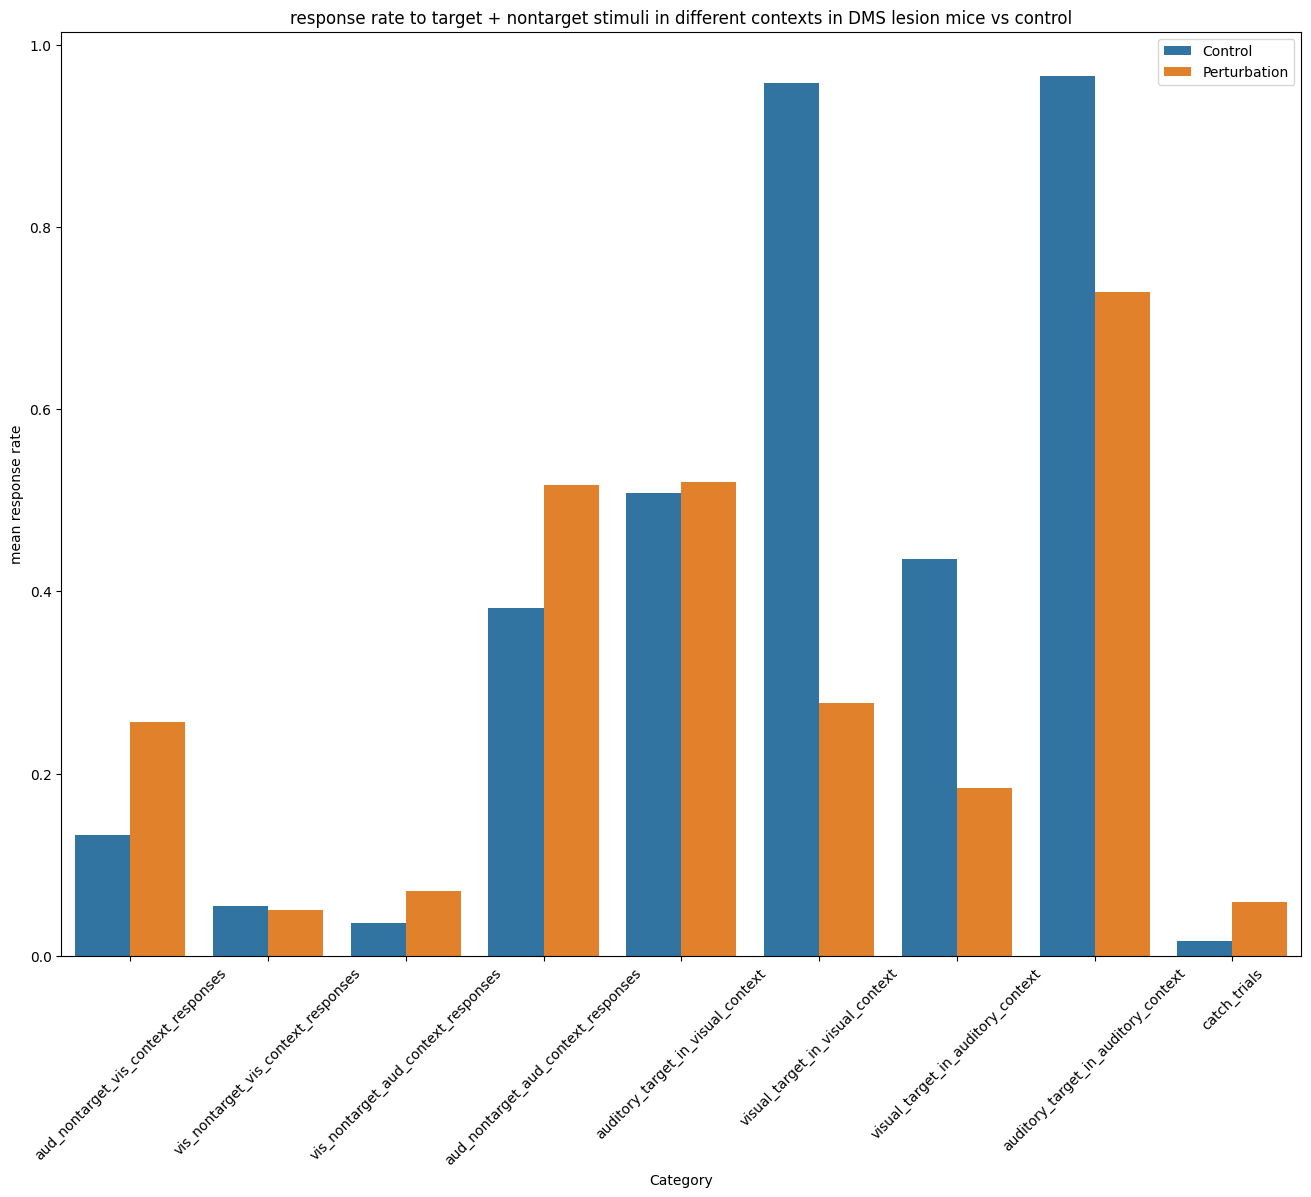

<Figure size 640x480 with 0 Axes>

In [5]:
import seaborn as sns

muscimol_df_dms['session_id'] = muscimol_df_dms['session_id'].astype(str)

avg_values = {
    'Condition': ['Control', 'Perturbation'],

    'aud_nontarget_vis_context_responses': [
    muscimol_df_dms[muscimol_df_dms['control']]['aud_nontarget_vis_context_responses'].mean(),
    muscimol_df_dms[muscimol_df_dms['perturbation']]['aud_nontarget_vis_context_responses'].mean()
    ],

    'vis_nontarget_vis_context_responses': [
    muscimol_df_dms[muscimol_df_dms['control']]['vis_nontarget_vis_context_responses'].mean(),
    muscimol_df_dms[muscimol_df_dms['perturbation']]['vis_nontarget_vis_context_responses'].mean()
        ],

    'vis_nontarget_aud_context_responses': [
    muscimol_df_dms[muscimol_df_dms['control']]['vis_nontarget_aud_context_responses'].mean(),
    muscimol_df_dms[muscimol_df_dms['perturbation']]['vis_nontarget_aud_context_responses'].mean()
        ],
    'aud_nontarget_aud_context_responses': [
    muscimol_df_dms[muscimol_df_dms['control']]['aud_nontarget_aud_context_responses'].mean(),
    muscimol_df_dms[muscimol_df_dms['perturbation']]['aud_nontarget_aud_context_responses'].mean()
          ],
          
    'auditory_target_in_visual_context': [
    muscimol_df_dms[muscimol_df_dms['control']]['auditory_target_in_visual_context'].mean(),
    muscimol_df_dms[muscimol_df_dms['perturbation']]['auditory_target_in_visual_context'].mean()
              ],

     'visual_target_in_visual_context':[
        muscimol_df_dms[muscimol_df_dms['control']]['visual_target_in_visual_context'].mean(),
        muscimol_df_dms[muscimol_df_dms['perturbation']]['visual_target_in_visual_context'].mean()
    ],

    'visual_target_in_auditory_context': [
    muscimol_df_dms[muscimol_df_dms['control']]['visual_target_in_auditory_context'].mean(),
    muscimol_df_dms[muscimol_df_dms['perturbation']]['visual_target_in_auditory_context'].mean()
                  ],

    'auditory_target_in_auditory_context':[
        muscimol_df_dms[muscimol_df_dms['control']]['auditory_target_in_auditory_context'].mean(),
        muscimol_df_dms[muscimol_df_dms['perturbation']]['auditory_target_in_auditory_context'].mean()
    ],
 'catch_trials':[
        muscimol_df_dms[muscimol_df_dms['control']]['catch_trials'].mean(),
        muscimol_df_dms[muscimol_df_dms['perturbation']]['catch_trials'].mean()
    ]
#  'Total Vis Target Aud Context':[
#         muscimol_df_orb[muscimol_df_orb['control']]['total_vis_rewarded_responses_in_aud_context'].mean(),
#         muscimol_df_orb[muscimol_df_orb['perturbation']]['total_vis_rewarded_responses_in_aud_context'].mean()
#     ]

}

# Create a DataFrame from the dictionary
avg_values_df = pd.DataFrame(avg_values)

avg_values_melted_dms = avg_values_df.melt(id_vars='Condition', var_name='Category', value_name='Mean Value')

# Plotting the bar plot
plt.figure(figsize=(16, 12))
ax = sns.barplot(x='Category', y='Mean Value', hue='Condition', data=avg_values_melted_dms)
plt.xlabel('Category')
plt.xticks(rotation=45)
plt.ylabel('mean response rate')
plt.title('response rate to target + nontarget stimuli in different contexts in DMS lesion mice vs control')
plt.legend(loc='upper right')
plt.show()

# Show the plot
plt.tight_layout()
plt.show()

## DMS bar plot summary

In [4]:
import seaborn as sns

muscimol_df_dms['session_id'] = muscimol_df_dms['session_id'].astype(str)

dms_avg_values = {
    'Condition': ['Control', 'Perturbation'],

     'aud target in vis context':[
        muscimol_df_dms[muscimol_df_dms['control']]['auditory_target_in_visual_context'].values,
        muscimol_df_dms[muscimol_df_dms['perturbation']]['auditory_target_in_visual_context'].values
    ],
     'vis target in vis context':[
        muscimol_df_dms[muscimol_df_dms['control']]['visual_target_in_visual_context'].values,
        muscimol_df_dms[muscimol_df_dms['perturbation']]['visual_target_in_visual_context'].values
    ],
     'aud target in aud context':[
        muscimol_df_dms[muscimol_df_dms['control']]['auditory_target_in_auditory_context'].values,
        muscimol_df_dms[muscimol_df_dms['perturbation']]['auditory_target_in_auditory_context'].values
    ],
     'vis target in aud context':[
        muscimol_df_dms[muscimol_df_dms['control']]['visual_target_in_auditory_context'].values,
        muscimol_df_dms[muscimol_df_dms['perturbation']]['visual_target_in_auditory_context'].values
    ],

    'catch trials' :[
        muscimol_df_dms[muscimol_df_dms['control']]['catch_trials'].values,
        muscimol_df_dms[muscimol_df_dms['perturbation']]['catch_trials'].values
    ]

    # 'quiescent_violations' :[
    #     muscimol_df_orb[muscimol_df_orb['control']]['quiescent_violations'].values,
    #     muscimol_df_orb[muscimol_df_orb['perturbation']]['quiescent_violations'].values,
    # ]
}

# df
dms_avg_values_df = pd.DataFrame(dms_avg_values)

dms_avg_values_melted = dms_avg_values_df.melt(id_vars='Condition', var_name='Category', value_name='Mean Value')


plt.figure(figsize=(6, 6))
ax = sns.barplot(x='Category', y='Mean Value', hue='Condition', errorbar='se',
                 data=dms_avg_values_melted.explode('Mean Value'), palette=['#003057', '#FFA500'])

plt.xlabel('')
plt.xticks(rotation = 45)
current_ticks = ax.get_xticks()
new_ticks = [tick - 0.25 for tick in current_ticks] # Adjust the value as needed
ax.set_xticks(new_ticks)

ax.tick_params(axis='both', which='both', length=0)


plt.ylabel('Mean response rate', fontsize = 10)
plt.title('Response rate to target stimuli in different contexts', fontsize = 9.75)
# plt.legend(loc='upper right')
# plt.legend(['Control', 'ORB-lesion'])
# plt.show()
plt.tight_layout()

handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='#003057', markersize=10),
        plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='#FFA500', markersize=10)]
labels = ['Control', 'DMS-inactivation']
plt.legend(handles, labels, loc='upper right')
            # bbox_to_anchor=(1, 1))

plt.tight_layout()

plt.savefig(r"Z:\vayle\muscimol_DMS_behavior_plots\summary_target_responses_plot.png", dpi=300)

plt.show()

NameError: name 'muscimol_df_dms' is not defined

In [ ]:
#make a scatter plot with individual data.

## DMS quiescent violations

In [ ]:
import seaborn as sns

muscimol_df_dms['session_id'] = muscimol_df_dms['session_id'].astype(str)

# avg_values = {
#     'Condition': ['Control', 'Perturbation'],

#     'quiescent_violations' :[
#         muscimol_df_orb_filtered[muscimol_df_orb_filtered['control']]['quiescent_violations'].values,
#         muscimol_df_orb_filtered[muscimol_df_orb_filtered['perturbation']]['quiescent_violations'].values,
#     ]
# }
avg_values_clean = {
    'Condition': ['Control', 'Perturbation'],
    'quiescent_violations': [
        muscimol_df_dms.loc[muscimol_df_orb_filtered['control'], 'quiescent_violations'].tolist(),
        muscimol_df_orb_filtered.loc[muscimol_df_orb_filtered['perturbation'], 'quiescent_violations'].tolist()
    ]
}


# Create a DataFrame from the dictionary
avg_values_df = pd.DataFrame(avg_values_clean)

avg_values_melted = avg_values_df.melt(id_vars='Condition', var_name='Category', value_name='Mean Value')

# Plotting the bar plot
plt.figure(figsize=(6, 6))
ax = sns.barplot(x='Category', y='Mean Value', hue='Condition', errorbar='se',
                 data=avg_values_melted.explode('Mean Value'), palette=['#003057', '#FFA500'])

plt.xlabel('')
plt.xticks(rotation = 45)
current_ticks = ax.get_xticks()
new_ticks = [tick - 0.25 for tick in current_ticks] # Adjust the value as needed
ax.set_xticks(new_ticks)

ax.tick_params(axis='both', which='both', length=0)


plt.ylabel('number of quiescent violations', fontsize = 10)
plt.title('quiescent violation count per session', fontsize = 9.75)
# plt.legend(loc='upper right')
# plt.legend(['Control', 'ORB-lesion'])
# plt.show()
plt.tight_layout()

handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='#003057', markersize=10),
        plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='#FFA500', markersize=10)]
labels = ['Control', 'ORB-inactivation']
plt.legend(handles, labels, loc='upper right')
            # bbox_to_anchor=(1, 1))

plt.tight_layout()

# plt.savefig(r"C:\Users\vayle.lafehr\Desktop\perturbation_analysis_figures\mean_response_rate_both_targets&contexts.png", dpi=300)

sns.stripplot(
    x='Category',
    y='Mean Value',
    hue='Condition',
    data=avg_values_melted.explode('Mean Value'),
    dodge=True,        # separates points by hue
    jitter=False,       # adds horizontal jitter for visibility
    alpha=0.6,         # transparency for overlapping points
    palette=["#000000", "#000000"],
    marker='o',
    size=6
)

for _, row in paired_df.iterrows():
    x_control = 0  # index of 'quiescent_violations' bar
    x_perturb = 0  # same bar, but dodge shifts it

    # Get dodge offset from Seaborn (usually ~0.2)
    dodge_offset = 0.2

    x1 = x_control - dodge_offset
    x2 = x_perturb + dodge_offset
    y1 = row['quiescent_violations_control']
    y2 = row['quiescent_violations_perturb']
  

    plt.plot([x1, x2], [y1, y2], color = 'green' if y2 > y1 else 'red'
, linestyle='-', linewidth=1, alpha=0.6)
    
plt.savefig(r"Z:\vayle\muscimol_ORB_behavior_plots\quiescent_violations", dpi=300)



# plt.show()

NameError: name 'muscimol_df_orb_filtered' is not defined

C:\Users\vayle.lafehr\AppData\Local\Temp\ipykernel_42948\3013353958.py:28: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', len(unique_groups))


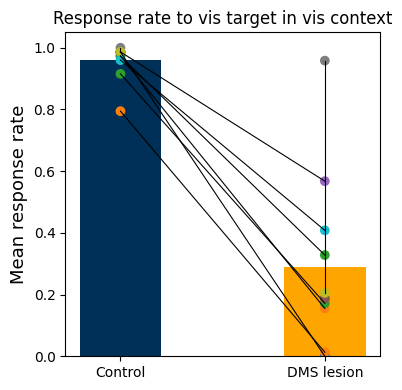

In [37]:
from datetime import datetime, timedelta


muscimol_df_dms['session_id'] =muscimol_df_dms['session_id'].astype(str)

avg_control = muscimol_df_dms[muscimol_df_dms['control']]['visual_target_in_visual_context'].mean()
avg_perturbation = muscimol_df_dms[muscimol_df_dms['perturbation']]['visual_target_in_visual_context'].mean()


# Create a bar plot comparing perturbation vs control bars with averages
plt.figure(figsize=(4, 4))
bar_width = 0.4

bars = ['Control', 'DMS lesion']
y_pos = range(len(bars))
averages = [avg_control, avg_perturbation]

plt.bar(y_pos, averages, color=['#003057', '#FFA500'], width=bar_width)

# plt.xlabel('Perturbation Condition')
plt.ylabel('Mean response rate', fontsize = 13)
plt.title('Response rate to vis target in vis context', fontsize = 11.9)
plt.xticks(y_pos, bars)

muscimol_df_dms['color_group'] = muscimol_df_dms['session_id'].apply(lambda x: x.split('_')[0].split('(')[1].strip("'"))

unique_groups = muscimol_df_dms['color_group'].unique()
colors = plt.cm.get_cmap('tab10', len(unique_groups))
color_map = {group: colors(i) for i, group in enumerate(unique_groups)}

control_points = muscimol_df_dms[muscimol_df_dms['control']]['visual_target_in_visual_context']
perturbation_points = muscimol_df_dms[muscimol_df_dms['perturbation']]['visual_target_in_visual_context']

control_colors = muscimol_df_dms[muscimol_df_dms['control']]['color_group'].map(color_map)
perturbation_colors = muscimol_df_dms[muscimol_df_dms['perturbation']]['color_group'].map(color_map)

plt.scatter([0]*len(control_points), control_points, color=control_colors, zorder=2)
plt.scatter([1]*len(perturbation_points), perturbation_points, color=perturbation_colors, zorder=2)


muscimol_df_dms['date'] = muscimol_df_dms['session_id'].apply(lambda x: datetime.strptime(x.split('_')[1].split("'")[0], '%Y-%m-%d'))
            
for i in range(1, len(muscimol_df_dms), 2):
    x_coords = [0 if muscimol_df_dms.loc[i-1, 'control'] else 1, 0 if muscimol_df_dms.loc[i, 'control'] else 1]
    y_coords = [muscimol_df_dms.loc[i-1, 'visual_target_in_visual_context'], muscimol_df_dms.loc[i, 'visual_target_in_visual_context']]
    plt.plot(x_coords, y_coords, color='black', linestyle='-', linewidth=0.8)


# for i in range(len(muscimol_df_orb)):
#     session_id_label = muscimol_df_orb.loc[i, 'session_id'].replace("DynamicRoutingSession", "")
#     if muscimol_df_orb.loc[i, 'control']:
#         plt.text(0, muscimol_df_orb.loc[i, 'auditory_target_in_visual_context'] + 0.009 * i, session_id_label, fontsize=6, rotation=5, va='bottom')
#     else:
#         plt.text(1, muscimol_df_orb.loc[i, 'auditory_target_in_visual_context']+ 0.006 * i - 0.003 * len(muscimol_df_orb), session_id_label, fontsize=6, rotation=0, ha='left')


# handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=color_map[group], markersize=10) for group in unique_groups]
# labels = unique_groups
# plt.legend(handles, labels, title="Mouse")


# Show the plot
plt.tight_layout()

# plt.savefig(r"C:\Users\vayle.lafehr\Desktop\perturbation_analysis_figures\response_rate_aud_target_vis_context.png", dpi=300)
# plt.savefig(r"Z:\vayle\muscimol_ORB_behavior_plots", dpi=300)
plt.show()


C:\Users\vayle.lafehr\AppData\Local\Temp\ipykernel_42948\2854294572.py:17: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', len(unique_groups))


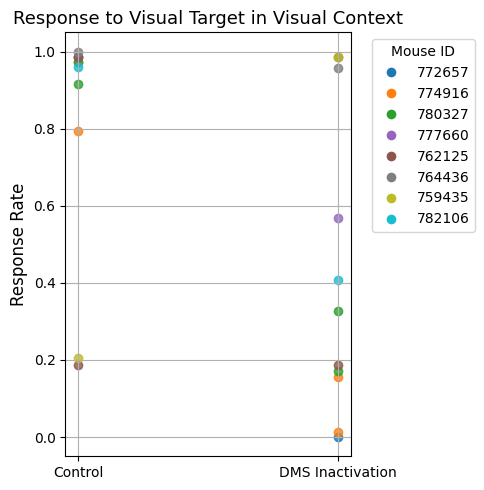

In [40]:
import matplotlib.pyplot as plt
from datetime import datetime

# mouseID
muscimol_df_dms['color_group'] = muscimol_df_dms['session_id'].apply(
    lambda x: x.split('_')[0].split('(')[1].strip("'")
)

# Sort by date
muscimol_df_dms['date'] = muscimol_df_dms['session_id'].apply(
    lambda x: datetime.strptime(x.split('_')[1].split("'")[0], '%Y-%m-%d')
)
muscimol_df_dms = muscimol_df_dms.sort_values(by='date').reset_index(drop=True)

# unique color map
unique_groups = muscimol_df_dms['color_group'].unique()
colors = plt.cm.get_cmap('tab10', len(unique_groups))
color_map = {group: colors(i) for i, group in enumerate(unique_groups)}

# Separate control and perturbation points with color coding
control_points = []
perturbation_points = []

for i in range(1, len(muscimol_df_dms), 2):
    row1 = muscimol_df_dms.loc[i - 1]
    row2 = muscimol_df_dms.loc[i]
    if row1['control']:
        control_row = row1
        perturb_row = row2
    else:
        control_row = row2
        perturb_row = row1

    control_points.append((control_row['visual_target_in_visual_context'], color_map[control_row['color_group']]))
    perturbation_points.append((perturb_row['visual_target_in_visual_context'], color_map[perturb_row['color_group']]))

# make scatter plot
plt.figure(figsize=(5, 5))


for y, color in control_points:
    plt.scatter(0, y, color=color, alpha=0.8)


for y, color in perturbation_points:
    plt.scatter(1, y, color=color, alpha=0.8)


plt.xticks([0, 1], ['Control', 'DMS Inactivation'])
plt.ylabel('Response Rate', fontsize=12)
plt.title('Response to Visual Target in Visual Context', fontsize=13)

handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=color_map[group], markersize=8) for group in unique_groups]
plt.legend(handles, unique_groups, title="Mouse ID", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.grid(True)
plt.tight_layout()
plt.show()


## DMS unity line scatter plot

C:\Users\vayle.lafehr\AppData\Local\Temp\ipykernel_42616\130743903.py:35: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', len(unique_groups))


(0.0547945205479452, 0.9305555555555556, '717473')
(0.43243243243243246, 0.8266666666666667, '717473')
(0.0, 0.9864864864864865, '772657')
(0.15492957746478872, 0.9733333333333334, '774916')
(0.171875, 0.9154929577464789, '780327')
(0.013157894736842105, 0.7945205479452054, '774916')
(0.328125, 0.9726027397260274, '780327')
(0.2054794520547945, 0.9866666666666667, '759435')
(0.11428571428571428, 0.9552238805970149, '759435')
(0.3389830508474576, 0.1864406779661017, '717473')
(0.35185185185185186, 0.16666666666666666, '717473')
(0.0, 0.13793103448275862, '772657')
(0.5254237288135594, 0.9137931034482759, '774916')
(0.7959183673469388, 0.3620689655172414, '780327')
(0.6101694915254238, 0.7857142857142857, '774916')
(0.58, 0.423728813559322, '780327')
(0.10344827586206896, 0.11475409836065574, '759435')
(0.01694915254237288, 0.10526315789473684, '759435')
(0.03389830508474576, 0.21428571428571427, '717473')
(0.16666666666666666, 0.15517241379310345, '717473')
(0.0, 0.3448275862068966, '77

<Figure size 2000x2000 with 0 Axes>

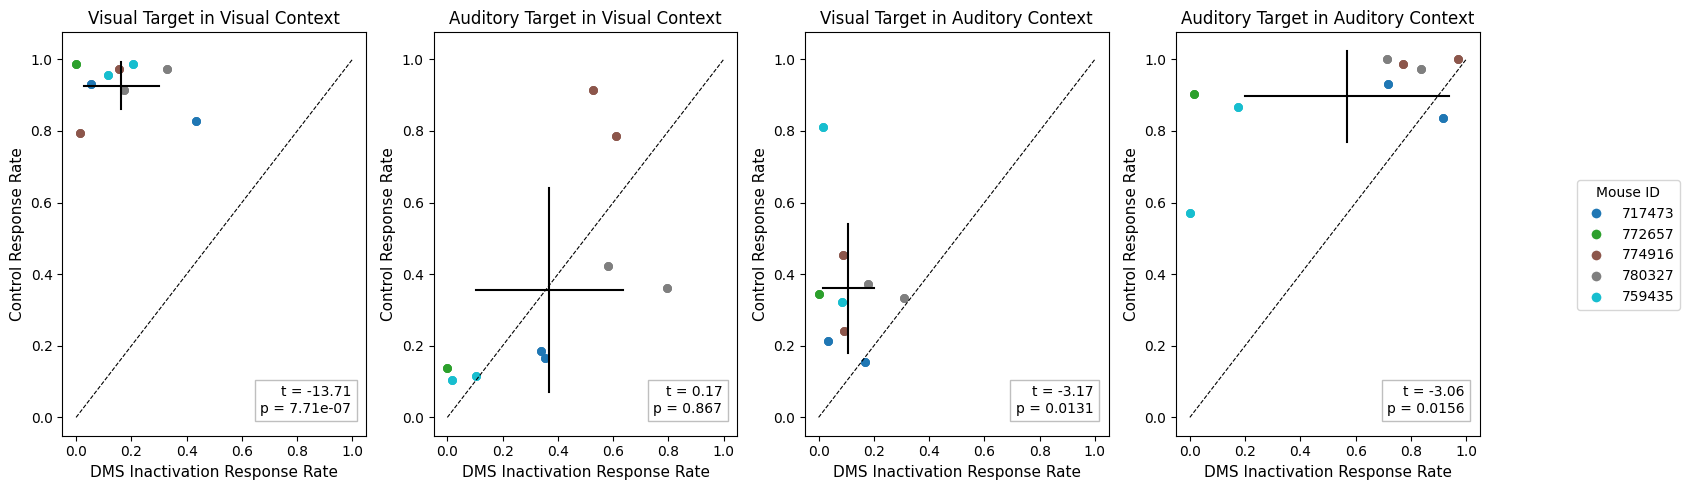

In [28]:
import matplotlib.pyplot as plt
from datetime import datetime
from scipy import stats

result = dict(
    session_id=str(session.session_id) if hasattr(session, 'session_id') else str(session),
    # ...other fields...
)

#clean
import re

def extract_mouse_id(x):
    # Always convert to string
    s = str(x)
    # Try to extract the mouse ID using regex
    match = re.search(r"\('(\d+)_", s)
    if match:
        return match.group(1)
    # fallback: try splitting
    if '_' in s:
        return s.split('_')[0].split('(')[-1].strip("'")
    return s

muscimol_df_dms['color_group'] = muscimol_df_dms['session_id'].apply(extract_mouse_id)

# # Sort by date
muscimol_df_dms['date'] = muscimol_df_dms['session_id'].apply(
    lambda x: datetime.strptime(str(x).split('_')[1].split("'")[0], '%Y-%m-%d')
)
muscimol_df_dms = muscimol_df_dms.sort_values(by='date').reset_index(drop=True)

# unique colors bymouse ID
unique_groups = muscimol_df_dms['color_group'].unique()
colors = plt.cm.get_cmap('tab10', len(unique_groups))
color_map = {group: colors(i) for i, group in enumerate(unique_groups)}

# Pair control and perturbation sessions
paired_data_vis_vis = []
for i in range(1, len(muscimol_df_dms), 2):
    row1 = muscimol_df_dms.loc[i - 1]
    row2 = muscimol_df_dms.loc[i]
    if row1['control']:
        control_val = row1['visual_target_in_visual_context']
        perturb_val = row2['visual_target_in_visual_context']
        color_group = row1['color_group']
    else:
        control_val = row2['visual_target_in_visual_context']
        perturb_val = row1['visual_target_in_visual_context']
        color_group = row2['color_group']
    paired_data_vis_vis.append((perturb_val, control_val, color_group))

    paired_data_aud_vis = []
for i in range(1, len(muscimol_df_dms), 2):
    row1 = muscimol_df_dms.loc[i - 1]
    row2 = muscimol_df_dms.loc[i]
    if row1['control']:
        control_val_1 = row1['auditory_target_in_visual_context']
        perturb_val_1 = row2['auditory_target_in_visual_context']
        color_group = row1['color_group']
    else:
        control_val_1 = row2['auditory_target_in_visual_context']
        perturb_val_1 = row1['auditory_target_in_visual_context']
        color_group = row2['color_group']
    paired_data_aud_vis.append((perturb_val_1, control_val_1, color_group))

    paired_data_vis_aud = []
for i in range(1, len(muscimol_df_dms), 2):
    row1 = muscimol_df_dms.loc[i - 1]
    row2 = muscimol_df_dms.loc[i]
    if row1['control']:
        control_val_2 = row1['visual_target_in_auditory_context']
        perturb_val_2 = row2['visual_target_in_auditory_context']
        color_group = row1['color_group']
    else:
        control_val_2 = row2['visual_target_in_auditory_context']
        perturb_val_2 = row1['visual_target_in_auditory_context']
        color_group = row2['color_group']
    paired_data_vis_aud.append((perturb_val_2, control_val_2, color_group))

    paired_data_aud_aud = []
for i in range(1, len(muscimol_df_dms), 2):
    row1 = muscimol_df_dms.loc[i - 1]
    row2 = muscimol_df_dms.loc[i]
    if row1['control']:
        control_val_3 = row1['auditory_target_in_auditory_context']
        perturb_val_3 = row2['auditory_target_in_auditory_context']
        color_group = row1['color_group']
    else:
        control_val_3 = row2['auditory_target_in_auditory_context']
        perturb_val_3 = row1['auditory_target_in_auditory_context']
        color_group = row2['color_group']
    paired_data_aud_aud.append((perturb_val_3, control_val_3, color_group))

# Create scatter plot with x = perturbation, y = control
plt.figure(figsize=(20, 20))

# data = [paired_data_vis_vis, paired_data_aud_vis]
# for datum in data:
#     for x, y, group in datum:
#         print((x,y,group))
#         plt.scatter(x, y, color=color_map[group], label=group, alpha=0.8, linewidth = 0.2)
#         plt.scatter(x, y, color=color_map[group], label=group, alpha=0.8)

fig, axes = plt.subplots(1, 4, figsize=(15, 5), sharex=True, sharey=True)

contexts = ['Visual Target in Visual Context', 'Auditory Target in Visual Context', 'Visual Target in Auditory Context', 'Auditory Target in Auditory Context']
data = [paired_data_vis_vis, paired_data_aud_vis, paired_data_vis_aud, paired_data_aud_aud]

#make test star for plot


    
#organize paired data

paired_data_sets ={
    'vis_vis': paired_data_vis_vis,
    'aud_vis': paired_data_aud_vis,
    'vis_aud': paired_data_vis_aud,
    'aud_aud': paired_data_aud_aud,
}
    

#mean cross


for ax, (label, paired_data) in zip(axes, paired_data_sets.items()):
    x_vals = [x for x, _, _ in paired_data]
    y_vals = [y for _, y, _ in paired_data]
    # print(f"{label} - x_vals: {x_vals}, y_vals: {y_vals}")
    
    x_mean, y_mean = np.mean(x_vals), np.mean(y_vals)
    x_std, y_std = np.std(x_vals), np.std(y_vals)
    ax.plot([x_mean - x_std, x_mean +x_std], [y_mean, y_mean], color='black', lw=1.5)
    ax.plot([x_mean, x_mean], [y_mean - y_std, y_mean + y_std], color='black', lw=1.5)


    for ax, datum, title in zip(axes, data, contexts):
        for x, y, group in datum:
            print((x, y, group))
            ax.scatter(x, y, color=color_map[group], alpha=0.8, linewidth=0.2)





# for ax in axes:
    # ax.errorbar(np.mean(x_vals), np.mean(y_vals), xerr=x_std, yerr=y_std, fmt='o', color='black', markersize=5, label='Mean ± Std Dev', alpha=0.5)
# unity line

for ax in axes:
    ax.plot([0, 1], [0, 1], 'k--', linewidth=0.8)  # Unity line for each subplot
# plt.plot([0, 1], [0, 1], 'k--')


# ax.set_xlim(0, 1)
# ax.set_ylim(0, 1)
#adds space to plot size
# x_vals = [x for x, _, _ in paired_data]
# y_vals = [y for _, y, _ in paired_data]

# x_min, x_max = min(x_vals), max(x_vals)
# y_min, y_max = min(y_vals), max(y_vals)

# padding_x = (x_max - x_min) * 0.05  # 5% padding
# padding_y = (y_max - y_min) * 0.05

# ax.set_xlim(x_min - padding_x, x_max + padding_x)
# ax.set_ylim(y_min - padding_y, y_max + padding_y)


for ax, x_label in zip(axes, 'DMS Inactivation Response Rate'):
    ax.set_xlabel('DMS Inactivation Response Rate', fontsize =11)


for ax, y_label in zip(axes, 'Control Response Rate'):
    ax.set_ylabel('Control Response Rate', fontsize=11)
# ax.set_title(f'{c for c in contexts}', fontsize=12)

for ax, title in zip(axes, contexts):
    ax.set_title(f'{title}', fontsize=12)

for ax in axes:
    ax.yaxis.set_tick_params(labelleft=True)
# ax.grid(True)
for ax, (label, paired_data) in zip(axes, paired_data_sets.items()):
    x_vals = [x for x, _, _ in paired_data]  # Perturbation
    y_vals = [y for _, y, _ in paired_data]  # Control

    # Run paired t-test
    t_stat, p_val = stats.ttest_rel(x_vals, y_vals)

    # Plot scatter and mean cross as before...
    # [your existing plotting code here]

    # Annotate with t-test result
    ax.text(0.95, 0.05, f't = {t_stat:.2f}\np = {p_val:.3g}',
            transform=ax.transAxes, fontsize=10,
            verticalalignment='bottom', horizontalalignment='right', bbox=dict(facecolor='white', alpha=0.5, edgecolor='gray'))

# Create legend with unique mouse IDs
# handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=color_map[group], markersize=8) for group in unique_groups]
# plt.legend(handles, unique_groups, title="Mouse ID", bbox_to_anchor=(1.05, 1), loc='upper left')

handles = [plt.Line2D([0], [0], marker='o', color='w',
                      markerfacecolor=color_map[group], markersize=8)
           for group in unique_groups]
fig.legend(handles, unique_groups, title="Mouse ID",
           bbox_to_anchor=(1.05, 0.5), loc='center left')

plt.tight_layout()


# plt.savefig(r"Z:\vayle\muscimol_DMS_behavior_plots\DMS_population_effects_unity_line_scatter_plot", dpi=300)

plt.show()
# plt.grid(True)
# plt.tight_layout()
# plt.show()


## DMS: Nontarget unity line scatter plot

C:\Users\vayle.lafehr\AppData\Local\Temp\ipykernel_42616\2730255623.py:35: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', len(unique_groups))


(0.05084745762711865, 0.05084745762711865, '717473')
(0.05172413793103448, 0.03333333333333333, '717473')
(0.037037037037037035, 0.034482758620689655, '772657')
(0.3684210526315789, 0.5, '774916')
(0.2553191489361702, 0.08333333333333333, '780327')
(0.1746031746031746, 0.14545454545454545, '774916')
(0.5294117647058824, 0.21666666666666667, '780327')
(0.11538461538461539, 0.08196721311475409, '759435')
(0.0, 0.03636363636363636, '759435')
(0.016666666666666666, 0.017241379310344827, '717473')
(0.05263157894736842, 0.0, '717473')
(0.018518518518518517, 0.0, '772657')
(0.03571428571428571, 0.016666666666666666, '774916')
(0.0, 0.05084745762711865, '780327')
(0.0, 0.2727272727272727, '774916')
(0.09259259259259259, 0.017857142857142856, '780327')
(0.09259259259259259, 0.017857142857142856, '759435')
(0.0, 0.0, '759435')
(0.3898305084745763, 0.5, '717473')
(0.46551724137931033, 0.37735849056603776, '717473')
(0.0, 0.5178571428571429, '772657')
(0.7592592592592593, 0.2542372881355932, '7749

<Figure size 2000x2000 with 0 Axes>

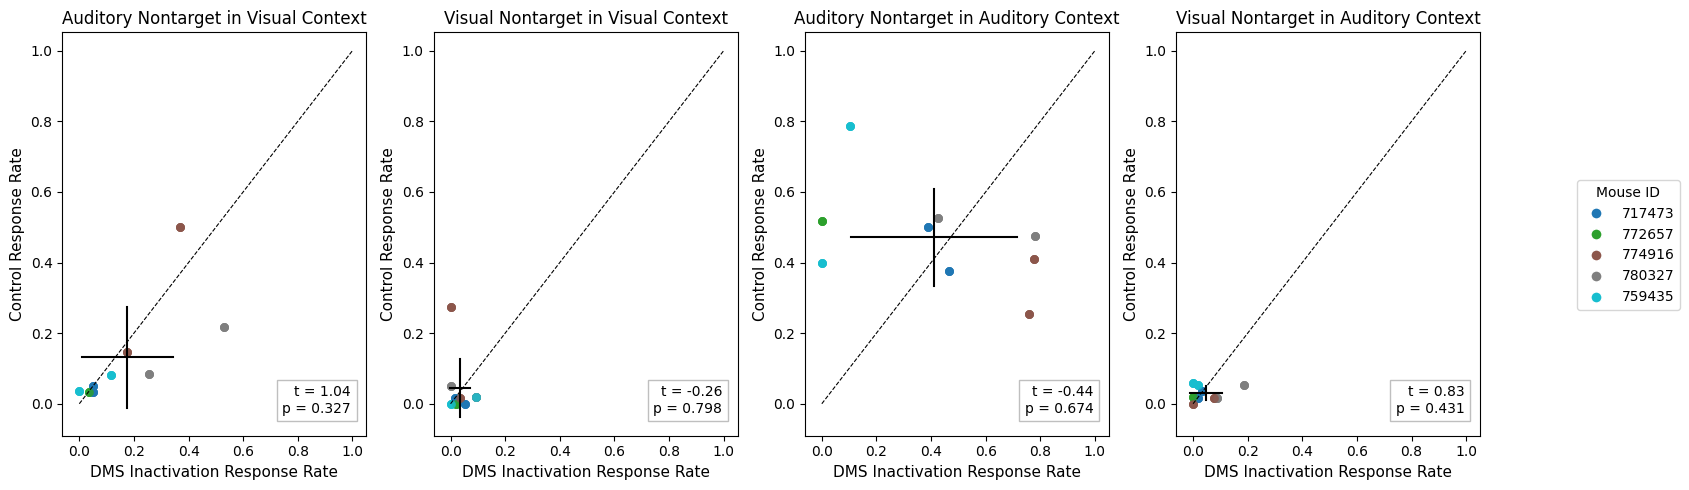

In [33]:
import matplotlib.pyplot as plt
from datetime import datetime
from scipy import stats

result = dict(
    session_id=str(session.session_id) if hasattr(session, 'session_id') else str(session),
    # ...other fields...
)

#clean
import re

def extract_mouse_id(x):
    # Always convert to string
    s = str(x)
    # Try to extract the mouse ID using regex
    match = re.search(r"\('(\d+)_", s)
    if match:
        return match.group(1)
    # fallback: try splitting
    if '_' in s:
        return s.split('_')[0].split('(')[-1].strip("'")
    return s

muscimol_df_dms['color_group'] = muscimol_df_dms['session_id'].apply(extract_mouse_id)

# # Sort by date
muscimol_df_dms['date'] = muscimol_df_dms['session_id'].apply(
    lambda x: datetime.strptime(str(x).split('_')[1].split("'")[0], '%Y-%m-%d')
)
muscimol_df_dms = muscimol_df_dms.sort_values(by='date').reset_index(drop=True)

# unique colors bymouse ID
unique_groups = muscimol_df_dms['color_group'].unique()
colors = plt.cm.get_cmap('tab10', len(unique_groups))
color_map = {group: colors(i) for i, group in enumerate(unique_groups)}

# Pair control and perturbation sessions
paired_data_vis_vis = []
for i in range(1, len(muscimol_df_dms), 2):
    row1 = muscimol_df_dms.loc[i - 1]
    row2 = muscimol_df_dms.loc[i]
    if row1['control']:
        control_val = row1['vis_nontarget_vis_context_responses']
        perturb_val = row2['vis_nontarget_vis_context_responses']
        color_group = row1['color_group']
    else:
        control_val = row2['vis_nontarget_vis_context_responses']
        perturb_val = row1['vis_nontarget_vis_context_responses']
        color_group = row2['color_group']
    paired_data_vis_vis.append((perturb_val, control_val, color_group))

    paired_data_aud_vis = []
for i in range(1, len(muscimol_df_dms), 2):
    row1 = muscimol_df_dms.loc[i - 1]
    row2 = muscimol_df_dms.loc[i]
    if row1['control']:
        control_val_1 = row1['aud_nontarget_vis_context_responses']
        perturb_val_1 = row2['aud_nontarget_vis_context_responses']
        color_group = row1['color_group']
    else:
        control_val_1 = row2['aud_nontarget_vis_context_responses']
        perturb_val_1 = row1['aud_nontarget_vis_context_responses']
        color_group = row2['color_group']
    paired_data_aud_vis.append((perturb_val_1, control_val_1, color_group))

    paired_data_vis_aud = []
for i in range(1, len(muscimol_df_dms), 2):
    row1 = muscimol_df_dms.loc[i - 1]
    row2 = muscimol_df_dms.loc[i]
    if row1['control']:
        control_val_2 = row1['vis_nontarget_aud_context_responses']
        perturb_val_2 = row2['vis_nontarget_aud_context_responses']
        color_group = row1['color_group']
    else:
        control_val_2 = row2['vis_nontarget_aud_context_responses']
        perturb_val_2 = row1['vis_nontarget_aud_context_responses']
        color_group = row2['color_group']
    paired_data_vis_aud.append((perturb_val_2, control_val_2, color_group))

    paired_data_aud_aud = []
for i in range(1, len(muscimol_df_dms), 2):
    row1 = muscimol_df_dms.loc[i - 1]
    row2 = muscimol_df_dms.loc[i]
    if row1['control']:
        control_val_3 = row1['aud_nontarget_aud_context_responses']
        perturb_val_3 = row2['aud_nontarget_aud_context_responses']
        color_group = row1['color_group']
    else:
        control_val_3 = row2['aud_nontarget_aud_context_responses']
        perturb_val_3 = row1['aud_nontarget_aud_context_responses']
        color_group = row2['color_group']
    paired_data_aud_aud.append((perturb_val_3, control_val_3, color_group))

# Create scatter plot with x = perturbation, y = control
plt.figure(figsize=(20, 20))

# data = [paired_data_vis_vis, paired_data_aud_vis]
# for datum in data:
#     for x, y, group in datum:
#         print((x,y,group))
#         plt.scatter(x, y, color=color_map[group], label=group, alpha=0.8, linewidth = 0.2)
#         plt.scatter(x, y, color=color_map[group], label=group, alpha=0.8)

fig, axes = plt.subplots(1, 4, figsize=(15, 5), sharex=True, sharey=True)

contexts = ['Auditory Nontarget in Visual Context','Visual Nontarget in Visual Context', 'Auditory Nontarget in Auditory Context', 'Visual Nontarget in Auditory Context']
data = [paired_data_aud_vis, paired_data_vis_vis, paired_data_aud_aud, paired_data_vis_aud]

#make test star for plot


    
#organize paired data

paired_data_sets ={
    'aud_vis': paired_data_aud_vis,
    'vis_vis': paired_data_vis_vis,
    'aud_aud': paired_data_aud_aud,
    'vis_aud': paired_data_vis_aud,
}
    

#mean cross


for ax, (label, paired_data) in zip(axes, paired_data_sets.items()):
    x_vals = [x for x, _, _ in paired_data]
    y_vals = [y for _, y, _ in paired_data]
    # print(f"{label} - x_vals: {x_vals}, y_vals: {y_vals}")
    
    x_mean, y_mean = np.mean(x_vals), np.mean(y_vals)
    x_std, y_std = np.std(x_vals), np.std(y_vals)
    ax.plot([x_mean - x_std, x_mean +x_std], [y_mean, y_mean], color='black', lw=1.5)
    ax.plot([x_mean, x_mean], [y_mean - y_std, y_mean + y_std], color='black', lw=1.5)


    for ax, datum, title in zip(axes, data, contexts):
        for x, y, group in datum:
            print((x, y, group))
            ax.scatter(x, y, color=color_map[group], alpha=0.8, linewidth=0.2)





# for ax in axes:
    # ax.errorbar(np.mean(x_vals), np.mean(y_vals), xerr=x_std, yerr=y_std, fmt='o', color='black', markersize=5, label='Mean ± Std Dev', alpha=0.5)
# unity line

for ax in axes:
    ax.plot([0, 1], [0, 1], 'k--', linewidth=0.8)  # Unity line for each subplot
# plt.plot([0, 1], [0, 1], 'k--')


# ax.set_xlim(0, 1)
# ax.set_ylim(0, 1)
#adds space to plot size
# x_vals = [x for x, _, _ in paired_data]
# y_vals = [y for _, y, _ in paired_data]

# x_min, x_max = min(x_vals), max(x_vals)
# y_min, y_max = min(y_vals), max(y_vals)

# padding_x = (x_max - x_min) * 0.05  # 5% padding
# padding_y = (y_max - y_min) * 0.05

# ax.set_xlim(x_min - padding_x, x_max + padding_x)
# ax.set_ylim(y_min - padding_y, y_max + padding_y)


for ax, x_label in zip(axes, 'DMS Inactivation Response Rate'):
    ax.set_xlabel('DMS Inactivation Response Rate', fontsize =11)


for ax, y_label in zip(axes, 'Control Response Rate'):
    ax.set_ylabel('Control Response Rate', fontsize=11)
# ax.set_title(f'{c for c in contexts}', fontsize=12)

for ax, title in zip(axes, contexts):
    ax.set_title(f'{title}', fontsize=12)

for ax in axes:
    ax.yaxis.set_tick_params(labelleft=True)
# ax.grid(True)
for ax, (label, paired_data) in zip(axes, paired_data_sets.items()):
    x_vals = [x for x, _, _ in paired_data]  # Perturbation
    y_vals = [y for _, y, _ in paired_data]  # Control

    # Run paired t-test
    t_stat, p_val = stats.ttest_rel(x_vals, y_vals)

    # Plot scatter and mean cross as before...
    # [your existing plotting code here]

    # Annotate with t-test result
    ax.text(0.95, 0.05, f't = {t_stat:.2f}\np = {p_val:.3g}',
            transform=ax.transAxes, fontsize=10,
            verticalalignment='bottom', horizontalalignment='right', bbox=dict(facecolor='white', alpha=0.5, edgecolor='gray'))

# Create legend with unique mouse IDs
# handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=color_map[group], markersize=8) for group in unique_groups]
# plt.legend(handles, unique_groups, title="Mouse ID", bbox_to_anchor=(1.05, 1), loc='upper left')

handles = [plt.Line2D([0], [0], marker='o', color='w',
                      markerfacecolor=color_map[group], markersize=8)
           for group in unique_groups]
fig.legend(handles, unique_groups, title="Mouse ID",
           bbox_to_anchor=(1.05, 0.5), loc='center left')

plt.tight_layout()


# plt.savefig(r"Z:\vayle\muscimol_ORB_behavior_plots\ORB_nontarget_population_effects_unity_line_scatter_plot", dpi=300)
plt.show()
# plt.grid(True)
# plt.tight_layout()
# plt.show()

In [53]:
from scipy import stats

# t_stat,p_val=stats.ttest_rel(control_val,perturb_val)
for data in paired_data_sets.values():
    control_val = [y for _, y, _ in data]
    perturb_val = [x for x, _, _ in data]
    t_stat,p_val=stats.ttest_rel(control_val,perturb_val)
    print(t_stat, p_val) 
    # print(control_val, perturb_val)
# print(f"T-statistic: {t_stat}, P-value: {p_val}")

2.137778751219755 0.061242065650459004
0.06907803200281537 0.9464379516884152
1.4497961648536803 0.1810515717998313
0.7307446404961361 0.4835234584269701


## DMS ORI FIRST

In [ ]:
import seaborn as sns

muscimol_df_dms['session_id'] = muscimol_df_dms['session_id'].astype(str)


ori_df = muscimol_df_dms[muscimol_df_dms['ori_first'] == True]


ori_values = {
    'Condition': ['Control', 'Perturbation'],

     'auditory target in visual context':[
        ori_df[ori_df['control']]['auditory_target_in_visual_context'].values,
        ori_df[ori_df['perturbation']]['auditory_target_in_visual_context'].values
    ],
     'visual target in visual context':[
        ori_df[ori_df['control']]['visual_target_in_visual_context'].values,
        ori_df[ori_df['perturbation']]['visual_target_in_visual_context'].values
    ],
     'auditory target in auditory context':[
        ori_df[ori_df['control']]['auditory_target_in_auditory_context'].values,
        ori_df[ori_df['perturbation']]['auditory_target_in_auditory_context'].values
    ],
     'visual target in aurditory context':[
        ori_df[ori_df['control']]['visual_target_in_auditory_context'].values,
        ori_df[ori_df['perturbation']]['visual_target_in_auditory_context'].values
    ],

    'catch trials' :[
        ori_df[ori_df['control']]['catch_trials'].values,
        ori_df[ori_df['perturbation']]['catch_trials'].values
    ]

    # 'quiescent_violations' :[
    #     muscimol_df_orb[muscimol_df_orb['control']]['quiescent_violations'].values,
    #     muscimol_df_orb[muscimol_df_orb['perturbation']]['quiescent_violations'].values,
    # ]
}

# Create a DataFrame from the dictionary
ori_values_df = pd.DataFrame(ori_values)

ori_values_melted = ori_values_df.melt(id_vars='Condition', var_name='Category', value_name='Mean Value')

# Plotting the bar plot
plt.figure(figsize=(6, 6))
ax = sns.barplot(x='Category', y='Mean Value', hue='Condition', errorbar='se',
                 data=ori_values_melted.explode('Mean Value'), palette=['#003057', '#FFA500'])

plt.xlabel('')
plt.xticks(rotation = 45)
current_ticks = ax.get_xticks()
new_ticks = [tick - 0.25 for tick in current_ticks] # Adjust the value as needed
ax.set_xticks(new_ticks)

ax.tick_params(axis='both', which='both', length=0)


plt.ylabel('Mean response rate', fontsize = 10)
plt.title('Response rate to target stimuli in different contexts (ORI first)', fontsize = 9.75)
# plt.legend(loc='upper right')
# plt.legend(['Control', 'ORB-lesion'])
# plt.show()
plt.tight_layout()

handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='#003057', markersize=10),
        plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='#FFA500', markersize=10)]
labels = ['Control', 'DMS-inactivation']
plt.legend(handles, labels, loc='upper right')
            # bbox_to_anchor=(1, 1))

plt.tight_layout()

# plt.savefig(r"Z:\vayle\muscimol_ORB_behavior_plots\mean_target_response_rate_ori_first.png", dpi=300)

plt.show()


C:\Users\vayle.lafehr\AppData\Local\Temp\ipykernel_42948\945587280.py:17: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', len(unique_groups))


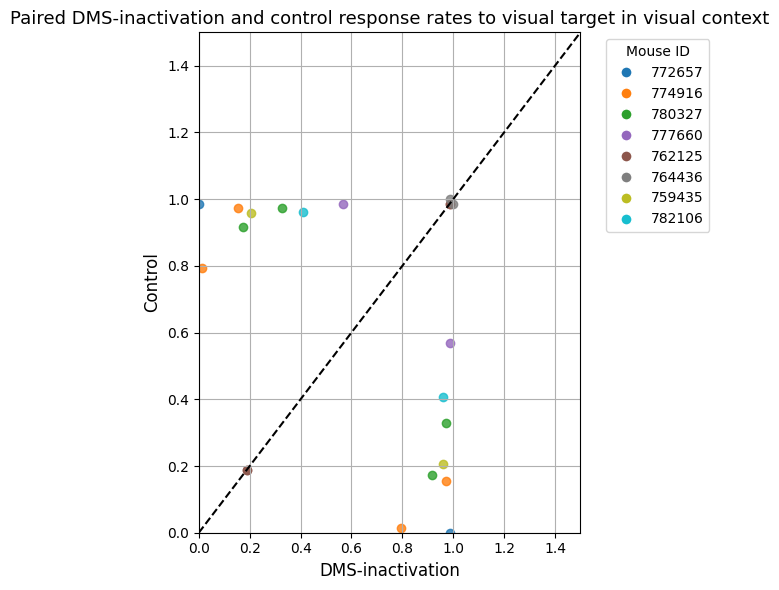

In [46]:
import matplotlib.pyplot as plt
from datetime import datetime

# clean session id up
muscimol_df_dms['color_group'] = muscimol_df_dms['session_id'].apply(
    lambda x: x.split('_')[0].split('(')[1].strip("'")
)

# sort by date
muscimol_df_dms['date'] = muscimol_df_dms['session_id'].apply(
    lambda x: datetime.strptime(x.split('_')[1].split("'")[0], '%Y-%m-%d')
)
muscimol_df_dms = muscimol_df_dms.sort_values(by='date').reset_index(drop=True)

# fun colors!
unique_groups = muscimol_df_dms['color_group'].unique()
colors = plt.cm.get_cmap('tab10', len(unique_groups))
color_map = {group: colors(i) for i, group in enumerate(unique_groups)}

# make paired with ctrl, perturb....perturb, ctrl
paired_data = []
for i in range(1, len(muscimol_df_dms), 2):
    row1 = muscimol_df_dms.loc[i - 1]
    row2 = muscimol_df_dms.loc[i]
    if row1['control']:
        control_val = row1['visual_target_in_visual_context']
        perturb_val = row2['visual_target_in_visual_context']
        color_group = row1['color_group']
    else:
        control_val = row2['visual_target_in_visual_context']
        perturb_val = row1['visual_target_in_visual_context']
        color_group = row2['color_group']
    
    # finalize here
    paired_data.append((perturb_val, control_val, color_group))  # control as y, perturbation as x
    paired_data.append((control_val, perturb_val, color_group))  # perturbation as y, control as x

# llot it
plt.figure(figsize=(6, 6))
for x, y, group in paired_data:
    plt.scatter(x, y, color=color_map[group], label=group, alpha=0.8)

# unity line
plt.plot([0, 1.5], [0, 1.5], 'k--')


plt.xlim(0, 1.5)
plt.ylim(0, 1.5)
plt.xlabel('DMS-inactivation', fontsize=12)
plt.ylabel('Control', fontsize=12)
plt.title('Paired DMS-inactivation and control response rates to visual target in visual context', fontsize=13)


handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=color_map[group], markersize=8) for group in unique_groups]
plt.legend(handles, unique_groups, title="Mouse ID", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.grid(True)
plt.tight_layout()
plt.show()


In [4]:
muscimol_data_dls = []

#def(mouse, perturbation or control)
session_ids = ['764436_2025-05-20', '767405_2025-05-22','767405_2025-05-23', '764436_2025-05-28', '759435_2025-05-28', '764436_2025-05-19', '767405_2025-05-22', '764436_2025-05-27', '759435_2025-05-27']
control = ['764436_2025-05-19', '767405_2025-05-22', '767405_2025-05-22', '764436_2025-05-27', '759435_2025-05-27']
perturbation = ['764436_2025-05-20', '767405_2025-05-23', '764436_2025-05-28', '759435_2025-05-28']

vis_first_perturbations = []
aud_first_perturbations=[]

for session in session_ids:
    session = npc_sessions.Session(session)
   
    
#vis nontarget in vis context
    vis_nontarget_vis_context = session.trials[:].query(
    "rewarded_modality == 'vis' & is_response == True & is_vis_nontarget == True")
    all_vis_nontargets_vis_context = session.trials[:].query(
    "rewarded_modality == 'vis' & is_vis_nontarget == True")
    vis_nontarget_vis_context_responses = (len(vis_nontarget_vis_context)) / (len(all_vis_nontargets_vis_context))

#aud nontarget in vis context
    aud_nontarget_vis_context = session.trials[:].query(
    "rewarded_modality == 'vis' & is_aud_nontarget == True & is_response == True")
    all_aud_nontargets_vis_context = session.trials[:].query(
    "rewarded_modality == 'vis' & is_aud_nontarget == True")
    aud_nontarget_vis_context_responses = (len(aud_nontarget_vis_context)) / (len(all_aud_nontargets_vis_context))

# vis nontarget in aud context
    vis_nontarget_aud_context = session.trials[:].query(
    "rewarded_modality == 'aud' & is_response == True & is_vis_nontarget == True")
    all_vis_nontargets_aud_context = session.trials[:].query(
    "rewarded_modality == 'aud' & is_vis_nontarget == True")
    vis_nontarget_aud_context_responses = (len(vis_nontarget_aud_context)) / (len(all_vis_nontargets_aud_context))

#aud nontarget in aud context
    aud_nontarget_aud_context = session.trials[:].query(
    "rewarded_modality == 'aud' & is_aud_nontarget == True & is_response == True")
    all_aud_nontargets_aud_context = session.trials[:].query(
    "rewarded_modality == 'aud' & is_aud_nontarget == True")
    aud_nontarget_aud_context_responses = (len(aud_nontarget_aud_context)) / (len(all_aud_nontargets_aud_context))

#aud target in aud context
    aud_target_responses_in_aud_context = session.trials[:].query(
    "is_response == True & is_aud_target == True & rewarded_modality == 'aud'")
    all_aud_targets_aud_context = session.trials[:].query(
    "is_aud_target == True & rewarded_modality == 'aud'")
    auditory_target_in_auditory_context = (len(aud_target_responses_in_aud_context)/(len(all_aud_targets_aud_context)))

#vis target in vis context
    vis_rewarded_responses_in_vis_context = session.trials[:].query(
    "is_response == True & is_vis_target == True & rewarded_modality == 'vis'")
    all_vis_rewarded_responses_in_vis_context = session.trials[:].query(
    "is_vis_target == True & rewarded_modality == 'vis'")
    visual_target_in_visual_context = (len(vis_rewarded_responses_in_vis_context)/(len(all_vis_rewarded_responses_in_vis_context)))

#aud target in vis context
    aud_rewarded_responses_in_vis_context = session.trials[:].query(
    "is_response == True & is_aud_target == True & rewarded_modality == 'vis'")
    all_rewarded_responses_in_vis_context = session.trials[:].query(
    "is_aud_target == True & rewarded_modality == 'vis'")
    auditory_target_in_visual_context = (len(aud_rewarded_responses_in_vis_context)/(len(all_rewarded_responses_in_vis_context)))

#vis target in aud context
    vis_rewarded_responses_in_aud_context = session.trials[:].query(
    "is_response == True & is_vis_target == True & rewarded_modality == 'aud'")
    all_rewarded_responses_in_aud_context = session.trials[:].query(
    "is_vis_target == True & rewarded_modality == 'aud'")
    visual_target_in_auditory_context = (len(vis_rewarded_responses_in_aud_context)/(len(all_rewarded_responses_in_aud_context)))

#catch trials
    catch_responses = session.trials[:].query(
    'is_response == True & is_catch == True')
    all_catch = session.trials[:].query(
    'is_catch == True')
    catch_trials = (len(catch_responses)/(len(all_catch)))


    # quiescent trials
    # quiescent_responses = session.trials[:].query(
    #         'is_response == True & is_catch == True'
    #   )
    # all_catch = session.trials[:].query(
    #         'is_catch == True'
    #   )
    # catch_trials = (len(catch_responses)/(len(all_catch)))
    result = dict(
                    session_id=session,
                    control = False,
                    perturbation = False,
                    vis_nontarget_vis_context_responses=vis_nontarget_vis_context_responses,
                    aud_nontarget_vis_context_responses=aud_nontarget_vis_context_responses,
                    vis_nontarget_aud_context_responses=vis_nontarget_aud_context_responses,
                    aud_nontarget_aud_context_responses=aud_nontarget_aud_context_responses,
                    auditory_target_in_visual_context=auditory_target_in_visual_context,
                    visual_target_in_auditory_context=visual_target_in_auditory_context,
                    visual_target_in_visual_context=visual_target_in_visual_context,
                    auditory_target_in_auditory_context =auditory_target_in_auditory_context,
                    catch_trials=catch_trials
                    )
    
    if session in perturbation:
            result['perturbation'] = True
    else:
            result['control'] = True

    muscimol_data_dls.append(result)

# print(muscimol_data)
muscimol_df_dls = pd.DataFrame(muscimol_data_dls)
print(muscimol_df_dls)

                                   session_id  control  perturbation  \
0  DynamicRoutingSession('764436_2025-05-20')    False          True   
1  DynamicRoutingSession('767405_2025-05-22')     True         False   
2  DynamicRoutingSession('767405_2025-05-23')    False          True   
3  DynamicRoutingSession('764436_2025-05-28')    False          True   
4  DynamicRoutingSession('759435_2025-05-28')    False          True   
5  DynamicRoutingSession('764436_2025-05-19')     True         False   
6  DynamicRoutingSession('767405_2025-05-22')     True         False   
7  DynamicRoutingSession('764436_2025-05-27')     True         False   
8  DynamicRoutingSession('759435_2025-05-27')     True         False   

   vis_nontarget_vis_context_responses  aud_nontarget_vis_context_responses  \
0                             0.016393                             0.081967   
1                             0.033898                             0.033898   
2                             0.017241    

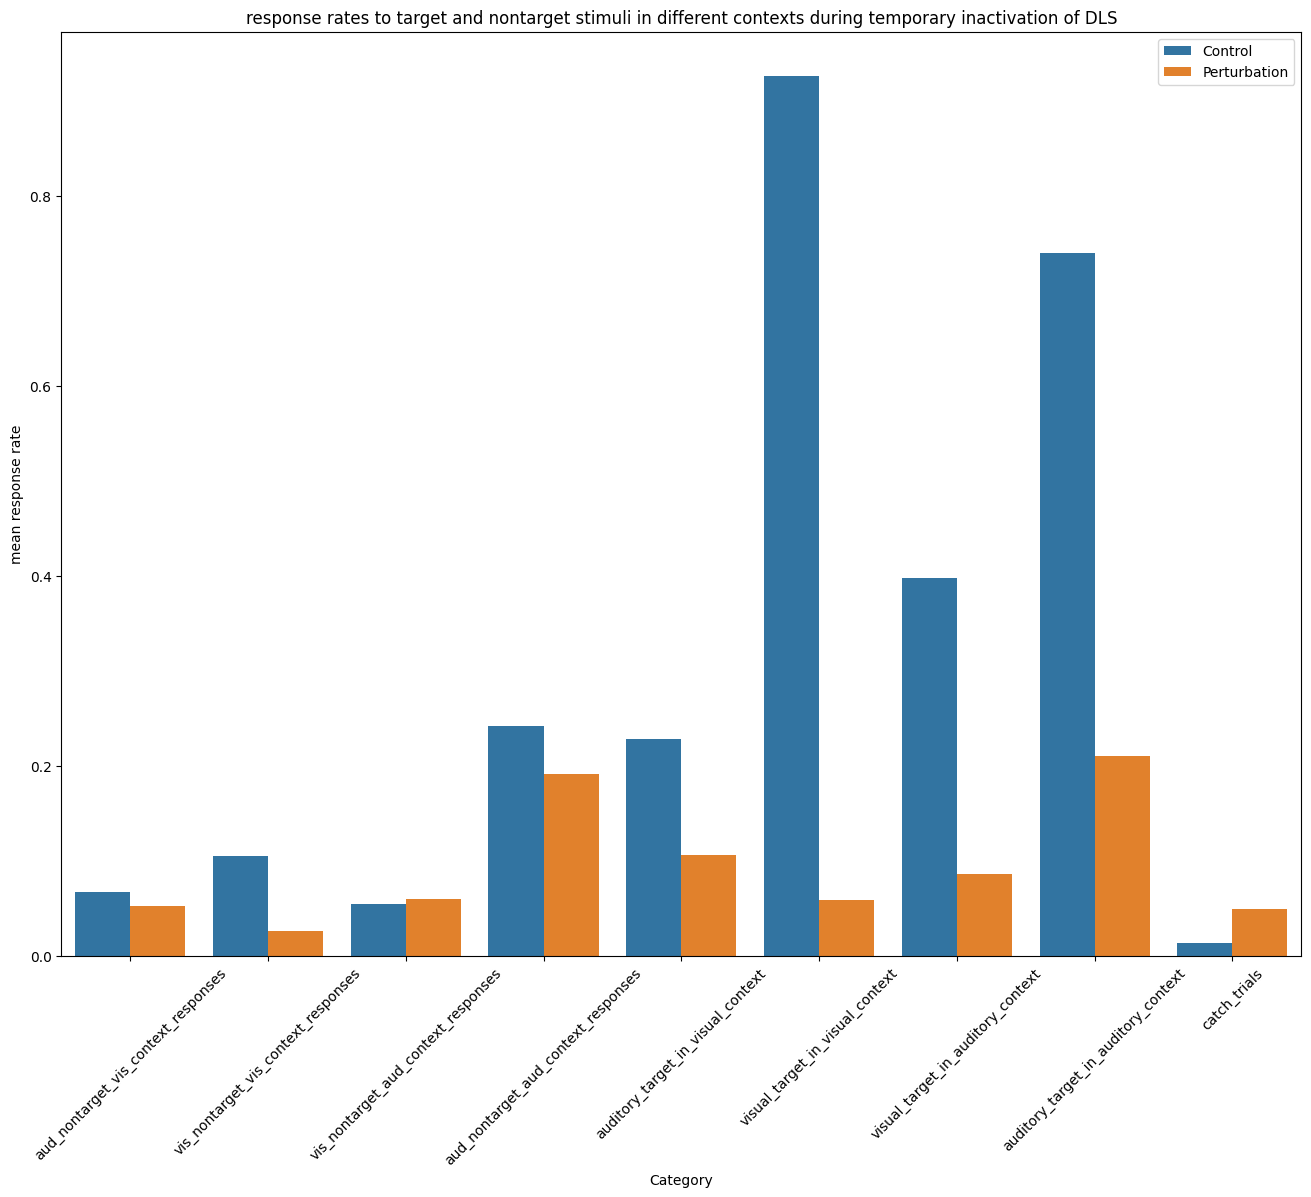

<Figure size 640x480 with 0 Axes>

In [10]:
import seaborn as sns

muscimol_df_dls['session_id'] = muscimol_df_dls['session_id'].astype(str)

avg_values = {
    'Condition': ['Control', 'Perturbation'],

    'aud_nontarget_vis_context_responses': [
    muscimol_df_dls[muscimol_df_dls['control']]['aud_nontarget_vis_context_responses'].mean(),
    muscimol_df_dls[muscimol_df_dls['perturbation']]['aud_nontarget_vis_context_responses'].mean()
    ],

    'vis_nontarget_vis_context_responses': [
    muscimol_df_dls[muscimol_df_dls['control']]['vis_nontarget_vis_context_responses'].mean(),
    muscimol_df_dls[muscimol_df_dls['perturbation']]['vis_nontarget_vis_context_responses'].mean()
        ],

    'vis_nontarget_aud_context_responses': [
    muscimol_df_dls[muscimol_df_dls['control']]['vis_nontarget_aud_context_responses'].mean(),
    muscimol_df_dls[muscimol_df_dls['perturbation']]['vis_nontarget_aud_context_responses'].mean()
        ],
    'aud_nontarget_aud_context_responses': [
    muscimol_df_dls[muscimol_df_dls['control']]['aud_nontarget_aud_context_responses'].mean(),
    muscimol_df_dls[muscimol_df_dls['perturbation']]['aud_nontarget_aud_context_responses'].mean()
          ],
          
    'auditory_target_in_visual_context': [
    muscimol_df_dls[muscimol_df_dls['control']]['auditory_target_in_visual_context'].mean(),
    muscimol_df_dls[muscimol_df_dls['perturbation']]['auditory_target_in_visual_context'].mean()
              ],

     'visual_target_in_visual_context':[
        muscimol_df_dls[muscimol_df_dls['control']]['visual_target_in_visual_context'].mean(),
        muscimol_df_dls[muscimol_df_dls['perturbation']]['visual_target_in_visual_context'].mean()
    ],

    'visual_target_in_auditory_context': [
    muscimol_df_dls[muscimol_df_dls['control']]['visual_target_in_auditory_context'].mean(),
    muscimol_df_dls[muscimol_df_dls['perturbation']]['visual_target_in_auditory_context'].mean()
                  ],

    'auditory_target_in_auditory_context':[
        muscimol_df_dls[muscimol_df_dls['control']]['auditory_target_in_auditory_context'].mean(),
        muscimol_df_dls[muscimol_df_dls['perturbation']]['auditory_target_in_auditory_context'].mean()
    ],
 'catch_trials':[
        muscimol_df_dls[muscimol_df_dls['control']]['catch_trials'].mean(),
        muscimol_df_dls[muscimol_df_dls['perturbation']]['catch_trials'].mean()
    ]
#  'Total Vis Target Aud Context':[
#         muscimol_df_orb[muscimol_df_orb['control']]['total_vis_rewarded_responses_in_aud_context'].mean(),
#         muscimol_df_orb[muscimol_df_orb['perturbation']]['total_vis_rewarded_responses_in_aud_context'].mean()
#     ]

}

# Create a DataFrame from the dictionary
avg_values_df = pd.DataFrame(avg_values)

avg_values_melted_dls = avg_values_df.melt(id_vars='Condition', var_name='Category', value_name='Mean Value')

# Plotting the bar plot
plt.figure(figsize=(16, 12))
ax = sns.barplot(x='Category', y='Mean Value', hue='Condition', data=avg_values_melted_dls)
# plt.xlabel('Category')
plt.xticks(rotation=45)
plt.ylabel('mean response rate')
plt.title('response rates to target and nontarget stimuli in different contexts during temporary inactivation of DLS')
plt.legend(loc='upper right')
plt.show()

# Show the plot
plt.tight_layout()
plt.show()

In [31]:
import seaborn as sns

muscimol_df_dms['session_id'] = muscimol_df_dms['session_id'].astype(str)

t_values = {
    'Condition': ['Control', 'Perturbation'],

    'aud_nontarget_vis_context_responses': [
    muscimol_df_dms[muscimol_df_dms['control']]['aud_nontarget_vis_context_responses'],
    muscimol_df_dms[muscimol_df_dms['perturbation']]['aud_nontarget_vis_context_responses']
    ],

    'vis_nontarget_vis_context_responses': [
    muscimol_df_dms[muscimol_df_dms['control']]['vis_nontarget_vis_context_responses'],
    muscimol_df_dms[muscimol_df_dms['perturbation']]['vis_nontarget_vis_context_responses']
        ],

    'vis_nontarget_aud_context_responses': [
    muscimol_df_dms[muscimol_df_dms['control']]['vis_nontarget_aud_context_responses'],
    muscimol_df_dms[muscimol_df_dms['perturbation']]['vis_nontarget_aud_context_responses']
        ],
    'aud_nontarget_aud_context_responses': [
    muscimol_df_dms[muscimol_df_dms['control']]['aud_nontarget_aud_context_responses'],
    muscimol_df_dms[muscimol_df_dms['perturbation']]['aud_nontarget_aud_context_responses']
          ],
          
    'auditory_target_in_visual_context': [
    muscimol_df_dms[muscimol_df_dms['control']]['auditory_target_in_visual_context'],
    muscimol_df_dms[muscimol_df_dms['perturbation']]['auditory_target_in_visual_context']
              ],

     'visual_target_in_visual_context':[
        muscimol_df_dms[muscimol_df_dms['control']]['visual_target_in_visual_context'],
        muscimol_df_dms[muscimol_df_dms['perturbation']]['visual_target_in_visual_context']
    ],

    'visual_target_in_auditory_context': [
    muscimol_df_dms[muscimol_df_dms['control']]['visual_target_in_auditory_context'],
    muscimol_df_dms[muscimol_df_dms['perturbation']]['visual_target_in_auditory_context']
                  ],

    'auditory_target_in_auditory_context':[
        muscimol_df_dms[muscimol_df_dms['control']]['auditory_target_in_auditory_context'],
        muscimol_df_dms[muscimol_df_dms['perturbation']]['auditory_target_in_auditory_context']
    ],
 'catch_trials':[
        muscimol_df_dms[muscimol_df_dms['control']]['catch_trials'],
        muscimol_df_dms[muscimol_df_dms['perturbation']]['catch_trials']
    ]
#  'Total Vis Target Aud Context':[
#         muscimol_df_orb[muscimol_df_orb['control']]['total_vis_rewarded_responses_in_aud_context'].mean(),
#         muscimol_df_orb[muscimol_df_orb['perturbation']]['total_vis_rewarded_responses_in_aud_context'].mean()
#     ]

}

# Create a DataFrame from the dictionary
t_values_df = pd.DataFrame(t_values)

t_values_melted_dms = t_values_df.melt(id_vars='Condition', var_name='Category', value_name='Mean Value')


C:\Users\vayle.lafehr\AppData\Local\Temp\ipykernel_11940\2726194234.py:28: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', len(unique_groups))


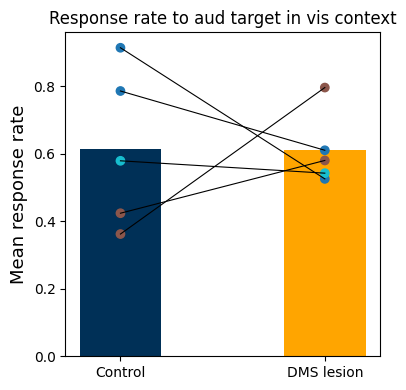

In [25]:
from datetime import datetime, timedelta


muscimol_df_dms['session_id'] = muscimol_df_dms['session_id'].astype(str)

avg_control = muscimol_df_dms[muscimol_df_dms['control']]['auditory_target_in_visual_context'].mean()
avg_perturbation = muscimol_df_dms[muscimol_df_dms['perturbation']]['auditory_target_in_visual_context'].mean()


# Create a bar plot comparing perturbation vs control bars with averages
plt.figure(figsize=(4, 4))
bar_width = 0.4

bars = ['Control', 'DMS lesion']
y_pos = range(len(bars))
averages = [avg_control, avg_perturbation]

plt.bar(y_pos, averages, color=['#003057', '#FFA500'], width=bar_width)

# plt.xlabel('Perturbation Condition')
plt.ylabel('Mean response rate', fontsize = 13)
plt.title('Response rate to aud target in vis context', fontsize = 11.9)
plt.xticks(y_pos, bars)

muscimol_df_dms['color_group'] = muscimol_df_dms['session_id'].apply(lambda x: x.split('_')[0].split('(')[1].strip("'"))

unique_groups = muscimol_df_dms['color_group'].unique()
colors = plt.cm.get_cmap('tab10', len(unique_groups))
color_map = {group: colors(i) for i, group in enumerate(unique_groups)}

control_points = muscimol_df_dms[muscimol_df_dms['control']]['auditory_target_in_visual_context']
perturbation_points = muscimol_df_dms[muscimol_df_dms['perturbation']]['auditory_target_in_visual_context']

control_colors = muscimol_df_dms[muscimol_df_dms['control']]['color_group'].map(color_map)
perturbation_colors = muscimol_df_dms[muscimol_df_dms['perturbation']]['color_group'].map(color_map)

plt.scatter([0]*len(control_points), control_points, color=control_colors, zorder=2)
plt.scatter([1]*len(perturbation_points), perturbation_points, color=perturbation_colors, zorder=2)


muscimol_df_dms['date'] = muscimol_df_dms['session_id'].apply(lambda x: datetime.strptime(x.split('_')[1].split("'")[0], '%Y-%m-%d'))
            
for i in range(1, len(muscimol_df_dms), 2):
    x_coords = [0 if muscimol_df_dms.loc[i-1, 'control'] else 1, 0 if muscimol_df_dms.loc[i, 'control'] else 1]
    y_coords = [muscimol_df_dms.loc[i-1, 'auditory_target_in_visual_context'], muscimol_df_dms.loc[i, 'auditory_target_in_visual_context']]
    plt.plot(x_coords, y_coords, color='black', linestyle='-', linewidth=0.8)


# for i in range(len(muscimol_df)):
#     session_id_label = muscimol_df.loc[i, 'session_id'].replace("DynamicRoutingSession", "")
#     if muscimol_df.loc[i, 'control']:
#         plt.text(0, muscimol_df.loc[i, 'visual_target_in_visual_context'] + 0.009 * i, session_id_label, fontsize=6, rotation=5, va='bottom')
#     else:
#         plt.text(1, muscimol_df.loc[i, 'visual_target_in_visual_context']+ 0.006 * i - 0.003 * len(muscimol_df), session_id_label, fontsize=6, rotation=0, ha='left')


# handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=color_map[group], markersize=10) for group in unique_groups]
# labels = unique_groups
# plt.legend(handles, labels, title="Mouse")


# Show the plot
plt.tight_layout()

plt.savefig(r"C:\Users\vayle.lafehr\Desktop\perturbation_analysis_figures\dms_response_rate_aud_target_vis_context.png", dpi=300)
plt.savefig(r"Z:\vayle\muscimol_DMS_behavior_plots\response_rate_aud_target_vis_context.png", dpi=300)

plt.show()

C:\Users\vayle.lafehr\AppData\Local\Temp\ipykernel_11940\2176128011.py:28: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', len(unique_groups))


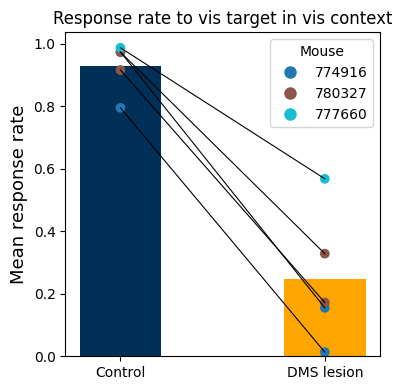

In [21]:
from datetime import datetime, timedelta


muscimol_df_dms['session_id'] = muscimol_df_dms['session_id'].astype(str)

avg_control = muscimol_df_dms[muscimol_df_dms['control']]['visual_target_in_visual_context'].mean()
avg_perturbation = muscimol_df_dms[muscimol_df_dms['perturbation']]['visual_target_in_visual_context'].mean()


# Create a bar plot comparing perturbation vs control bars with averages
plt.figure(figsize=(4, 4))
bar_width = 0.4

bars = ['Control', 'DMS lesion']
y_pos = range(len(bars))
averages = [avg_control, avg_perturbation]

plt.bar(y_pos, averages, color=['#003057', '#FFA500'], width=bar_width)

# plt.xlabel('Perturbation Condition')
plt.ylabel('Mean response rate', fontsize = 13)
plt.title('Response rate to vis target in vis context', fontsize = 11.9)
plt.xticks(y_pos, bars)

muscimol_df_dms['color_group'] = muscimol_df_dms['session_id'].apply(lambda x: x.split('_')[0].split('(')[1].strip("'"))

unique_groups = muscimol_df_dms['color_group'].unique()
colors = plt.cm.get_cmap('tab10', len(unique_groups))
color_map = {group: colors(i) for i, group in enumerate(unique_groups)}

control_points = muscimol_df_dms[muscimol_df_dms['control']]['visual_target_in_visual_context']
perturbation_points = muscimol_df_dms[muscimol_df_dms['perturbation']]['visual_target_in_visual_context']

control_colors = muscimol_df_dms[muscimol_df_dms['control']]['color_group'].map(color_map)
perturbation_colors = muscimol_df_dms[muscimol_df_dms['perturbation']]['color_group'].map(color_map)

plt.scatter([0]*len(control_points), control_points, color=control_colors, zorder=2)
plt.scatter([1]*len(perturbation_points), perturbation_points, color=perturbation_colors, zorder=2)


muscimol_df_dms['date'] = muscimol_df_dms['session_id'].apply(lambda x: datetime.strptime(x.split('_')[1].split("'")[0], '%Y-%m-%d'))
            
for i in range(1, len(muscimol_df_dms), 2):
    x_coords = [0 if muscimol_df_dms.loc[i-1, 'control'] else 1, 0 if muscimol_df_dms.loc[i, 'control'] else 1]
    y_coords = [muscimol_df_dms.loc[i-1, 'visual_target_in_visual_context'], muscimol_df_dms.loc[i, 'visual_target_in_visual_context']]
    plt.plot(x_coords, y_coords, color='black', linestyle='-', linewidth=0.8)


# for i in range(len(muscimol_df)):
#     session_id_label = muscimol_df.loc[i, 'session_id'].replace("DynamicRoutingSession", "")
#     if muscimol_df.loc[i, 'control']:
#         plt.text(0, muscimol_df.loc[i, 'visual_target_in_visual_context'] + 0.009 * i, session_id_label, fontsize=6, rotation=5, va='bottom')
#     else:
#         plt.text(1, muscimol_df.loc[i, 'visual_target_in_visual_context']+ 0.006 * i - 0.003 * len(muscimol_df), session_id_label, fontsize=6, rotation=0, ha='left')


handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=color_map[group], markersize=10) for group in unique_groups]
labels = unique_groups
plt.legend(handles, labels, title="Mouse")


# Show the plot
plt.tight_layout()

plt.savefig(r"Z:\vayle\muscimol_DMS_behavior_plots\response_rate_vis_target_vis_context.png", dpi=300)
plt.show()

In [604]:
t_values_melted_dms  = t_values_melted_dms.explode('Mean Value')
t_values_melted_dms 
control_values_dms=t_values_melted_dms.query('Condition=="Control" and Category=="visual_target_in_visual_context"')['Mean Value'].values
# control_values_dms
perturb_values_dms=t_values_melted_dms.query('Condition=="Perturbation" and Category=="visual_target_in_visual_context"')['Mean Value'].values

from scipy import stats

t_stat,p_val=stats.ttest_rel(control_values_dms,perturb_values_dms)
print(t_stat, p_val)

9.50426362356767 0.0006840475604063495


C:\Users\vayle.lafehr\AppData\Local\Temp\ipykernel_11940\3900139448.py:28: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', len(unique_groups))


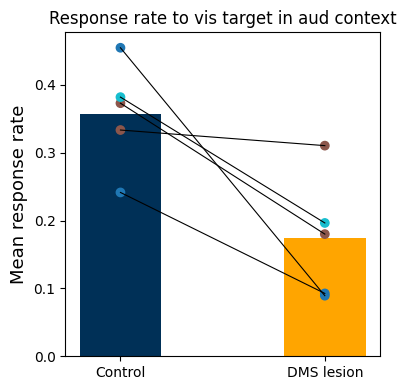

In [23]:
from datetime import datetime, timedelta


muscimol_df_dms['session_id'] = muscimol_df_dms['session_id'].astype(str)

avg_control = muscimol_df_dms[muscimol_df_dms['control']]['visual_target_in_auditory_context'].mean()
avg_perturbation = muscimol_df_dms[muscimol_df_dms['perturbation']]['visual_target_in_auditory_context'].mean()


# Create a bar plot comparing perturbation vs control bars with averages
plt.figure(figsize=(4, 4))
bar_width = 0.4

bars = ['Control', 'DMS lesion']
y_pos = range(len(bars))
averages = [avg_control, avg_perturbation]

plt.bar(y_pos, averages, color=['#003057', '#FFA500'], width=bar_width)

# plt.xlabel('Perturbation Condition')
plt.ylabel('Mean response rate', fontsize = 13)
plt.title('Response rate to vis target in aud context', fontsize = 11.9)
plt.xticks(y_pos, bars)

muscimol_df_dms['color_group'] = muscimol_df_dms['session_id'].apply(lambda x: x.split('_')[0].split('(')[1].strip("'"))

unique_groups = muscimol_df_dms['color_group'].unique()
colors = plt.cm.get_cmap('tab10', len(unique_groups))
color_map = {group: colors(i) for i, group in enumerate(unique_groups)}

control_points = muscimol_df_dms[muscimol_df_dms['control']]['visual_target_in_auditory_context']
perturbation_points = muscimol_df_dms[muscimol_df_dms['perturbation']]['visual_target_in_auditory_context']

control_colors = muscimol_df_dms[muscimol_df_dms['control']]['color_group'].map(color_map)
perturbation_colors = muscimol_df_dms[muscimol_df_dms['perturbation']]['color_group'].map(color_map)

plt.scatter([0]*len(control_points), control_points, color=control_colors, zorder=2)
plt.scatter([1]*len(perturbation_points), perturbation_points, color=perturbation_colors, zorder=2)


muscimol_df_dms['date'] = muscimol_df_dms['session_id'].apply(lambda x: datetime.strptime(x.split('_')[1].split("'")[0], '%Y-%m-%d'))
            
for i in range(1, len(muscimol_df_dms), 2):
    x_coords = [0 if muscimol_df_dms.loc[i-1, 'control'] else 1, 0 if muscimol_df_dms.loc[i, 'control'] else 1]
    y_coords = [muscimol_df_dms.loc[i-1, 'visual_target_in_auditory_context'], muscimol_df_dms.loc[i, 'visual_target_in_auditory_context']]
    plt.plot(x_coords, y_coords, color='black', linestyle='-', linewidth=0.8)


# for i in range(len(muscimol_df)):
#     session_id_label = muscimol_df.loc[i, 'session_id'].replace("DynamicRoutingSession", "")
#     if muscimol_df.loc[i, 'control']:
#         plt.text(0, muscimol_df.loc[i, 'visual_target_in_visual_context'] + 0.009 * i, session_id_label, fontsize=6, rotation=5, va='bottom')
#     else:
#         plt.text(1, muscimol_df.loc[i, 'visual_target_in_visual_context']+ 0.006 * i - 0.003 * len(muscimol_df), session_id_label, fontsize=6, rotation=0, ha='left')


# handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=color_map[group], markersize=10) for group in unique_groups]
# labels = unique_groups
# plt.legend(handles, labels, title="Mouse")


# Show the plot
plt.tight_layout()

plt.savefig(r"C:\Users\vayle.lafehr\Desktop\perturbation_analysis_figures\dms_response_rate_vis_target_vis_context.png", dpi=300)
plt.savefig(r"Z:\vayle\muscimol_DMS_behavior_plots\response_rate_vis_target_aud_context.png", dpi=300)
plt.show()

In [606]:
t_values_melted_dms  = t_values_melted_dms.explode('Mean Value')
t_values_melted_dms 
control_values_dms=t_values_melted_dms.query('Condition=="Control" and Category=="visual_target_in_auditory_context"')['Mean Value'].values
# control_values_dms
perturb_values_dms=t_values_melted_dms.query('Condition=="Perturbation" and Category=="visual_target_in_auditory_context"')['Mean Value'].values

from scipy import stats

t_stat,p_val=stats.ttest_rel(control_values_dms,perturb_values_dms)
print(t_stat, p_val)

3.339549328036412 0.02884787177732476


C:\Users\vayle.lafehr\AppData\Local\Temp\ipykernel_11940\2576234714.py:28: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', len(unique_groups))


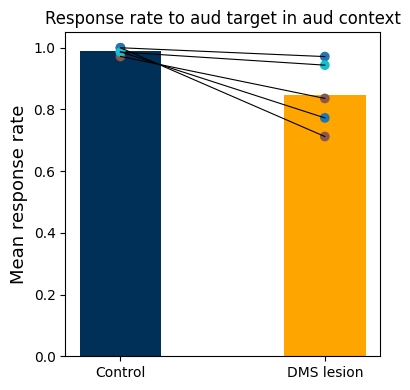

In [24]:
from datetime import datetime, timedelta


muscimol_df_dms['session_id'] = muscimol_df_dms['session_id'].astype(str)

avg_control = muscimol_df_dms[muscimol_df_dms['control']]['auditory_target_in_auditory_context'].mean()
avg_perturbation = muscimol_df_dms[muscimol_df_dms['perturbation']]['auditory_target_in_auditory_context'].mean()


# Create a bar plot comparing perturbation vs control bars with averages
plt.figure(figsize=(4, 4))
bar_width = 0.4

bars = ['Control', 'DMS lesion']
y_pos = range(len(bars))
averages = [avg_control, avg_perturbation]

plt.bar(y_pos, averages, color=['#003057', '#FFA500'], width=bar_width)

# plt.xlabel('Perturbation Condition')
plt.ylabel('Mean response rate', fontsize = 13)
plt.title('Response rate to aud target in aud context', fontsize = 11.9)
plt.xticks(y_pos, bars)

muscimol_df_dms['color_group'] = muscimol_df_dms['session_id'].apply(lambda x: x.split('_')[0].split('(')[1].strip("'"))

unique_groups = muscimol_df_dms['color_group'].unique()
colors = plt.cm.get_cmap('tab10', len(unique_groups))
color_map = {group: colors(i) for i, group in enumerate(unique_groups)}

control_points = muscimol_df_dms[muscimol_df_dms['control']]['auditory_target_in_auditory_context']
perturbation_points = muscimol_df_dms[muscimol_df_dms['perturbation']]['auditory_target_in_auditory_context']

control_colors = muscimol_df_dms[muscimol_df_dms['control']]['color_group'].map(color_map)
perturbation_colors = muscimol_df_dms[muscimol_df_dms['perturbation']]['color_group'].map(color_map)

plt.scatter([0]*len(control_points), control_points, color=control_colors, zorder=2)
plt.scatter([1]*len(perturbation_points), perturbation_points, color=perturbation_colors, zorder=2)


muscimol_df_dms['date'] = muscimol_df_dms['session_id'].apply(lambda x: datetime.strptime(x.split('_')[1].split("'")[0], '%Y-%m-%d'))
            
for i in range(1, len(muscimol_df_dms), 2):
    x_coords = [0 if muscimol_df_dms.loc[i-1, 'control'] else 1, 0 if muscimol_df_dms.loc[i, 'control'] else 1]
    y_coords = [muscimol_df_dms.loc[i-1, 'auditory_target_in_auditory_context'], muscimol_df_dms.loc[i, 'auditory_target_in_auditory_context']]
    plt.plot(x_coords, y_coords, color='black', linestyle='-', linewidth=0.8)


# for i in range(len(muscimol_df)):
#     session_id_label = muscimol_df.loc[i, 'session_id'].replace("DynamicRoutingSession", "")
#     if muscimol_df.loc[i, 'control']:
#         plt.text(0, muscimol_df.loc[i, 'visual_target_in_visual_context'] + 0.009 * i, session_id_label, fontsize=6, rotation=5, va='bottom')
#     else:
#         plt.text(1, muscimol_df.loc[i, 'visual_target_in_visual_context']+ 0.006 * i - 0.003 * len(muscimol_df), session_id_label, fontsize=6, rotation=0, ha='left')


# handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=color_map[group], markersize=10) for group in unique_groups]
# labels = unique_groups
# plt.legend(handles, labels, title="Mouse")


# Show the plot
plt.tight_layout()

plt.savefig(r"C:\Users\vayle.lafehr\Desktop\perturbation_analysis_figures\dms_response_rate_aud_target_aud_context.png", dpi=300)
plt.savefig(r"Z:\vayle\muscimol_DMS_behavior_plots\response_rate_aud_target_aud_context.png", dpi=300)
plt.show()

In [613]:
t_values_melted_dms  = t_values_melted_dms.explode('Mean Value')
t_values_melted_dms 
control_values_dms=t_values_melted_dms.query('Condition=="Control" and Category=="auditory_target_in_auditory_context"')['Mean Value'].values
# control_values_dms
perturb_values_dms=t_values_melted_dms.query('Condition=="Perturbation" and Category=="auditory_target_in_auditory_context"')['Mean Value'].values

from scipy import stats

t_stat,p_val=stats.ttest_rel(control_values_dms,perturb_values_dms)
print(t_stat, p_val)

2.8572763787059317 0.04605594949894982


C:\Users\vayle.lafehr\AppData\Local\Temp\ipykernel_28152\3728899388.py:28: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', len(unique_groups))


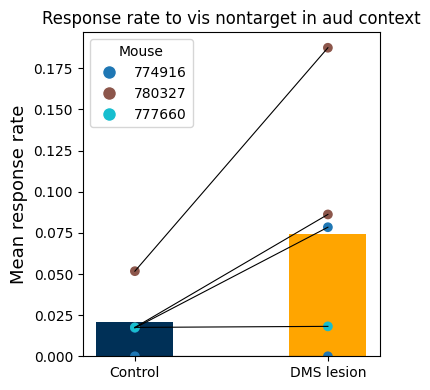

In [610]:
from datetime import datetime, timedelta


muscimol_df_dms['session_id'] = muscimol_df_dms['session_id'].astype(str)

avg_control = muscimol_df_dms[muscimol_df_dms['control']]['vis_nontarget_aud_context_responses'].mean()
avg_perturbation = muscimol_df_dms[muscimol_df_dms['perturbation']]['vis_nontarget_aud_context_responses'].mean()


# Create a bar plot comparing perturbation vs control bars with averages
plt.figure(figsize=(4, 4))
bar_width = 0.4

bars = ['Control', 'DMS lesion']
y_pos = range(len(bars))
averages = [avg_control, avg_perturbation]

plt.bar(y_pos, averages, color=['#003057', '#FFA500'], width=bar_width)

# plt.xlabel('Perturbation Condition')
plt.ylabel('Mean response rate', fontsize = 13)
plt.title('Response rate to vis nontarget in aud context', fontsize = 11.9)
plt.xticks(y_pos, bars)

muscimol_df_dms['color_group'] = muscimol_df_dms['session_id'].apply(lambda x: x.split('_')[0].split('(')[1].strip("'"))

unique_groups = muscimol_df_dms['color_group'].unique()
colors = plt.cm.get_cmap('tab10', len(unique_groups))
color_map = {group: colors(i) for i, group in enumerate(unique_groups)}

control_points = muscimol_df_dms[muscimol_df_dms['control']]['vis_nontarget_aud_context_responses']
perturbation_points = muscimol_df_dms[muscimol_df_dms['perturbation']]['vis_nontarget_aud_context_responses']

control_colors = muscimol_df_dms[muscimol_df_dms['control']]['color_group'].map(color_map)
perturbation_colors = muscimol_df_dms[muscimol_df_dms['perturbation']]['color_group'].map(color_map)

plt.scatter([0]*len(control_points), control_points, color=control_colors, zorder=2)
plt.scatter([1]*len(perturbation_points), perturbation_points, color=perturbation_colors, zorder=2)


muscimol_df_dms['date'] = muscimol_df_dms['session_id'].apply(lambda x: datetime.strptime(x.split('_')[1].split("'")[0], '%Y-%m-%d'))
            
for i in range(1, len(muscimol_df_dms), 2):
    x_coords = [0 if muscimol_df_dms.loc[i-1, 'control'] else 1, 0 if muscimol_df_dms.loc[i, 'control'] else 1]
    y_coords = [muscimol_df_dms.loc[i-1, 'vis_nontarget_aud_context_responses'], muscimol_df_dms.loc[i, 'vis_nontarget_aud_context_responses']]
    plt.plot(x_coords, y_coords, color='black', linestyle='-', linewidth=0.8)


# for i in range(len(muscimol_df)):
#     session_id_label = muscimol_df.loc[i, 'session_id'].replace("DynamicRoutingSession", "")
#     if muscimol_df.loc[i, 'control']:
#         plt.text(0, muscimol_df.loc[i, 'visual_target_in_visual_context'] + 0.009 * i, session_id_label, fontsize=6, rotation=5, va='bottom')
#     else:
#         plt.text(1, muscimol_df.loc[i, 'visual_target_in_visual_context']+ 0.006 * i - 0.003 * len(muscimol_df), session_id_label, fontsize=6, rotation=0, ha='left')


handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=color_map[group], markersize=10) for group in unique_groups]
labels = unique_groups
plt.legend(handles, labels, title="Mouse")


# Show the plot
plt.tight_layout()

# plt.savefig(r"C:\Users\vayle.lafehr\Desktop\perturbation_analysis_figures\response_rate_vis_target_vis_context.png", dpi=300)
plt.show()

In [598]:
muscimol_data_cptail = []

#def(mouse, perturbation or control)
session_ids = ['780327_2025-04-03', '780327_2025-04-04','780327_2025-04-10', '780327_2025-04-11']
control = ['780327_2025-04-03', '780327_2025-04-10']
perturbation = ['780327_2025-04-04', '780327_2025-04-11']

vis_first_perturbations = []
aud_first_perturbations=[]

for session in session_ids:
    session = npc_sessions.Session(session)
   
    
#vis nontarget in vis context
    vis_nontarget_vis_context = session.trials[:].query(
    'is_vis_context == True & is_response == True & is_vis_nontarget == True')
    all_vis_nontargets_vis_context = session.trials[:].query(
    'is_vis_context == True & is_vis_nontarget == True')
    vis_nontarget_vis_context_responses = (len(vis_nontarget_vis_context)) / (len(all_vis_nontargets_vis_context))

#aud nontarget in vis context
    aud_nontarget_vis_context = session.trials[:].query(
    'is_vis_context == True & is_aud_nontarget == True & is_response == True')
    all_aud_nontargets_vis_context = session.trials[:].query(
    'is_vis_context == True & is_aud_nontarget == True')
    aud_nontarget_vis_context_responses = (len(aud_nontarget_vis_context)) / (len(all_aud_nontargets_vis_context))

# vis nontarget in aud context
    vis_nontarget_aud_context = session.trials[:].query(
    'is_aud_context == True & is_response == True & is_vis_nontarget == True')
    all_vis_nontargets_aud_context = session.trials[:].query(
    'is_aud_context == True & is_vis_nontarget == True')
    vis_nontarget_aud_context_responses = (len(vis_nontarget_aud_context)) / (len(all_vis_nontargets_aud_context))

#aud nontarget in aud context
    aud_nontarget_aud_context = session.trials[:].query(
    'is_aud_context == True & is_aud_nontarget == True & is_response == True')
    all_aud_nontargets_aud_context = session.trials[:].query(
    'is_aud_context == True & is_aud_nontarget == True')
    aud_nontarget_aud_context_responses = (len(aud_nontarget_aud_context)) / (len(all_aud_nontargets_aud_context))

# #total responses to aud target in aud context
    aud_rewarded_responses_in_aud_context = session.trials[:].query(
            'is_response == True & is_aud_target == True & is_aud_context == True'
      )
    all_aud_rewarded_responses_in_aud_context = session.trials[:].query(
           'is_aud_target == True & is_aud_context'
    )
    auditory_target_in_auditory_context = (len(aud_rewarded_responses_in_aud_context)/(len(all_aud_rewarded_responses_in_aud_context)))

# #total responses to vis target in vis context
    vis_rewarded_responses_in_vis_context = session.trials[:].query(
            'is_response == True & is_vis_target == True & is_vis_context == True'
      )
    all_vis_rewarded_responses_in_vis_context = session.trials[:].query(
           'is_vis_target == True & is_vis_context'
    )
    visual_target_in_visual_context = (len(vis_rewarded_responses_in_vis_context)/(len(all_vis_rewarded_responses_in_vis_context)))

#total responses to aud target in vis context
    aud_rewarded_responses_in_vis_context = session.trials[:].query(
            'is_response == True & is_aud_target == True & is_vis_context == True'
      )
    all_rewarded_responses_in_vis_context = session.trials[:].query(
            'is_aud_target == True & is_vis_context == True'
      )
    auditory_target_in_visual_context = (len(aud_rewarded_responses_in_vis_context)/(len(all_rewarded_responses_in_vis_context)))

#total responses to vis target in aud context
    vis_rewarded_responses_in_aud_context = session.trials[:].query(
            'is_response == True & is_vis_target == True & is_aud_context == True'
      )
    
    all_rewarded_responses_in_aud_context = session.trials[:].query(
            'is_vis_target == True & is_aud_context == True'
      )
    
    visual_target_in_auditory_context = (len(vis_rewarded_responses_in_aud_context)/(len(all_rewarded_responses_in_aud_context)))


#catch trials
    catch_responses = session.trials[:].query(
            'is_response == True & is_catch == True'
      )
    
    all_catch = session.trials[:].query(
            'is_catch == True'
      )
    
    catch_trials = (len(catch_responses)/(len(all_catch)))

    # muscimol_data.append(total_correct_responses)
    result = dict(
                    session_id=session,
                    control = False,
                    perturbation = False,
                    vis_nontarget_vis_context_responses=vis_nontarget_vis_context_responses,
                    aud_nontarget_vis_context_responses=aud_nontarget_vis_context_responses,
                    vis_nontarget_aud_context_responses=vis_nontarget_aud_context_responses,
                    aud_nontarget_aud_context_responses=aud_nontarget_aud_context_responses,
                    auditory_target_in_visual_context=auditory_target_in_visual_context,
                    visual_target_in_auditory_context=visual_target_in_auditory_context,
                    visual_target_in_visual_context=visual_target_in_visual_context,
                    auditory_target_in_auditory_context =auditory_target_in_auditory_context,
                    catch_trials=catch_trials
                    )
    
    if session in perturbation:
            result['perturbation'] = True
    else:
            result['control'] = True
            
            
    muscimol_data_cptail.append(result)

# print(muscimol_data)
muscimol_data_cptail  = pd.DataFrame(muscimol_data_cptail )
print(muscimol_data_cptail )

                                   session_id  control  perturbation  \
0  DynamicRoutingSession('780327_2025-04-03')     True         False   
1  DynamicRoutingSession('780327_2025-04-04')    False          True   
2  DynamicRoutingSession('780327_2025-04-10')     True         False   
3  DynamicRoutingSession('780327_2025-04-11')    False          True   

   vis_nontarget_vis_context_responses  aud_nontarget_vis_context_responses  \
0                             0.000000                             0.033898   
1                             0.000000                             0.050000   
2                             0.051724                             0.065574   
3                             0.000000                             0.017544   

   vis_nontarget_aud_context_responses  aud_nontarget_aud_context_responses  \
0                                  0.0                             0.000000   
1                                  0.0                             0.035088   
2     

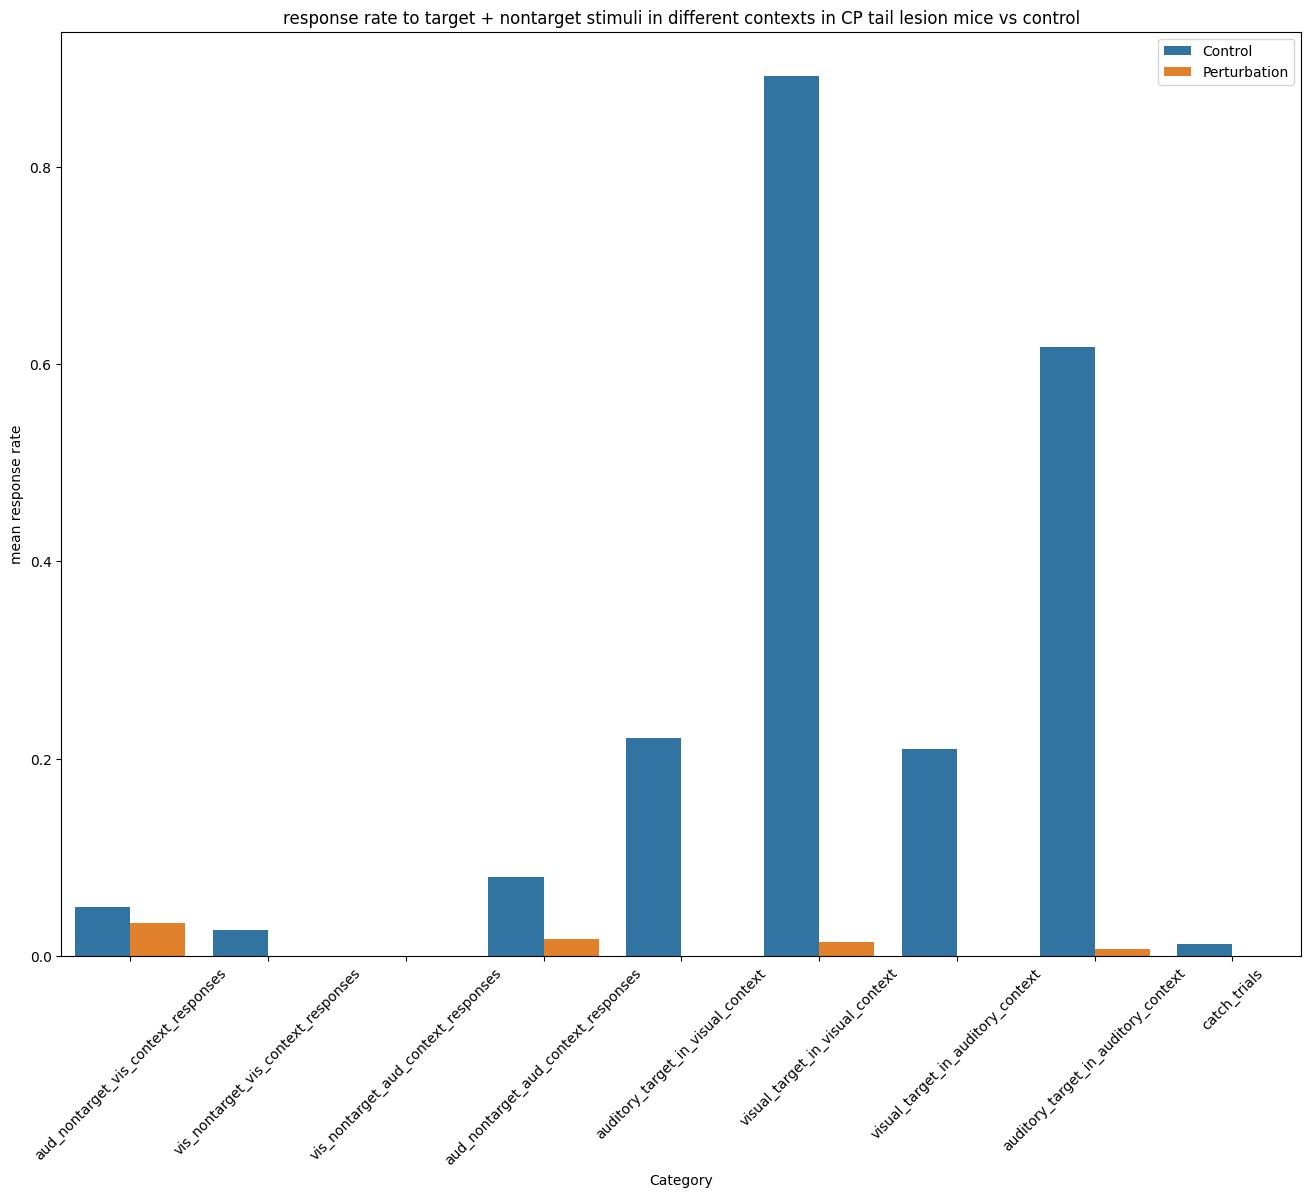

<Figure size 640x480 with 0 Axes>

In [599]:
import seaborn as sns

muscimol_data_cptail['session_id'] = muscimol_data_cptail['session_id'].astype(str)

avg_values_cptail = {
    'Condition': ['Control', 'Perturbation'],

    'aud_nontarget_vis_context_responses': [
    muscimol_data_cptail[muscimol_data_cptail['control']]['aud_nontarget_vis_context_responses'].mean(),
    muscimol_data_cptail[muscimol_data_cptail['perturbation']]['aud_nontarget_vis_context_responses'].mean()
    ],

    'vis_nontarget_vis_context_responses': [
    muscimol_data_cptail[muscimol_data_cptail['control']]['vis_nontarget_vis_context_responses'].mean(),
    muscimol_data_cptail[muscimol_data_cptail['perturbation']]['vis_nontarget_vis_context_responses'].mean()
        ],

    'vis_nontarget_aud_context_responses': [
    muscimol_data_cptail[muscimol_data_cptail['control']]['vis_nontarget_aud_context_responses'].mean(),
    muscimol_data_cptail[muscimol_data_cptail['perturbation']]['vis_nontarget_aud_context_responses'].mean()
        ],
    'aud_nontarget_aud_context_responses': [
    muscimol_data_cptail[muscimol_data_cptail['control']]['aud_nontarget_aud_context_responses'].mean(),
    muscimol_data_cptail[muscimol_data_cptail['perturbation']]['aud_nontarget_aud_context_responses'].mean()
          ],
          
    'auditory_target_in_visual_context': [
    muscimol_data_cptail[muscimol_data_cptail['control']]['auditory_target_in_visual_context'].mean(),
    muscimol_data_cptail[muscimol_data_cptail['perturbation']]['auditory_target_in_visual_context'].mean()
              ],

     'visual_target_in_visual_context':[
       muscimol_data_cptail[muscimol_data_cptail['control']]['visual_target_in_visual_context'].mean(),
        muscimol_data_cptail[muscimol_data_cptail['perturbation']]['visual_target_in_visual_context'].mean()
    ],

    'visual_target_in_auditory_context': [
    muscimol_data_cptail[muscimol_data_cptail['control']]['visual_target_in_auditory_context'].mean(),
    muscimol_data_cptail[muscimol_data_cptail['perturbation']]['visual_target_in_auditory_context'].mean()
                  ],

    'auditory_target_in_auditory_context':[
        muscimol_data_cptail[muscimol_data_cptail['control']]['auditory_target_in_auditory_context'].mean(),
        muscimol_data_cptail[muscimol_data_cptail['perturbation']]['auditory_target_in_auditory_context'].mean()
    ],
 'catch_trials':[
        muscimol_data_cptail[muscimol_data_cptail['control']]['catch_trials'].mean(),
        muscimol_data_cptail[muscimol_data_cptail['perturbation']]['catch_trials'].mean()
    ]
#  'Total Vis Target Aud Context':[
#         muscimol_df_orb[muscimol_df_orb['control']]['total_vis_rewarded_responses_in_aud_context'].mean(),
#         muscimol_df_orb[muscimol_df_orb['perturbation']]['total_vis_rewarded_responses_in_aud_context'].mean()
#     ]

}

# Create a DataFrame from the dictionary
avg_values_df_cptail = pd.DataFrame(avg_values_cptail)

avg_values_melted_cptail = avg_values_df_cptail.melt(id_vars='Condition', var_name='Category', value_name='Mean Value')

# Plotting the bar plot
plt.figure(figsize=(16, 12))
ax = sns.barplot(x='Category', y='Mean Value', hue='Condition', data=avg_values_melted_cptail)
plt.xlabel('Category')
plt.xticks(rotation=45)
plt.ylabel('mean response rate')
plt.title('response rate to target + nontarget stimuli in different contexts in CP tail lesion mice vs control')
plt.legend(loc='upper right')
plt.show()

# Show the plot
plt.tight_layout()
plt.show()

## SC data

In [ ]:
muscimol_data_sc = []

#def(mouse, perturbation or control)
session_ids = ['777661_2025-05-02', '777661_2025-04-25', '777661_2025-05-08', '777661_2025-05-09','739828_2025-02-13', '739828_2025-02-14', '737412_2024-12-18','737412_2024-12-19','746138_2024-12-17', '746138_2024-12-18','739828_2025-02-20','739828_2025-02-21']
control = ['746138_2024-12-17','777661_2025-04-25', '777661_2025-05-08','739828_2025-02-13', '737412_2024-12-18', '739828_2025-02-20' ]
perturbation = ['746138_2024-12-18', '777661_2025-05-02','777661_2025-05-09','739828_2025-02-14', '737412_2024-12-19', '739828_2025-02-21' ]

for i, session_id in enumerate(session_ids):
    session = npc_sessions.Session(session_id)
   
    
#vis nontarget in vis context
    vis_nontarget_vis_context = session.trials[:].query(
    "rewarded_modality == 'vis' & is_response == True & is_vis_nontarget == True")
    all_vis_nontargets_vis_context = session.trials[:].query(
    "rewarded_modality == 'vis' & is_vis_nontarget == True")
    vis_nontarget_vis_context_responses = (len(vis_nontarget_vis_context)) / (len(all_vis_nontargets_vis_context))

#aud nontarget in vis context
    aud_nontarget_vis_context = session.trials[:].query(
    "rewarded_modality == 'vis' & is_aud_nontarget == True & is_response == True")
    all_aud_nontargets_vis_context = session.trials[:].query(
    "rewarded_modality == 'vis' & is_aud_nontarget == True")
    aud_nontarget_vis_context_responses = (len(aud_nontarget_vis_context)) / (len(all_aud_nontargets_vis_context))

# vis nontarget in aud context
    vis_nontarget_aud_context = session.trials[:].query(
    "rewarded_modality == 'aud' & is_response == True & is_vis_nontarget == True")
    all_vis_nontargets_aud_context = session.trials[:].query(
    "rewarded_modality == 'aud' & is_vis_nontarget == True")
    vis_nontarget_aud_context_responses = (len(vis_nontarget_aud_context)) / (len(all_vis_nontargets_aud_context))

#aud nontarget in aud context
    aud_nontarget_aud_context = session.trials[:].query(
    "rewarded_modality == 'aud' & is_aud_nontarget == True & is_response == True")
    all_aud_nontargets_aud_context = session.trials[:].query(
    "rewarded_modality == 'aud' & is_aud_nontarget == True")
    aud_nontarget_aud_context_responses = (len(aud_nontarget_aud_context)) / (len(all_aud_nontargets_aud_context))

#aud target in aud context
    aud_target_responses_in_aud_context = session.trials[:].query(
    "is_response == True & is_aud_target == True & rewarded_modality == 'aud'")
    all_aud_targets_aud_context = session.trials[:].query(
    "is_aud_target == True & rewarded_modality == 'aud'")
    auditory_target_in_auditory_context = (len(aud_target_responses_in_aud_context)/(len(all_aud_targets_aud_context)))

#vis target in vis context
    vis_rewarded_responses_in_vis_context = session.trials[:].query(
    "is_response == True & is_vis_target == True & rewarded_modality == 'vis'")
    all_vis_rewarded_responses_in_vis_context = session.trials[:].query(
    "is_vis_target == True & rewarded_modality == 'vis'")
    visual_target_in_visual_context = (len(vis_rewarded_responses_in_vis_context)/(len(all_vis_rewarded_responses_in_vis_context)))

#aud target in vis context
    aud_rewarded_responses_in_vis_context = session.trials[:].query(
    "is_response == True & is_aud_target == True & rewarded_modality == 'vis'")
    all_rewarded_responses_in_vis_context = session.trials[:].query(
    "is_aud_target == True & rewarded_modality == 'vis'")
    auditory_target_in_visual_context = (len(aud_rewarded_responses_in_vis_context)/(len(all_rewarded_responses_in_vis_context)))

#vis target in aud context
    vis_rewarded_responses_in_aud_context = session.trials[:].query(
    "is_response == True & is_vis_target == True & rewarded_modality == 'aud'")
    all_rewarded_responses_in_aud_context = session.trials[:].query(
    "is_vis_target == True & rewarded_modality == 'aud'")
    visual_target_in_auditory_context = (len(vis_rewarded_responses_in_aud_context)/(len(all_rewarded_responses_in_aud_context)))

#catch trials
    catch_responses = session.trials[:].query(
    'is_response == True & is_catch == True')
    all_catch = session.trials[:].query(
    'is_catch == True')
    catch_trials = (len(catch_responses)/(len(all_catch)))

    result = dict(
                    session_id=session,
                    control = session_id in control,
                    perturbation = session_id in perturbation,
                    # ori_first = session_id in ori_first,
                    # amn_first = session_id in amn_first,
                    vis_nontarget_vis_context_responses=vis_nontarget_vis_context_responses,
                    aud_nontarget_vis_context_responses=aud_nontarget_vis_context_responses,
                    vis_nontarget_aud_context_responses=vis_nontarget_aud_context_responses,
                    aud_nontarget_aud_context_responses=aud_nontarget_aud_context_responses,
                    auditory_target_in_visual_context=auditory_target_in_visual_context,
                    visual_target_in_auditory_context=visual_target_in_auditory_context,
                    visual_target_in_visual_context=visual_target_in_visual_context,
                    auditory_target_in_auditory_context=auditory_target_in_auditory_context,
                    catch_trials=catch_trials,
                    # quiescent_violations=quiescent_violations[i]
                    )
    muscimol_data_sc.append(result)

# print(muscimol_data)
muscimol_data_sc = pd.DataFrame(muscimol_data_sc)
print(muscimol_data_sc)

                                    session_id  control  perturbation  \
0   DynamicRoutingSession('777661_2025-05-02')    False          True   
1   DynamicRoutingSession('777661_2025-04-25')     True         False   
2   DynamicRoutingSession('777661_2025-05-08')     True         False   
3   DynamicRoutingSession('777661_2025-05-09')    False          True   
4   DynamicRoutingSession('739828_2025-02-13')     True         False   
5   DynamicRoutingSession('739828_2025-02-14')    False          True   
6   DynamicRoutingSession('737412_2024-12-18')     True         False   
7   DynamicRoutingSession('737412_2024-12-19')    False          True   
8   DynamicRoutingSession('746138_2024-12-17')     True         False   
9   DynamicRoutingSession('746138_2024-12-18')    False          True   
10  DynamicRoutingSession('739828_2025-02-20')     True         False   
11  DynamicRoutingSession('739828_2025-02-21')    False          True   

    vis_nontarget_vis_context_responses  aud_nonta

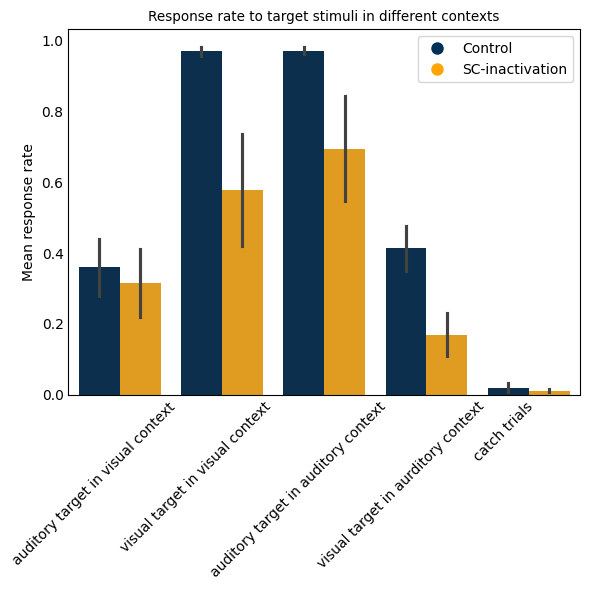

In [150]:
import seaborn as sns

muscimol_data_sc['session_id'] = muscimol_data_sc['session_id'].astype(str)

avg_values = {
    'Condition': ['Control', 'Perturbation'],

    # 'both targets': [
    # muscimol_df[muscimol_df['control']]['both_targets'].mean(),
    # muscimol_df[muscimol_df['perturbation']]['both_targets'].mean()
    # ],
    # 'auditory target':[
    #     muscimol_df[muscimol_df['control']]['auditory_target'].mean(),
    #     muscimol_df[muscimol_df['perturbation']]['auditory_target'].mean()
    # ],
    # 'visual target':[
    #     muscimol_df[muscimol_df['control']]['visual_target'].mean(),
    #     muscimol_df[muscimol_df['perturbation']]['visual_target'].mean()
    # ],
     'auditory target in visual context':[
        muscimol_data_sc[muscimol_data_sc['control']]['auditory_target_in_visual_context'].values,
        muscimol_data_sc[muscimol_data_sc['perturbation']]['auditory_target_in_visual_context'].values
    ],
     'visual target in visual context':[
        muscimol_data_sc[muscimol_data_sc['control']]['visual_target_in_visual_context'].values,
        muscimol_data_sc[muscimol_data_sc['perturbation']]['visual_target_in_visual_context'].values
    ],
     'auditory target in auditory context':[
        muscimol_data_sc[muscimol_data_sc['control']]['auditory_target_in_auditory_context'].values,
        muscimol_data_sc[muscimol_data_sc['perturbation']]['auditory_target_in_auditory_context'].values
    ],
     'visual target in aurditory context':[
        muscimol_data_sc[muscimol_data_sc['control']]['visual_target_in_auditory_context'].values,
        muscimol_data_sc[muscimol_data_sc['perturbation']]['visual_target_in_auditory_context'].values
    ],

    'catch trials' :[
        muscimol_data_sc[muscimol_data_sc['control']]['catch_trials'].values,
        muscimol_data_sc[muscimol_data_sc['perturbation']]['catch_trials'].values
    ]

}

# Create a DataFrame from the dictionary
avg_values_df = pd.DataFrame(avg_values)

avg_values_melted = avg_values_df.melt(id_vars='Condition', var_name='Category', value_name='Mean Value')

# Plotting the bar plot
plt.figure(figsize=(6, 6))
ax = sns.barplot(x='Category', y='Mean Value', hue='Condition', errorbar='se',
                 data=avg_values_melted.explode('Mean Value'), palette=['#003057', '#FFA500'])

plt.xlabel('')
plt.xticks(rotation = 45)
current_ticks = ax.get_xticks()
new_ticks = [tick - 0.25 for tick in current_ticks] # Adjust the value as needed
ax.set_xticks(new_ticks)

ax.tick_params(axis='both', which='both', length=0)


plt.ylabel('Mean response rate', fontsize = 10)
plt.title('Response rate to target stimuli in different contexts', fontsize = 9.75)
# plt.legend(loc='upper right')
# plt.legend(['Control', 'ORB-lesion'])
# plt.show()
plt.tight_layout()

handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='#003057', markersize=10),
        plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='#FFA500', markersize=10)]
labels = ['Control', 'SC-inactivation']
plt.legend(handles, labels, loc='upper right')
            # bbox_to_anchor=(1, 1))

plt.tight_layout()

# plt.savefig(r"C:\Users\vayle.lafehr\Desktop\perturbation_analysis_figures\mean_response_rate_both_targets&contexts.png", dpi=300)

plt.show()

C:\Users\vayle.lafehr\AppData\Local\Temp\ipykernel_35164\1351475523.py:28: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', len(unique_groups))


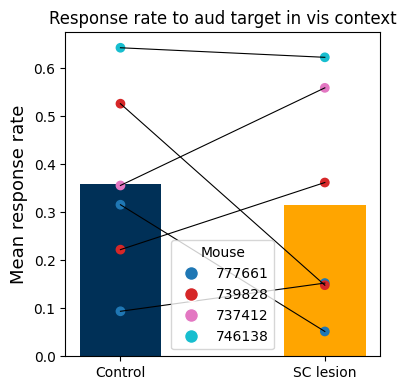

In [151]:
from datetime import datetime, timedelta


muscimol_data_sc['session_id'] = muscimol_data_sc['session_id'].astype(str)

avg_control = muscimol_data_sc[muscimol_data_sc['control']]['auditory_target_in_visual_context'].mean()
avg_perturbation = muscimol_data_sc[muscimol_data_sc['perturbation']]['auditory_target_in_visual_context'].mean()


# Create a bar plot comparing perturbation vs control bars with averages
plt.figure(figsize=(4, 4))
bar_width = 0.4

bars = ['Control', 'SC lesion']
y_pos = range(len(bars))
averages = [avg_control, avg_perturbation]

plt.bar(y_pos, averages, color=['#003057', '#FFA500'], width=bar_width)

# plt.xlabel('Perturbation Condition')
plt.ylabel('Mean response rate', fontsize = 13)
plt.title('Response rate to aud target in vis context', fontsize = 11.9)
plt.xticks(y_pos, bars)

muscimol_data_sc['color_group'] = muscimol_data_sc['session_id'].apply(lambda x: x.split('_')[0].split('(')[1].strip("'"))

unique_groups = muscimol_data_sc['color_group'].unique()
colors = plt.cm.get_cmap('tab10', len(unique_groups))
color_map = {group: colors(i) for i, group in enumerate(unique_groups)}

control_points = muscimol_data_sc[muscimol_data_sc['control']]['auditory_target_in_visual_context']
perturbation_points = muscimol_data_sc[muscimol_data_sc['perturbation']]['auditory_target_in_visual_context']

control_colors = muscimol_data_sc[muscimol_data_sc['control']]['color_group'].map(color_map)
perturbation_colors = muscimol_data_sc[muscimol_data_sc['perturbation']]['color_group'].map(color_map)

plt.scatter([0]*len(control_points), control_points, color=control_colors, zorder=2)
plt.scatter([1]*len(perturbation_points), perturbation_points, color=perturbation_colors, zorder=2)


muscimol_data_sc['date'] = muscimol_data_sc['session_id'].apply(lambda x: datetime.strptime(x.split('_')[1].split("'")[0], '%Y-%m-%d'))
            
for i in range(1, len(muscimol_data_sc), 2):
    x_coords = [0 if muscimol_data_sc.loc[i-1, 'control'] else 1, 0 if muscimol_data_sc.loc[i, 'control'] else 1]
    y_coords = [muscimol_data_sc.loc[i-1, 'auditory_target_in_visual_context'], muscimol_data_sc.loc[i, 'auditory_target_in_visual_context']]
    plt.plot(x_coords, y_coords, color='black', linestyle='-', linewidth=0.8)


# for i in range(len(muscimol_df)):
#     session_id_label = muscimol_df.loc[i, 'session_id'].replace("DynamicRoutingSession", "")
#     if muscimol_df.loc[i, 'control']:
#         plt.text(0, muscimol_df.loc[i, 'visual_target_in_visual_context'] + 0.009 * i, session_id_label, fontsize=6, rotation=5, va='bottom')
#     else:
#         plt.text(1, muscimol_df.loc[i, 'visual_target_in_visual_context']+ 0.006 * i - 0.003 * len(muscimol_df), session_id_label, fontsize=6, rotation=0, ha='left')


handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=color_map[group], markersize=10) for group in unique_groups]
labels = unique_groups
plt.legend(handles, labels, title="Mouse")


# Show the plot
plt.tight_layout()

plt.savefig(r"C:\Users\vayle.lafehr\Desktop\perturbation_analysis_figures\sc_response_rate_aud_target_vis_context.png", dpi=300)
plt.savefig(r"Z:\vayle\muscimol_SC_behavior_plots\response_rate_aud_target_vis_context.png", dpi=300)
plt.show()

C:\Users\vayle.lafehr\AppData\Local\Temp\ipykernel_11940\2206238506.py:28: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', len(unique_groups))


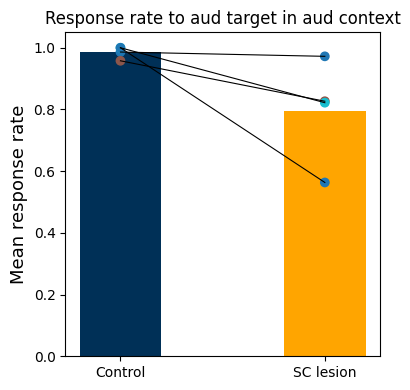

In [31]:
from datetime import datetime, timedelta


muscimol_data_sc['session_id'] = muscimol_data_sc['session_id'].astype(str)

avg_control = muscimol_data_sc[muscimol_data_sc['control']]['auditory_target_in_auditory_context'].mean()
avg_perturbation = muscimol_data_sc[muscimol_data_sc['perturbation']]['auditory_target_in_auditory_context'].mean()


# Create a bar plot comparing perturbation vs control bars with averages
plt.figure(figsize=(4, 4))
bar_width = 0.4

bars = ['Control', 'SC lesion']
y_pos = range(len(bars))
averages = [avg_control, avg_perturbation]

plt.bar(y_pos, averages, color=['#003057', '#FFA500'], width=bar_width)

# plt.xlabel('Perturbation Condition')
plt.ylabel('Mean response rate', fontsize = 13)
plt.title('Response rate to aud target in aud context', fontsize = 11.9)
plt.xticks(y_pos, bars)

muscimol_data_sc['color_group'] = muscimol_data_sc['session_id'].apply(lambda x: x.split('_')[0].split('(')[1].strip("'"))

unique_groups = muscimol_data_sc['color_group'].unique()
colors = plt.cm.get_cmap('tab10', len(unique_groups))
color_map = {group: colors(i) for i, group in enumerate(unique_groups)}

control_points = muscimol_data_sc[muscimol_data_sc['control']]['auditory_target_in_auditory_context']
perturbation_points = muscimol_data_sc[muscimol_data_sc['perturbation']]['auditory_target_in_auditory_context']

control_colors = muscimol_data_sc[muscimol_data_sc['control']]['color_group'].map(color_map)
perturbation_colors = muscimol_data_sc[muscimol_data_sc['perturbation']]['color_group'].map(color_map)

plt.scatter([0]*len(control_points), control_points, color=control_colors, zorder=2)
plt.scatter([1]*len(perturbation_points), perturbation_points, color=perturbation_colors, zorder=2)


muscimol_data_sc['date'] = muscimol_data_sc['session_id'].apply(lambda x: datetime.strptime(x.split('_')[1].split("'")[0], '%Y-%m-%d'))
            
for i in range(1, len(muscimol_data_sc), 2):
    x_coords = [0 if muscimol_data_sc.loc[i-1, 'control'] else 1, 0 if muscimol_data_sc.loc[i, 'control'] else 1]
    y_coords = [muscimol_data_sc.loc[i-1, 'auditory_target_in_auditory_context'], muscimol_data_sc.loc[i, 'auditory_target_in_auditory_context']]
    plt.plot(x_coords, y_coords, color='black', linestyle='-', linewidth=0.8)


# for i in range(len(muscimol_df)):
#     session_id_label = muscimol_df.loc[i, 'session_id'].replace("DynamicRoutingSession", "")
#     if muscimol_df.loc[i, 'control']:
#         plt.text(0, muscimol_df.loc[i, 'visual_target_in_visual_context'] + 0.009 * i, session_id_label, fontsize=6, rotation=5, va='bottom')
#     else:
#         plt.text(1, muscimol_df.loc[i, 'visual_target_in_visual_context']+ 0.006 * i - 0.003 * len(muscimol_df), session_id_label, fontsize=6, rotation=0, ha='left')


# handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=color_map[group], markersize=10) for group in unique_groups]
# labels = unique_groups
# plt.legend(handles, labels, title="Mouse")


# Show the plot
plt.tight_layout()

plt.savefig(r"C:\Users\vayle.lafehr\Desktop\perturbation_analysis_figures\sc_response_rate_aud_target_aud_context.png", dpi=300)
plt.savefig(r"Z:\vayle\muscimol_SC_behavior_plots\response_rate_aud_target_aud_context.png", dpi=300)
plt.show()

C:\Users\vayle.lafehr\AppData\Local\Temp\ipykernel_11940\4040384808.py:28: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', len(unique_groups))


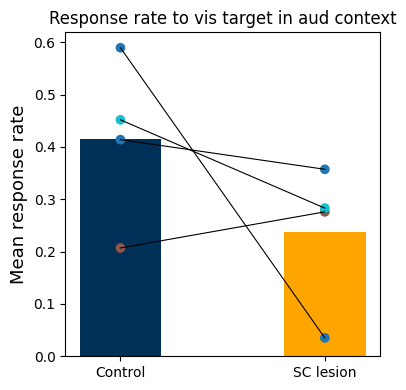

In [32]:
from datetime import datetime, timedelta


muscimol_data_sc['session_id'] = muscimol_data_sc['session_id'].astype(str)

avg_control = muscimol_data_sc[muscimol_data_sc['control']]['visual_target_in_auditory_context'].mean()
avg_perturbation = muscimol_data_sc[muscimol_data_sc['perturbation']]['visual_target_in_auditory_context'].mean()


# Create a bar plot comparing perturbation vs control bars with averages
plt.figure(figsize=(4, 4))
bar_width = 0.4

bars = ['Control', 'SC lesion']
y_pos = range(len(bars))
averages = [avg_control, avg_perturbation]

plt.bar(y_pos, averages, color=['#003057', '#FFA500'], width=bar_width)

# plt.xlabel('Perturbation Condition')
plt.ylabel('Mean response rate', fontsize = 13)
plt.title('Response rate to vis target in aud context', fontsize = 11.9)
plt.xticks(y_pos, bars)

muscimol_data_sc['color_group'] = muscimol_data_sc['session_id'].apply(lambda x: x.split('_')[0].split('(')[1].strip("'"))

unique_groups = muscimol_data_sc['color_group'].unique()
colors = plt.cm.get_cmap('tab10', len(unique_groups))
color_map = {group: colors(i) for i, group in enumerate(unique_groups)}

control_points = muscimol_data_sc[muscimol_data_sc['control']]['visual_target_in_auditory_context']
perturbation_points = muscimol_data_sc[muscimol_data_sc['perturbation']]['visual_target_in_auditory_context']

control_colors = muscimol_data_sc[muscimol_data_sc['control']]['color_group'].map(color_map)
perturbation_colors = muscimol_data_sc[muscimol_data_sc['perturbation']]['color_group'].map(color_map)

plt.scatter([0]*len(control_points), control_points, color=control_colors, zorder=2)
plt.scatter([1]*len(perturbation_points), perturbation_points, color=perturbation_colors, zorder=2)


muscimol_data_sc['date'] = muscimol_data_sc['session_id'].apply(lambda x: datetime.strptime(x.split('_')[1].split("'")[0], '%Y-%m-%d'))
            
for i in range(1, len(muscimol_data_sc), 2):
    x_coords = [0 if muscimol_data_sc.loc[i-1, 'control'] else 1, 0 if muscimol_data_sc.loc[i, 'control'] else 1]
    y_coords = [muscimol_data_sc.loc[i-1, 'visual_target_in_auditory_context'], muscimol_data_sc.loc[i, 'visual_target_in_auditory_context']]
    plt.plot(x_coords, y_coords, color='black', linestyle='-', linewidth=0.8)


# for i in range(len(muscimol_df)):
#     session_id_label = muscimol_df.loc[i, 'session_id'].replace("DynamicRoutingSession", "")
#     if muscimol_df.loc[i, 'control']:
#         plt.text(0, muscimol_df.loc[i, 'visual_target_in_visual_context'] + 0.009 * i, session_id_label, fontsize=6, rotation=5, va='bottom')
#     else:
#         plt.text(1, muscimol_df.loc[i, 'visual_target_in_visual_context']+ 0.006 * i - 0.003 * len(muscimol_df), session_id_label, fontsize=6, rotation=0, ha='left')


# handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=color_map[group], markersize=10) for group in unique_groups]
# labels = unique_groups
# plt.legend(handles, labels, title="Mouse")


# Show the plot
plt.tight_layout()

plt.savefig(r"C:\Users\vayle.lafehr\Desktop\perturbation_analysis_figures\sc_response_rate_vis_target_aud_context.png", dpi=300)
plt.savefig(r"Z:\vayle\muscimol_SC_behavior_plots\response_rate_vis_target_aud_context.png", dpi=300)
plt.show()

C:\Users\vayle.lafehr\AppData\Local\Temp\ipykernel_11940\3009084618.py:28: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', len(unique_groups))


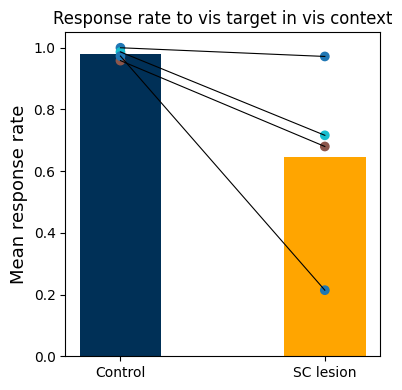

In [33]:
from datetime import datetime, timedelta


muscimol_data_sc['session_id'] = muscimol_data_sc['session_id'].astype(str)

avg_control = muscimol_data_sc[muscimol_data_sc['control']]['visual_target_in_visual_context'].mean()
avg_perturbation = muscimol_data_sc[muscimol_data_sc['perturbation']]['visual_target_in_visual_context'].mean()


# Create a bar plot comparing perturbation vs control bars with averages
plt.figure(figsize=(4, 4))
bar_width = 0.4

bars = ['Control', 'SC lesion']
y_pos = range(len(bars))
averages = [avg_control, avg_perturbation]

plt.bar(y_pos, averages, color=['#003057', '#FFA500'], width=bar_width)

# plt.xlabel('Perturbation Condition')
plt.ylabel('Mean response rate', fontsize = 13)
plt.title('Response rate to vis target in vis context', fontsize = 11.9)
plt.xticks(y_pos, bars)

muscimol_data_sc['color_group'] = muscimol_data_sc['session_id'].apply(lambda x: x.split('_')[0].split('(')[1].strip("'"))

unique_groups = muscimol_data_sc['color_group'].unique()
colors = plt.cm.get_cmap('tab10', len(unique_groups))
color_map = {group: colors(i) for i, group in enumerate(unique_groups)}

control_points = muscimol_data_sc[muscimol_data_sc['control']]['visual_target_in_visual_context']
perturbation_points = muscimol_data_sc[muscimol_data_sc['perturbation']]['visual_target_in_visual_context']

control_colors = muscimol_data_sc[muscimol_data_sc['control']]['color_group'].map(color_map)
perturbation_colors = muscimol_data_sc[muscimol_data_sc['perturbation']]['color_group'].map(color_map)

plt.scatter([0]*len(control_points), control_points, color=control_colors, zorder=2)
plt.scatter([1]*len(perturbation_points), perturbation_points, color=perturbation_colors, zorder=2)


muscimol_data_sc['date'] = muscimol_data_sc['session_id'].apply(lambda x: datetime.strptime(x.split('_')[1].split("'")[0], '%Y-%m-%d'))
            
for i in range(1, len(muscimol_data_sc), 2):
    x_coords = [0 if muscimol_data_sc.loc[i-1, 'control'] else 1, 0 if muscimol_data_sc.loc[i, 'control'] else 1]
    y_coords = [muscimol_data_sc.loc[i-1, 'visual_target_in_visual_context'], muscimol_data_sc.loc[i, 'visual_target_in_visual_context']]
    plt.plot(x_coords, y_coords, color='black', linestyle='-', linewidth=0.8)


# for i in range(len(muscimol_df)):
#     session_id_label = muscimol_df.loc[i, 'session_id'].replace("DynamicRoutingSession", "")
#     if muscimol_df.loc[i, 'control']:
#         plt.text(0, muscimol_df.loc[i, 'visual_target_in_visual_context'] + 0.009 * i, session_id_label, fontsize=6, rotation=5, va='bottom')
#     else:
#         plt.text(1, muscimol_df.loc[i, 'visual_target_in_visual_context']+ 0.006 * i - 0.003 * len(muscimol_df), session_id_label, fontsize=6, rotation=0, ha='left')


# handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=color_map[group], markersize=10) for group in unique_groups]
# labels = unique_groups
# plt.legend(handles, labels, title="Mouse")


# Show the plot
plt.tight_layout()

plt.savefig(r"C:\Users\vayle.lafehr\Desktop\perturbation_analysis_figures\sc_response_rate_vis_target_vis_context.png", dpi=300)
plt.savefig(r"Z:\vayle\muscimol_SC_behavior_plots\response_rate_vis_target_vis_context.png", dpi=300)
plt.show()

## SC unity line scatter plot

C:\Users\vayle.lafehr\AppData\Local\Temp\ipykernel_35164\3817176907.py:19: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', len(unique_groups))


(0.9583333333333334, 0.9864864864864865, '746138')
(0.7162162162162162, 0.68, '737412')
(0.971830985915493, 1.0, '739828')
(0.21428571428571427, 0.972972972972973, '739828')
(0.0, 0.9166666666666666, '777661')
(0.8933333333333333, 0.9866666666666667, '777661')
(0.3559322033898305, 0.6428571428571429, '746138')
(0.6229508196721312, 0.559322033898305, '737412')
(0.3620689655172414, 0.2222222222222222, '739828')
(0.14814814814814814, 0.5263157894736842, '739828')
(0.05172413793103448, 0.3157894736842105, '777661')
(0.15254237288135594, 0.09375, '777661')
(0.20689655172413793, 0.45161290322580644, '746138')
(0.2830188679245283, 0.27586206896551724, '737412')
(0.35714285714285715, 0.41379310344827586, '739828')
(0.03508771929824561, 0.5892857142857143, '739828')
(0.017241379310344827, 0.559322033898305, '777661')
(0.05, 0.25862068965517243, '777661')
(0.9577464788732394, 1.0, '746138')
(0.821917808219178, 0.8266666666666667, '737412')
(0.9722222222222222, 0.9861111111111112, '739828')
(0.56

<Figure size 2000x2000 with 0 Axes>

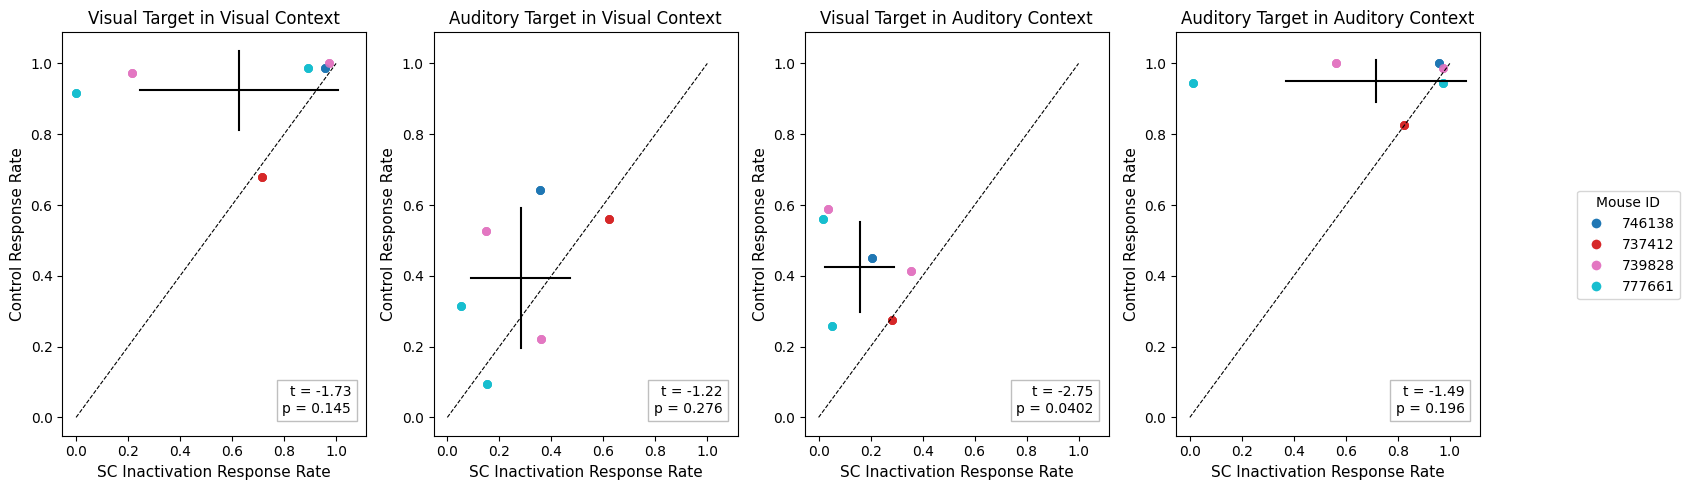

In [181]:
import matplotlib.pyplot as plt
from datetime import datetime
from scipy import stats


#clean
muscimol_data_sc['color_group'] = muscimol_data_sc['session_id'].apply(
    lambda x: x.split('_')[0].split('(')[1].strip("'")
)

# Sort by date
muscimol_data_sc['date'] = muscimol_data_sc['session_id'].apply(
    lambda x: datetime.strptime(x.split('_')[1].split("'")[0], '%Y-%m-%d')
)
muscimol_data_sc = muscimol_data_sc.sort_values(by='date').reset_index(drop=True)

# unique colors bymouse ID
unique_groups = muscimol_data_sc['color_group'].unique()
colors = plt.cm.get_cmap('tab10', len(unique_groups))
color_map = {group: colors(i) for i, group in enumerate(unique_groups)}

# Pair control and perturbation sessions
paired_data_vis_vis = []
for i in range(1, len(muscimol_data_sc), 2):
    row1 = muscimol_data_sc.loc[i - 1]
    row2 = muscimol_data_sc.loc[i]
    if row1['control']:
        control_val = row1['visual_target_in_visual_context']
        perturb_val = row2['visual_target_in_visual_context']
        color_group = row1['color_group']
    else:
        control_val = row2['visual_target_in_visual_context']
        perturb_val = row1['visual_target_in_visual_context']
        color_group = row2['color_group']
    paired_data_vis_vis.append((perturb_val, control_val, color_group))

    paired_data_aud_vis = []
for i in range(1, len(muscimol_data_sc), 2):
    row1 = muscimol_data_sc.loc[i - 1]
    row2 = muscimol_data_sc.loc[i]
    if row1['control']:
        control_val_1 = row1['auditory_target_in_visual_context']
        perturb_val_1 = row2['auditory_target_in_visual_context']
        color_group = row1['color_group']
    else:
        control_val_1 = row2['auditory_target_in_visual_context']
        perturb_val_1 = row1['auditory_target_in_visual_context']
        color_group = row2['color_group']
    paired_data_aud_vis.append((perturb_val_1, control_val_1, color_group))

    paired_data_vis_aud = []
for i in range(1, len(muscimol_data_sc), 2):
    row1 = muscimol_data_sc.loc[i - 1]
    row2 = muscimol_data_sc.loc[i]
    if row1['control']:
        control_val_2 = row1['visual_target_in_auditory_context']
        perturb_val_2 = row2['visual_target_in_auditory_context']
        color_group = row1['color_group']
    else:
        control_val_2 = row2['visual_target_in_auditory_context']
        perturb_val_2 = row1['visual_target_in_auditory_context']
        color_group = row2['color_group']
    paired_data_vis_aud.append((perturb_val_2, control_val_2, color_group))

    paired_data_aud_aud = []
for i in range(1, len(muscimol_data_sc), 2):
    row1 = muscimol_data_sc.loc[i - 1]
    row2 = muscimol_data_sc.loc[i]
    if row1['control']:
        control_val_3 = row1['auditory_target_in_auditory_context']
        perturb_val_3 = row2['auditory_target_in_auditory_context']
        color_group = row1['color_group']
    else:
        control_val_3 = row2['auditory_target_in_auditory_context']
        perturb_val_3 = row1['auditory_target_in_auditory_context']
        color_group = row2['color_group']
    paired_data_aud_aud.append((perturb_val_3, control_val_3, color_group))

# Create scatter plot with x = perturbation, y = control
plt.figure(figsize=(20, 20))

# data = [paired_data_vis_vis, paired_data_aud_vis]
# for datum in data:
#     for x, y, group in datum:
#         print((x,y,group))
#         plt.scatter(x, y, color=color_map[group], label=group, alpha=0.8, linewidth = 0.2)
#         plt.scatter(x, y, color=color_map[group], label=group, alpha=0.8)

fig, axes = plt.subplots(1, 4, figsize=(15, 5), sharex=True, sharey=True)

contexts = ['Visual Target in Visual Context', 'Auditory Target in Visual Context', 'Visual Target in Auditory Context', 'Auditory Target in Auditory Context']
data = [paired_data_vis_vis, paired_data_aud_vis, paired_data_vis_aud, paired_data_aud_aud]

#make test star for plot


    
#organize paired data

paired_data_sets ={
    'vis_vis': paired_data_vis_vis,
    'aud_vis': paired_data_aud_vis,
    'vis_aud': paired_data_vis_aud,
    'aud_aud': paired_data_aud_aud,
}
    

#mean cross


for ax, (label, paired_data) in zip(axes, paired_data_sets.items()):
    x_vals = [x for x, _, _ in paired_data]
    y_vals = [y for _, y, _ in paired_data]
    # print(f"{label} - x_vals: {x_vals}, y_vals: {y_vals}")
    
    x_mean, y_mean = np.mean(x_vals), np.mean(y_vals)
    x_std, y_std = np.std(x_vals), np.std(y_vals)
    ax.plot([x_mean - x_std, x_mean +x_std], [y_mean, y_mean], color='black', lw=1.5)
    ax.plot([x_mean, x_mean], [y_mean - y_std, y_mean + y_std], color='black', lw=1.5)


    for ax, datum, title in zip(axes, data, contexts):
        for x, y, group in datum:
            print((x, y, group))
            ax.scatter(x, y, color=color_map[group], alpha=0.8, linewidth=0.2)
            # ...cell 152, inside the for loop that draws each scatter point...

            



# for ax in axes:
    # ax.errorbar(np.mean(x_vals), np.mean(y_vals), xerr=x_std, yerr=y_std, fmt='o', color='black', markersize=5, label='Mean ± Std Dev', alpha=0.5)
# unity line

for ax in axes:
    ax.plot([0, 1], [0, 1], 'k--', linewidth=0.8)  # Unity line for each subplot
# plt.plot([0, 1], [0, 1], 'k--')


# ax.set_xlim(0, 1)
# ax.set_ylim(0, 1)
#adds space to plot size
# x_vals = [x for x, _, _ in paired_data]
# y_vals = [y for _, y, _ in paired_data]

# x_min, x_max = min(x_vals), max(x_vals)
# y_min, y_max = min(y_vals), max(y_vals)

# padding_x = (x_max - x_min) * 0.05  # 5% padding
# padding_y = (y_max - y_min) * 0.05

# ax.set_xlim(x_min - padding_x, x_max + padding_x)
# ax.set_ylim(y_min - padding_y, y_max + padding_y)


for ax, x_label in zip(axes, 'SC Inactivation Response Rate'):
    ax.set_xlabel('SC Inactivation Response Rate', fontsize =11)


for ax, y_label in zip(axes, 'Control Response Rate'):
    ax.set_ylabel('Control Response Rate', fontsize=11)
# ax.set_title(f'{c for c in contexts}', fontsize=12)

for ax, title in zip(axes, contexts):
    ax.set_title(f'{title}', fontsize=12)

for ax in axes:
    ax.yaxis.set_tick_params(labelleft=True)
# ax.grid(True)
for ax, (label, paired_data) in zip(axes, paired_data_sets.items()):
    x_vals = [x for x, _, _ in paired_data]  # Perturbation
    y_vals = [y for _, y, _ in paired_data]  # Control

    # Run paired t-test
    t_stat, p_val = stats.ttest_rel(x_vals, y_vals)

    # Plot scatter and mean cross as before...
    # [your existing plotting code here]

    # Annotate with t-test result
    ax.text(0.95, 0.05, f't = {t_stat:.2f}\np = {p_val:.3g}',
            transform=ax.transAxes, fontsize=10,
            verticalalignment='bottom', horizontalalignment='right', bbox=dict(facecolor='white', alpha=0.5, edgecolor='gray'))

# Create legend with unique mouse IDs
# handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=color_map[group], markersize=8) for group in unique_groups]
# plt.legend(handles, unique_groups, title="Mouse ID", bbox_to_anchor=(1.05, 1), loc='upper left')

handles = [plt.Line2D([0], [0], marker='o', color='w',
                      markerfacecolor=color_map[group], markersize=8)
           for group in unique_groups]
fig.legend(handles, unique_groups, title="Mouse ID",
           bbox_to_anchor=(1.05, 0.5), loc='center left')


plt.tight_layout()


# plt.savefig(r"Z:\vayle\muscimol_SC_behavior_plots\SC_population_effects_unity_line_scatter_plot", dpi=300)

plt.show()

C:\Users\vayle.lafehr\AppData\Local\Temp\ipykernel_42616\690169527.py:35: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', len(unique_groups))


(0.05172413793103448, 0.23214285714285715, '746138')
(0.03571428571428571, 0.1206896551724138, '737412')
(0.03636363636363636, 0.12280701754385964, '739828')
(0.06896551724137931, 0.14035087719298245, '739828')
(0.0, 0.03571428571428571, '777661')
(0.04838709677419355, 0.016129032258064516, '777661')
(0.0, 0.0, '746138')
(0.017543859649122806, 0.05172413793103448, '737412')
(0.03636363636363636, 0.07142857142857142, '739828')
(0.08771929824561403, 0.0, '739828')
(0.0, 0.0, '777661')
(0.0, 0.01639344262295082, '777661')
(0.3559322033898305, 0.3770491803278688, '746138')
(0.2222222222222222, 0.21666666666666667, '737412')
(0.10909090909090909, 0.017543859649122806, '739828')
(0.14814814814814814, 0.15789473684210525, '739828')
(0.07272727272727272, 0.10714285714285714, '777661')
(0.08064516129032258, 0.08620689655172414, '777661')
(0.017241379310344827, 0.0, '746138')
(0.01694915254237288, 0.01694915254237288, '737412')
(0.034482758620689655, 0.0, '739828')
(0.017241379310344827, 0.03508

<Figure size 2000x2000 with 0 Axes>

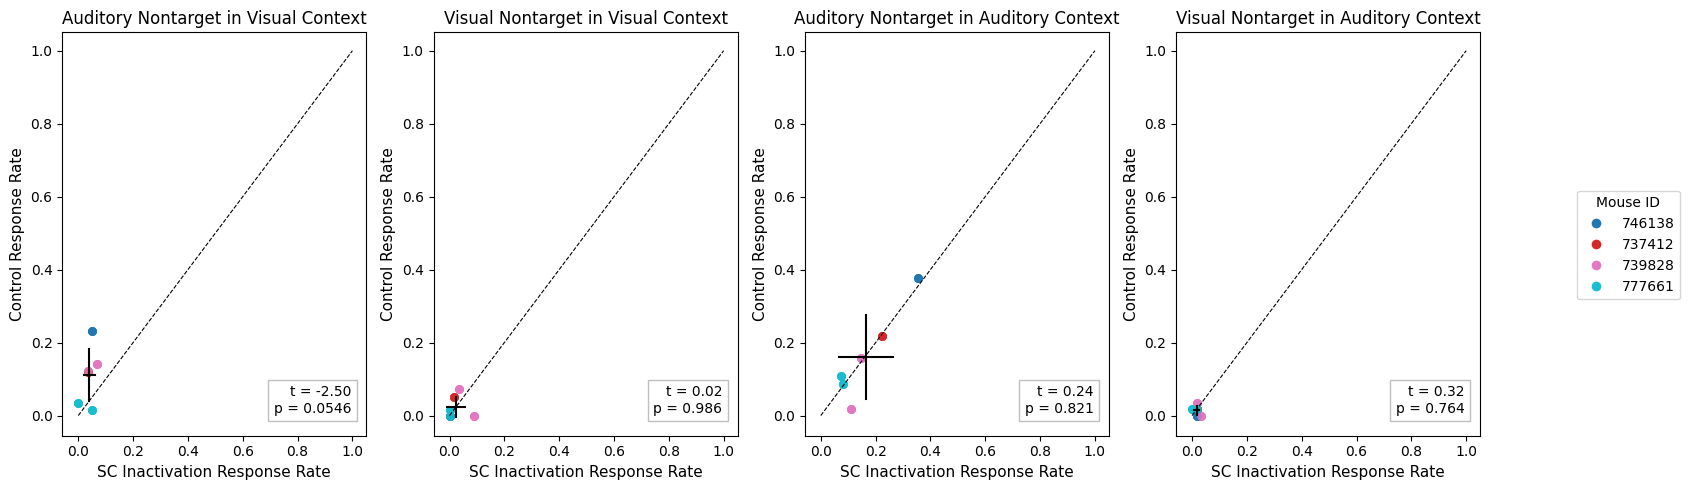

In [32]:
import matplotlib.pyplot as plt
from datetime import datetime
from scipy import stats

result = dict(
    session_id=str(session.session_id) if hasattr(session, 'session_id') else str(session),
    # ...other fields...
)

#clean
import re

def extract_mouse_id(x):
    # Always convert to string
    s = str(x)
    # Try to extract the mouse ID using regex
    match = re.search(r"\('(\d+)_", s)
    if match:
        return match.group(1)
    # fallback: try splitting
    if '_' in s:
        return s.split('_')[0].split('(')[-1].strip("'")
    return s

muscimol_data_sc['color_group'] = muscimol_data_sc['session_id'].apply(extract_mouse_id)

# # Sort by date
muscimol_data_sc['date'] = muscimol_data_sc['session_id'].apply(
    lambda x: datetime.strptime(str(x).split('_')[1].split("'")[0], '%Y-%m-%d')
)
muscimol_data_sc = muscimol_data_sc.sort_values(by='date').reset_index(drop=True)

# unique colors bymouse ID
unique_groups = muscimol_data_sc['color_group'].unique()
colors = plt.cm.get_cmap('tab10', len(unique_groups))
color_map = {group: colors(i) for i, group in enumerate(unique_groups)}

# Pair control and perturbation sessions
paired_data_vis_vis = []
for i in range(1, len(muscimol_data_sc), 2):
    row1 = muscimol_data_sc.loc[i - 1]
    row2 = muscimol_data_sc.loc[i]
    if row1['control']:
        control_val = row1['vis_nontarget_vis_context_responses']
        perturb_val = row2['vis_nontarget_vis_context_responses']
        color_group = row1['color_group']
    else:
        control_val = row2['vis_nontarget_vis_context_responses']
        perturb_val = row1['vis_nontarget_vis_context_responses']
        color_group = row2['color_group']
    paired_data_vis_vis.append((perturb_val, control_val, color_group))

    paired_data_aud_vis = []
for i in range(1, len(muscimol_data_sc), 2):
    row1 = muscimol_data_sc.loc[i - 1]
    row2 = muscimol_data_sc.loc[i]
    if row1['control']:
        control_val_1 = row1['aud_nontarget_vis_context_responses']
        perturb_val_1 = row2['aud_nontarget_vis_context_responses']
        color_group = row1['color_group']
    else:
        control_val_1 = row2['aud_nontarget_vis_context_responses']
        perturb_val_1 = row1['aud_nontarget_vis_context_responses']
        color_group = row2['color_group']
    paired_data_aud_vis.append((perturb_val_1, control_val_1, color_group))

    paired_data_vis_aud = []
for i in range(1, len(muscimol_data_sc), 2):
    row1 = muscimol_data_sc.loc[i - 1]
    row2 = muscimol_data_sc.loc[i]
    if row1['control']:
        control_val_2 = row1['vis_nontarget_aud_context_responses']
        perturb_val_2 = row2['vis_nontarget_aud_context_responses']
        color_group = row1['color_group']
    else:
        control_val_2 = row2['vis_nontarget_aud_context_responses']
        perturb_val_2 = row1['vis_nontarget_aud_context_responses']
        color_group = row2['color_group']
    paired_data_vis_aud.append((perturb_val_2, control_val_2, color_group))

    paired_data_aud_aud = []
for i in range(1, len(muscimol_data_sc), 2):
    row1 = muscimol_data_sc.loc[i - 1]
    row2 = muscimol_data_sc.loc[i]
    if row1['control']:
        control_val_3 = row1['aud_nontarget_aud_context_responses']
        perturb_val_3 = row2['aud_nontarget_aud_context_responses']
        color_group = row1['color_group']
    else:
        control_val_3 = row2['aud_nontarget_aud_context_responses']
        perturb_val_3 = row1['aud_nontarget_aud_context_responses']
        color_group = row2['color_group']
    paired_data_aud_aud.append((perturb_val_3, control_val_3, color_group))

# Create scatter plot with x = perturbation, y = control
plt.figure(figsize=(20, 20))

# data = [paired_data_vis_vis, paired_data_aud_vis]
# for datum in data:
#     for x, y, group in datum:
#         print((x,y,group))
#         plt.scatter(x, y, color=color_map[group], label=group, alpha=0.8, linewidth = 0.2)
#         plt.scatter(x, y, color=color_map[group], label=group, alpha=0.8)

fig, axes = plt.subplots(1, 4, figsize=(15, 5), sharex=True, sharey=True)

contexts = ['Auditory Nontarget in Visual Context','Visual Nontarget in Visual Context', 'Auditory Nontarget in Auditory Context', 'Visual Nontarget in Auditory Context']
data = [paired_data_aud_vis, paired_data_vis_vis, paired_data_aud_aud, paired_data_vis_aud]

#make test star for plot


    
#organize paired data

paired_data_sets ={
    'aud_vis': paired_data_aud_vis,
    'vis_vis': paired_data_vis_vis,
    'aud_aud': paired_data_aud_aud,
    'vis_aud': paired_data_vis_aud,
}
    

#mean cross


for ax, (label, paired_data) in zip(axes, paired_data_sets.items()):
    x_vals = [x for x, _, _ in paired_data]
    y_vals = [y for _, y, _ in paired_data]
    # print(f"{label} - x_vals: {x_vals}, y_vals: {y_vals}")
    
    x_mean, y_mean = np.mean(x_vals), np.mean(y_vals)
    x_std, y_std = np.std(x_vals), np.std(y_vals)
    ax.plot([x_mean - x_std, x_mean +x_std], [y_mean, y_mean], color='black', lw=1.5)
    ax.plot([x_mean, x_mean], [y_mean - y_std, y_mean + y_std], color='black', lw=1.5)


    for ax, datum, title in zip(axes, data, contexts):
        for x, y, group in datum:
            print((x, y, group))
            ax.scatter(x, y, color=color_map[group], alpha=0.8, linewidth=0.2)





# for ax in axes:
    # ax.errorbar(np.mean(x_vals), np.mean(y_vals), xerr=x_std, yerr=y_std, fmt='o', color='black', markersize=5, label='Mean ± Std Dev', alpha=0.5)
# unity line

for ax in axes:
    ax.plot([0, 1], [0, 1], 'k--', linewidth=0.8)  # Unity line for each subplot
# plt.plot([0, 1], [0, 1], 'k--')


# ax.set_xlim(0, 1)
# ax.set_ylim(0, 1)
#adds space to plot size
# x_vals = [x for x, _, _ in paired_data]
# y_vals = [y for _, y, _ in paired_data]

# x_min, x_max = min(x_vals), max(x_vals)
# y_min, y_max = min(y_vals), max(y_vals)

# padding_x = (x_max - x_min) * 0.05  # 5% padding
# padding_y = (y_max - y_min) * 0.05

# ax.set_xlim(x_min - padding_x, x_max + padding_x)
# ax.set_ylim(y_min - padding_y, y_max + padding_y)


for ax, x_label in zip(axes, 'SC Inactivation Response Rate'):
    ax.set_xlabel('SC Inactivation Response Rate', fontsize =11)


for ax, y_label in zip(axes, 'Control Response Rate'):
    ax.set_ylabel('Control Response Rate', fontsize=11)
# ax.set_title(f'{c for c in contexts}', fontsize=12)

for ax, title in zip(axes, contexts):
    ax.set_title(f'{title}', fontsize=12)

for ax in axes:
    ax.yaxis.set_tick_params(labelleft=True)
# ax.grid(True)
for ax, (label, paired_data) in zip(axes, paired_data_sets.items()):
    x_vals = [x for x, _, _ in paired_data]  # Perturbation
    y_vals = [y for _, y, _ in paired_data]  # Control

    # Run paired t-test
    t_stat, p_val = stats.ttest_rel(x_vals, y_vals)

    # Plot scatter and mean cross as before...
    # [your existing plotting code here]

    # Annotate with t-test result
    ax.text(0.95, 0.05, f't = {t_stat:.2f}\np = {p_val:.3g}',
            transform=ax.transAxes, fontsize=10,
            verticalalignment='bottom', horizontalalignment='right', bbox=dict(facecolor='white', alpha=0.5, edgecolor='gray'))

# Create legend with unique mouse IDs
# handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=color_map[group], markersize=8) for group in unique_groups]
# plt.legend(handles, unique_groups, title="Mouse ID", bbox_to_anchor=(1.05, 1), loc='upper left')

handles = [plt.Line2D([0], [0], marker='o', color='w',
                      markerfacecolor=color_map[group], markersize=8)
           for group in unique_groups]
fig.legend(handles, unique_groups, title="Mouse ID",
           bbox_to_anchor=(1.05, 0.5), loc='center left')

plt.tight_layout()


# plt.savefig(r"Z:\vayle\muscimol_ORB_behavior_plots\ORB_nontarget_population_effects_unity_line_scatter_plot", dpi=300)
plt.show()
# plt.grid(True)
# plt.tight_layout()
# plt.show()

In [ ]:
#controls comparison

In [ ]:
#separate by modality first

In [49]:
#start by making a dataframe with your columns and data of interest. you can make a function that takes session_id and loops thru to return the trials information you want averaged and contactenated
muscimol_data_orb = []

#(mouse, perturbation or control)
session_ids = ['774470_2025-07-29','774470_2025-07-30','782106_2025-07-07','782106_2025-07-14','782106_2025-07-08', '782106_2025-07-15','767405_2025-05-19','767405_2025-05-20', '767405_2025-05-28', '767405_2025-05-29','739828_2025-02-10','739828_2025-02-11','739828_2025-02-17', '739828_2025-02-18','774916_2025-03-24', '774916_2025-03-25', '774916_2025-03-31', '774916_2025-04-01', '772657_2025-02-24', '772657_2025-02-25', '772657_2025-03-03', '772657_2025-03-04']
control = ['774470_2025-07-29','782106_2025-07-07','782106_2025-07-14','767405_2025-05-28','767405_2025-05-19','739828_2025-02-10','739828_2025-02-17','772657_2025-02-24', '772657_2025-03-03', '774916_2025-03-24', '774916_2025-03-31',]
perturbation = ['774470_2025-07-30','782106_2025-07-08', '782106_2025-07-15','767405_2025-05-29','767405_2025-05-20','739828_2025-02-11','739828_2025-02-18', '772657_2025-02-25', '772657_2025-03-04','774916_2025-03-25', '774916_2025-04-01']


ori_first = ['782106_2025-07-07', '782106_2025-07-08', '767405_2025-05-19','767405_2025-05-20', '739828_2025-02-10','739828_2025-02-11', '774916_2025-03-31', '774916_2025-04-01',  '772657_2025-03-03', '772657_2025-03-04']
amn_first = ['774470_2025-07-29','774470_2025-07-30', '782106_2025-07-14', '782106_2025-07-15', '767405_2025-05-28', '767405_2025-05-29','739828_2025-02-17', '739828_2025-02-18', '774916_2025-03-24', '774916_2025-03-25', '772657_2025-02-24', '772657_2025-02-25']
quiescent_violations = [47, 42, 44, 79, 87, 209, 40, 66, 36, 88, 37, 74, 32, 82, 7, 21, 62, 47, 22, 34, 20, 56]


for i, session_id in enumerate(session_ids):
    session = npc_sessions.Session(session_id)
   
    
#vis nontarget in vis context
    vis_nontarget_vis_context = session.trials[:].query(
    "rewarded_modality == 'vis' & is_response == True & is_vis_nontarget == True")
    all_vis_nontargets_vis_context = session.trials[:].query(
    "rewarded_modality == 'vis' & is_vis_nontarget == True")
    vis_nontarget_vis_context_responses = (len(vis_nontarget_vis_context)) / (len(all_vis_nontargets_vis_context))

#aud nontarget in vis context
    aud_nontarget_vis_context = session.trials[:].query(
    "rewarded_modality == 'vis' & is_aud_nontarget == True & is_response == True")
    all_aud_nontargets_vis_context = session.trials[:].query(
    "rewarded_modality == 'vis' & is_aud_nontarget == True")
    aud_nontarget_vis_context_responses = (len(aud_nontarget_vis_context)) / (len(all_aud_nontargets_vis_context))

# vis nontarget in aud context
    vis_nontarget_aud_context = session.trials[:].query(
    "rewarded_modality == 'aud' & is_response == True & is_vis_nontarget == True")
    all_vis_nontargets_aud_context = session.trials[:].query(
    "rewarded_modality == 'aud' & is_vis_nontarget == True")
    vis_nontarget_aud_context_responses = (len(vis_nontarget_aud_context)) / (len(all_vis_nontargets_aud_context))

#aud nontarget in aud context
    aud_nontarget_aud_context = session.trials[:].query(
    "rewarded_modality == 'aud' & is_aud_nontarget == True & is_response == True")
    all_aud_nontargets_aud_context = session.trials[:].query(
    "rewarded_modality == 'aud' & is_aud_nontarget == True")
    aud_nontarget_aud_context_responses = (len(aud_nontarget_aud_context)) / (len(all_aud_nontargets_aud_context))

#aud target in aud context
    aud_target_responses_in_aud_context = session.trials[:].query(
    "is_response == True & is_aud_target == True & rewarded_modality == 'aud'")
    all_aud_targets_aud_context = session.trials[:].query(
    "is_aud_target == True & rewarded_modality == 'aud'")
    auditory_target_in_auditory_context = (len(aud_target_responses_in_aud_context)/(len(all_aud_targets_aud_context)))

#vis target in vis context
    vis_rewarded_responses_in_vis_context = session.trials[:].query(
    "is_response == True & is_vis_target == True & rewarded_modality == 'vis'")
    all_vis_rewarded_responses_in_vis_context = session.trials[:].query(
    "is_vis_target == True & rewarded_modality == 'vis'")
    visual_target_in_visual_context = (len(vis_rewarded_responses_in_vis_context)/(len(all_vis_rewarded_responses_in_vis_context)))

#aud target in vis context
    aud_rewarded_responses_in_vis_context = session.trials[:].query(
    "is_response == True & is_aud_target == True & rewarded_modality == 'vis'")
    all_rewarded_responses_in_vis_context = session.trials[:].query(
    "is_aud_target == True & rewarded_modality == 'vis'")
    auditory_target_in_visual_context = (len(aud_rewarded_responses_in_vis_context)/(len(all_rewarded_responses_in_vis_context)))

#vis target in aud context
    vis_rewarded_responses_in_aud_context = session.trials[:].query(
    "is_response == True & is_vis_target == True & rewarded_modality == 'aud'")
    all_rewarded_responses_in_aud_context = session.trials[:].query(
    "is_vis_target == True & rewarded_modality == 'aud'")
    visual_target_in_auditory_context = (len(vis_rewarded_responses_in_aud_context)/(len(all_rewarded_responses_in_aud_context)))

#catch trials
    catch_responses = session.trials[:].query(
    'is_response == True & is_catch == True')
    all_catch = session.trials[:].query(
    'is_catch == True')
    catch_trials = (len(catch_responses)/(len(all_catch)))

    result = dict(
                    session_id=session,
                    control = session_id in control,
                    perturbation = session_id in perturbation,
                    ori_first = session_id in ori_first,
                    amn_first = session_id in amn_first,
                    vis_nontarget_vis_context_responses=vis_nontarget_vis_context_responses,
                    aud_nontarget_vis_context_responses=aud_nontarget_vis_context_responses,
                    vis_nontarget_aud_context_responses=vis_nontarget_aud_context_responses,
                    aud_nontarget_aud_context_responses=aud_nontarget_aud_context_responses,
                    auditory_target_in_visual_context=auditory_target_in_visual_context,
                    visual_target_in_auditory_context=visual_target_in_auditory_context,
                    visual_target_in_visual_context=visual_target_in_visual_context,
                    auditory_target_in_auditory_context=auditory_target_in_auditory_context,
                    catch_trials=catch_trials,
                    quiescent_violations=quiescent_violations[i]
                    )

    muscimol_data_orb.append(result)

# print(muscimol_data)
muscimol_df_orb = pd.DataFrame(muscimol_data_orb)
print(muscimol_df_orb)

                                    session_id  control  perturbation  \
0   DynamicRoutingSession('774470_2025-07-29')     True         False   
1   DynamicRoutingSession('774470_2025-07-30')    False          True   
2   DynamicRoutingSession('782106_2025-07-07')     True         False   
3   DynamicRoutingSession('782106_2025-07-14')     True         False   
4   DynamicRoutingSession('782106_2025-07-08')    False          True   
5   DynamicRoutingSession('782106_2025-07-15')    False          True   
6   DynamicRoutingSession('767405_2025-05-19')     True         False   
7   DynamicRoutingSession('767405_2025-05-20')    False          True   
8   DynamicRoutingSession('767405_2025-05-28')     True         False   
9   DynamicRoutingSession('767405_2025-05-29')    False          True   
10  DynamicRoutingSession('739828_2025-02-10')     True         False   
11  DynamicRoutingSession('739828_2025-02-11')    False          True   
12  DynamicRoutingSession('739828_2025-02-17')     

## ORB ORI first

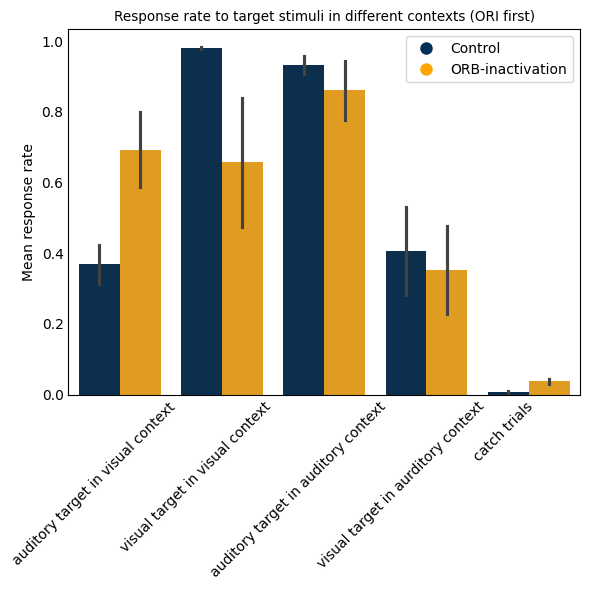

In [50]:
import seaborn as sns

muscimol_df_orb['session_id'] = muscimol_df_orb['session_id'].astype(str)


ori_df = muscimol_df_orb[muscimol_df_orb['ori_first'] == True]


ori_values = {
    'Condition': ['Control', 'Perturbation'],

     'auditory target in visual context':[
        ori_df[ori_df['control']]['auditory_target_in_visual_context'].values,
        ori_df[ori_df['perturbation']]['auditory_target_in_visual_context'].values
    ],
     'visual target in visual context':[
        ori_df[ori_df['control']]['visual_target_in_visual_context'].values,
        ori_df[ori_df['perturbation']]['visual_target_in_visual_context'].values
    ],
     'auditory target in auditory context':[
        ori_df[ori_df['control']]['auditory_target_in_auditory_context'].values,
        ori_df[ori_df['perturbation']]['auditory_target_in_auditory_context'].values
    ],
     'visual target in aurditory context':[
        ori_df[ori_df['control']]['visual_target_in_auditory_context'].values,
        ori_df[ori_df['perturbation']]['visual_target_in_auditory_context'].values
    ],

    'catch trials' :[
        ori_df[ori_df['control']]['catch_trials'].values,
        ori_df[ori_df['perturbation']]['catch_trials'].values
    ]

    # 'quiescent_violations' :[
    #     muscimol_df_orb[muscimol_df_orb['control']]['quiescent_violations'].values,
    #     muscimol_df_orb[muscimol_df_orb['perturbation']]['quiescent_violations'].values,
    # ]
}

# Create a DataFrame from the dictionary
ori_values_df = pd.DataFrame(ori_values)

ori_values_melted = ori_values_df.melt(id_vars='Condition', var_name='Category', value_name='Mean Value')

# Plotting the bar plot
plt.figure(figsize=(6, 6))
ax = sns.barplot(x='Category', y='Mean Value', hue='Condition', errorbar='se',
                 data=ori_values_melted.explode('Mean Value'), palette=['#003057', '#FFA500'])

plt.xlabel('')
plt.xticks(rotation = 45)
current_ticks = ax.get_xticks()
new_ticks = [tick - 0.25 for tick in current_ticks] # Adjust the value as needed
ax.set_xticks(new_ticks)

ax.tick_params(axis='both', which='both', length=0)


plt.ylabel('Mean response rate', fontsize = 10)
plt.title('Response rate to target stimuli in different contexts (ORI first)', fontsize = 9.75)
# plt.legend(loc='upper right')
# plt.legend(['Control', 'ORB-lesion'])
# plt.show()
plt.tight_layout()

handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='#003057', markersize=10),
        plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='#FFA500', markersize=10)]
labels = ['Control', 'ORB-inactivation']
plt.legend(handles, labels, loc='upper right')
            # bbox_to_anchor=(1, 1))

plt.tight_layout()

# plt.savefig(r"Z:\vayle\muscimol_ORB_behavior_plots\mean_target_response_rate_ori_first.png", dpi=300)

plt.show()


In [51]:
ori_values

{'Condition': ['Control', 'Perturbation'],
 'auditory target in visual context': [array([0.37931034, 0.17241379, 0.39285714, 0.51851852, 0.37704918]),
  array([0.74137931, 0.38181818, 0.94736842, 0.51724138, 0.87719298])],
 'visual target in visual context': [array([0.98591549, 0.97222222, 0.98611111, 0.98550725, 0.97333333]),
  array([0.49315068, 1.        , 0.87837838, 0.01388889, 0.89705882])],
 'auditory target in auditory context': [array([0.95890411, 0.92857143, 0.98630137, 0.83783784, 0.94666667]),
  array([0.98591549, 0.95833333, 1.        , 0.56164384, 0.7972973 ])],
 'visual target in aurditory context': [array([0.10714286, 0.14545455, 0.74074074, 0.62068966, 0.41666667]),
  array([0.19298246, 0.31578947, 0.55555556, 0.        , 0.69811321])],
 'catch trials': [array([0.        , 0.01470588, 0.01785714, 0.        , 0.        ]),
  array([0.03125   , 0.03773585, 0.06      , 0.04444444, 0.01851852])]}

## ORB AMN first

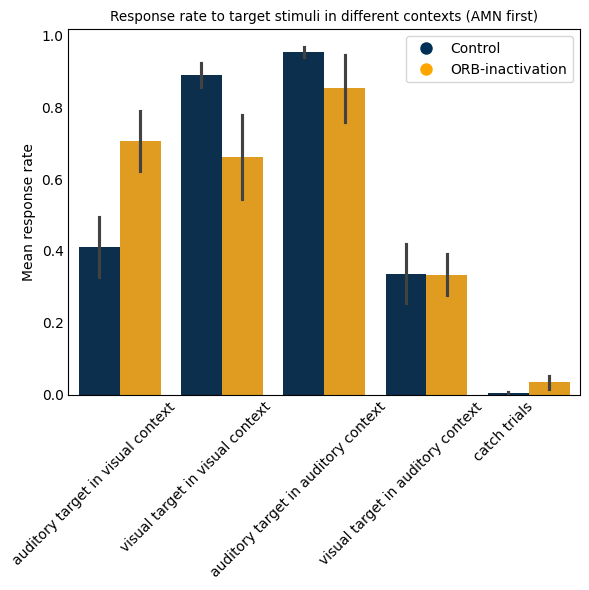

In [52]:
import seaborn as sns

muscimol_df_orb['session_id'] = muscimol_df_orb['session_id'].astype(str)


amn_df = muscimol_df_orb[muscimol_df_orb['amn_first'] == True]


amn_values = {
    'Condition': ['Control', 'Perturbation'],

     'auditory target in visual context':[
        amn_df[amn_df['control']]['auditory_target_in_visual_context'].values,
        amn_df[amn_df['perturbation']]['auditory_target_in_visual_context'].values
    ],
     'visual target in visual context':[
        amn_df[amn_df['control']]['visual_target_in_visual_context'].values,
        amn_df[amn_df['perturbation']]['visual_target_in_visual_context'].values
    ],
     'auditory target in auditory context':[
        amn_df[amn_df['control']]['auditory_target_in_auditory_context'].values,
        amn_df[amn_df['perturbation']]['auditory_target_in_auditory_context'].values
    ],
     'visual target in auditory context':[
        amn_df[amn_df['control']]['visual_target_in_auditory_context'].values,
        amn_df[amn_df['perturbation']]['visual_target_in_auditory_context'].values
    ],

    'catch trials' :[
        amn_df[amn_df['control']]['catch_trials'].values,
        amn_df[amn_df['perturbation']]['catch_trials'].values
    ]

    # 'quiescent_violations' :[
    #     muscimol_df_orb[muscimol_df_orb['control']]['quiescent_violations'].values,
    #     muscimol_df_orb[muscimol_df_orb['perturbation']]['quiescent_violations'].values,
    # ]
}

# Create a DataFrame from the dictionary
amn_values_df = pd.DataFrame(amn_values)

amn_values_melted = amn_values_df.melt(id_vars='Condition', var_name='Category', value_name='Mean Value')

# Plotting the bar plot
plt.figure(figsize=(6, 6))
ax = sns.barplot(x='Category', y='Mean Value', hue='Condition', errorbar='se',
                 data=amn_values_melted.explode('Mean Value'), palette=['#003057', '#FFA500'])

plt.xlabel('')
plt.xticks(rotation = 45)
current_ticks = ax.get_xticks()
new_ticks = [tick - 0.25 for tick in current_ticks] # Adjust the value as needed
ax.set_xticks(new_ticks)

ax.tick_params(axis='both', which='both', length=0)


plt.ylabel('Mean response rate', fontsize = 10)
plt.title('Response rate to target stimuli in different contexts (AMN first)', fontsize = 9.75)
# plt.legend(loc='upper right')
# plt.legend(['Control', 'ORB-lesion'])
# plt.show()
plt.tight_layout()

handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='#003057', markersize=10),
        plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='#FFA500', markersize=10)]
labels = ['Control', 'ORB-inactivation']
plt.legend(handles, labels, loc='upper right')
            # bbox_to_anchor=(1, 1))

plt.tight_layout()

# plt.savefig(r"Z:\vayle\muscimol_ORB_behavior_plots\mean_target_response_rate_amn_first.png", dpi=300)

plt.show()

## ORB AMN vs ORI first unity line scatter plot

In [54]:
amn_df['color_group'] = amn_df['session_id'].apply(
    lambda x: x.split('_')[0].split('(')[1].strip("'")
)

# Sort by date
amn_df['date'] = amn_df['session_id'].apply(
    lambda x: datetime.strptime(x.split('_')[1].split("'")[0], '%Y-%m-%d')
)
amn_df = amn_df.sort_values(by='date').reset_index(drop=True)

ori_df['color_group'] = amn_df['session_id'].apply(
    lambda x: x.split('_')[0].split('(')[1].strip("'")
)

# Sort by date
ori_df['date'] = ori_df['session_id'].apply(
    lambda x: datetime.strptime(x.split('_')[1].split("'")[0], '%Y-%m-%d')
)
ori_df = ori_df.sort_values(by='date').reset_index(drop=True)

# unique colors bymouse ID
unique_groups = ori_df['color_group'].unique()
colors = plt.cm.get_cmap('tab10', len(unique_groups))
color_map = {group: colors(i) for i, group in enumerate(unique_groups)}

unique_groups = amn_df['color_group'].unique()
colors = plt.cm.get_cmap('tab10', len(unique_groups))
color_map = {group: colors(i) for i, group in enumerate(unique_groups)}

# Pair control and perturbation sessions
amn_paired_data_vis_vis = []
for i in range(1, len(amn_df), 2):
    row1 = amn_df.loc[i - 1]
    row2 = amn_df.loc[i]
    if row1['control']:
        control_val = row1['visual_target_in_visual_context']
        perturb_val = row2['visual_target_in_visual_context']
        color_group = row1['color_group']
    else:
        control_val = row2['visual_target_in_visual_context']
        perturb_val = row1['visual_target_in_visual_context']
        color_group = row2['color_group']
    amn_paired_data_vis_vis.append((perturb_val, control_val, color_group))

    amn_paired_data_aud_vis = []
for i in range(1, len(amn_df), 2):
    row1 = amn_df.loc[i - 1]
    row2 = amn_df.loc[i]
    if row1['control']:
        control_val_1 = row1['auditory_target_in_visual_context']
        perturb_val_1 = row2['auditory_target_in_visual_context']
        color_group = row1['color_group']
    else:
        control_val_1 = row2['auditory_target_in_visual_context']
        perturb_val_1 = row1['auditory_target_in_visual_context']
        color_group = row2['color_group']
    amn_paired_data_aud_vis.append((perturb_val_1, control_val_1, color_group))

    amn_paired_data_vis_aud = []
for i in range(1, len(amn_df), 2):
    row1 = amn_df.loc[i - 1]
    row2 = amn_df.loc[i]
    if row1['control']:
        control_val_2 = row1['visual_target_in_auditory_context']
        perturb_val_2 = row2['visual_target_in_auditory_context']
        color_group = row1['color_group']
    else:
        control_val_2 = row2['visual_target_in_auditory_context']
        perturb_val_2 = row1['visual_target_in_auditory_context']
        color_group = row2['color_group']
    amn_paired_data_vis_aud.append((perturb_val_2, control_val_2, color_group))

    amn_paired_data_aud_aud = []
for i in range(1, len(amn_df), 2):
    row1 = amn_df.loc[i - 1]
    row2 = amn_df.loc[i]
    if row1['control']:
        control_val_3 = row1['auditory_target_in_auditory_context']
        perturb_val_3 = row2['auditory_target_in_auditory_context']
        color_group = row1['color_group']
    else:
        control_val_3 = row2['auditory_target_in_auditory_context']
        perturb_val_3 = row1['auditory_target_in_auditory_context']
        color_group = row2['color_group']
    amn_paired_data_aud_aud.append((perturb_val_3, control_val_3, color_group))

    #ori pairs

    ori_paired_data_vis_vis = []
for i in range(1, len(ori_df), 2):
    row1 = ori_df.loc[i - 1]
    row2 = ori_df.loc[i]
    if row1['control']:
        control_val = row1['visual_target_in_visual_context']
        perturb_val = row2['visual_target_in_visual_context']
        color_group = row1['color_group']
    else:
        control_val = row2['visual_target_in_visual_context']
        perturb_val = row1['visual_target_in_visual_context']
        color_group = row2['color_group']
    ori_paired_data_vis_vis.append((perturb_val, control_val, color_group))

    ori_paired_data_aud_vis = []
for i in range(1, len(ori_df), 2):
    row1 = ori_df.loc[i - 1]
    row2 = ori_df.loc[i]
    if row1['control']:
        control_val_1 = row1['auditory_target_in_visual_context']
        perturb_val_1 = row2['auditory_target_in_visual_context']
        color_group = row1['color_group']
    else:
        control_val_1 = row2['auditory_target_in_visual_context']
        perturb_val_1 = row1['auditory_target_in_visual_context']
        color_group = row2['color_group']
    ori_paired_data_aud_vis.append((perturb_val_1, control_val_1, color_group))

    ori_paired_data_vis_aud = []
for i in range(1, len(ori_df), 2):
    row1 = ori_df.loc[i - 1]
    row2 = ori_df.loc[i]
    if row1['control']:
        control_val_2 = row1['visual_target_in_auditory_context']
        perturb_val_2 = row2['visual_target_in_auditory_context']
        color_group = row1['color_group']
    else:
        control_val_2 = row2['visual_target_in_auditory_context']
        perturb_val_2 = row1['visual_target_in_auditory_context']
        color_group = row2['color_group']
    ori_paired_data_vis_aud.append((perturb_val_2, control_val_2, color_group))

    ori_paired_data_aud_aud = []
for i in range(1, len(ori_df), 2):
    row1 = ori_df.loc[i - 1]
    row2 = ori_df.loc[i]
    if row1['control']:
        control_val_3 = row1['auditory_target_in_auditory_context']
        perturb_val_3 = row2['auditory_target_in_auditory_context']
        color_group = row1['color_group']
    else:
        control_val_3 = row2['auditory_target_in_auditory_context']
        perturb_val_3 = row1['auditory_target_in_auditory_context']
        color_group = row2['color_group']
    ori_paired_data_aud_aud.append((perturb_val_3, control_val_3, color_group))

# Create scatter plot with x = perturbation, y = control
# plt.figure(figsize=(20, 20))

# data = [paired_data_vis_vis, paired_data_aud_vis]
# for datum in data:
#     for x, y, group in datum:
#         print((x,y,group))
#         plt.scatter(x, y, color=color_map[group], label=group, alpha=0.8, linewidth = 0.2)
#         plt.scatter(x, y, color=color_map[group], label=group, alpha=0.8)

# fig, axes = plt.subplots(1, 4, figsize=(15, 5), sharex=True, sharey=True)

contexts = ['Visual Target in Visual Context', 'Auditory Target in Visual Context', 'Visual Target in Auditory Context', 'Auditory Target in Auditory Context']
data = [amn_paired_data_vis_vis, amn_paired_data_aud_vis, amn_paired_data_vis_aud, amn_paired_data_aud_aud, ori_paired_data_vis_vis, ori_paired_data_aud_vis, ori_paired_data_vis_aud, ori_paired_data_aud_aud ]

#make test star for plot


    
#organize paired data

paired_data_sets ={
    'amn_vis_vis': amn_paired_data_vis_vis,
    'amn_aud_vis': amn_paired_data_aud_vis,
    'amn_vis_aud': amn_paired_data_vis_aud,
    'amn_aud_aud': amn_paired_data_aud_aud,
    'ori_vis_vis': ori_paired_data_vis_vis,
    'ori_aud_vis': ori_paired_data_aud_vis,
    'ori_vis_aud': ori_paired_data_vis_aud,
    'ori_aud_aud': ori_paired_data_aud_aud
}
# print(paired_data_sets)


#tak the difference between control and perturbation values for each coondition (paired data set)
# Calculate differences between perturbation and control for each paired data set
diffs = []
labels = []
groups = []

for label, paired_data in paired_data_sets.items():
    for x, y, group in paired_data:
        diffs.append(y - x) #perturb - control
        labels.append(label)
        groups.append(group)

# Create DataFrame
diffs_df = pd.DataFrame({
    'Difference': diffs,
    'Condition': labels,
    'Mouse': groups
})


# print(diffs_df)

# Add a PairedDiff column to diffs_df

# Define the pairings you want
pairings = [
    ('amn_vis_vis', 'ori_vis_vis'),
    ('amn_aud_vis', 'ori_aud_vis'),
    ('amn_vis_aud', 'ori_vis_aud'),
    ('amn_aud_aud', 'ori_aud_aud'),
]

# Create a mapping from (Condition, Mouse) to Difference
diff_map = {(row['Condition'], row['Mouse']): row['Difference'] for _, row in diffs_df.iterrows()}

# Function to get paired diffs for each row
def get_paired_diff(row):
    for amn, ori in pairings:
        if row['Condition'] == amn:
            # Find the matching ori value for the same mouse
            paired_val = diff_map.get((ori, row['Mouse']), None)
            return (row['Difference'], paired_val)
        elif row['Condition'] == ori:
            # Find the matching amn value for the same mouse
            paired_val = diff_map.get((amn, row['Mouse']), None)
            return (paired_val, row['Difference'])
    return (None, None)

diffs_df['PairedDiff'] = diffs_df.apply(get_paired_diff, axis=1)
# Drop rows from diffs_df where 'PairedDiff' contains a None value
diffs_df = diffs_df[diffs_df['PairedDiff'].apply(lambda x: None not in x)]
print(diffs_df)


    Difference    Condition   Mouse  \
0     0.194444  amn_vis_vis  739828   
1     0.220104  amn_vis_vis  772657   
2    -0.013333  amn_vis_vis  774916   
3     0.253521  amn_vis_vis  767405   
4     0.000000  amn_vis_vis  782106   
6    -0.385965  amn_aud_vis  739828   
7    -0.058445  amn_aud_vis  772657   
8    -0.083333  amn_aud_vis  774916   
9    -0.667925  amn_aud_vis  767405   
10   -0.338721  amn_aud_vis  782106   
12    0.373844  amn_vis_aud  739828   
13   -0.143191  amn_vis_aud  772657   
14    0.073933  amn_vis_aud  774916   
15   -0.082707  amn_vis_aud  767405   
16   -0.289514  amn_vis_aud  782106   
18   -0.014085  amn_aud_aud  739828   
19    0.329322  amn_aud_aud  772657   
20   -0.013889  amn_aud_aud  774916   
21   -0.083333  amn_aud_aud  767405   
22   -0.011905  amn_aud_aud  782106   
24    0.107733  ori_vis_vis  739828   
25    0.076275  ori_vis_vis  772657   
26    0.971618  ori_vis_vis  774916   
27   -0.027778  ori_vis_vis  767405   
28    0.492765  ori_vis_v

C:\Users\vayle.lafehr\AppData\Local\Temp\ipykernel_19772\1446894158.py:23: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', len(unique_groups))
C:\Users\vayle.lafehr\AppData\Local\Temp\ipykernel_19772\1446894158.py:27: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', len(unique_groups))


C:\Users\vayle.lafehr\AppData\Local\Temp\ipykernel_19772\162263348.py:85: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', len(unique_mice))
C:\Users\vayle.lafehr\AppData\Local\Temp\ipykernel_19772\162263348.py:85: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', len(unique_mice))
C:\Users\vayle.lafehr\AppData\Local\Temp\ipykernel_19772\162263348.py:85: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  co

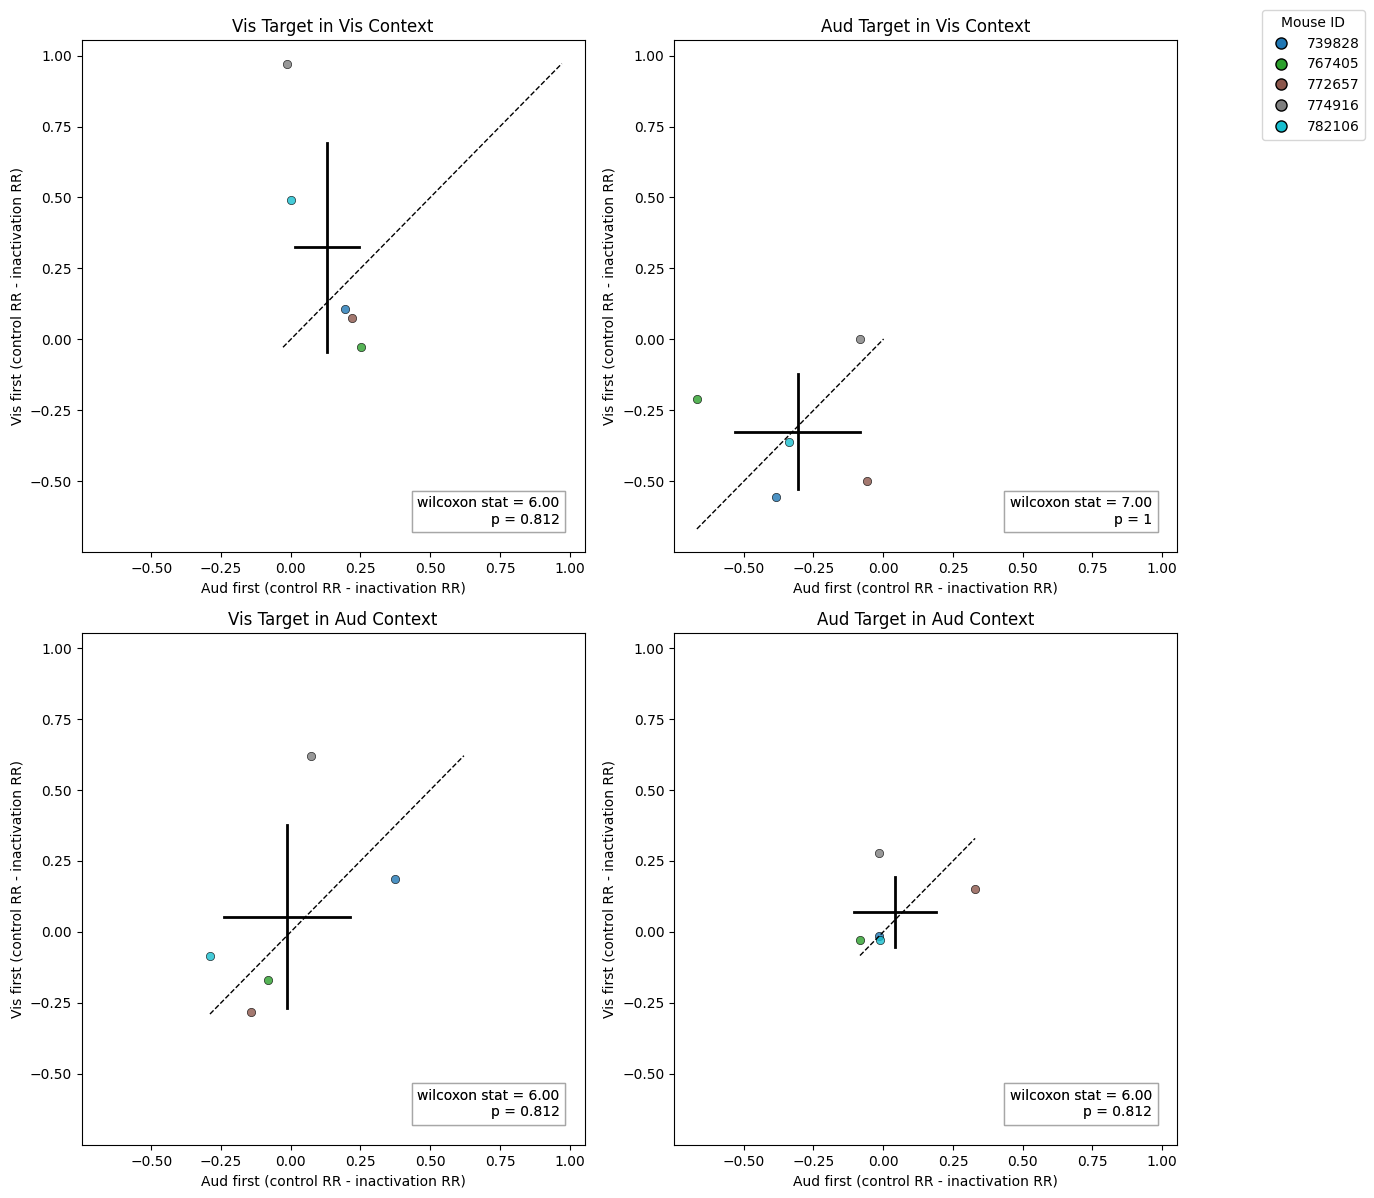

In [59]:


# amn_df and ori_df 
# Each row has: session_id, control/perturbation, color_group (mouse), and response rates

def get_pairwise_diffs(df, pairing, value_col):
    """
    For each mouse, get the difference (control - perturbation) for the given pairing and value_col.
    Returns a dict: {mouse: diff}
    """
    diffs = {}
    # Group by mouse
    for mouse, group in df.groupby('color_group'):
        # Find control and perturbation rows for this pairing
        ctrl = group[group['control']][value_col]
        pert = group[group['perturbation']][value_col]
        if len(pert) == 1 and len(ctrl) == 1:
            diffs[mouse] = ctrl.values[0] - pert.values[0]
    return diffs

# Define the pairings and value columns
pairings = [
    ('visual_target_in_visual_context', 'Vis Target in Vis Context'),
    ('auditory_target_in_visual_context', 'Aud Target in Vis Context'),
    ('visual_target_in_auditory_context', 'Vis Target in Aud Context'),
    ('auditory_target_in_auditory_context', 'Aud Target in Aud Context'),
]

# fig, axes = plt.subplots(2, 2, figsize=(12, 12), sharex=True, sharey=True)
# axes = axes.flatten()

# for idx, (value_col, label) in enumerate(pairings):
#     # Get diffs for each mouse for this pairing
#     amn_diffs = get_pairwise_diffs(amn_df, value_col, value_col)
#     ori_diffs = get_pairwise_diffs(ori_df, value_col, value_col)
#     # Only keep mice present in both
#     shared_mice = set(amn_diffs.keys()) & set(ori_diffs.keys())
#     x_vals = [amn_diffs[m] for m in shared_mice]
#     y_vals = [ori_diffs[m] for m in shared_mice]
#     mouse_ids = list(shared_mice)
#     # Color by mouse
#     unique_mice = np.unique(mouse_ids)
#     colors = plt.cm.get_cmap('tab10', len(unique_mice))
#     color_map = {mouse: colors(i) for i, mouse in enumerate(unique_mice)}
#     ax = axes[idx]
#     for x, y, mouse in zip(x_vals, y_vals, mouse_ids):
#         ax.scatter(x, y, color=color_map[mouse], label=mouse, alpha=0.8, edgecolor='k', linewidth=0.5)
#     # Mean cross
#     if len(x_vals) > 0 and len(y_vals) > 0:
#         x_mean, y_mean = np.mean(x_vals), np.mean(y_vals)
#         x_std, y_std = np.std(x_vals), np.std(y_vals)
#         ax.plot([x_mean - x_std, x_mean + x_std], [y_mean, y_mean], color='black', lw=2)
#         ax.plot([x_mean, x_mean], [y_mean - y_std, y_mean + y_std], color='black', lw=2)
#     # Unity line
#     if len(x_vals) > 0 and len(y_vals) > 0:
#         min_val = min(x_vals + y_vals)
#         max_val = max(x_vals + y_vals)
#         ax.plot([min_val, max_val], [min_val, max_val], 'k--', linewidth=1)
#     ax.set_title(label)
#     ax.set_xlabel('AMN first (inactivation RR - control RR)')
#     ax.set_ylabel('ORI first (inactivation RR - control RR)')
  
# for ax in axes:
#     ax.yaxis.set_tick_params(labelleft=True) 
#     ax.xaxis.set_tick_params(labelleft=True)   

# if len(unique_mice) > 0:
#     handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=color_map[mouse], markersize=8, markeredgecolor='k') for mouse in unique_mice]
#     fig.legend(handles, unique_mice, title="Mouse ID", bbox_to_anchor=(1.05, 1), loc='upper left')


#  t-test and p-value 

from scipy import stats

fig, axes = plt.subplots(2, 2, figsize=(12, 12), sharex=True, sharey=True)
axes = axes.flatten()

for idx, (value_col, label) in enumerate(pairings):
    amn_diffs = get_pairwise_diffs(amn_df, value_col, value_col)
    ori_diffs = get_pairwise_diffs(ori_df, value_col, value_col)
    shared_mice = set(amn_diffs.keys()) & set(ori_diffs.keys())
    x_vals = [amn_diffs[m] for m in shared_mice]
    y_vals = [ori_diffs[m] for m in shared_mice]
    mouse_ids = list(shared_mice)
    unique_mice = np.unique(mouse_ids)
    colors = plt.cm.get_cmap('tab10', len(unique_mice))
    color_map = {mouse: colors(i) for i, mouse in enumerate(unique_mice)}
    ax = axes[idx]
    for x, y, mouse in zip(x_vals, y_vals, mouse_ids):
        ax.scatter(x, y, color=color_map[mouse], label=mouse, alpha=0.8, edgecolor='k', linewidth=0.5)
    # Mean cross
    if len(x_vals) > 0 and len(y_vals) > 0:
        x_mean, y_mean = np.mean(x_vals), np.mean(y_vals)
        x_std, y_std = np.std(x_vals), np.std(y_vals)
        ax.plot([x_mean - x_std, x_mean + x_std], [y_mean, y_mean], color='black', lw=2)
        ax.plot([x_mean, x_mean], [y_mean - y_std, y_mean + y_std], color='black', lw=2)
        # Unity line
        min_val = min(x_vals + y_vals)
        max_val = max(x_vals + y_vals)
        ax.plot([min_val, max_val], [min_val, max_val], 'k--', linewidth=1)
        # Paired t-test
    from scipy.stats import wilcoxon

    wilcoxon_stat, p_val = wilcoxon(x_vals, y_vals)
    ax.text(0.95, 0.05, f'wilcoxon stat = {wilcoxon_stat:.2f}\np = {p_val:.3g}',
                transform=ax.transAxes, fontsize=10,
                verticalalignment='bottom', horizontalalignment='right',
                bbox=dict(facecolor='white', alpha=0.5, edgecolor='gray'))

    # Plot scatter and mean cross as before...
    # [your existing plotting code here]

    # Annotate with t-test result
    ax.text(0.95, 0.05, f'wilcoxon stat = {wilcoxon_stat:.2f}\np = {p_val:.3g}',
                transform=ax.transAxes, fontsize=10,
                verticalalignment='bottom', horizontalalignment='right', bbox=dict(facecolor='white', alpha=0.5, edgecolor='gray'))

    ax.set_title(label)
    ax.set_xlabel('Aud first (control RR - inactivation RR)')
    ax.set_ylabel('Vis first (control RR - inactivation RR)')

for ax in axes:
    ax.yaxis.set_tick_params(labelleft=True)
    ax.xaxis.set_tick_params(labelleft=True)

if len(unique_mice) > 0:
    handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=color_map[mouse], markersize=8, markeredgecolor='k') for mouse in unique_mice]
    fig.legend(handles, unique_mice, title="Mouse ID", bbox_to_anchor=(1.05, 1), loc='upper left')


plt.tight_layout()

plt.savefig(r"Z:\vayle\muscimol_ORB_behavior_plots\ORB_starting_context_population_effects_unity_line_scatter_plot", dpi=300)

plt.show()


In [14]:
print(amn_values)

{'Condition': ['Control', 'Perturbation'], 'auditory target in visual context': [array([0.23214286, 0.37037037, 0.2       , 0.52631579, 0.75      ,
       0.38983051]), array([0.46666667, 0.70909091, 0.86792453, 0.9122807 , 0.83333333,
       0.44827586])], 'visual target in visual context': [array([0.86111111, 0.77142857, 0.83098592, 0.98611111, 0.96      ,
       0.93243243]), array([0.14084507, 0.77142857, 0.57746479, 0.79166667, 0.97333333,
       0.71232877])], 'auditory target in auditory context': [array([0.90540541, 0.97222222, 0.91666667, 0.98591549, 0.98611111,
       0.95945946]), array([0.5       , 0.98412698, 1.        , 1.        , 1.        ,
       0.63013699])], 'visual target in aurditory context': [array([0.17241379, 0.17857143, 0.28571429, 0.71929825, 0.36206897,
       0.30508475]), array([0.08333333, 0.46808511, 0.36842105, 0.34545455, 0.28813559,
       0.44827586])], 'catch trials': [array([0.        , 0.02040816, 0.        , 0.        , 0.        ,
       0.   

In [ ]:
#response probabilites with d's

In [56]:
#code for labeling w session_IDs

for idx, (value_col, label) in enumerate(pairings):
    amn_diffs = get_pairwise_diffs(amn_df, value_col, value_col)
    ori_diffs = get_pairwise_diffs(ori_df, value_col, value_col)
    shared_mice = set(amn_diffs.keys()) & set(ori_diffs.keys())
    x_vals = [amn_diffs[m] for m in shared_mice]
    y_vals = [ori_diffs[m] for m in shared_mice]
    mouse_ids = list(shared_mice)
    unique_mice = np.unique(mouse_ids)
    colors = plt.cm.get_cmap('tab10', len(unique_mice))
    color_map = {mouse: colors(i) for i, mouse in enumerate(unique_mice)}
    ax = axes[idx]
    for x, y, mouse in zip(x_vals, y_vals, mouse_ids):
        # Find session_ids for this mouse in both amn and ori dfs
        amn_row = amn_df[(amn_df['color_group'] == mouse) & (amn_df['control'])][['session_id']]
        ori_row = ori_df[(ori_df['color_group'] == mouse) & (ori_df['control'])][['session_id']]
        amn_sid = amn_row['session_id'].values[0] if not amn_row.empty else ''
        ori_sid = ori_row['session_id'].values[0] if not ori_row.empty else ''
        ax.scatter(x, y, color=color_map[mouse], label=mouse, alpha=0.8, edgecolor='k', linewidth=0.5)
        # Label with both session IDs
        ax.text(x, y, f"{amn_sid}\n{ori_sid}", fontsize=6, ha='left', va='bottom', alpha=0.7)

C:\Users\vayle.lafehr\AppData\Local\Temp\ipykernel_19772\746626135.py:11: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', len(unique_mice))
C:\Users\vayle.lafehr\AppData\Local\Temp\ipykernel_19772\746626135.py:11: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', len(unique_mice))
C:\Users\vayle.lafehr\AppData\Local\Temp\ipykernel_19772\746626135.py:11: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  co

## Controls

In [304]:
session_id = '762125_2025-05-19'
session = npc_sessions.Session(session_id)
session.performance[:]

,start_time,stop_time,block_index,n_trials,n_responses,n_hits,n_contingent_rewards,hit_rate,false_alarm_rate,catch_response_rate,rewarded_modality,is_first_block_aud,cross_modality_dprime,signed_cross_modality_dprime,vis_dprime,aud_dprime,vis_target_response_rate,vis_nontarget_response_rate,aud_target_response_rate,aud_nontarget_response_rate
id,,,,,,,,,,,,,,,,,,,,
0,11.442846,603.420778,0,88,35,21,21,0.954545,0.250000,3.500000,vis,False,1.101166,1.101166,3.628553,-0.294650,0.941176,0.000000,0.722222,0.052632
1,604.254808,1210.544571,1,81,32,21,21,1.000000,0.220000,3.200000,aud,False,1.757745,-1.757745,0.000000,3.514873,0.588235,0.000000,1.000000,0.062500
2,1210.644656,1814.432413,2,89,36,23,23,1.000000,0.240741,3.000000,vis,False,1.588359,1.588359,3.583813,0.023426,1.000000,0.058824,0.666667,0.000000
3,1815.650097,2423.407872,3,91,49,25,25,1.000000,0.406780,7.000000,aud,False,0.801629,-0.801629,-0.656380,2.728239,0.894737,0.100000,1.000000,0.250000
4,2425.559727,3027.045550,4,87,38,24,24,1.000000,0.264151,3.800000,vis,False,1.272124,1.272124,3.899566,0.023426,1.000000,0.000000,0.777778,0.000000
5,3027.212315,3627.263563,5,83,41,23,23,1.000000,0.352941,4.555556,aud,False,1.051665,-1.051665,-0.380385,3.205918,0.833333,0.062500,1.000000,0.117647


In [5]:
saline_controls_all = [
    '780327_2025-04-10', '780327_2025-04-07', '780327_2025-04-03', '774916_2025-04-03', '774916_2025-03-31',
    '780327_2025-03-31','774916_2025-03-27', '774916_2025-03-24','772657_2025-03-06','772657_2025-03-03',
    '750877_2025-02-27','750877_2025-02-25', '772657_2025-02-24','750877_2025-02-24','739828_2025-02-20',
    '739828_2025-02-17','739828_2025-02-13', '739828_2025-02-10', '715706_2024-06-26','703881_2024-05-07',
    '703881_2024-05-10','708020_2024-05-13','708020_2024-05-15','712141_2024-06-06','712141_2024-06-11',
    '712141_2024-06-12','712141_2024-06-26'
]

orb_task = [
'728053_2024-11-18', '728053_2024-11-20',
'774470_2025-07-29','782106_2025-07-07',
'782106_2025-07-14','767405_2025-05-28','767405_2025-05-19'
]

dms_task = [
'762125_2025-05-19', '759435_2025-05-22','762125_2025-05-19'
]

sc_task = [
'746138_2024-12-17','777661_2025-04-25', '777661_2025-05-08', '737412_2024-12-18', 
]

dev_controls = [
'761583_2024-12-16','761583_2024-12-17','761583_2024-12-18','761583_2024-12-19','761583_2024-12-20',
'743199_2024-12-03','743199_2024-12-04','743199_2024-12-05','743199_2024-12-06',
'713655_2024-08-05','713655_2024-08-06','713655_2024-08-07', '713655_2024-08-08','713655_2024-08-09',
'715710_2024-07-15','715710_2024-07-16', '715710_2024-07-17', '715710_2024-07-18','715710_2024-07-19', 
'714753_2024-07-03','714753_2024-07-04','714748_2024-06-26','714748_2024-06-27','714748_2024-06-28', 
'741148_2024-10-16','741148_2024-10-17','741148_2024-10-18',
'744740_2024-11-11','744740_2024-11-12','744740_2024-11-13','744740_2024-11-14'
]


In [6]:
print(len(saline_controls_all))

27


In [7]:
matches = set(saline_controls_all) & set(task_only_controls)
print("Matching session IDs:")
for match in sorted(matches):
    print(match)

NameError: name 'task_only_controls' is not defined

In [8]:
controls = dev_controls + orb_task + dms_task + sc_task + saline_controls_all

In [9]:
controls #need 10 more task only controls and 1 more dev control that actually loads

['761583_2024-12-16',
 '761583_2024-12-17',
 '761583_2024-12-18',
 '761583_2024-12-19',
 '761583_2024-12-20',
 '743199_2024-12-03',
 '743199_2024-12-04',
 '743199_2024-12-05',
 '743199_2024-12-06',
 '713655_2024-08-05',
 '713655_2024-08-06',
 '713655_2024-08-07',
 '713655_2024-08-08',
 '713655_2024-08-09',
 '715710_2024-07-15',
 '715710_2024-07-16',
 '715710_2024-07-17',
 '715710_2024-07-18',
 '715710_2024-07-19',
 '714753_2024-07-03',
 '714753_2024-07-04',
 '714748_2024-06-26',
 '714748_2024-06-27',
 '714748_2024-06-28',
 '741148_2024-10-16',
 '741148_2024-10-17',
 '741148_2024-10-18',
 '744740_2024-11-11',
 '744740_2024-11-12',
 '744740_2024-11-13',
 '744740_2024-11-14',
 '728053_2024-11-18',
 '728053_2024-11-20',
 '774470_2025-07-29',
 '782106_2025-07-07',
 '782106_2025-07-14',
 '767405_2025-05-28',
 '767405_2025-05-19',
 '762125_2025-05-19',
 '759435_2025-05-22',
 '762125_2025-05-19',
 '746138_2024-12-17',
 '777661_2025-04-25',
 '777661_2025-05-08',
 '737412_2024-12-18',
 '780327_2

In [10]:
print(len(controls))

72


In [11]:
control_list = []

for i, control_id in enumerate(controls):
    control = npc_sessions.Session(control_id)
   
    try:
        control = npc_sessions.Session(control_id)
        # Try to access trials to check if available
        _ = control.trials[:]
    except AttributeError as e:
        print(f"Skipping {control_id}: {e}")
        continue
    
#vis nontarget in vis context
    vis_nontarget_vis_context = control.trials[:].query(
    "rewarded_modality == 'vis' & is_response == True & is_vis_nontarget == True")
    all_vis_nontargets_vis_context = control.trials[:].query(
    "rewarded_modality == 'vis' & is_vis_nontarget == True")
    vis_nontarget_vis_context_responses = (len(vis_nontarget_vis_context)) / (len(all_vis_nontargets_vis_context))

#aud nontarget in vis context
    aud_nontarget_vis_context = control.trials[:].query(
    "rewarded_modality == 'vis' & is_aud_nontarget == True & is_response == True")
    all_aud_nontargets_vis_context = control.trials[:].query(
    "rewarded_modality == 'vis' & is_aud_nontarget == True")
    aud_nontarget_vis_context_responses = (len(aud_nontarget_vis_context)) / (len(all_aud_nontargets_vis_context))

# vis nontarget in aud context
    vis_nontarget_aud_context = control.trials[:].query(
    "rewarded_modality == 'aud' & is_response == True & is_vis_nontarget == True")
    all_vis_nontargets_aud_context = control.trials[:].query(
    "rewarded_modality == 'aud' & is_vis_nontarget == True")
    vis_nontarget_aud_context_responses = (len(vis_nontarget_aud_context)) / (len(all_vis_nontargets_aud_context))

#aud nontarget in aud context
    aud_nontarget_aud_context = control.trials[:].query(
    "rewarded_modality == 'aud' & is_aud_nontarget == True & is_response == True")
    all_aud_nontargets_aud_context = control.trials[:].query(
    "rewarded_modality == 'aud' & is_aud_nontarget == True")
    aud_nontarget_aud_context_responses = (len(aud_nontarget_aud_context)) / (len(all_aud_nontargets_aud_context))

#aud target in aud context
    aud_target_responses_in_aud_context = control.trials[:].query(
    "is_response == True & is_aud_target == True & rewarded_modality == 'aud'")
    all_aud_targets_aud_context = control.trials[:].query(
    "is_aud_target == True & rewarded_modality == 'aud'")
    auditory_target_in_auditory_context = (len(aud_target_responses_in_aud_context)/(len(all_aud_targets_aud_context)))

#vis target in vis context
    vis_rewarded_responses_in_vis_context = control.trials[:].query(
    "is_response == True & is_vis_target == True & rewarded_modality == 'vis'")
    all_vis_rewarded_responses_in_vis_context = control.trials[:].query(
    "is_vis_target == True & rewarded_modality == 'vis'")
    visual_target_in_visual_context = (len(vis_rewarded_responses_in_vis_context)/(len(all_vis_rewarded_responses_in_vis_context)))

#aud target in vis context
    aud_rewarded_responses_in_vis_context = control.trials[:].query(
    "is_response == True & is_aud_target == True & rewarded_modality == 'vis'")
    all_rewarded_responses_in_vis_context = control.trials[:].query(
    "is_aud_target == True & rewarded_modality == 'vis'")
    auditory_target_in_visual_context = (len(aud_rewarded_responses_in_vis_context)/(len(all_rewarded_responses_in_vis_context)))

#vis target in aud context
    vis_rewarded_responses_in_aud_context = control.trials[:].query(
    "is_response == True & is_vis_target == True & rewarded_modality == 'aud'")
    all_rewarded_responses_in_aud_context = control.trials[:].query(
    "is_vis_target == True & rewarded_modality == 'aud'")
    visual_target_in_auditory_context = (len(vis_rewarded_responses_in_aud_context)/(len(all_rewarded_responses_in_aud_context)))

#catch trials
    catch_responses = control.trials[:].query(
    'is_response == True & is_catch == True')
    all_catch = control.trials[:].query(
    'is_catch == True')
    catch_trials = (len(catch_responses)/(len(all_catch)))

    ctrl_result = dict(
        session_id=control_id,  # store as string for DataFrame
        control=True,
        saline_controls_all=control_id in saline_controls_all,
        task_only_controls=control_id in orb_task,
        dev_controls=control_id in dev_controls,
        vis_nontarget_vis_context_responses=vis_nontarget_vis_context_responses,
        aud_nontarget_vis_context_responses=aud_nontarget_vis_context_responses,
        vis_nontarget_aud_context_responses=vis_nontarget_aud_context_responses,
        aud_nontarget_aud_context_responses=aud_nontarget_aud_context_responses,
        auditory_target_in_visual_context=auditory_target_in_visual_context,
        visual_target_in_auditory_context=visual_target_in_auditory_context,
        visual_target_in_visual_context=visual_target_in_visual_context,
        auditory_target_in_auditory_context=auditory_target_in_auditory_context,
        catch_trials=catch_trials,
        # quiescent_violations=quiescent_violations[i]
    )
    
    control_list.append(ctrl_result)

# print(muscimol_data)
controls_df = pd.DataFrame(control_list)
print(controls_df)

NameError: name 'npc_sessions' is not defined

In [13]:
import seaborn as sns

In [14]:
controls_df['session_id'] = controls_df['session_id'].astype(str)

ctrl_dict = {
    'Condition': ['Dev Control', 'Saline Control'],

    # 'both targets': [
    # muscimol_df[muscimol_df['control']]['both_targets'].mean(),
    # muscimol_df[muscimol_df['perturbation']]['both_targets'].mean()
    # ],
    # 'auditory target':[
    #     muscimol_df[muscimol_df['control']]['auditory_target'].mean(),
    #     muscimol_df[muscimol_df['perturbation']]['auditory_target'].mean()
    # ],
    # 'visual target':[
    #     muscimol_df[muscimol_df['control']]['visual_target'].mean(),
    #     muscimol_df[muscimol_df['perturbation']]['visual_target'].mean()
    # ],
     'auditory target in visual context':[
        controls_df[controls_df['dev_controls']]['auditory_target_in_visual_context'].values,
        controls_df[controls_df['saline_controls_all']]['auditory_target_in_visual_context'].values
    ],
     'visual target in visual context':[
        controls_df[controls_df['dev_controls']]['visual_target_in_visual_context'].values,
        controls_df[controls_df['saline_controls_all']]['visual_target_in_visual_context'].values
    ],
     'auditory target in auditory context':[
        controls_df[controls_df['dev_controls']]['auditory_target_in_auditory_context'].values,
        controls_df[controls_df['saline_controls_all']]['auditory_target_in_auditory_context'].values
    ],
     'visual target in auditory context':[
        controls_df[controls_df['dev_controls']]['visual_target_in_auditory_context'].values,
        controls_df[controls_df['saline_controls_all']]['visual_target_in_auditory_context'].values
    ],

    'catch trials' :[
        controls_df[controls_df['dev_controls']]['catch_trials'].values,
        controls_df[controls_df['saline_controls_all']]['catch_trials'].values
    ]

}

# Create a DataFrame from the dictionary
ctrl_df = pd.DataFrame(ctrl_dict)

ctrl_df_melted = ctrl_df.melt(id_vars='Condition', var_name='Category', value_name='Mean Value')

# Plotting the bar plot
plt.figure(figsize=(6, 6))
ax = sns.barplot(x='Category', y='Mean Value', hue='Condition', errorbar='se',
                 data=ctrl_df_melted.explode('Mean Value'), palette=['#003057', '#FFA500'])

plt.xlabel('')
plt.xticks(rotation = 45)
current_ticks = ax.get_xticks()
new_ticks = [tick - 0.25 for tick in current_ticks] # Adjust the value as needed
ax.set_xticks(new_ticks)

ax.tick_params(axis='both', which='both', length=0)


plt.ylabel('Mean response rate', fontsize = 10)
plt.title('Response rate to target stimuli in different contexts', fontsize = 9.75)
# plt.legend(loc='upper right')
# plt.legend(['Control', 'ORB-lesion'])
# plt.show()
plt.tight_layout()

handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='#003057', markersize=10),
        plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='#FFA500', markersize=10)]
labels = ['Dev Controls', 'Saline Controls']
plt.legend(handles, labels, loc='upper right')
            # bbox_to_anchor=(1, 1))

plt.tight_layout()

# plt.savefig(r"C:\Users\vayle.lafehr\Desktop\perturbation_analysis_figures\mean_response_rate_both_targets&contexts.png", dpi=300)

plt.show()




NameError: name 'controls_df' is not defined

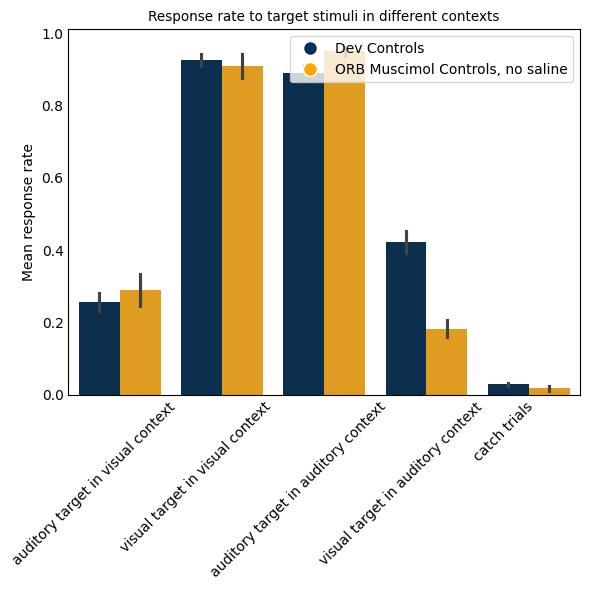

In [12]:
controls_df['session_id'] = controls_df['session_id'].astype(str)

ctrl_dict = {
    'Condition': ['Dev Control', 'Muscimol Control, no saline'],

    # 'both targets': [
    # muscimol_df[muscimol_df['control']]['both_targets'].mean(),
    # muscimol_df[muscimol_df['perturbation']]['both_targets'].mean()
    # ],
    # 'auditory target':[
    #     muscimol_df[muscimol_df['control']]['auditory_target'].mean(),
    #     muscimol_df[muscimol_df['perturbation']]['auditory_target'].mean()
    # ],
    # 'visual target':[
    #     muscimol_df[muscimol_df['control']]['visual_target'].mean(),
    #     muscimol_df[muscimol_df['perturbation']]['visual_target'].mean()
    # ],
     'auditory target in visual context':[
        controls_df[controls_df['dev_controls']]['auditory_target_in_visual_context'].values,
        controls_df[controls_df['task_only_controls']]['auditory_target_in_visual_context'].values
    ],
     'visual target in visual context':[
        controls_df[controls_df['dev_controls']]['visual_target_in_visual_context'].values,
        controls_df[controls_df['task_only_controls']]['visual_target_in_visual_context'].values
    ],
     'auditory target in auditory context':[
        controls_df[controls_df['dev_controls']]['auditory_target_in_auditory_context'].values,
        controls_df[controls_df['task_only_controls']]['auditory_target_in_auditory_context'].values
    ],
     'visual target in auditory context':[
        controls_df[controls_df['dev_controls']]['visual_target_in_auditory_context'].values,
        controls_df[controls_df['task_only_controls']]['visual_target_in_auditory_context'].values
    ],

    'catch trials' :[
        controls_df[controls_df['dev_controls']]['catch_trials'].values,
        controls_df[controls_df['task_only_controls']]['catch_trials'].values
    ]

}

# Create a DataFrame from the dictionary
ctrl_df = pd.DataFrame(ctrl_dict)

ctrl_df_melted = ctrl_df.melt(id_vars='Condition', var_name='Category', value_name='Mean Value')

# Plotting the bar plot
plt.figure(figsize=(6, 6))
ax = sns.barplot(x='Category', y='Mean Value', hue='Condition', errorbar='se',
                 data=ctrl_df_melted.explode('Mean Value'), palette=['#003057', '#FFA500'])

plt.xlabel('')
plt.xticks(rotation = 45)
current_ticks = ax.get_xticks()
new_ticks = [tick - 0.25 for tick in current_ticks] # Adjust the value as needed
ax.set_xticks(new_ticks)

ax.tick_params(axis='both', which='both', length=0)


plt.ylabel('Mean response rate', fontsize = 10)
plt.title('Response rate to target stimuli in different contexts', fontsize = 9.75)
# plt.legend(loc='upper right')
# plt.legend(['Control', 'ORB-lesion'])
# plt.show()
plt.tight_layout()

handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='#003057', markersize=10),
        plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='#FFA500', markersize=10)]
labels = ['Dev Controls', 'ORB Muscimol Controls, no saline']
plt.legend(handles, labels, loc='upper right')
            # bbox_to_anchor=(1, 1))

plt.tight_layout()

# plt.savefig(r"C:\Users\vayle.lafehr\Desktop\perturbation_analysis_figures\mean_response_rate_both_targets&contexts.png", dpi=300)

plt.show()


In [21]:


# print(controls_df)

controls_df['color_group'] = controls_df['session_id'].apply(
    lambda x: x.split('_')[0].split('(')[1].strip("'")
)

unique_groups = controls_df['color_group'].unique()
colors = plt.cm.get_cmap('tab10', len(unique_groups))
color_map = {group: colors(i) for i, group in enumerate(unique_groups)}

dev_controls_df = controls_df[controls_df['dev_controls']].reset_index(drop=True)
task_only_controls = controls_df[controls_df['orb_task']].reset_index(drop=True)

dev_controls_df = dev_controls_df.sample(frac=1, random_state=None).reset_index(drop=True)
task_only_controls = task_only_controls.sample(frac=1, random_state=None).reset_index(drop=True)


# Filter for task only and dev controls
task_only_vis = controls_df[controls_df['orb_task']]['visual_target_in_visual_context'].dropna().values
dev_vis = controls_df[controls_df['dev_controls']]['visual_target_in_visual_context'].dropna().values

# Shuffle both arrays
np.random.shuffle(task_only_vis)
np.random.shuffle(dev_vis)

# Pair up to the smallest group size
n_pairs = min(len(task_only_vis), len(dev_vis))
paired_vis_vis = list(zip(task_only_vis[:n_pairs], dev_vis[:n_pairs]))

# paired_vis_vis is now a list of (saline, dev) tuples
print(paired_vis_vis)


task_only_av = controls_df[controls_df['orb_task']]['auditory_target_in_visual_context'].dropna().values
dev_av = controls_df[controls_df['dev_controls']]['auditory_target_in_visual_context'].dropna().values

# Shuffle both arrays
np.random.shuffle(task_only_av)
np.random.shuffle(dev_av)

# Pair up to the smallest group size
n_pairs = min(len(task_only_av), len(dev_av))
paired_aud_vis = list(zip(task_only_av[:n_pairs], dev_av[:n_pairs]))

# paired_vis_vis is now a list of (saline, dev) tuples
print(paired_aud_vis)

task_only_va = controls_df[controls_df['orb_task']]['visual_target_in_auditory_context'].dropna().values
dev_va = controls_df[controls_df['dev_controls']]['visual_target_in_auditory_context'].dropna().values

# Shuffle both arrays
np.random.shuffle(task_only_va)
np.random.shuffle(dev_va)

# Pair up to the smallest group size
n_pairs = min(len(task_only_va), len(dev_va))
paired_vis_aud = list(zip(task_only_va[:n_pairs], dev_va[:n_pairs]))

# paired_vis_aud is now a list of (saline, dev) tuples
print(paired_vis_aud)


task_only_aud = controls_df[controls_df['orb_task']]['auditory_target_in_auditory_context'].dropna().values
dev_aud = controls_df[controls_df['dev_controls']]['auditory_target_in_auditory_context'].dropna().values

# Shuffle both arrays
np.random.shuffle(task_only_aud)
np.random.shuffle(dev_aud)

# Pair up to the smallest group size
n_pairs = min(len(task_only_aud), len(dev_aud))
paired_aud_aud = list(zip(task_only_aud[:n_pairs], dev_aud[:n_pairs]))

# paired_vis_aud is now a list of (saline, dev) tuples
print(paired_aud_aud)

# # Create scatter plot with x = perturbation, y = control
plt.figure(figsize=(20, 20))

# # data = [paired_data_vis_vis, paired_data_aud_vis]
# # for datum in data:
# #     for x, y, group in datum:
# #         print((x,y,group))
# #         plt.scatter(x, y, color=color_map[group], label=group, alpha=0.8, linewidth = 0.2)
# #         plt.scatter(x, y, color=color_map[group], label=group, alpha=0.8)

fig, axes = plt.subplots(1, 4, figsize=(15, 5), sharex=True, sharey=True)

contexts = ['Visual Target in Visual Context', 'Auditory Target in Visual Context', 'Visual Target in Auditory Context', 'Auditory Target in Auditory Context']
data = [paired_vis_vis, paired_aud_vis, paired_vis_aud, paired_aud_aud]
# print(data)

    
# #organize paired data

paired_data_sets ={
    'vis_vis': paired_vis_vis,
    'aud_vis': paired_aud_vis,
    'vis_aud': paired_vis_aud,
    'aud_aud': paired_aud_aud,
}
    

# #mean cross


for ax, (label, paired_data) in zip(axes, paired_data_sets.items()):
    x_vals = [x for x, y in paired_data]
    y_vals = [y for x, y in paired_data]
#     # print(f"{label} - x_vals: {x_vals}, y_vals: {y_vals}")
    
    x_mean, y_mean = np.mean(x_vals), np.mean(y_vals)
    x_std, y_std = np.std(x_vals), np.std(y_vals)
    ax.plot([x_mean - x_std, x_mean +x_std], [y_mean, y_mean], color='black', lw=1.5)
    ax.plot([x_mean, x_mean], [y_mean - y_std, y_mean + y_std], color='black', lw=1.5)


    for ax, datum, title in zip(axes, data, contexts):
        for x, y in datum:
#             print((x, y, group))
            ax.scatter(x, y, alpha=0.8, linewidth=0.2)


# for ax in axes:
    # ax.errorbar(np.mean(x_vals), np.mean(y_vals), xerr=x_std, yerr=y_std, fmt='o', color='black', markersize=5, label='Mean ± Std Dev', alpha=0.5)
# unity line

for ax in axes:
    ax.plot([0, 1], [0, 1], 'k--', linewidth=0.8)  # Unity line for each subplot

for ax, x_label in zip(axes, 'Task only Control RR'):
    ax.set_xlabel('Task only Control RR', fontsize =11)


for ax, y_label in zip(axes, 'Dev Control Response Rate'):
    ax.set_ylabel('Dev Control Response Rate', fontsize=11)
# ax.set_title(f'{c for c in contexts}', fontsize=12)

for ax, title in zip(axes, contexts):
    ax.set_title(f'{title}', fontsize=12)

for ax in axes:
    ax.yaxis.set_tick_params(labelleft=True)

# for ax, (label, paired_data) in zip(axes, paired_data_sets.items()):
#     x_vals = [x for x, y in paired_data]  # Perturbation
#     y_vals = [y for x, y in paired_data]  # Control

    # Run paired t-test
# t_stat, p_val = stats.ttest_rel(x_vals, y_vals)

#     # Plot scatter and mean cross as before...
#     # [your existing plotting code here]

#     # Annotate with t-test result
# ax.text(0.95, 0.05, f't = {t_stat:.2f}\np = {p_val:.3g}',
#             transform=ax.transAxes, fontsize=10,
#             verticalalignment='bottom', horizontalalignment='right', bbox=dict(facecolor='white', alpha=0.5, edgecolor='gray'))

# Create legend with unique mouse IDs
# handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=color_map[group], markersize=8) for group in unique_groups]
# plt.legend(handles, unique_groups, title="Mouse ID", bbox_to_anchor=(1.05, 1), loc='upper left')

handles = [plt.Line2D([0], [0], marker='o', color='w',
                      markerfacecolor=color_map[group], markersize=8)
           for group in unique_groups]
fig.legend(handles, unique_groups, title="Mouse ID",
           bbox_to_anchor=(1.05, 0.5), loc='center left')

plt.tight_layout()


# plt.savefig(r"Z:\vayle\muscimol_ORB_behavior_plots\ORB_population_effects_unity_line_scatter_plot", dpi=300)
plt.show()



IndexError: list index out of range

In [298]:
print("task_only_vis:", len(task_only_vis))
print("dev_vis:", len(dev_vis))
print("paired_vis_vis:", len(paired_vis_vis))

task_only_vis: 17
dev_vis: 6
paired_vis_vis: 17


In [283]:

# print(controls_df)

# controls_df['color_group'] = controls_df['session_id'].apply(
#     lambda x: x.split('_')[0].split('(')[1].strip("'")
# )

unique_groups = controls_df['color_group'].unique()
colors = plt.cm.get_cmap('tab10', len(unique_groups))
color_map = {group: colors(i) for i, group in enumerate(unique_groups)}

saline_controls_df = controls_df[controls_df['saline_controls_all']].reset_index(drop=True)
task_only_controls = controls_df[controls_df['task_only_controls']].reset_index(drop=True)

saline_controls_df = saline_controls_df.sample(frac=1, random_state=None).reset_index(drop=True)
task_only_controls = task_only_controls.sample(frac=1, random_state=None).reset_index(drop=True)


# Filter for task only and dev controls
task_only_vis = controls_df[controls_df['task_only_controls']]['visual_target_in_visual_context'].dropna().values
saline_vis = controls_df[controls_df['saline_controls_all']]['visual_target_in_visual_context'].dropna().values

# Shuffle both arrays
np.random.shuffle(task_only_vis)
np.random.shuffle(saline_vis)

# Pair up to the smallest group size
n_pairs = min(len(task_only_vis), len(saline_vis))
paired_vis_vis = list(zip(task_only_vis[:n_pairs], saline_vis[:n_pairs]))

# paired_vis_vis is now a list of (saline, dev) tuples
print(paired_vis_vis)


task_only_av = controls_df[controls_df['task_only_controls']]['auditory_target_in_visual_context'].dropna().values
saline_av = controls_df[controls_df['saline_controls_all']]['auditory_target_in_visual_context'].dropna().values

# Shuffle both arrays
np.random.shuffle(task_only_av)
np.random.shuffle(saline_av)

# Pair up to the smallest group size
n_pairs = min(len(task_only_av), len(saline_av))
paired_aud_vis = list(zip(task_only_av[:n_pairs], saline_av[:n_pairs]))

# paired_vis_vis is now a list of (saline, dev) tuples
print(paired_aud_vis)

task_only_va = controls_df[controls_df['task_only_controls']]['visual_target_in_auditory_context'].dropna().values
saline_va = controls_df[controls_df['saline_controls_all']]['visual_target_in_auditory_context'].dropna().values

# Shuffle both arrays
np.random.shuffle(task_only_va)
np.random.shuffle(saline_va)

# Pair up to the smallest group size
n_pairs = min(len(task_only_va), len(saline_va))
paired_vis_aud = list(zip(task_only_va[:n_pairs], saline_va[:n_pairs]))

# paired_vis_aud is now a list of (saline, dev) tuples
print(paired_vis_aud)


task_only_aud = controls_df[controls_df['task_only_controls']]['auditory_target_in_auditory_context'].dropna().values
saline_aud = controls_df[controls_df['saline_controls_all']]['auditory_target_in_auditory_context'].dropna().values

# Shuffle both arrays
np.random.shuffle(task_only_aud)
np.random.shuffle(saline_aud)

# Pair up to the smallest group size
n_pairs = min(len(task_only_aud), len(saline_aud))
paired_aud_aud = list(zip(task_only_aud[:n_pairs], saline_aud[:n_pairs]))

# paired_vis_aud is now a list of (saline, dev) tuples
print(paired_aud_aud)

# # Create scatter plot with x = perturbation, y = control
plt.figure(figsize=(20, 20))

# # data = [paired_data_vis_vis, paired_data_aud_vis]
# # for datum in data:
# #     for x, y, group in datum:
# #         print((x,y,group))
# #         plt.scatter(x, y, color=color_map[group], label=group, alpha=0.8, linewidth = 0.2)
# #         plt.scatter(x, y, color=color_map[group], label=group, alpha=0.8)

fig, axes = plt.subplots(1, 4, figsize=(15, 5), sharex=True, sharey=True)

contexts = ['Visual Target in Visual Context', 'Auditory Target in Visual Context', 'Visual Target in Auditory Context', 'Auditory Target in Auditory Context']
data = [paired_vis_vis, paired_aud_vis, paired_vis_aud, paired_aud_aud]
# print(data)

    
# #organize paired data

paired_data_sets ={
    'vis_vis': paired_vis_vis,
    'aud_vis': paired_aud_vis,
    'vis_aud': paired_vis_aud,
    'aud_aud': paired_aud_aud,
}
    

# #mean cross


for ax, (label, paired_data) in zip(axes, paired_data_sets.items()):
    x_vals = [x for x, y in paired_data]
    y_vals = [y for x, y in paired_data]
#     # print(f"{label} - x_vals: {x_vals}, y_vals: {y_vals}")
    
    x_mean, y_mean = np.mean(x_vals), np.mean(y_vals)
    x_std, y_std = np.std(x_vals), np.std(y_vals)
    ax.plot([x_mean - x_std, x_mean +x_std], [y_mean, y_mean], color='black', lw=1.5)
    ax.plot([x_mean, x_mean], [y_mean - y_std, y_mean + y_std], color='black', lw=1.5)


    for ax, datum, title in zip(axes, data, contexts):
        for x, y in datum:
#             print((x, y, group))
            ax.scatter(x, y, alpha=0.8, linewidth=0.2)


# for ax in axes:
    # ax.errorbar(np.mean(x_vals), np.mean(y_vals), xerr=x_std, yerr=y_std, fmt='o', color='black', markersize=5, label='Mean ± Std Dev', alpha=0.5)
# unity line

for ax in axes:
    ax.plot([0, 1], [0, 1], 'k--', linewidth=0.8)  # Unity line for each subplot

for ax, x_label in zip(axes, 'Task only Control RR'):
    ax.set_xlabel('Task only Control RR', fontsize =11)


for ax, y_label in zip(axes, 'Saline Control Response Rate'):
    ax.set_ylabel('Saline Control Response Rate', fontsize=11)
# ax.set_title(f'{c for c in contexts}', fontsize=12)

for ax, title in zip(axes, contexts):
    ax.set_title(f'{title}', fontsize=12)

for ax in axes:
    ax.yaxis.set_tick_params(labelleft=True)

# for ax, (label, paired_data) in zip(axes, paired_data_sets.items()):
#     x_vals = [x for x, y in paired_data]  # Perturbation
#     y_vals = [y for x, y in paired_data]  # Control

    # Run paired t-test
# t_stat, p_val = stats.ttest_rel(x_vals, y_vals)

#     # Plot scatter and mean cross as before...
#     # [your existing plotting code here]

#     # Annotate with t-test result
# ax.text(0.95, 0.05, f't = {t_stat:.2f}\np = {p_val:.3g}',
#             transform=ax.transAxes, fontsize=10,
#             verticalalignment='bottom', horizontalalignment='right', bbox=dict(facecolor='white', alpha=0.5, edgecolor='gray'))

# Create legend with unique mouse IDs
# handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=color_map[group], markersize=8) for group in unique_groups]
# plt.legend(handles, unique_groups, title="Mouse ID", bbox_to_anchor=(1.05, 1), loc='upper left')

handles = [plt.Line2D([0], [0], marker='o', color='w',
                      markerfacecolor=color_map[group], markersize=8)
           for group in unique_groups]
fig.legend(handles, unique_groups, title="Mouse ID",
           bbox_to_anchor=(1.05, 0.5), loc='center left')

plt.tight_layout()


# plt.savefig(r"Z:\vayle\muscimol_ORB_behavior_plots\ORB_population_effects_unity_line_scatter_plot", dpi=300)
plt.show()



KeyError: 'color_group'

In [284]:

unique_groups = controls_df['color_group'].unique()
colors = plt.cm.get_cmap('tab10', len(unique_groups))
color_map = {group: colors(i) for i, group in enumerate(unique_groups)}

dev_controls_df = controls_df[controls_df['dev_controls']].reset_index(drop=True)
saline_controls_df = controls_df[controls_df['saline_controls_all']].reset_index(drop=True)

dev_controls_df = dev_controls_df.sample(frac=1, random_state=None).reset_index(drop=True)
saline_controls_df = saline_controls_df.sample(frac=1, random_state=None).reset_index(drop=True)
 


# Filter for saline and dev controls
saline_vis = controls_df[controls_df['saline_controls_all']]['visual_target_in_visual_context'].dropna().values
dev_vis = controls_df[controls_df['dev_controls']]['visual_target_in_visual_context'].dropna().values

# Shuffle both arrays
np.random.shuffle(saline_vis)
np.random.shuffle(dev_vis)

# Pair up to the smallest group size
n_pairs = min(len(saline_vis), len(dev_vis))
paired_vis_vis = list(zip(saline_vis[:n_pairs], dev_vis[:n_pairs]))

# paired_vis_vis is now a list of (saline, dev) tuples
print(paired_vis_vis)


saline_av = controls_df[controls_df['saline_controls_all']]['auditory_target_in_visual_context'].dropna().values
dev_av = controls_df[controls_df['dev_controls']]['auditory_target_in_visual_context'].dropna().values

# Shuffle both arrays
np.random.shuffle(saline_av)
np.random.shuffle(dev_av)

# Pair up to the smallest group size
n_pairs = min(len(saline_av), len(dev_av))
paired_aud_vis = list(zip(saline_av[:n_pairs], dev_av[:n_pairs]))

# paired_vis_vis is now a list of (saline, dev) tuples
print(paired_aud_vis)

saline_va = controls_df[controls_df['saline_controls_all']]['visual_target_in_auditory_context'].dropna().values
dev_va = controls_df[controls_df['dev_controls']]['visual_target_in_auditory_context'].dropna().values

# Shuffle both arrays
np.random.shuffle(saline_va)
np.random.shuffle(dev_va)

# Pair up to the smallest group size
n_pairs = min(len(saline_va), len(dev_va))
paired_vis_aud = list(zip(saline_va[:n_pairs], dev_va[:n_pairs]))

# paired_vis_aud is now a list of (saline, dev) tuples
print(paired_vis_aud)


saline_aud = controls_df[controls_df['saline_controls_all']]['auditory_target_in_auditory_context'].dropna().values
dev_aud = controls_df[controls_df['dev_controls']]['auditory_target_in_auditory_context'].dropna().values

# Shuffle both arrays
np.random.shuffle(saline_aud)
np.random.shuffle(dev_aud)

# Pair up to the smallest group size
n_pairs = min(len(saline_aud), len(dev_aud))
paired_aud_aud = list(zip(saline_aud[:n_pairs], dev_aud[:n_pairs]))

# paired_vis_aud is now a list of (saline, dev) tuples
print(paired_aud_aud)


plt.figure(figsize=(20, 20))

fig, axes = plt.subplots(1, 4, figsize=(15, 5), sharex=True, sharey=True)

contexts = ['Visual Target in Visual Context', 'Auditory Target in Visual Context', 'Visual Target in Auditory Context', 'Auditory Target in Auditory Context']
data = [paired_vis_vis, paired_aud_vis, paired_vis_aud, paired_aud_aud]
# print(data)

    
# #organize paired data

paired_data_sets ={
    'vis_vis': paired_vis_vis,
    'aud_vis': paired_aud_vis,
    'vis_aud': paired_vis_aud,
    'aud_aud': paired_aud_aud,
}
    

# #mean cross


for ax, (label, paired_data) in zip(axes, paired_data_sets.items()):
    x_vals = [x for x, y in paired_data]
    y_vals = [y for x, y in paired_data]
#     # print(f"{label} - x_vals: {x_vals}, y_vals: {y_vals}")
    
    x_mean, y_mean = np.mean(x_vals), np.mean(y_vals)
    x_std, y_std = np.std(x_vals), np.std(y_vals)
    ax.plot([x_mean - x_std, x_mean +x_std], [y_mean, y_mean], color='black', lw=1.5)
    ax.plot([x_mean, x_mean], [y_mean - y_std, y_mean + y_std], color='black', lw=1.5)


    for ax, datum, title in zip(axes, data, contexts):
        for x, y in datum:
#             print((x, y, group))
            ax.scatter(x, y, alpha=0.8, linewidth=0.2)



for ax in axes:
    ax.plot([0, 1], [0, 1], 'k--', linewidth=0.8)  # Unity line for each subplot

for ax, x_label in zip(axes, 'Saline Control RR'):
    ax.set_xlabel('Saline Control RR', fontsize =11)


for ax, y_label in zip(axes, 'Dev Control Response Rate'):
    ax.set_ylabel('Dev Control Response Rate', fontsize=11)
# ax.set_title(f'{c for c in contexts}', fontsize=12)

for ax, title in zip(axes, contexts):
    ax.set_title(f'{title}', fontsize=12)

for ax in axes:
    ax.yaxis.set_tick_params(labelleft=True)


handles = [plt.Line2D([0], [0], marker='o', color='w',
                      markerfacecolor=color_map[group], markersize=8)
           for group in unique_groups]
fig.legend(handles, unique_groups, title="Mouse ID",
           bbox_to_anchor=(1.05, 0.5), loc='center left')

plt.tight_layout()


# plt.savefig(r"Z:\vayle\muscimol_ORB_behavior_plots\ORB_population_effects_unity_line_scatter_plot", dpi=300)
plt.show()

KeyError: 'color_group'

C:\Users\vayle.lafehr\AppData\Local\Temp\ipykernel_35164\4225803855.py:19: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', len(unique_groups))


(0.352112676056338, 0.9583333333333334, '728053')
(0.7297297297297297, 0.9861111111111112, '728053')
(0.8783783783783784, 0.9861111111111112, '739828')
(0.7916666666666666, 0.9861111111111112, '739828')
(0.7123287671232876, 0.9324324324324325, '772657')
(0.8970588235294118, 0.9733333333333334, '772657')
(0.9733333333333334, 0.96, '774916')
(0.013888888888888888, 0.9855072463768116, '774916')
(1.0, 0.9722222222222222, '767405')
(0.5774647887323944, 0.8309859154929577, '767405')
(0.4931506849315068, 0.9859154929577465, '782106')
(0.7714285714285715, 0.7714285714285715, '782106')
(0.14084507042253522, 0.8611111111111112, '774470')
(0.8363636363636363, 0.4727272727272727, '728053')
(1.0, 0.19672131147540983, '728053')
(0.9473684210526315, 0.39285714285714285, '739828')
(0.9122807017543859, 0.5263157894736842, '739828')
(0.4482758620689655, 0.3898305084745763, '772657')
(0.8771929824561403, 0.3770491803278688, '772657')
(0.8333333333333334, 0.75, '774916')
(0.5172413793103449, 0.51851851851

<Figure size 2000x2000 with 0 Axes>

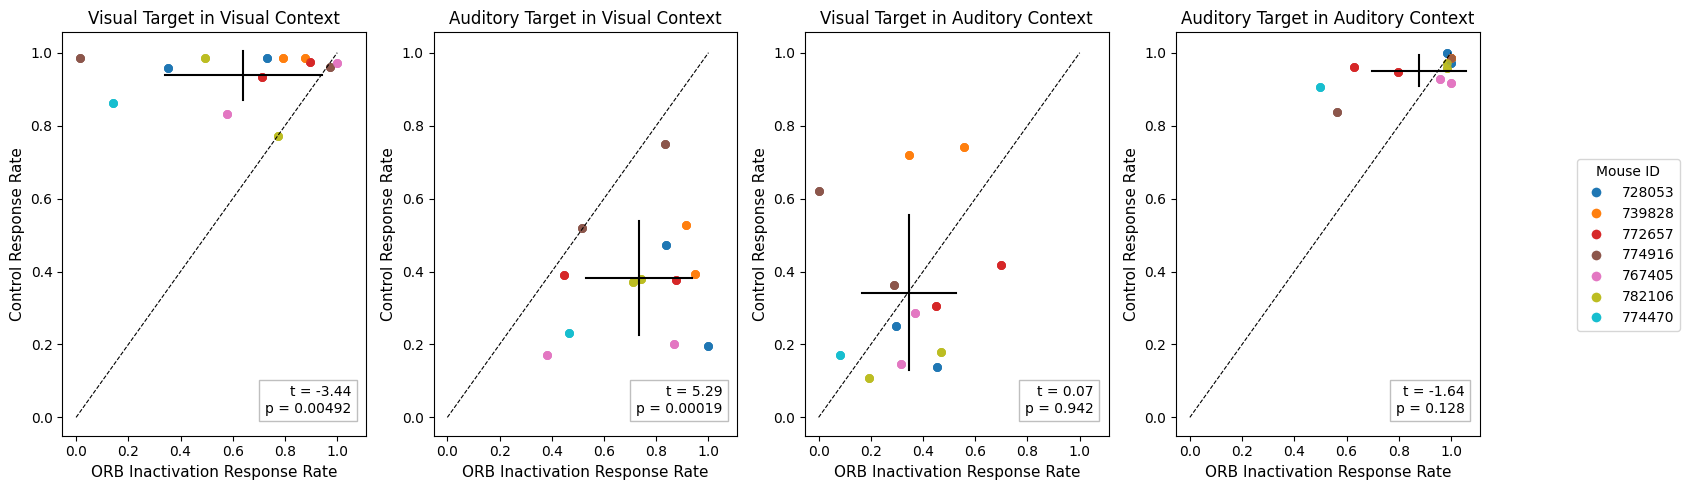

In [285]:
import matplotlib.pyplot as plt
from datetime import datetime
from scipy import stats


#clean
muscimol_df_orb['color_group'] = muscimol_df_orb['session_id'].apply(
    lambda x: x.split('_')[0].split('(')[1].strip("'")
)

# Sort by date
muscimol_df_orb['date'] = muscimol_df_orb['session_id'].apply(
    lambda x: datetime.strptime(x.split('_')[1].split("'")[0], '%Y-%m-%d')
)
muscimol_df_orb = muscimol_df_orb.sort_values(by='date').reset_index(drop=True)

# unique colors bymouse ID
unique_groups = muscimol_df_orb['color_group'].unique()
colors = plt.cm.get_cmap('tab10', len(unique_groups))
color_map = {group: colors(i) for i, group in enumerate(unique_groups)}

# Pair control and perturbation sessions
paired_data_vis_vis = []
for i in range(1, len(muscimol_df_orb), 2):
    row1 = muscimol_df_orb.loc[i - 1]
    row2 = muscimol_df_orb.loc[i]
    if row1['control']:
        control_val = row1['visual_target_in_visual_context']
        perturb_val = row2['visual_target_in_visual_context']
        color_group = row1['color_group']
    else:
        control_val = row2['visual_target_in_visual_context']
        perturb_val = row1['visual_target_in_visual_context']
        color_group = row2['color_group']
    paired_data_vis_vis.append((perturb_val, control_val, color_group))

    paired_data_aud_vis = []
for i in range(1, len(muscimol_df_orb), 2):
    row1 = muscimol_df_orb.loc[i - 1]
    row2 = muscimol_df_orb.loc[i]
    if row1['control']:
        control_val_1 = row1['auditory_target_in_visual_context']
        perturb_val_1 = row2['auditory_target_in_visual_context']
        color_group = row1['color_group']
    else:
        control_val_1 = row2['auditory_target_in_visual_context']
        perturb_val_1 = row1['auditory_target_in_visual_context']
        color_group = row2['color_group']
    paired_data_aud_vis.append((perturb_val_1, control_val_1, color_group))

    paired_data_vis_aud = []
for i in range(1, len(muscimol_df_orb), 2):
    row1 = muscimol_df_orb.loc[i - 1]
    row2 = muscimol_df_orb.loc[i]
    if row1['control']:
        control_val_2 = row1['visual_target_in_auditory_context']
        perturb_val_2 = row2['visual_target_in_auditory_context']
        color_group = row1['color_group']
    else:
        control_val_2 = row2['visual_target_in_auditory_context']
        perturb_val_2 = row1['visual_target_in_auditory_context']
        color_group = row2['color_group']
    paired_data_vis_aud.append((perturb_val_2, control_val_2, color_group))

    paired_data_aud_aud = []
for i in range(1, len(muscimol_df_orb), 2):
    row1 = muscimol_df_orb.loc[i - 1]
    row2 = muscimol_df_orb.loc[i]
    if row1['control']:
        control_val_3 = row1['auditory_target_in_auditory_context']
        perturb_val_3 = row2['auditory_target_in_auditory_context']
        color_group = row1['color_group']
    else:
        control_val_3 = row2['auditory_target_in_auditory_context']
        perturb_val_3 = row1['auditory_target_in_auditory_context']
        color_group = row2['color_group']
    paired_data_aud_aud.append((perturb_val_3, control_val_3, color_group))

# Create scatter plot with x = perturbation, y = control
plt.figure(figsize=(20, 20))

# data = [paired_data_vis_vis, paired_data_aud_vis]
# for datum in data:
#     for x, y, group in datum:
#         print((x,y,group))
#         plt.scatter(x, y, color=color_map[group], label=group, alpha=0.8, linewidth = 0.2)
#         plt.scatter(x, y, color=color_map[group], label=group, alpha=0.8)

fig, axes = plt.subplots(1, 4, figsize=(15, 5), sharex=True, sharey=True)

contexts = ['Visual Target in Visual Context', 'Auditory Target in Visual Context', 'Visual Target in Auditory Context', 'Auditory Target in Auditory Context']
data = [paired_data_vis_vis, paired_data_aud_vis, paired_data_vis_aud, paired_data_aud_aud]

#make test star for plot


    
#organize paired data

paired_data_sets ={
    'vis_vis': paired_data_vis_vis,
    'aud_vis': paired_data_aud_vis,
    'vis_aud': paired_data_vis_aud,
    'aud_aud': paired_data_aud_aud,
}
    

#mean cross


for ax, (label, paired_data) in zip(axes, paired_data_sets.items()):
    x_vals = [x for x, _, _ in paired_data]
    y_vals = [y for _, y, _ in paired_data]
    # print(f"{label} - x_vals: {x_vals}, y_vals: {y_vals}")
    
    x_mean, y_mean = np.mean(x_vals), np.mean(y_vals)
    x_std, y_std = np.std(x_vals), np.std(y_vals)
    ax.plot([x_mean - x_std, x_mean +x_std], [y_mean, y_mean], color='black', lw=1.5)
    ax.plot([x_mean, x_mean], [y_mean - y_std, y_mean + y_std], color='black', lw=1.5)


    for ax, datum, title in zip(axes, data, contexts):
        for x, y, group in datum:
            print((x, y, group))
            ax.scatter(x, y, color=color_map[group], alpha=0.8, linewidth=0.2)





# for ax in axes:
    # ax.errorbar(np.mean(x_vals), np.mean(y_vals), xerr=x_std, yerr=y_std, fmt='o', color='black', markersize=5, label='Mean ± Std Dev', alpha=0.5)
# unity line

for ax in axes:
    ax.plot([0, 1], [0, 1], 'k--', linewidth=0.8)  # Unity line for each subplot
# plt.plot([0, 1], [0, 1], 'k--')


# ax.set_xlim(0, 1)
# ax.set_ylim(0, 1)
#adds space to plot size
# x_vals = [x for x, _, _ in paired_data]
# y_vals = [y for _, y, _ in paired_data]

# x_min, x_max = min(x_vals), max(x_vals)
# y_min, y_max = min(y_vals), max(y_vals)

# padding_x = (x_max - x_min) * 0.05  # 5% padding
# padding_y = (y_max - y_min) * 0.05

# ax.set_xlim(x_min - padding_x, x_max + padding_x)
# ax.set_ylim(y_min - padding_y, y_max + padding_y)


for ax, x_label in zip(axes, 'ORB Inactivation Response Rate'):
    ax.set_xlabel('ORB Inactivation Response Rate', fontsize =11)


for ax, y_label in zip(axes, 'Control Response Rate'):
    ax.set_ylabel('Control Response Rate', fontsize=11)
# ax.set_title(f'{c for c in contexts}', fontsize=12)

for ax, title in zip(axes, contexts):
    ax.set_title(f'{title}', fontsize=12)

for ax in axes:
    ax.yaxis.set_tick_params(labelleft=True)
# ax.grid(True)
for ax, (label, paired_data) in zip(axes, paired_data_sets.items()):
    x_vals = [x for x, _, _ in paired_data]  # Perturbation
    y_vals = [y for _, y, _ in paired_data]  # Control

    # Run paired t-test
    t_stat, p_val = stats.ttest_rel(x_vals, y_vals)

    # Plot scatter and mean cross as before...
    # [your existing plotting code here]

    # Annotate with t-test result
    ax.text(0.95, 0.05, f't = {t_stat:.2f}\np = {p_val:.3g}',
            transform=ax.transAxes, fontsize=10,
            verticalalignment='bottom', horizontalalignment='right', bbox=dict(facecolor='white', alpha=0.5, edgecolor='gray'))

# Create legend with unique mouse IDs
# handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=color_map[group], markersize=8) for group in unique_groups]
# plt.legend(handles, unique_groups, title="Mouse ID", bbox_to_anchor=(1.05, 1), loc='upper left')

handles = [plt.Line2D([0], [0], marker='o', color='w',
                      markerfacecolor=color_map[group], markersize=8)
           for group in unique_groups]
fig.legend(handles, unique_groups, title="Mouse ID",
           bbox_to_anchor=(1.05, 0.5), loc='center left')

plt.tight_layout()


# plt.savefig(r"Z:\vayle\muscimol_ORB_behavior_plots\ORB_population_effects_unity_line_scatter_plot", dpi=300)
plt.show()

## Distribution of d' for Dev controls

In [15]:
r"C:\Users\vayle.lafehr\Desktop\Perturbations\session_table_v0.272.xlsx"

'C:\\Users\\vayle.lafehr\\Desktop\\Perturbations\\session_table_v0.272.xlsx'

In [19]:

excel_path = r"C:\Users\vayle.lafehr\Desktop\Perturbations\session_table_v0.272.xlsx"
devs_session_table_df = pd.read_excel(excel_path)

# Display the first few rows to confirm
print(devs_session_table_df.head())

          session_id  is_production         project       date      time  \
0  620263_2022-07-26           True       Templeton 2022-07-26  14:08:55   
1  620263_2022-07-27           True       Templeton 2022-07-27  13:56:52   
2  620264_2022-08-02           True       Templeton 2022-08-02  15:39:59   
3  626791_2022-08-15           True  DynamicRouting 2022-08-15  11:22:17   
4  626791_2022-08-16           True  DynamicRouting 2022-08-16  12:42:51   

   subject_id  subject_age_days subject_sex subject_genotype    implant  ...  \
0      620263               173           F            wt/wt        NaN  ...   
1      620263               174           F            wt/wt        NaN  ...   
2      620264               180           F            wt/wt        NaN  ...   
3      626791               146           M            wt/wt  Templeton  ...   
4      626791               147           M            wt/wt  Templeton  ...   

                          n_hits           n_contingent_reward

In [20]:
#filter devs_session_table_df by is_ephys == TRUE, is_injection_control == FALSE, is_injection_perturbation == FALSE, is_good_behavior == TRUE, is_stage_5_passed == TRUE, project == DynamicRouting, is_production == TRUE, epoochs contains 'RFMapping;Spontaneous;SpontaneousRewards;DynamicRouting1;SpontaneousRewards;Spontaneous'

# Filter devs_session_table_df by the specified criteria
passing_beh_devs_df = devs_session_table_df[
    (devs_session_table_df['is_ephys'] == True) &
    (devs_session_table_df['is_injection_control'] == False) &
    (devs_session_table_df['is_injection_perturbation'] == False) &
    (devs_session_table_df['is_good_behavior'] == True) &
    (devs_session_table_df['project'] == 'DynamicRouting') &
    (devs_session_table_df['is_production'] == True) 
    # (devs_session_table_df['epochs'].str.contains('RFMapping;Spontaneous;SpontaneousRewards;DynamicRouting1;SpontaneousRewards;Spontaneous', na=False))
]

print(passing_beh_devs_df)

            session_id  is_production         project       date      time  \
3    626791_2022-08-15           True  DynamicRouting 2022-08-15  11:22:17   
4    626791_2022-08-16           True  DynamicRouting 2022-08-16  12:42:51   
14   636766_2023-01-23           True  DynamicRouting 2023-01-23  11:50:21   
15   636766_2023-01-24           True  DynamicRouting 2023-01-24  11:59:01   
16   636766_2023-01-25           True  DynamicRouting 2023-01-25  12:48:18   
..                 ...            ...             ...        ...       ...   
239  759434_2025-02-03           True  DynamicRouting 2025-02-03  13:16:51   
240  759434_2025-02-04           True  DynamicRouting 2025-02-04  12:27:22   
241  759434_2025-02-05           True  DynamicRouting 2025-02-05  12:32:35   
242  759434_2025-02-06           True  DynamicRouting 2025-02-06  12:25:33   
243  759434_2025-02-07           True  DynamicRouting 2025-02-07  10:59:54   

     subject_id  subject_age_days subject_sex  subject_genotype

In [21]:
#make a new col with all d primes

cross_modal_cols = [
    "cross_modality_dprime_vis_blocks",
    "cross_modality_dprime_aud_blocks"
]
cross_modal_cols = [col for col in cross_modal_cols if col in passing_beh_devs_df.columns]

# Combine for each row (session)
passing_beh_devs_df['all_dprimes'] = passing_beh_devs_df.apply(
    lambda row: [row[col] for col in cross_modal_cols if pd.notnull(row[col])],
    axis=1
)

print(passing_beh_devs_df)




            session_id  is_production         project       date      time  \
3    626791_2022-08-15           True  DynamicRouting 2022-08-15  11:22:17   
4    626791_2022-08-16           True  DynamicRouting 2022-08-16  12:42:51   
14   636766_2023-01-23           True  DynamicRouting 2023-01-23  11:50:21   
15   636766_2023-01-24           True  DynamicRouting 2023-01-24  11:59:01   
16   636766_2023-01-25           True  DynamicRouting 2023-01-25  12:48:18   
..                 ...            ...             ...        ...       ...   
239  759434_2025-02-03           True  DynamicRouting 2025-02-03  13:16:51   
240  759434_2025-02-04           True  DynamicRouting 2025-02-04  12:27:22   
241  759434_2025-02-05           True  DynamicRouting 2025-02-05  12:32:35   
242  759434_2025-02-06           True  DynamicRouting 2025-02-06  12:25:33   
243  759434_2025-02-07           True  DynamicRouting 2025-02-07  10:59:54   

     subject_id  subject_age_days subject_sex  subject_genotype

C:\Users\vayle.lafehr\AppData\Local\Temp\ipykernel_37224\2122821658.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  passing_beh_devs_df['all_dprimes'] = passing_beh_devs_df.apply(


In [22]:
# Clean and flatten all d' values in the 'all_dprimes' column for all rows

def clean_all_dprimes(row):
    # row['all_dprimes'] is a list of strings, each string may have semicolon-separated values
    values = []
    for item in row['all_dprimes']:
        if isinstance(item, str):
            values.extend([float(x) for x in item.split(';') if x.strip() != ''])
    return values

passing_beh_devs_df['all_dprimes_clean'] = passing_beh_devs_df.apply(clean_all_dprimes, axis=1)

# If you want a single flat list for all sessions:
all_dprimes_flat = [x for sublist in passing_beh_devs_df['all_dprimes_clean'] for x in sublist]

print(passing_beh_devs_df[['all_dprimes', 'all_dprimes_clean']].head())
print("All d' values (flat):", all_dprimes_flat)

                                          all_dprimes  \
3   [3.0732675211951777;1.4919759855326094;1.87937...   
4   [2.516339785032338;1.0516646344814413;1.550911...   
14  [3.2712057208483616;1.9266322952977075;1.61739...   
15  [-0.30298044805620655;1.9945273581594112;1.202...   
16  [1.7914167793390556;1.3132296857563446;1.81372...   

                                    all_dprimes_clean  
3   [3.0732675211951777, 1.4919759855326094, 1.879...  
4   [2.516339785032338, 1.0516646344814413, 1.5509...  
14  [3.2712057208483616, 1.9266322952977075, 1.617...  
15  [-0.30298044805620655, 1.9945273581594112, 1.2...  
16  [1.7914167793390556, 1.3132296857563446, 1.813...  
All d' values (flat): [3.0732675211951777, 1.4919759855326094, 1.87937590170128, 1.438862250154771, 0.12604934872413942, 2.223431400046347, 2.516339785032338, 1.0516646344814413, 1.5509113307030364, 1.3445964503870607, -0.13971029888186212, 1.5292366852445967, 3.2712057208483616, 1.9266322952977075, 1.6173938831814445, 

C:\Users\vayle.lafehr\AppData\Local\Temp\ipykernel_37224\4008077823.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  passing_beh_devs_df['all_dprimes_clean'] = passing_beh_devs_df.apply(clean_all_dprimes, axis=1)


In [23]:
#make a new col that says averaged d'. fill the rows with average cross modal d'.

passing_beh_devs_df['averaged_dprime'] = passing_beh_devs_df['all_dprimes_clean'].apply(
    lambda x: np.mean(x) if len(x) > 0 else np.nan
)

print(passing_beh_devs_df[['all_dprimes_clean', 'averaged_dprime']].head())

                                    all_dprimes_clean  averaged_dprime
3   [3.0732675211951777, 1.4919759855326094, 1.879...         1.705494
4   [2.516339785032338, 1.0516646344814413, 1.5509...         1.308840
14  [3.2712057208483616, 1.9266322952977075, 1.617...         1.965732
15  [-0.30298044805620655, 1.9945273581594112, 1.2...         1.865015
16  [1.7914167793390556, 1.3132296857563446, 1.813...         1.569368


C:\Users\vayle.lafehr\AppData\Local\Temp\ipykernel_37224\2349257327.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  passing_beh_devs_df['averaged_dprime'] = passing_beh_devs_df['all_dprimes_clean'].apply(


Text(0.5, 1.0, "Distribution of session mean d' (dev controls)")

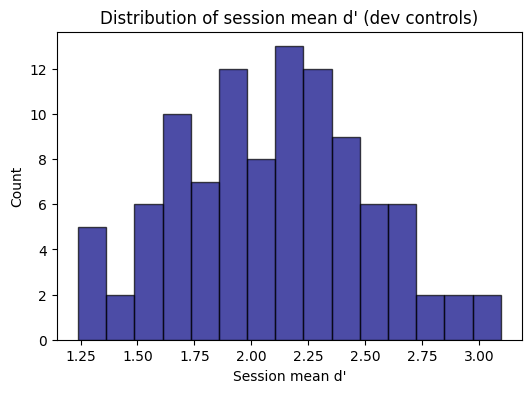

In [155]:
#plot a distribution curve line where the x axis is 0 1 2 3 4 3 2 1 0. plot the averaged_dprime values as a scatter points along the curve

import matplotlib.pyplot as plt

dprimes = passing_beh_devs_df['averaged_dprime'].dropna().values

plt.figure(figsize=(6, 4))
plt.hist(dprimes, bins=15, color='navy', alpha=0.7, edgecolor='black')
plt.xlabel("Session mean d'")
plt.ylabel("Count")
plt.title("Distribution of session mean d' (dev controls)")

Text(0.5, 1.0, "Distribution of mean cross modal d' for 102 passing behavior production sessions")

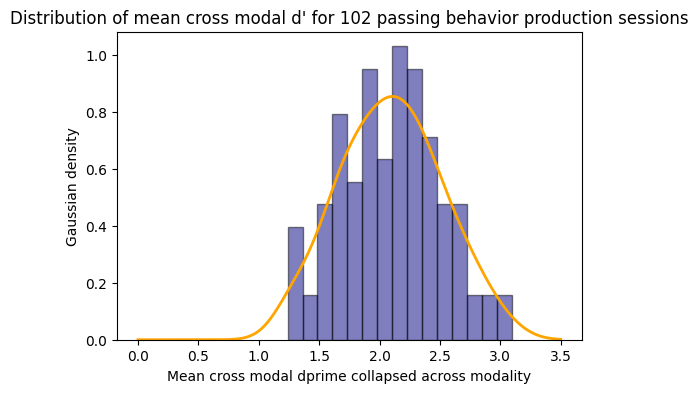

In [24]:
# Plot a histogram and a line that follows the distribution of averaged d' values for dev controls
#mess with kde

import matplotlib.pyplot as plt
import numpy as np

dprimes = passing_beh_devs_df['averaged_dprime'].dropna().values

plt.figure(figsize=(6, 4))
# Plot histogram
counts, bins, _ = plt.hist(dprimes, bins=15, color='navy', alpha=0.5, edgecolor='black', density=True, label="Histogram")

# Plot a KDE (smoothed line) over the histogram
from scipy.stats import gaussian_kde
kde = gaussian_kde(dprimes)
x_dense = np.linspace((0), 3.5, 300)
plt.plot(x_dense, kde(x_dense), color='orange', lw=2, label="KDE fit")

plt.xlabel("Mean cross modal dprime collapsed across modality")
plt.ylabel("Gaussian density")
plt.title("Distribution of mean cross modal d' for 102 passing behavior production sessions")

In [25]:
# plot muscimol scatter points (also averaged cross modal dprimes)
orb_task_only_controls = [
'728053_2024-11-18', '728053_2024-11-20',
'774470_2025-07-29','782106_2025-07-07',
'782106_2025-07-14','767405_2025-05-28','767405_2025-05-19'
]

In [26]:
#loop through session performance tables

# Loop through these sessions and print their performance tables

orb_task_only_controls = [
    '728053_2024-11-18', '728053_2024-11-20',
    '774470_2025-07-29', '782106_2025-07-07',
    '782106_2025-07-14', '767405_2025-05-28', '767405_2025-05-19'
]

for session_id in orb_task_only_controls:
    session = npc_sessions.Session(session_id)
    print(f"Session: {session_id}")
    print(session.performance[:])
    

Session: 728053_2024-11-18
     start_time    stop_time  block_index  n_trials  n_responses  n_hits  \
id                                                                         
0      4.870766   603.922216            0        92           38      25   
1    605.173264  1210.980256            1        88           34      22   
2   1211.080371  1818.722168            2        92           36      24   
3   1818.738884  2426.480802            3        92           37      23   
4   2427.281444  3029.768988            4        92           43      25   
5   3029.935800  3626.051366            5        91           33      24   

    n_contingent_rewards  hit_rate  false_alarm_rate  catch_response_rate  \
id                                                                          
0                     25  1.000000          0.220339             4.750000   
1                     22  0.956522          0.218182             3.400000   
2                     24  1.000000          0.206897    

     start_time    stop_time  block_index  n_trials  n_responses  n_hits  \
id                                                                         
0      3.519674   604.674437            0        83           45      23   
1    605.008091  1208.681392            1        91           31      21   
2   1210.249341  1816.791694            2        88           43      25   
3   1817.909239  2426.953738            3        93           28      23   
4   2427.020446  3033.729610            4        93           29      19   
5   3034.230023  3636.352038            5        89           23      18   

    n_contingent_rewards  hit_rate  false_alarm_rate  catch_response_rate  \
id                                                                          
0                     23  0.958333          0.392857            15.000000   
1                     21  0.875000          0.181818             2.583333   
2                     25  1.000000          0.327273             5.375000   
3     

     start_time    stop_time  block_index  n_trials  n_responses  n_hits  \
id                                                                         
0      3.119324   605.372255            0        90           36      25   
1    606.089496  1210.377365            1        94           26      22   
2   1213.346506  1817.917968            2        90           29      21   
3   1818.201569  2424.541039            3        87           33      24   
4   2425.224945  3033.365853            4        90           38      24   
5   3033.399213  3632.249060            5        89           33      24   

    n_contingent_rewards  hit_rate  false_alarm_rate  catch_response_rate  \
id                                                                          
0                     25  1.000000          0.183333             7.200000   
1                     22  0.956522          0.071429             1.733333   
2                     21  0.954545          0.133333             3.625000   
3     

Session: 782106_2025-07-14
     start_time    stop_time  block_index  n_trials  n_responses  n_hits  \
id                                                                         
0      6.238586   608.091190            0        92           36      25   
1    612.027820  1216.182189            1        88           28      23   
2   1216.949497  1824.990438            2        89           28      24   
3   1825.457493  2431.530134            3        88           23      10   
4   2432.380818  3044.391713            4        78           28      21   
5   3045.309092  3645.510169            5        88           29      21   

    n_contingent_rewards  hit_rate  false_alarm_rate  catch_response_rate  \
id                                                                          
0                     25  1.000000          0.183333             5.142857   
1                     23  0.958333          0.098039             2.153846   
2                     24  0.960000          0.050000    

In [27]:
# ...existing code...
crossmod_dprimes = []
for session_id in orb_task_only_controls:
    session = npc_sessions.Session(session_id)
    perf = session.performance[:]
    # Only use the main 'cross_modality_dprime' column (not _aud_blocks/_vis_blocks)
    if 'cross_modality_dprime' in perf.columns:
        # Get the first row (or all rows if needed)
        vals = perf['cross_modality_dprime'].dropna().astype(str).tolist()
        dprimes = []
        for v in vals:
            dprimes.extend([float(x) for x in v.split(';') if x.strip() != ''])
        # If there are more than 6, just take the first 6 (or all if 6 or fewer)
        dprimes = dprimes[:6]
    else:
        dprimes = []
    crossmod_dprimes.append({'session_id': session_id, 'cross_modality_dprimes': dprimes})

crossmod_dprime_df = pd.DataFrame(crossmod_dprimes)
print(crossmod_dprime_df)


          session_id                             cross_modality_dprimes
0  728053_2024-11-18  [3.335300476176423, 1.7116753065097288, 2.5612...
1  728053_2024-11-20  [3.0732675211951777, 2.878455365274302, 2.7823...
2  774470_2025-07-29  [2.3653043969019465, 1.9150590541623949, 3.056...
3  782106_2025-07-07  [2.307096013767622, 2.963794826774948, 2.07594...
4  782106_2025-07-14  [2.895370144204737, 2.618810955141121, 3.03223...
5  767405_2025-05-28  [0.951928100381775, 0.9920993118225493, 2.7348...
6  767405_2025-05-19  [2.25377067224178, 2.670474132481089, 3.343904...


In [28]:
[3.335300476176423, 1.7116753065097288, 2.5612346444094287, 1.7316643961222453, 2.4390693770393903, 1.9498873960414362]

[3.335300476176423,
 1.7116753065097288,
 2.5612346444094287,
 1.7316643961222453,
 2.4390693770393903,
 1.9498873960414362]

In [29]:
#make a new col in this crossmod_dprime_df and call it averaged_dprime and find the mean of the corss_modality_dprimes for each session and input the mean value into the new averaged col

# ...existing code...
crossmod_dprime_df['averaged_dprime'] = crossmod_dprime_df['cross_modality_dprimes'].apply(
    lambda x: np.mean(x) 
)

print(crossmod_dprime_df)

          session_id                             cross_modality_dprimes  \
0  728053_2024-11-18  [3.335300476176423, 1.7116753065097288, 2.5612...   
1  728053_2024-11-20  [3.0732675211951777, 2.878455365274302, 2.7823...   
2  774470_2025-07-29  [2.3653043969019465, 1.9150590541623949, 3.056...   
3  782106_2025-07-07  [2.307096013767622, 2.963794826774948, 2.07594...   
4  782106_2025-07-14  [2.895370144204737, 2.618810955141121, 3.03223...   
5  767405_2025-05-28  [0.951928100381775, 0.9920993118225493, 2.7348...   
6  767405_2025-05-19  [2.25377067224178, 2.670474132481089, 3.343904...   

   averaged_dprime  
0         2.288139  
1         2.889461  
2         2.194917  
3         2.605940  
4         2.064560  
5         2.101918  
6         2.837569  


In [30]:
#plot crossmod_dprime_df['averaged_dprime'] as scatter point on gaussian plot

## Controls: ORB points on gaussian curve 

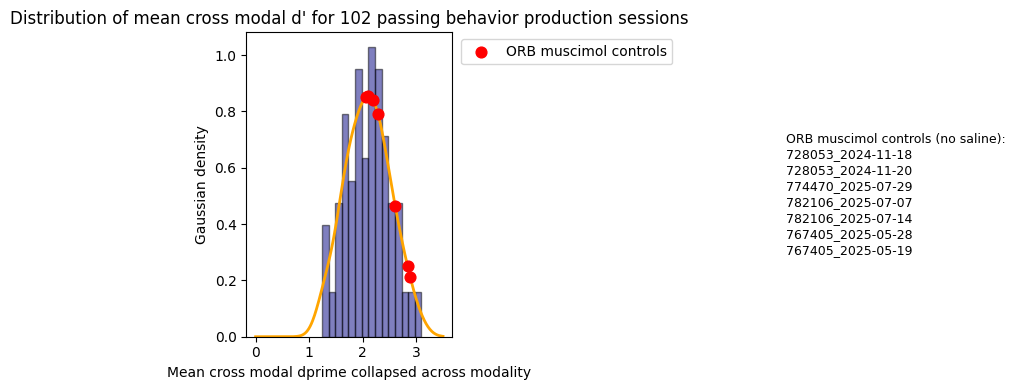

In [40]:
# ...existing code...
dprimes = passing_beh_devs_df['averaged_dprime'].dropna().values

plt.figure(figsize=(6, 4))
# Plot histogram
counts, bins, _ = plt.hist(dprimes, bins=15, color='navy', alpha=0.5, edgecolor='black', density=True)

# Plot a KDE (smoothed line) over the histogram
from scipy.stats import gaussian_kde
kde = gaussian_kde(dprimes)
x_dense = np.linspace(0, 3.5, 300)
plt.plot(x_dense, kde(x_dense), color='orange', lw=2)

# Overlay crossmod_dprime_df['averaged_dprime'] as scatter points
scatter_y = kde(crossmod_dprime_df['averaged_dprime'])
plt.scatter(crossmod_dprime_df['averaged_dprime'], scatter_y, color='red', s=60, zorder=3, label="ORB muscimol controls")

plt.xlabel("Mean cross modal dprime collapsed across modality")
plt.ylabel("Gaussian density")
plt.title("Distribution of mean cross modal d' for 102 passing behavior production sessions")
plt.legend()
import matplotlib.patches as mpatches
handles, labels = plt.gca().get_legend_handles_labels()
orb_sessions = [
    '728053_2024-11-18', '728053_2024-11-20',
    '774470_2025-07-29', '782106_2025-07-07',
    '782106_2025-07-14', '767405_2025-05-28', '767405_2025-05-19'
]
session_text = "ORB muscimol controls (no saline):\n" + "\n".join(orb_sessions)
# Place legend and session list to the right
plt.legend(handles, labels, loc='upper left', bbox_to_anchor=(1.01, 1))
plt.gcf().text(1.01, 0.5, session_text, fontsize=9, va='center', ha='left', linespacing=1.3)

plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.show()

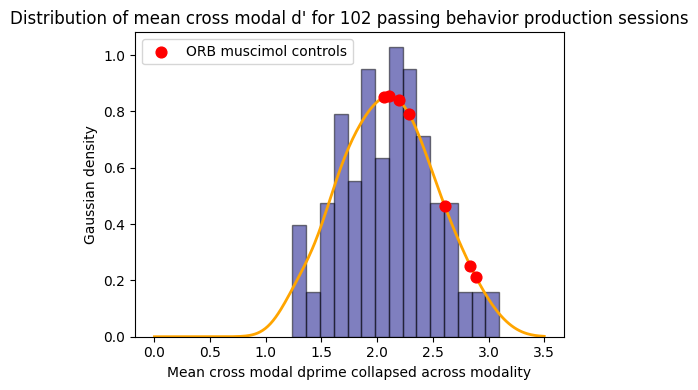

In [41]:
# ...existing code...
dprimes = passing_beh_devs_df['averaged_dprime'].dropna().values

plt.figure(figsize=(6, 4))
# Plot histogram
counts, bins, _ = plt.hist(dprimes, bins=15, color='navy', alpha=0.5, edgecolor='black', density=True)

# Plot a KDE (smoothed line) over the histogram
from scipy.stats import gaussian_kde
kde = gaussian_kde(dprimes)
x_dense = np.linspace(0, 3.5, 300)
plt.plot(x_dense, kde(x_dense), color='orange', lw=2)

# Overlay crossmod_dprime_df['averaged_dprime'] as scatter points
scatter_y = kde(crossmod_dprime_df['averaged_dprime'])
plt.scatter(crossmod_dprime_df['averaged_dprime'], scatter_y, color='red', s=60, zorder=3, label="ORB muscimol controls")

plt.xlabel("Mean cross modal dprime collapsed across modality")
plt.ylabel("Gaussian density")
plt.title("Distribution of mean cross modal d' for 102 passing behavior production sessions")
plt.legend()

plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.show()
# ...existing code...

C:\Users\vayle.lafehr\AppData\Local\Temp\ipykernel_37224\3609984097.py:22: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', len(orb_task_only_controls))


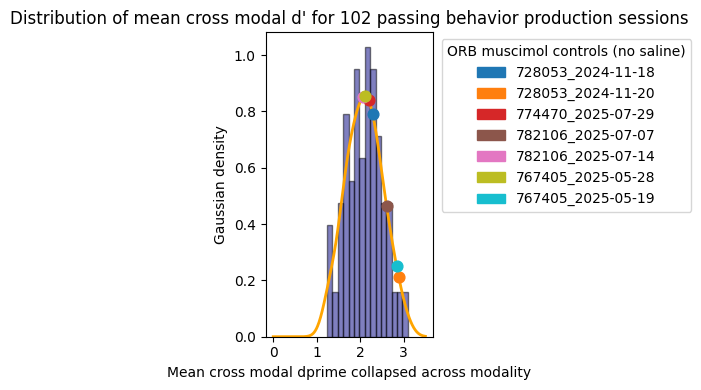

In [42]:
# ...existing code...
import matplotlib.patches as mpatches

dprimes = passing_beh_devs_df['averaged_dprime'].dropna().values

plt.figure(figsize=(6, 4))
# Plot histogram
counts, bins, _ = plt.hist(dprimes, bins=15, color='navy', alpha=0.5, edgecolor='black', density=True)

# Plot a KDE (smoothed line) over the histogram
from scipy.stats import gaussian_kde
kde = gaussian_kde(dprimes)
x_dense = np.linspace(0, 3.5, 300)
plt.plot(x_dense, kde(x_dense), color='orange', lw=2)

# Assign a unique color to each session
orb_task_only_controls = [
    '728053_2024-11-18', '728053_2024-11-20',
    '774470_2025-07-29', '782106_2025-07-07',
    '782106_2025-07-14', '767405_2025-05-28', '767405_2025-05-19'
]
colors = plt.cm.get_cmap('tab10', len(orb_task_only_controls))
color_map = {sid: colors(i) for i, sid in enumerate(orb_task_only_controls)}

# Plot each session's point with its color
for i, row in crossmod_dprime_df.iterrows():
    sid = row['session_id']
    x = row['averaged_dprime']
    y = kde([x])[0]
    plt.scatter(x, y, color=color_map[sid], s=60, zorder=3)

# Build legend handles for each session
handles = [mpatches.Patch(color=color_map[sid], label=sid) for sid in orb_task_only_controls]
plt.legend(handles=handles, title="ORB muscimol controls (no saline)", loc='upper left', bbox_to_anchor=(1.01, 1))

plt.xlabel("Mean cross modal dprime collapsed across modality")
plt.ylabel("Gaussian density")
plt.title("Distribution of mean cross modal d' for 102 passing behavior production sessions")

plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.show()

## Controls: STR points on gaussian curve

In [43]:
dms_task_only_controls = [
'717473_2024-09-16', '717473_2024-09-18', '759435_2025-05-22', '759435_2025-05-29'
]

In [44]:
dms_crossmod_dprimes = []
for session_id in dms_task_only_controls:
    session = npc_sessions.Session(session_id)
    perf = session.performance[:]
    # Only use the main 'cross_modality_dprime' column (not _aud_blocks/_vis_blocks)
    if 'cross_modality_dprime' in perf.columns:
        # Get the first row (or all rows if needed)
        vals = perf['cross_modality_dprime'].dropna().astype(str).tolist()
        dprimes = []
        for v in vals:
            dprimes.extend([float(x) for x in v.split(';') if x.strip() != ''])
        # If there are more than 6, just take the first 6 (or all if 6 or fewer)
        dprimes = dprimes[:6]
    else:
        dprimes = []
    dms_crossmod_dprimes.append({'session_id': session_id, 'cross_modality_dprimes': dprimes})

dms_crossmod_dprime_df = pd.DataFrame(dms_crossmod_dprimes)
print(dms_crossmod_dprime_df)

          session_id                             cross_modality_dprimes
0  717473_2024-09-16  [3.2712057208483616, 2.1280780150807233, 1.824...
1  717473_2024-09-18  [2.3551243409549656, 3.050376604063307, 3.3705...
2  759435_2025-05-22  [2.7661919430213118, 1.4748880350007985, 4.013...
3  759435_2025-05-29  [0.1470085688794867, 3.3315315651479986, -0.97...


In [45]:
dms_crossmod_dprime_df['averaged_dprime'] = dms_crossmod_dprime_df['cross_modality_dprimes'].apply(
    lambda x: np.mean(x) 
)

print(dms_crossmod_dprime_df)

          session_id                             cross_modality_dprimes  \
0  717473_2024-09-16  [3.2712057208483616, 2.1280780150807233, 1.824...   
1  717473_2024-09-18  [2.3551243409549656, 3.050376604063307, 3.3705...   
2  759435_2025-05-22  [2.7661919430213118, 1.4748880350007985, 4.013...   
3  759435_2025-05-29  [0.1470085688794867, 3.3315315651479986, -0.97...   

   averaged_dprime  
0         2.392104  
1         2.405261  
2         2.493744  
3         1.163236  


Text(1.01, 0.5, 'DMS muscimol controls (no saline):\n717473_2024-09-16\n717473_2024-09-18\n762125_2025-05-19\n759435_2025-05-22\n759435_2025-05-29')

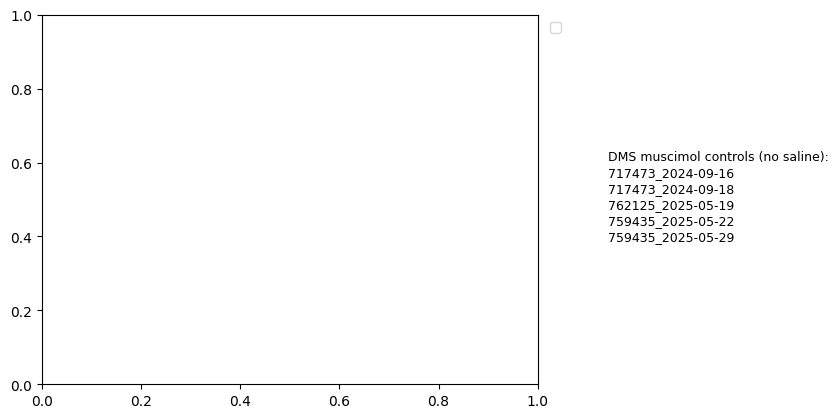

In [46]:
import matplotlib.patches as mpatches
handles, labels = plt.gca().get_legend_handles_labels()

dms_task_only_controls = [
'717473_2024-09-16', '717473_2024-09-18','762125_2025-05-19', '759435_2025-05-22', '759435_2025-05-29'
]
session_text = "DMS muscimol controls (no saline):\n" + "\n".join(dms_task_only_controls)
# Place legend and session list to the right
plt.legend(handles, labels, loc='upper left', bbox_to_anchor=(1.01, 1))
plt.gcf().text(1.01, 0.5, session_text, fontsize=9, va='center', ha='left', linespacing=1.3)

C:\Users\vayle.lafehr\AppData\Local\Temp\ipykernel_37224\3082111748.py:12: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', len(dms_task_only_controls))


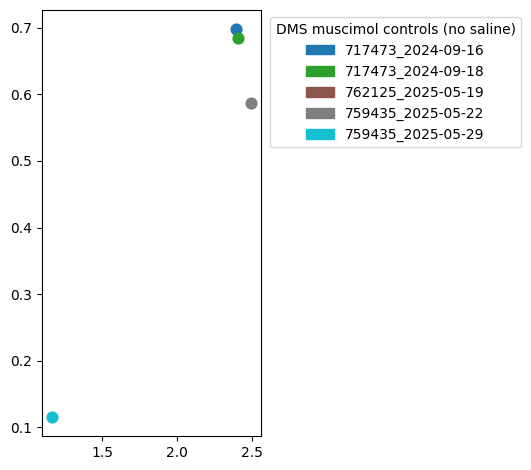

In [47]:
import matplotlib.patches as mpatches

# Assume you have a DataFrame `dms_crossmod_dprime_df` with columns 'session_id' and 'averaged_dprime'
dms_task_only_controls = [
    '717473_2024-09-16', '717473_2024-09-18', '762125_2025-05-19', '759435_2025-05-22', '759435_2025-05-29'
]

# Assign a unique color to each session
import matplotlib.pyplot as plt
import numpy as np

colors = plt.cm.get_cmap('tab10', len(dms_task_only_controls))
color_map = {sid: colors(i) for i, sid in enumerate(dms_task_only_controls)}

# Plot the KDE/histogram as before (assume kde is already defined)
# ...existing code for histogram and kde...

# Plot each session's point with its color
for i, row in dms_crossmod_dprime_df.iterrows():
    sid = row['session_id']
    x = row['averaged_dprime']
    y = kde([x])[0]
    plt.scatter(x, y, color=color_map[sid], s=60, zorder=3)

# Build legend handles for each session
handles = [mpatches.Patch(color=color_map[sid], label=sid) for sid in dms_task_only_controls]
plt.legend(handles=handles, title="DMS muscimol controls (no saline)", loc='upper left', bbox_to_anchor=(1.01, 1))

plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.show()

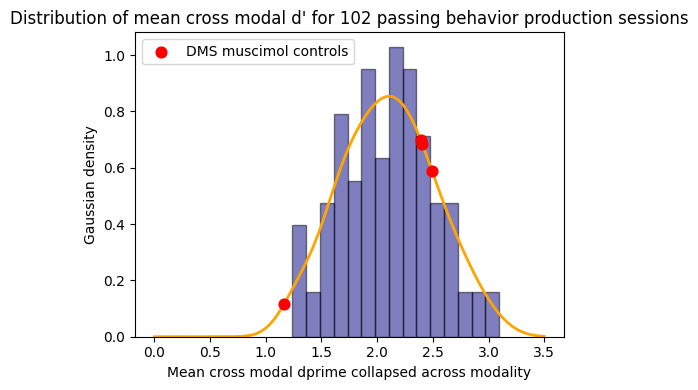

In [48]:
dprimes = passing_beh_devs_df['averaged_dprime'].dropna().values

plt.figure(figsize=(6, 4))
# Plot histogram
counts, bins, _ = plt.hist(dprimes, bins=15, color='navy', alpha=0.5, edgecolor='black', density=True)

# Plot a KDE (smoothed line) over the histogram
from scipy.stats import gaussian_kde
kde = gaussian_kde(dprimes)
x_dense = np.linspace(0, 3.5, 300)
plt.plot(x_dense, kde(x_dense), color='orange', lw=2)

# Overlay crossmod_dprime_df['averaged_dprime'] as scatter points
scatter_y = kde(dms_crossmod_dprime_df['averaged_dprime'])
plt.scatter(dms_crossmod_dprime_df['averaged_dprime'], scatter_y, color='red', s=60, zorder=3, label="DMS muscimol controls")

plt.xlabel("Mean cross modal dprime collapsed across modality")
plt.ylabel("Gaussian density")
plt.title("Distribution of mean cross modal d' for 102 passing behavior production sessions")
plt.legend()

plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.show()


C:\Users\vayle.lafehr\AppData\Local\Temp\ipykernel_37224\2237297012.py:12: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', len(dms_task_only_controls))


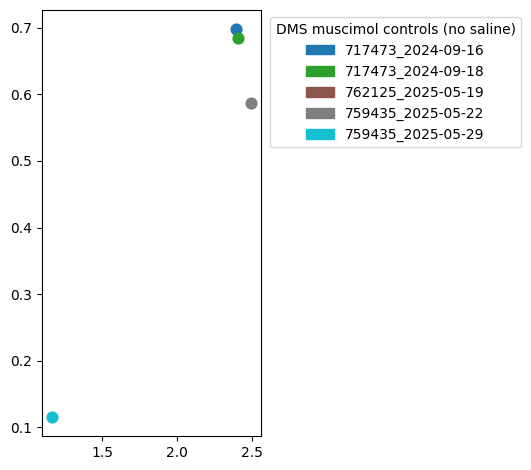

In [49]:
import matplotlib.patches as mpatches

# Assume you have a DataFrame `dms_crossmod_dprime_df` with columns 'session_id' and 'averaged_dprime'
dms_task_only_controls = [
    '717473_2024-09-16', '717473_2024-09-18', '762125_2025-05-19', '759435_2025-05-22', '759435_2025-05-29'
]

# Assign a unique color to each session
import matplotlib.pyplot as plt
import numpy as np

colors = plt.cm.get_cmap('tab10', len(dms_task_only_controls))
color_map = {sid: colors(i) for i, sid in enumerate(dms_task_only_controls)}

# Plot the KDE/histogram as before (assume kde is already defined)
# ...existing code for histogram and kde...

# Plot each session's point with its color
for i, row in dms_crossmod_dprime_df.iterrows():
    sid = row['session_id']
    x = row['averaged_dprime']
    y = kde([x])[0]
    plt.scatter(x, y, color=color_map[sid], s=60, zorder=3)

# Build legend handles for each session
handles = [mpatches.Patch(color=color_map[sid], label=sid) for sid in dms_task_only_controls]
plt.legend(handles=handles, title="DMS muscimol controls (no saline)", loc='upper left', bbox_to_anchor=(1.01, 1))

plt.tight_layout(rect=[0, 0, 0.85, 1])

C:\Users\vayle.lafehr\AppData\Local\Temp\ipykernel_37224\717325255.py:20: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', len(dms_task_only_controls))


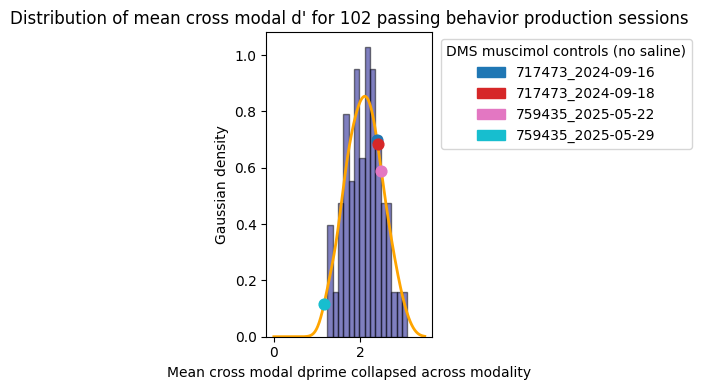

In [50]:
# ...existing code...
import matplotlib.patches as mpatches

dprimes = passing_beh_devs_df['averaged_dprime'].dropna().values

plt.figure(figsize=(6, 4))
# Plot histogram
counts, bins, _ = plt.hist(dprimes, bins=15, color='navy', alpha=0.5, edgecolor='black', density=True)

# Plot a KDE (smoothed line) over the histogram
from scipy.stats import gaussian_kde
kde = gaussian_kde(dprimes)
x_dense = np.linspace(0, 3.5, 300)
plt.plot(x_dense, kde(x_dense), color='orange', lw=2)

# Assign a unique color to each session
dms_task_only_controls = [
    '717473_2024-09-16', '717473_2024-09-18', '759435_2025-05-22', '759435_2025-05-29'
]
colors = plt.cm.get_cmap('tab10', len(dms_task_only_controls))
color_map = {sid: colors(i) for i, sid in enumerate(dms_task_only_controls)}

# Plot each session's point with its color
for i, row in dms_crossmod_dprime_df.iterrows():
    sid = row['session_id']
    x = row['averaged_dprime']
    y = kde([x])[0]
    plt.scatter(x, y, color=color_map[sid], s=60, zorder=3)

# Build legend handles for each session
handles = [mpatches.Patch(color=color_map[sid], label=sid) for sid in dms_task_only_controls]
plt.legend(handles=handles, title="DMS muscimol controls (no saline)", loc='upper left', bbox_to_anchor=(1.01, 1))

plt.xlabel("Mean cross modal dprime collapsed across modality")
plt.ylabel("Gaussian density")
plt.title("Distribution of mean cross modal d' for 102 passing behavior production sessions")

plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.show()
# ...existing

## Controls: SC points on a gaussian curve

In [51]:
sc_task_only_controls = [
'746138_2024-12-17','777661_2025-04-25', '777661_2025-05-08', '737412_2024-12-16', '737412_2024-12-18', 
]

In [52]:
sc_crossmod_dprimes = []
for session_id in sc_task_only_controls:
    session = npc_sessions.Session(session_id)
    perf = session.performance[:]
    # Only use the main 'cross_modality_dprime' column (not _aud_blocks/_vis_blocks)
    if 'cross_modality_dprime' in perf.columns:
        # Get the first row (or all rows if needed)
        vals = perf['cross_modality_dprime'].dropna().astype(str).tolist()
        dprimes = []
        for v in vals:
            dprimes.extend([float(x) for x in v.split(';') if x.strip() != ''])
        # If there are more than 6, just take the first 6 (or all if 6 or fewer)
        dprimes = dprimes[:6]
    else:
        dprimes = []
    sc_crossmod_dprimes.append({'session_id': session_id, 'cross_modality_dprimes': dprimes})

sc_crossmod_dprime_df = pd.DataFrame(sc_crossmod_dprimes)
print(sc_crossmod_dprime_df)

          session_id                             cross_modality_dprimes
0  746138_2024-12-17  [1.069412565599687, 1.5293483979237819, 1.6684...
1  777661_2025-04-25  [1.4783172929864457, 1.5227044259825002, 1.046...
2  777661_2025-05-08  [3.3889266467507593, 2.495218009945199, 2.8182...
3  737412_2024-12-16  [1.5500250973518215, 2.2301917245831193, 1.654...
4  737412_2024-12-18  [3.0132159616668455, 1.8573257429773193, 2.699...


In [53]:
sc_crossmod_dprime_df['averaged_dprime'] = sc_crossmod_dprime_df['cross_modality_dprimes'].apply(
    lambda x: np.mean(x) 
)

print(sc_crossmod_dprime_df)

          session_id                             cross_modality_dprimes  \
0  746138_2024-12-17  [1.069412565599687, 1.5293483979237819, 1.6684...   
1  777661_2025-04-25  [1.4783172929864457, 1.5227044259825002, 1.046...   
2  777661_2025-05-08  [3.3889266467507593, 2.495218009945199, 2.8182...   
3  737412_2024-12-16  [1.5500250973518215, 2.2301917245831193, 1.654...   
4  737412_2024-12-18  [3.0132159616668455, 1.8573257429773193, 2.699...   

   averaged_dprime  
0         1.855669  
1         1.719508  
2         2.789723  
3         2.154993  
4         2.369932  


Text(1.01, 0.5, 'SC muscimol controls (no saline):\n746138_2024-12-17\n777661_2025-04-25\n777661_2025-05-08\n737412_2024-12-16\n737412_2024-12-18')

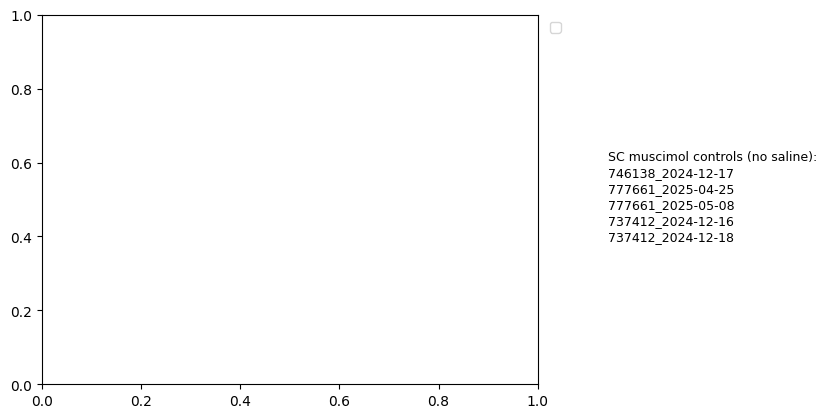

In [54]:
import matplotlib.patches as mpatches
handles, labels = plt.gca().get_legend_handles_labels()

sc_task_only_controls = [
'746138_2024-12-17','777661_2025-04-25', '777661_2025-05-08', '737412_2024-12-16', '737412_2024-12-18', 
]
session_text = "SC muscimol controls (no saline):\n" + "\n".join(sc_task_only_controls)
# Place legend and session list to the right
plt.legend(handles, labels, loc='upper left', bbox_to_anchor=(1.01, 1))
plt.gcf().text(1.01, 0.5, session_text, fontsize=9, va='center', ha='left', linespacing=1.3)

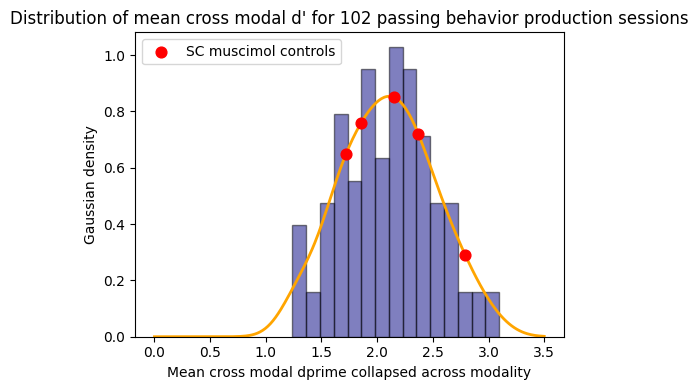

In [55]:
dprimes = passing_beh_devs_df['averaged_dprime'].dropna().values

plt.figure(figsize=(6, 4))
# Plot histogram
counts, bins, _ = plt.hist(dprimes, bins=15, color='navy', alpha=0.5, edgecolor='black', density=True)

# Plot a KDE (smoothed line) over the histogram
from scipy.stats import gaussian_kde
kde = gaussian_kde(dprimes)
x_dense = np.linspace(0, 3.5, 300)
plt.plot(x_dense, kde(x_dense), color='orange', lw=2)

# Overlay crossmod_dprime_df['averaged_dprime'] as scatter points
scatter_y = kde(sc_crossmod_dprime_df['averaged_dprime'])
plt.scatter(sc_crossmod_dprime_df['averaged_dprime'], scatter_y, color='red', s=60, zorder=3, label="SC muscimol controls")

plt.xlabel("Mean cross modal dprime collapsed across modality")
plt.ylabel("Gaussian density")
plt.title("Distribution of mean cross modal d' for 102 passing behavior production sessions")
plt.legend()

plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.show()

C:\Users\vayle.lafehr\AppData\Local\Temp\ipykernel_37224\1081714410.py:20: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', len(sc_task_only_controls))


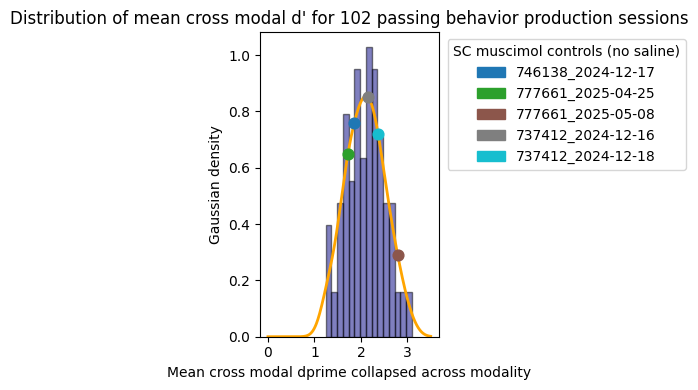

In [56]:
# ...existing code...
import matplotlib.patches as mpatches

dprimes = passing_beh_devs_df['averaged_dprime'].dropna().values

plt.figure(figsize=(6, 4))
# Plot histogram
counts, bins, _ = plt.hist(dprimes, bins=15, color='navy', alpha=0.5, edgecolor='black', density=True)

# Plot a KDE (smoothed line) over the histogram
from scipy.stats import gaussian_kde
kde = gaussian_kde(dprimes)
x_dense = np.linspace(0, 3.5, 300)
plt.plot(x_dense, kde(x_dense), color='orange', lw=2)

# Assign a unique color to each session
sc_task_only_controls = [
'746138_2024-12-17','777661_2025-04-25', '777661_2025-05-08', '737412_2024-12-16', '737412_2024-12-18', 
]
colors = plt.cm.get_cmap('tab10', len(sc_task_only_controls))
color_map = {sid: colors(i) for i, sid in enumerate(sc_task_only_controls)}

# Plot each session's point with its color
for i, row in sc_crossmod_dprime_df.iterrows():
    sid = row['session_id']
    x = row['averaged_dprime']
    y = kde([x])[0]
    plt.scatter(x, y, color=color_map[sid], s=60, zorder=3)

# Build legend handles for each session
handles = [mpatches.Patch(color=color_map[sid], label=sid) for sid in sc_task_only_controls]
plt.legend(handles=handles, title="SC muscimol controls (no saline)", loc='upper left', bbox_to_anchor=(1.01, 1))

plt.xlabel("Mean cross modal dprime collapsed across modality")
plt.ylabel("Gaussian density")
plt.title("Distribution of mean cross modal d' for 102 passing behavior production sessions")

plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.show()

## Controls: Saline comparison to production

In [57]:
saline_controls_all = [
    '780327_2025-04-10', '780327_2025-04-07', '780327_2025-04-03', '774916_2025-04-03', '774916_2025-03-31',
    '780327_2025-03-31','774916_2025-03-27', '774916_2025-03-24', '772657_2025-02-27','772657_2025-03-06','772657_2025-03-03', '772657_2025-02-24','739828_2025-02-20',
    '739828_2025-02-17','739828_2025-02-13', '739828_2025-02-10'
]

In [71]:
ORB_saline = [
    '774916_2025-03-31', '774916_2025-03-24','772657_2025-03-03', '772657_2025-02-24', '739828_2025-02-17', '739828_2025-02-10']

In [72]:
ORB_saline_crossmod_dprimes = []
for session_id in ORB_saline:
    session = npc_sessions.Session(session_id)
    perf = session.performance[:]
    # Only use the main 'cross_modality_dprime' column (not _aud_blocks/_vis_blocks)
    if 'cross_modality_dprime' in perf.columns:
        # Get the first row (or all rows if needed)
        vals = perf['cross_modality_dprime'].dropna().astype(str).tolist()
        dprimes = []
        for v in vals:
            dprimes.extend([float(x) for x in v.split(';') if x.strip() != ''])
        # If there are more than 6, just take the first 6 (or all if 6 or fewer)
        dprimes = dprimes[:6]
    else:
        dprimes = []
    ORB_saline_crossmod_dprimes.append({'session_id': session_id, 'cross_modality_dprimes': dprimes})

ORB_saline_crossmod_dprime_df = pd.DataFrame(ORB_saline_crossmod_dprimes)
print(ORB_saline_crossmod_dprime_df)

          session_id                             cross_modality_dprimes
0  774916_2025-03-31  [2.48447620992728, 2.162391695417703, 1.594599...
1  774916_2025-03-24  [2.652726201362843, 1.2262855585441286, 2.4251...
2  772657_2025-03-03  [2.4390693770393903, 2.100566622468929, 2.0536...
3  772657_2025-02-24  [2.670474132481089, 1.1503493803760079, 1.6794...
4  739828_2025-02-17  [2.670474132481089, 2.136006537659737, -0.2262...
5  739828_2025-02-10  [2.4498134998785996, 1.5883589012876849, 1.930...


In [73]:
ORB_saline_crossmod_dprime_df['averaged_dprime'] = ORB_saline_crossmod_dprime_df['cross_modality_dprimes'].apply(
    lambda x: np.mean(x) 
)

print(ORB_saline_crossmod_dprime_df)

          session_id                             cross_modality_dprimes  \
0  774916_2025-03-31  [2.48447620992728, 2.162391695417703, 1.594599...   
1  774916_2025-03-24  [2.652726201362843, 1.2262855585441286, 2.4251...   
2  772657_2025-03-03  [2.4390693770393903, 2.100566622468929, 2.0536...   
3  772657_2025-02-24  [2.670474132481089, 1.1503493803760079, 1.6794...   
4  739828_2025-02-17  [2.670474132481089, 2.136006537659737, -0.2262...   
5  739828_2025-02-10  [2.4498134998785996, 1.5883589012876849, 1.930...   

   averaged_dprime  
0         1.333663  
1         1.662720  
2         2.013281  
3         2.049127  
4         1.459038  
5         1.746980  


In [58]:
saline_crossmod_dprimes = []
for session_id in saline_controls_all:
    session = npc_sessions.Session(session_id)
    perf = session.performance[:]
    # Only use the main 'cross_modality_dprime' column (not _aud_blocks/_vis_blocks)
    if 'cross_modality_dprime' in perf.columns:
        # Get the first row (or all rows if needed)
        vals = perf['cross_modality_dprime'].dropna().astype(str).tolist()
        dprimes = []
        for v in vals:
            dprimes.extend([float(x) for x in v.split(';') if x.strip() != ''])
        # If there are more than 6, just take the first 6 (or all if 6 or fewer)
        dprimes = dprimes[:6]
    else:
        dprimes = []
    saline_crossmod_dprimes.append({'session_id': session_id, 'cross_modality_dprimes': dprimes})

saline_crossmod_dprime_df = pd.DataFrame(saline_crossmod_dprimes)
print(saline_crossmod_dprime_df)

           session_id                             cross_modality_dprimes
0   780327_2025-04-10  [2.8236825809434425, 3.9967981162414423, 1.583...
1   780327_2025-04-07  [2.1794102574868965, 1.9108766312989958, 1.777...
2   780327_2025-04-03  [2.6873889114115235, 2.5923073048250833, 3.698...
3   774916_2025-04-03  [2.1765444305832498, 0.08681076917077313, 1.52...
4   774916_2025-03-31  [2.48447620992728, 2.162391695417703, 1.594599...
5   780327_2025-03-31  [2.728238660827904, 1.7316643961222453, 2.1996...
6   774916_2025-03-27  [2.744391581091133, 0.15746725322911925, 2.230...
7   774916_2025-03-24  [2.652726201362843, 1.2262855585441286, 2.4251...
8   772657_2025-02-27  [3.6566903903396577, 2.425175821448251, 3.0568...
9   772657_2025-03-06  [2.16978123409602, 0.22144988872873717, 0.9757...
10  772657_2025-03-03  [2.4390693770393903, 2.100566622468929, 2.0536...
11  772657_2025-02-24  [2.670474132481089, 1.1503493803760079, 1.6794...
12  739828_2025-02-20  [1.7657390974473426, 2.29018

In [59]:
saline_crossmod_dprime_df['averaged_dprime'] = saline_crossmod_dprime_df['cross_modality_dprimes'].apply(
    lambda x: np.mean(x) 
)

print(saline_crossmod_dprime_df)

           session_id                             cross_modality_dprimes  \
0   780327_2025-04-10  [2.8236825809434425, 3.9967981162414423, 1.583...   
1   780327_2025-04-07  [2.1794102574868965, 1.9108766312989958, 1.777...   
2   780327_2025-04-03  [2.6873889114115235, 2.5923073048250833, 3.698...   
3   774916_2025-04-03  [2.1765444305832498, 0.08681076917077313, 1.52...   
4   774916_2025-03-31  [2.48447620992728, 2.162391695417703, 1.594599...   
5   780327_2025-03-31  [2.728238660827904, 1.7316643961222453, 2.1996...   
6   774916_2025-03-27  [2.744391581091133, 0.15746725322911925, 2.230...   
7   774916_2025-03-24  [2.652726201362843, 1.2262855585441286, 2.4251...   
8   772657_2025-02-27  [3.6566903903396577, 2.425175821448251, 3.0568...   
9   772657_2025-03-06  [2.16978123409602, 0.22144988872873717, 0.9757...   
10  772657_2025-03-03  [2.4390693770393903, 2.100566622468929, 2.0536...   
11  772657_2025-02-24  [2.670474132481089, 1.1503493803760079, 1.6794...   
12  739828_2

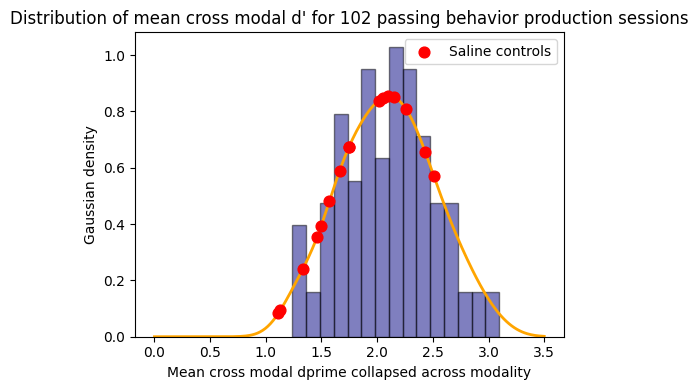

In [60]:
dprimes = passing_beh_devs_df['averaged_dprime'].dropna().values

plt.figure(figsize=(6, 4))
# Plot histogram
counts, bins, _ = plt.hist(dprimes, bins=15, color='navy', alpha=0.5, edgecolor='black', density=True)

# Plot a KDE (smoothed line) over the histogram
from scipy.stats import gaussian_kde
kde = gaussian_kde(dprimes)
x_dense = np.linspace(0, 3.5, 300)
plt.plot(x_dense, kde(x_dense), color='orange', lw=2)

# Overlay crossmod_dprime_df['averaged_dprime'] as scatter points
scatter_y = kde(saline_crossmod_dprime_df['averaged_dprime'])
plt.scatter(saline_crossmod_dprime_df['averaged_dprime'], scatter_y, color='red', s=60, zorder=3, label="Saline controls")

plt.xlabel("Mean cross modal dprime collapsed across modality")
plt.ylabel("Gaussian density")
plt.title("Distribution of mean cross modal d' for 102 passing behavior production sessions")
plt.legend()

plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.show()

C:\Users\vayle.lafehr\AppData\Local\Temp\ipykernel_37224\406270179.py:22: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', len(saline_controls_all))


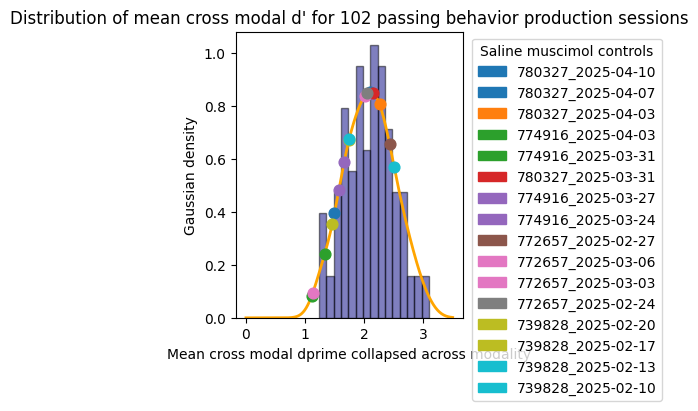

In [61]:
# ...existing code...
import matplotlib.patches as mpatches

dprimes = passing_beh_devs_df['averaged_dprime'].dropna().values

plt.figure(figsize=(6, 4))
# Plot histogram
counts, bins, _ = plt.hist(dprimes, bins=15, color='navy', alpha=0.5, edgecolor='black', density=True)

# Plot a KDE (smoothed line) over the histogram
from scipy.stats import gaussian_kde
kde = gaussian_kde(dprimes)
x_dense = np.linspace(0, 3.5, 300)
plt.plot(x_dense, kde(x_dense), color='orange', lw=2)

# Assign a unique color to each session
saline_controls_all = [
    '780327_2025-04-10', '780327_2025-04-07', '780327_2025-04-03', '774916_2025-04-03', '774916_2025-03-31',
    '780327_2025-03-31','774916_2025-03-27', '774916_2025-03-24', '772657_2025-02-27','772657_2025-03-06','772657_2025-03-03', '772657_2025-02-24','739828_2025-02-20',
    '739828_2025-02-17','739828_2025-02-13', '739828_2025-02-10'
]
colors = plt.cm.get_cmap('tab10', len(saline_controls_all))
color_map = {sid: colors(i) for i, sid in enumerate(saline_controls_all)}

# Plot each session's point with its color
for i, row in saline_crossmod_dprime_df.iterrows():
    sid = row['session_id']
    x = row['averaged_dprime']
    y = kde([x])[0]
    plt.scatter(x, y, color=color_map[sid], s=60, zorder=3)

# Build legend handles for each session
handles = [mpatches.Patch(color=color_map[sid], label=sid) for sid in saline_controls_all]
plt.legend(handles=handles, title="Saline muscimol controls", loc='upper left', bbox_to_anchor=(1.01, 1))

plt.xlabel("Mean cross modal dprime collapsed across modality")
plt.ylabel("Gaussian density")
plt.title("Distribution of mean cross modal d' for 102 passing behavior production sessions")

plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.show()

Text(1.01, 0.5, 'Saline controls:\n780327_2025-04-10\n780327_2025-04-07\n780327_2025-04-03\n774916_2025-04-03\n774916_2025-03-31\n780327_2025-03-31\n774916_2025-03-27\n774916_2025-03-24\n772657_2025-02-27\n772657_2025-03-06\n772657_2025-03-03\n772657_2025-02-24\n739828_2025-02-20\n739828_2025-02-17\n739828_2025-02-13\n739828_2025-02-10')

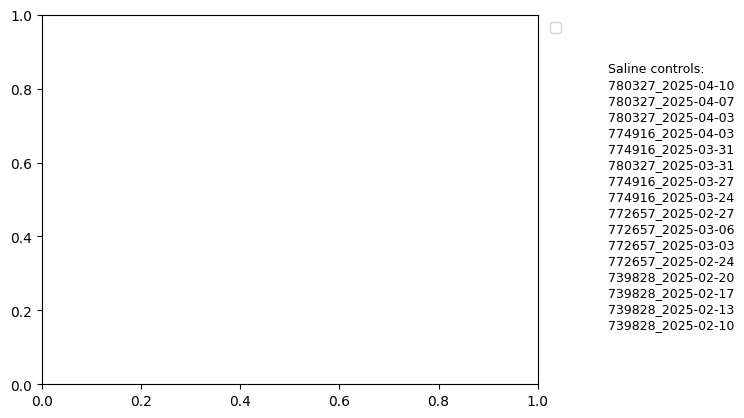

In [62]:
import matplotlib.patches as mpatches
handles, labels = plt.gca().get_legend_handles_labels()

saline_controls_all = [
    '780327_2025-04-10', '780327_2025-04-07', '780327_2025-04-03', '774916_2025-04-03', '774916_2025-03-31',
    '780327_2025-03-31','774916_2025-03-27', '774916_2025-03-24', '772657_2025-02-27','772657_2025-03-06','772657_2025-03-03', '772657_2025-02-24','739828_2025-02-20',
    '739828_2025-02-17','739828_2025-02-13', '739828_2025-02-10']
session_text = "Saline controls:\n" + "\n".join(saline_controls_all)
# Place legend and session list to the right
plt.legend(handles, labels, loc='upper left', bbox_to_anchor=(1.01, 1))
plt.gcf().text(1.01, 0.5, session_text, fontsize=9, va='center', ha='left', linespacing=1.3)

## cumulative density plot

In [63]:
def cumulative_hist(data, include_nan=False):
 
    data = np.array(data)
 
    if include_nan:
        total = len(data)
    else:
        total = np.sum(~np.isnan(data))
 
    data = data[~np.isnan(data)]
    sorted_unique = np.unique(data)
   
    hist = np.array([np.sum(data<=val) for val in sorted_unique])/total
    return sorted_unique, hist

In [64]:
all_non_saline = crossmod_dprime_df['averaged_dprime'].tolist() + dms_crossmod_dprime_df['averaged_dprime'].tolist() + sc_crossmod_dprime_df['averaged_dprime'].tolist() + crossmod_dprime_df['averaged_dprime'].dropna().tolist()

In [74]:
cumulative_hist(crossmod_dprime_df['averaged_dprime'])
cumulative_hist(passing_beh_devs_df['averaged_dprime'])
cumulative_hist(saline_crossmod_dprime_df['averaged_dprime'])
cumulative_hist(ORB_saline_crossmod_dprime_df['averaged_dprime'])
cumulative_hist(dms_crossmod_dprime_df['averaged_dprime'])
cumulative_hist(sc_crossmod_dprime_df['averaged_dprime'])
cumulative_hist(all_non_saline)

(array([1.16323611, 1.71950821, 1.85566881, 2.06456018, 2.10191751,
        2.15499276, 2.1949175 , 2.2881386 , 2.36993175, 2.39210368,
        2.40526118, 2.49374439, 2.60593973, 2.78972325, 2.83756908,
        2.88946061]),
 array([0.04347826, 0.08695652, 0.13043478, 0.2173913 , 0.30434783,
        0.34782609, 0.43478261, 0.52173913, 0.56521739, 0.60869565,
        0.65217391, 0.69565217, 0.7826087 , 0.82608696, 0.91304348,
        1.        ]))

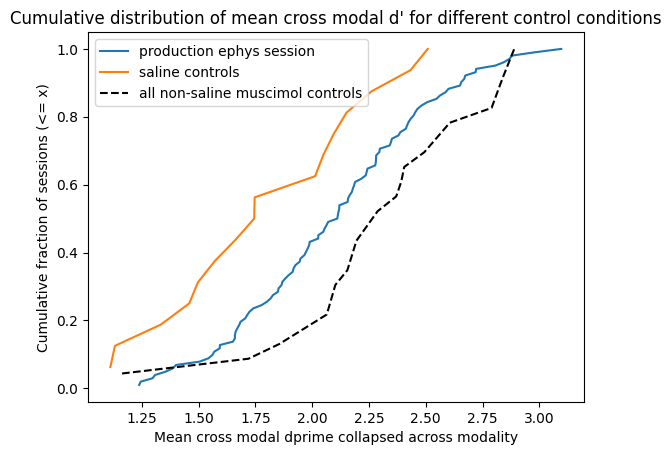

In [66]:
# plt.plot(*cumulative_hist(crossmod_dprime_df['averaged_dprime']), label='orbitofrontal muscimol controls')
plt.plot(*cumulative_hist(passing_beh_devs_df['averaged_dprime']), label='production ephys session')
plt.plot(*cumulative_hist(saline_crossmod_dprime_df['averaged_dprime']), label='saline controls')
# plt.plot(*cumulative_hist(dms_crossmod_dprime_df['averaged_dprime']), label='dms muscimol controls')
# plt.plot(*cumulative_hist(sc_crossmod_dprime_df['averaged_dprime']), label='sc muscimol controls')
plt.plot(*cumulative_hist(all_non_saline), label='all non-saline muscimol controls', linestyle='--', color='black')
plt.title("Cumulative distribution of mean cross modal d' for different control conditions")
plt.xlabel("Mean cross modal dprime collapsed across modality")
plt.ylabel("Cumulative fraction of sessions (<= x)")
plt.legend()


In [67]:
all_non_saline = crossmod_dprime_df['averaged_dprime'].tolist() + dms_crossmod_dprime_df['averaged_dprime'].tolist() + sc_crossmod_dprime_df['averaged_dprime'].tolist() + crossmod_dprime_df['averaged_dprime'].dropna().tolist()

In [75]:
cumulative_hist(crossmod_dprime_df['averaged_dprime'])
cumulative_hist(passing_beh_devs_df['averaged_dprime'])
cumulative_hist(ORB_saline_crossmod_dprime_df['averaged_dprime'])
cumulative_hist(dms_crossmod_dprime_df['averaged_dprime'])
cumulative_hist(sc_crossmod_dprime_df['averaged_dprime'])
cumulative_hist(all_non_saline)

(array([1.16323611, 1.71950821, 1.85566881, 2.06456018, 2.10191751,
        2.15499276, 2.1949175 , 2.2881386 , 2.36993175, 2.39210368,
        2.40526118, 2.49374439, 2.60593973, 2.78972325, 2.83756908,
        2.88946061]),
 array([0.04347826, 0.08695652, 0.13043478, 0.2173913 , 0.30434783,
        0.34782609, 0.43478261, 0.52173913, 0.56521739, 0.60869565,
        0.65217391, 0.69565217, 0.7826087 , 0.82608696, 0.91304348,
        1.        ]))

In [69]:
import matplotlib.pyplot as plt

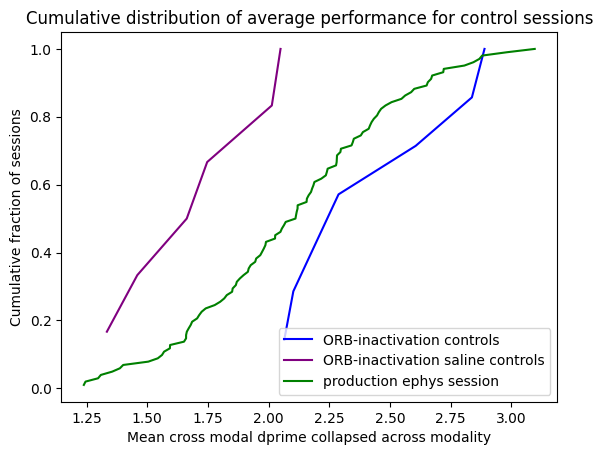

In [79]:
# ORB cum density plot
plt.plot(*cumulative_hist(crossmod_dprime_df['averaged_dprime']), label='ORB-inactivation controls', color='blue')
plt.plot(*cumulative_hist(ORB_saline_crossmod_dprime_df['averaged_dprime']), label='ORB-inactivation saline controls', color='purple')
plt.plot(*cumulative_hist(passing_beh_devs_df['averaged_dprime']), label='production ephys session', color='green')
# plt.plot(*cumulative_hist(ORB_saline_crossmod_dprime_df['averaged_dprime']), label='ORB saline controls')
# plt.plot(*cumulative_hist(dms_crossmod_dprime_df['averaged_dprime']), label='dms inactivation controls')
# plt.plot(*cumulative_hist(sc_crossmod_dprime_df['averaged_dprime']), label='sc inactivation controls')
# plt.plot(*cumulative_hist(ORB_no_saline), label='ORB no saline controls', linestyle='--', color='black')
plt.title("Cumulative distribution of average performance for control sessions")
plt.xlabel("Mean cross modal dprime collapsed across modality")
plt.ylabel("Cumulative fraction of sessions")
plt.legend()


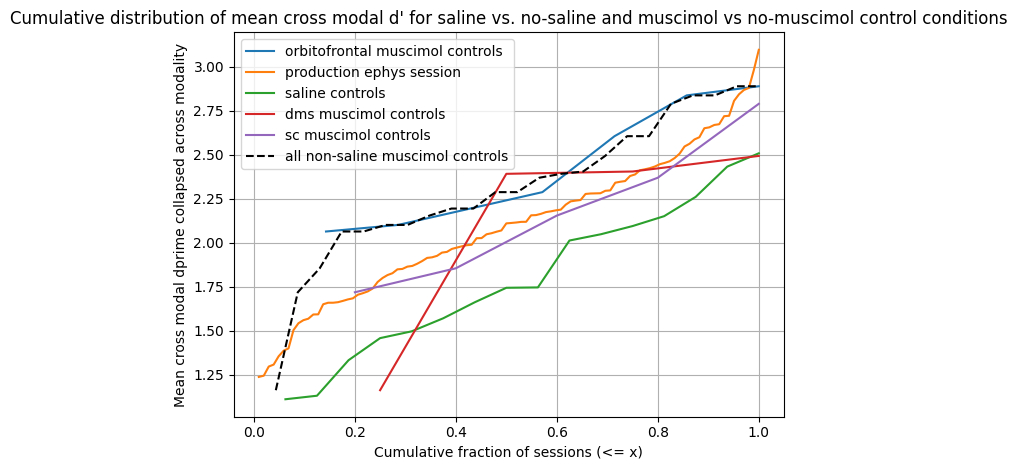

In [195]:
plt.plot(*cumulative_hist(crossmod_dprime_df['averaged_dprime'])[::-1], label='orbitofrontal muscimol controls')
plt.plot(*cumulative_hist(passing_beh_devs_df['averaged_dprime'])[::-1], label='production ephys session')
plt.plot(*cumulative_hist(saline_crossmod_dprime_df['averaged_dprime'])[::-1], label='saline controls')
plt.plot(*cumulative_hist(dms_crossmod_dprime_df['averaged_dprime'])[::-1], label='dms muscimol controls')
plt.plot(*cumulative_hist(sc_crossmod_dprime_df['averaged_dprime'])[::-1], label='sc muscimol controls')
plt.plot(*cumulative_hist(all_non_saline)[::-1], label='all non-saline muscimol controls', linestyle='--', color='black')

plt.title("Cumulative distribution of mean cross modal d' for saline vs. no-saline and muscimol vs no-muscimol control conditions")
plt.ylabel("Mean cross modal dprime collapsed across modality") 
plt.xlabel("Cumulative fraction of sessions (<= x)")           
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Response Dynamics (Sam's code)


In [ ]:
muscimol_data_orbm = []

def extract_base_id(session_id):
    return "_".join(session_id.split("_")[:-1])

#def(mouse, perturbation or control)
session_ids = ['824636_2026-01-21','807743_2025-11-03','807743_2025-11-04', '807743_2025-11-10', '807743_2025-11-11','813582_2025-12-08','813582_2025-12-09','813582_2025-12-15','813582_2025-12-16', '824636_2026-01-12', '824636_2026-01-13', '824636_2026-01-20']
control = ['807743_2025-11-03', '807743_2025-11-10', '813582_2025-12-08', '813582_2025-12-15', '824636_2026-01-12', '824636_2026-01-21']
perturbation = ['807743_2025-11-04', '807743_2025-11-11', '813582_2025-12-09', '813582_2025-12-16', '824636_2026-01-13', '824636_2026-01-20']

vis_first_perturbations = []
aud_first_perturbations=[]
# quiescent_violations = [47, 42, 44, 79, 87, 209, 40, 66, 36, 88, 37, 74, 32, 82, 7, 21, 62, 47, 22, 34, 20, 56]


for i, session_id in enumerate(session_ids):
    session = npc_sessions.Session(session_id)
   
    
#vis nontarget in vis context
    vis_nontarget_vis_context = session.trials[:].query(
    "rewarded_modality == 'vis' & is_response == True & is_vis_nontarget == True")
    all_vis_nontargets_vis_context = session.trials[:].query(
    "rewarded_modality == 'vis' & is_vis_nontarget == True")
    vis_nontarget_vis_context_responses = (len(vis_nontarget_vis_context)) / (len(all_vis_nontargets_vis_context))

#aud nontarget in vis context
    aud_nontarget_vis_context = session.trials[:].query(
    "rewarded_modality == 'vis' & is_aud_nontarget == True & is_response == True")
    all_aud_nontargets_vis_context = session.trials[:].query(
    "rewarded_modality == 'vis' & is_aud_nontarget == True")
    aud_nontarget_vis_context_responses = (len(aud_nontarget_vis_context)) / (len(all_aud_nontargets_vis_context))

# vis nontarget in aud context
    vis_nontarget_aud_context = session.trials[:].query(
    "rewarded_modality == 'aud' & is_response == True & is_vis_nontarget == True")
    all_vis_nontargets_aud_context = session.trials[:].query(
    "rewarded_modality == 'aud' & is_vis_nontarget == True")
    vis_nontarget_aud_context_responses = (len(vis_nontarget_aud_context)) / (len(all_vis_nontargets_aud_context))

#aud nontarget in aud context
    aud_nontarget_aud_context = session.trials[:].query(
    "rewarded_modality == 'aud' & is_aud_nontarget == True & is_response == True")
    all_aud_nontargets_aud_context = session.trials[:].query(
    "rewarded_modality == 'aud' & is_aud_nontarget == True")
    aud_nontarget_aud_context_responses = (len(aud_nontarget_aud_context)) / (len(all_aud_nontargets_aud_context))

#aud target in aud context
    aud_target_responses_in_aud_context = session.trials[:].query(
    "is_response == True & is_aud_target == True & rewarded_modality == 'aud'")
    all_aud_targets_aud_context = session.trials[:].query(
    "is_aud_target == True & rewarded_modality == 'aud'")
    auditory_target_in_auditory_context = (len(aud_target_responses_in_aud_context)/(len(all_aud_targets_aud_context)))

#vis target in vis context
    vis_rewarded_responses_in_vis_context = session.trials[:].query(
    "is_response == True & is_vis_target == True & rewarded_modality == 'vis'")
    all_vis_rewarded_responses_in_vis_context = session.trials[:].query(
    "is_vis_target == True & rewarded_modality == 'vis'")
    visual_target_in_visual_context = (len(vis_rewarded_responses_in_vis_context)/(len(all_vis_rewarded_responses_in_vis_context)))

#aud target in vis context
    aud_rewarded_responses_in_vis_context = session.trials[:].query(
    "is_response == True & is_aud_target == True & rewarded_modality == 'vis'")
    all_rewarded_responses_in_vis_context = session.trials[:].query(
    "is_aud_target == True & rewarded_modality == 'vis'")
    auditory_target_in_visual_context = (len(aud_rewarded_responses_in_vis_context)/(len(all_rewarded_responses_in_vis_context)))

#vis target in aud context
    vis_rewarded_responses_in_aud_context = session.trials[:].query(
    "is_response == True & is_vis_target == True & rewarded_modality == 'aud'")
    all_rewarded_responses_in_aud_context = session.trials[:].query(
    "is_vis_target == True & rewarded_modality == 'aud'")
    visual_target_in_auditory_context = (len(vis_rewarded_responses_in_aud_context)/(len(all_rewarded_responses_in_aud_context)))

#catch trials
    catch_responses = session.trials[:].query(
    'is_response == True & is_catch == True')
    all_catch = session.trials[:].query(
    'is_catch == True')
    catch_trials = (len(catch_responses)/(len(all_catch)))

#quiescent violations
    # quiescent_violations = [22, 66, 28, 69, 47, 42, 44, 79, 87, 209, 40, 66, 36, 88, 37, 74, 32, 82, 7, 21, 62, 47, 22, 34, 20, 56]
    # total_vis_quiescent_violations = [18, 45, 18, 33, 14, 17, 22, 22, 36, 73, 37, 24, 28, 35, 21, 23, 22, 40, 4, 8, 47, 17, 12, 25, 5, 23]
    # total_aud_quiescent_violations = [4, 21, 9, 27, 33, 24, 22, 55, 51, 129, 3, 37, 13, 49, 12, 51, 10, 42, 2, 13, 15, 30, 10, 9, 15, 31]
    # vis_quiescent_violations = [(18/22), (45/66), (18/28), (33/69), (14/47), (17/42), (22/44),(22/79), (36/87), (73/209), (37/40), (24/66), (28/36), (35/88), (21/37), (23/74), (22/32), (40/82), (4/7), (8/21), (47/62), (17/47), (12/22), (25/34), (5/20), (23/56)]
    # aud_quiescent_violations = [(4/22), (21/66), (9/28), (27/69), (33/47), (24/42), (22/44),(55/79), (51/87), (129/209),(3/40), (37/66), (13/36), (49/88), (12/37),(51/74), (10/32), (42/82), (2/7), (13/21), (15/62), (30/47), (10/22), (9/34), (15/20), (31/56)]

    result = dict(
                    session_id=session,
                    control = session_id in control,
                    perturbation = session_id in perturbation,
                    vis_nontarget_vis_context_responses=vis_nontarget_vis_context_responses,
                    aud_nontarget_vis_context_responses=aud_nontarget_vis_context_responses,
                    vis_nontarget_aud_context_responses=vis_nontarget_aud_context_responses,
                    aud_nontarget_aud_context_responses=aud_nontarget_aud_context_responses,
                    auditory_target_in_visual_context=auditory_target_in_visual_context,
                    visual_target_in_auditory_context=visual_target_in_auditory_context,
                    visual_target_in_visual_context=visual_target_in_visual_context,
                    auditory_target_in_auditory_context=auditory_target_in_auditory_context,
                    catch_trials=catch_trials,
                    # quiescent_violations=quiescent_violations[i],
                    # total_vis_quiescent_violations=total_vis_quiescent_violations[i],
                    # total_aud_quiescent_violations=total_aud_quiescent_violations[i],
                    # vis_quiescent_violations=vis_quiescent_violations[i],
                    # aud_quiescent_violations=aud_quiescent_violations[i]
                    )
    
#     if session in perturbation:
#             result['perturbation'] = True
#     else:
#             result['control'] = True

    muscimol_data_orbm.append(result)

# print(muscimol_data)
muscimol_df_orbm = pd.DataFrame(muscimol_data_orbm)
print(muscimol_df_orbm)

    # df = session_id, correct_vis_responses, correct_aud_responses, aggregated_correct_context_responses, control or perturbation session
    # new_df = mouse, session_id, averaged_aggregate_correct_responses_control_within_session, averaged_aggregate_correct_responses_perturbation_within_session, 
    # plot pair previous date with next date with sessions, and plot a population trend between those two sessions, color code by mouse



                                    session_id  control  perturbation  \
0   DynamicRoutingSession('824636_2026-01-21')     True         False   
1   DynamicRoutingSession('807743_2025-11-03')     True         False   
2   DynamicRoutingSession('807743_2025-11-04')    False          True   
3   DynamicRoutingSession('807743_2025-11-10')     True         False   
4   DynamicRoutingSession('807743_2025-11-11')    False          True   
5   DynamicRoutingSession('813582_2025-12-08')     True         False   
6   DynamicRoutingSession('813582_2025-12-09')    False          True   
7   DynamicRoutingSession('813582_2025-12-15')     True         False   
8   DynamicRoutingSession('813582_2025-12-16')    False          True   
9   DynamicRoutingSession('824636_2026-01-12')     True         False   
10  DynamicRoutingSession('824636_2026-01-13')    False          True   
11  DynamicRoutingSession('824636_2026-01-20')    False          True   

    vis_nontarget_vis_context_responses  aud_nonta

In [4]:
muscimol_data_orbvl_conjugated = []

def extract_base_id(session_id):
    return "_".join(session_id.split("_")[:-1])

#def(mouse, perturbation or control)
session_ids = ['807742_2025-09-29','807742_2025-09-30', '807742_2025-10-06','807742_2025-10-07', '789937_2025-10-16','789937_2025-10-17','789937_2025-10-23','789937_2025-10-24', '805749_2025-10-23','805749_2025-10-24','805749_2025-10-30','805749_2025-10-31']
control = ['807742_2025-09-29', '807742_2025-10-06', '789937_2025-10-16', '789937_2025-10-23', '805749_2025-10-23', '805749_2025-10-30']
perturbation = ['807742_2025-09-30', '807742_2025-10-07', '789937_2025-10-17', '789937_2025-10-24','805749_2025-10-24','805749_2025-10-31']

vis_first_perturbations = []
aud_first_perturbations=[]
# quiescent_violations = [47, 42, 44, 79, 87, 209, 40, 66, 36, 88, 37, 74, 32, 82, 7, 21, 62, 47, 22, 34, 20, 56]


for i, session_id in enumerate(session_ids):
    session = npc_sessions.Session(session_id)
   
    
#vis nontarget in vis context
    vis_nontarget_vis_context = session.trials[:].query(
    "rewarded_modality == 'vis' & is_response == True & is_vis_nontarget == True")
    all_vis_nontargets_vis_context = session.trials[:].query(
    "rewarded_modality == 'vis' & is_vis_nontarget == True")
    vis_nontarget_vis_context_responses = (len(vis_nontarget_vis_context)) / (len(all_vis_nontargets_vis_context))

#aud nontarget in vis context
    aud_nontarget_vis_context = session.trials[:].query(
    "rewarded_modality == 'vis' & is_aud_nontarget == True & is_response == True")
    all_aud_nontargets_vis_context = session.trials[:].query(
    "rewarded_modality == 'vis' & is_aud_nontarget == True")
    aud_nontarget_vis_context_responses = (len(aud_nontarget_vis_context)) / (len(all_aud_nontargets_vis_context))

# vis nontarget in aud context
    vis_nontarget_aud_context = session.trials[:].query(
    "rewarded_modality == 'aud' & is_response == True & is_vis_nontarget == True")
    all_vis_nontargets_aud_context = session.trials[:].query(
    "rewarded_modality == 'aud' & is_vis_nontarget == True")
    vis_nontarget_aud_context_responses = (len(vis_nontarget_aud_context)) / (len(all_vis_nontargets_aud_context))

#aud nontarget in aud context
    aud_nontarget_aud_context = session.trials[:].query(
    "rewarded_modality == 'aud' & is_aud_nontarget == True & is_response == True")
    all_aud_nontargets_aud_context = session.trials[:].query(
    "rewarded_modality == 'aud' & is_aud_nontarget == True")
    aud_nontarget_aud_context_responses = (len(aud_nontarget_aud_context)) / (len(all_aud_nontargets_aud_context))

#aud target in aud context
    aud_target_responses_in_aud_context = session.trials[:].query(
    "is_response == True & is_aud_target == True & rewarded_modality == 'aud'")
    all_aud_targets_aud_context = session.trials[:].query(
    "is_aud_target == True & rewarded_modality == 'aud'")
    auditory_target_in_auditory_context = (len(aud_target_responses_in_aud_context)/(len(all_aud_targets_aud_context)))

#vis target in vis context
    vis_rewarded_responses_in_vis_context = session.trials[:].query(
    "is_response == True & is_vis_target == True & rewarded_modality == 'vis'")
    all_vis_rewarded_responses_in_vis_context = session.trials[:].query(
    "is_vis_target == True & rewarded_modality == 'vis'")
    visual_target_in_visual_context = (len(vis_rewarded_responses_in_vis_context)/(len(all_vis_rewarded_responses_in_vis_context)))

#aud target in vis context
    aud_rewarded_responses_in_vis_context = session.trials[:].query(
    "is_response == True & is_aud_target == True & rewarded_modality == 'vis'")
    all_rewarded_responses_in_vis_context = session.trials[:].query(
    "is_aud_target == True & rewarded_modality == 'vis'")
    auditory_target_in_visual_context = (len(aud_rewarded_responses_in_vis_context)/(len(all_rewarded_responses_in_vis_context)))

#vis target in aud context
    vis_rewarded_responses_in_aud_context = session.trials[:].query(
    "is_response == True & is_vis_target == True & rewarded_modality == 'aud'")
    all_rewarded_responses_in_aud_context = session.trials[:].query(
    "is_vis_target == True & rewarded_modality == 'aud'")
    visual_target_in_auditory_context = (len(vis_rewarded_responses_in_aud_context)/(len(all_rewarded_responses_in_aud_context)))

#catch trials
    catch_responses = session.trials[:].query(
    'is_response == True & is_catch == True')
    all_catch = session.trials[:].query(
    'is_catch == True')
    catch_trials = (len(catch_responses)/(len(all_catch)))

#quiescent violations
    # quiescent_violations = [22, 66, 28, 69, 47, 42, 44, 79, 87, 209, 40, 66, 36, 88, 37, 74, 32, 82, 7, 21, 62, 47, 22, 34, 20, 56]
    # total_vis_quiescent_violations = [18, 45, 18, 33, 14, 17, 22, 22, 36, 73, 37, 24, 28, 35, 21, 23, 22, 40, 4, 8, 47, 17, 12, 25, 5, 23]
    # total_aud_quiescent_violations = [4, 21, 9, 27, 33, 24, 22, 55, 51, 129, 3, 37, 13, 49, 12, 51, 10, 42, 2, 13, 15, 30, 10, 9, 15, 31]
    # vis_quiescent_violations = [(18/22), (45/66), (18/28), (33/69), (14/47), (17/42), (22/44),(22/79), (36/87), (73/209), (37/40), (24/66), (28/36), (35/88), (21/37), (23/74), (22/32), (40/82), (4/7), (8/21), (47/62), (17/47), (12/22), (25/34), (5/20), (23/56)]
    # aud_quiescent_violations = [(4/22), (21/66), (9/28), (27/69), (33/47), (24/42), (22/44),(55/79), (51/87), (129/209),(3/40), (37/66), (13/36), (49/88), (12/37),(51/74), (10/32), (42/82), (2/7), (13/21), (15/62), (30/47), (10/22), (9/34), (15/20), (31/56)]

    result = dict(
                    session_id=session,
                    control = session_id in control,
                    perturbation = session_id in perturbation,
                    vis_nontarget_vis_context_responses=vis_nontarget_vis_context_responses,
                    aud_nontarget_vis_context_responses=aud_nontarget_vis_context_responses,
                    vis_nontarget_aud_context_responses=vis_nontarget_aud_context_responses,
                    aud_nontarget_aud_context_responses=aud_nontarget_aud_context_responses,
                    auditory_target_in_visual_context=auditory_target_in_visual_context,
                    visual_target_in_auditory_context=visual_target_in_auditory_context,
                    visual_target_in_visual_context=visual_target_in_visual_context,
                    auditory_target_in_auditory_context=auditory_target_in_auditory_context,
                    catch_trials=catch_trials,
                    # quiescent_violations=quiescent_violations[i],
                    # total_vis_quiescent_violations=total_vis_quiescent_violations[i],
                    # total_aud_quiescent_violations=total_aud_quiescent_violations[i],
                    # vis_quiescent_violations=vis_quiescent_violations[i],
                    # aud_quiescent_violations=aud_quiescent_violations[i]
                    )
    
#     if session in perturbation:
#             result['perturbation'] = True
#     else:
#             result['control'] = True

    muscimol_data_orbvl_conjugated.append(result)

# print(muscimol_data)
muscimol_data_orbvl_conjugated = pd.DataFrame(muscimol_data_orbvl_conjugated)
print(muscimol_data_orbvl_conjugated)

    # df = session_id, correct_vis_responses, correct_aud_responses, aggregated_correct_context_responses, control or perturbation session
    # new_df = mouse, session_id, averaged_aggregate_correct_responses_control_within_session, averaged_aggregate_correct_responses_perturbation_within_session, 
    # plot pair previous date with next date with sessions, and plot a population trend between those two sessions, color code by mouse



                                    session_id  control  perturbation  \
0   DynamicRoutingSession('807742_2025-09-29')     True         False   
1   DynamicRoutingSession('807742_2025-09-30')    False          True   
2   DynamicRoutingSession('807742_2025-10-06')     True         False   
3   DynamicRoutingSession('807742_2025-10-07')    False          True   
4   DynamicRoutingSession('789937_2025-10-16')     True         False   
5   DynamicRoutingSession('789937_2025-10-17')    False          True   
6   DynamicRoutingSession('789937_2025-10-23')     True         False   
7   DynamicRoutingSession('789937_2025-10-24')    False          True   
8   DynamicRoutingSession('805749_2025-10-23')     True         False   
9   DynamicRoutingSession('805749_2025-10-24')    False          True   
10  DynamicRoutingSession('805749_2025-10-30')     True         False   
11  DynamicRoutingSession('805749_2025-10-31')    False          True   

    vis_nontarget_vis_context_responses  aud_nonta

In [13]:
#%%
import os
import numpy as np
import pandas as pd
import scipy
import matplotlib
import matplotlib.pyplot as plt
matplotlib.rcParams['pdf.fonttype'] = 42
import npc_sessions


#%%
# control = ['728053_2024-11-18', '728053_2024-11-20','774470_2025-07-29','782106_2025-07-07','782106_2025-07-14','767405_2025-05-28','767405_2025-05-19','739828_2025-02-10','739828_2025-02-17','772657_2025-02-24', '772657_2025-03-03', '774916_2025-03-24', '774916_2025-03-31']
# muscimol = ['728053_2024-11-19', '728053_2024-11-21','774470_2025-07-30','782106_2025-07-08', '782106_2025-07-15','767405_2025-05-29','767405_2025-05-20','739828_2025-02-11','739828_2025-02-18', '772657_2025-02-25', '772657_2025-03-04','774916_2025-03-25', '774916_2025-04-01']


#try w orbm data

# control = ['807743_2025-11-03', '807743_2025-11-10', '813582_2025-12-08', '813582_2025-12-15', '824636_2026-01-12', '824636_2026-01-21']
# muscimol = ['807743_2025-11-04', '807743_2025-11-11', '813582_2025-12-09', '813582_2025-12-16', '824636_2026-01-13', '824636_2026-01-20'] 
# mice = list(set([i[:3] for i in muscimol]))

#try with conjugated orbvl mice
# session_ids = ['807742_2025-09-29','807742_2025-09-30', '807742_2025-10-06','807742_2025-10-07', '789937_2025-10-16','789937_2025-10-17','789937_2025-10-23','789937_2025-10-24', '805749_2025-10-23','805749_2025-10-24','805749_2025-10-30','805749_2025-10-31']
control = ['807742_2025-09-29', '807742_2025-10-06', '789937_2025-10-16', '789937_2025-10-23', '805749_2025-10-23', '805749_2025-10-30']
muscimol = ['807742_2025-09-30', '807742_2025-10-07', '789937_2025-10-17', '789937_2025-10-24','805749_2025-10-24','805749_2025-10-31']

# control = ['807743_2025-11-03', '807743_2025-11-10', '813582_2025-12-08', '813582_2025-12-15', '824636_2026-01-12', '824636_2026-01-21']
# muscimol = ['807743_2025-11-04', '807743_2025-11-11', '813582_2025-12-09', '813582_2025-12-16', '824636_2026-01-13', '824636_2026-01-20'] 
mice = list(set([i[:3] for i in muscimol]))


#%%
trialsDf = {lbl: {m: {} for m in mice} for lbl in ('control','muscimol')}
for lbl in trialsDf:
    for m in trialsDf[lbl]:
        d = control if lbl=='control' else muscimol
        sessions = [s for s in d if s[:3]==m]
        for s in sessions:
            trialsDf[lbl][m][s] = npc_sessions.DynamicRoutingSession(s).trials[:]


#%%
# stimNames = ('vis1','sound1','vis2','sound2')
# stimLabels = ('visual target','auditory target','visual non-target','auditory non-target')
# preTrials = 5
# postTrials = 20
# x = np.arange(-preTrials,postTrials+1) 
# for lbl in trialsDf:
#     for rewardStim,blockLabel in zip(('vis1','sound1'),('visual rewarded blocks','auditory rewarded blocks')):
#         fig = plt.figure(figsize=(8,4.5))
#         ax = fig.add_subplot(1,1,1)
#         ax.add_patch(matplotlib.patches.Rectangle([-0.5,-1],width=5,height=2,facecolor='0.5',edgecolor=None,alpha=0.2,zorder=0))
#         for stim,stimLbl,clr,ls in zip(stimNames,stimLabels,'gmgm',('-','-','--','--')):
#             y = []
#             for m in trialsDf[lbl]:
#                 y.append([])
#                 for s in trialsDf[lbl][m]:
#                     df = trialsDf[lbl][m][s]
#                     trials = df.stim_name == stim
#                     r = df.is_response
#                     for blockInd in range(6):
#                         blockTrials = df.block_index == blockInd
#                         blockRewStim = 'vis1' if df.context_name[blockTrials].iloc[0] == 'vis' else 'sound1'
#                         if blockInd > 0 and blockRewStim == rewardStim:
#                             y[-1].append(np.full(preTrials+postTrials+1,np.nan))
#                             pre = r[(df.block_index==blockInd-1) & trials]
#                             i = min(preTrials,pre.size)
#                             y[-1][-1][preTrials-i:preTrials] = pre[-i:]
#                             post = r[(df.block_index==blockInd) & trials]
#                             if stim == blockRewStim:
#                                 i = min(postTrials,post.size)
#                                 y[-1][-1][preTrials:preTrials+i] = post[:i]
#                             else:
#                                 i = min(postTrials-5,post.size)
#                                 y[-1][-1][preTrials+5:preTrials+5+i] = post[:i]
#                 y[-1] = np.nanmean(y[-1],axis=0)
#             m = np.nanmean(y,axis=0)
#             s = np.nanstd(y,axis=0)/(len(y)**0.5)
#             ax.plot(x[:preTrials],m[:preTrials],color=clr,ls=ls,label=stimLbl)
#             ax.fill_between(x[:preTrials],(m+s)[:preTrials],(m-s)[:preTrials],color=clr,alpha=0.25)
#             ax.plot(x[preTrials:],m[preTrials:],ls=ls,color=clr)
#             ax.fill_between(x[preTrials:],(m+s)[preTrials:],(m-s)[preTrials:],color=clr,alpha=0.25)
#         for side in ('right','top'):
#             ax.spines[side].set_visible(False)
#         ax.tick_params(direction='out',top=False,right=False,labelsize=10)
#         ax.set_xticks([-5,-1,5,9,14,19])
#         ax.set_xticklabels([-5,-1,1,5,10,15])
#         ax.set_yticks([0,0.5,1])
#         ax.set_xlim([-preTrials-0.5,postTrials-0.5])
#         ax.set_ylim([0,1.02])
#         ax.set_xlabel('Trials of indicated type after block switch',fontsize=12)
#         ax.set_ylabel('Response rate',fontsize=12)
#         ax.set_title(lbl + ', ' + blockLabel,fontsize=12)
#         ax.legend(bbox_to_anchor=(1,1),loc='upper left',fontsize=12)
#         plt.tight_layout()


#%%
# stimNames = ('vis1','sound1')
# stimLabels = ('visual target','auditory target')
# preTrials = 5
# postTrials = 20
# x = np.arange(-preTrials,postTrials+1) 
# for rewardStim,blockLabel in zip(('vis1','sound1'),('visual rewarded block','auditory rewarded block')):
#     fig = plt.figure(figsize=(8,4.5))
#     ax = fig.add_subplot(1,1,1)
#     ax.add_patch(matplotlib.patches.Rectangle([-0.5,-1],width=5,height=2,facecolor='0.5',edgecolor=None,alpha=0.2,zorder=0))
#     for lbl,ls,alphaLine,alphaFill in zip(trialsDf,('-','--'),(1,0.5),(0.5,0.25)):
#         for stim,stimLbl,clr in zip(stimNames,stimLabels,'gm'):
#             y = []
#             for m in trialsDf[lbl]:
#                 y.append([])
#                 for s in trialsDf[lbl][m]:
#                     df = trialsDf[lbl][m][s]
#                     trials = df.stim_name == stim
#                     r = df.is_response
#                     for blockInd in range(6):
#                         blockTrials = df.block_index == blockInd
#                         blockRewStim = 'vis1' if df.context_name[blockTrials].iloc[0] == 'vis' else 'sound1'
#                         if blockInd > 0 and blockRewStim == rewardStim:
#                             y[-1].append(np.full(preTrials+postTrials+1,np.nan))
#                             pre = r[(df.block_index==blockInd-1) & trials]
#                             i = min(preTrials,pre.size)
#                             y[-1][-1][preTrials-i:preTrials] = pre[-i:]
#                             post = r[(df.block_index==blockInd) & trials]
#                             if stim == blockRewStim:
#                                 i = min(postTrials,post.size)
#                                 y[-1][-1][preTrials:preTrials+i] = post[:i]
#                             else:
#                                 i = min(postTrials-5,post.size)
#                                 y[-1][-1][preTrials+5:preTrials+5+i] = post[:i]
#                 y[-1] = np.nanmean(y[-1],axis=0)
#             m = np.nanmean(y,axis=0)
#             s = np.nanstd(y,axis=0)/(len(y)**0.5)
#             ax.plot(x[:preTrials],m[:preTrials],color=clr,ls=ls,alpha=alphaLine,label=stimLbl+' ('+lbl+')')
#             ax.fill_between(x[:preTrials],(m+s)[:preTrials],(m-s)[:preTrials],color=clr,alpha=alphaFill,lw=0)
#             ax.plot(x[preTrials:],m[preTrials:],ls=ls,color=clr,alpha=alphaLine)
#             ax.fill_between(x[preTrials:],(m+s)[preTrials:],(m-s)[preTrials:],color=clr,alpha=alphaFill,lw=0)
#     for side in ('right','top'):
#         ax.spines[side].set_visible(False)
#     ax.tick_params(direction='out',top=False,right=False,labelsize=16)
#     ax.set_xticks([-5,-1,5,9,14,19])
#     ax.set_xticklabels([-5,-1,1,5,10,15])
#     ax.set_yticks([0,0.5,1])
#     ax.set_xlim([-preTrials-0.5,postTrials-0.5])
#     ax.set_ylim([0,1.02])
#     ax.set_xlabel('Trials of indicated type after block switch',fontsize=18)
#     ax.set_ylabel('Response rate',fontsize=18)
#     ax.set_title('transition to '+blockLabel,fontsize=18)
#     ax.legend(bbox_to_anchor=(1,1),loc='upper left',fontsize=12)
#     plt.tight_layout()

# # %%
# def calcDprime(hitRate,falseAlarmRate,goTrials,nogoTrials):
#     hr = adjustResponseRate(hitRate,goTrials)
#     far = adjustResponseRate(falseAlarmRate,nogoTrials)
#     z = [scipy.stats.norm.ppf(r) for r in (hr,far)]
#     return z[0]-z[1]


# def adjustResponseRate(r,n):
#     if r == 0:
#         r = 0.5/n
#     elif r == 1:
#         r = 1 - 0.5/n
#     return r

# #%%
# fig = plt.figure()
# ax = fig.add_subplot(1,1,1)
# alim = (-4,4)
# ax.plot(alim,alim,'k:',alpha=0.5)
# for k,m in enumerate(mice):
#     x = [[],[]]
#     y = [[],[]]
#     for d,lbl in zip((x,y),trialsDf):
#         for s in trialsDf[lbl][m]:
#             df = trialsDf[lbl][m][s]
#             for i,context in enumerate(('is_vis_context','is_aud_context')):
#                 trials = df[context] & ~df.is_reward_scheduled
#                 vis,aud = (trials & df.is_vis_target,trials & df.is_aud_target)
#                 rew,nonRew = (vis,aud) if context=='is_vis_context' else (aud,vis)
#                 hn = df.is_response[rew].size
#                 hr = df.is_response[rew].sum() / hn
#                 fan = df.is_response[nonRew].size
#                 far = df.is_response[nonRew].sum() / fan
#                 d[i].append(calcDprime(hr,far,hn,fan))
#     for i,(lbl,clr) in enumerate(zip(('Vis rewarded','Aud rewarded'),('k','tab:orange'))):
#         lbl = None if k>0 else lbl
#         ax.plot(np.mean(x[i]),np.mean(y[i]),'o',color=clr,ms=10,alpha=0.5,label=lbl)
#     ax.plot([np.mean(d) for d in x],[np.mean(d) for d in y],'k-',alpha=0.5)
# for side in ('right','top'):
#     ax.spines[side].set_visible(False)
# ax.tick_params(direction='out',top=False,right=False,labelsize=12)
# ax.set_xticks(np.arange(-4,5,2))
# ax.set_yticks(np.arange(-4,5,2))
# ax.set_xlim(alim)
# ax.set_ylim(alim)
# ax.set_aspect('equal')
# ax.set_xlabel('d\' control', fontsize=16)
# ax.set_ylabel('d\' muscimol',fontsize=16)
# ax.legend(fontsize=14)
# plt.tight_layout()


# # %%

In [14]:
print(trialsDf)

{'control': {'807': {'807742_2025-09-29':       start_time    stop_time  quiescent_start_time  quiescent_stop_time  \
id                                                                         
0       5.170972    10.692208              5.170972             6.638895   
1      13.761528    19.282739             13.761528            15.229589   
2      19.533022    25.037596             19.533022            21.000890   
3      26.805744    32.326993             26.805744            28.273664   
4      33.394599    38.915883             33.394599            34.862515   
..           ...          ...                   ...                  ...   
542  3613.240965  3618.795621           3613.240965          3614.725545   
543  3619.679690  3625.284386           3619.679690          3621.164234   
544  3627.169262  3632.707229           3627.169262          3628.637163   
545  3634.542100  3640.130135           3634.542100          3636.026673   
546  3640.313625  3645.834916           3640.3

C:\Users\vayle.lafehr\AppData\Local\Temp\ipykernel_32924\2436148292.py:35: RuntimeWarning: Mean of empty slice
  y[-1] = np.nanmean(y[-1],axis=0)
C:\Users\vayle.lafehr\AppData\Local\Temp\ipykernel_32924\2436148292.py:36: RuntimeWarning: Mean of empty slice
  m = np.nanmean(y,axis=0)
c:\Users\vayle.lafehr\AppData\Local\anaconda3\envs\dr_analysis\Lib\site-packages\numpy\lib\nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


ValueError: x and y must have same first dimension, but have shapes (26,) and (1,)

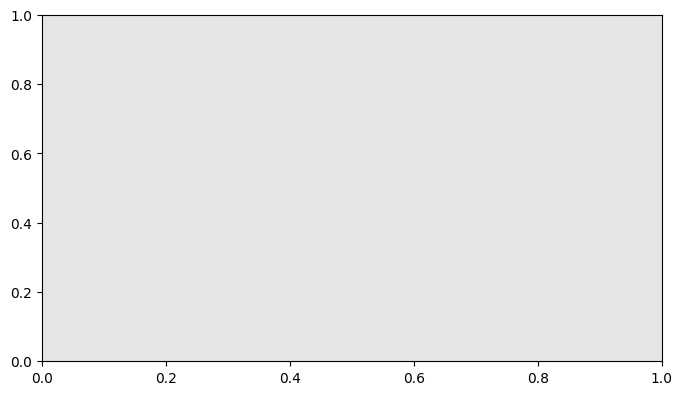

In [7]:


#%%
stimNames = ('vis1','sound1','vis2','sound2')
stimLabels = ('visual target','auditory target','visual non-target','auditory non-target')
preTrials = 5
postTrials = 20
x = np.arange(-preTrials,postTrials+1) 
for lbl in trialsDf:
    for rewardStim,blockLabel in zip(('vis1','sound1'),('visual rewarded blocks','auditory rewarded blocks')):
        fig = plt.figure(figsize=(8,4.5))
        ax = fig.add_subplot(1,1,1)
        ax.add_patch(matplotlib.patches.Rectangle([-0.5,-1],width=5,height=2,facecolor='0.5',edgecolor=None,alpha=0.2,zorder=0))
        for stim,stimLbl,clr,ls in zip(stimNames,stimLabels,'gmgm',('-','-','--','--')):
            y = []
            for m in trialsDf[lbl]:
                y.append([])
                for s in trialsDf[lbl][m]:
                    df = trialsDf[lbl][m][s]
                    trials = df.stim_name == stim
                    r = df.is_response
                    for blockInd in range(6):
                        blockTrials = df.block_index == blockInd
                        blockRewStim = 'vis1' if df[blockTrials].iloc[0]['stim_name'] == 'vis' else 'sound1'
                        if blockInd > 0 and blockRewStim == rewardStim:
                            y[-1].append(np.full(preTrials+postTrials+1,np.nan))
                            pre = r[(df.block_index==blockInd-1) & trials]
                            i = min(preTrials,pre.size)
                            y[-1][-1][preTrials-i:preTrials] = pre[-i:]
                            post = r[(df.block_index==blockInd) & trials]
                            if stim == blockRewStim:
                                i = min(postTrials,post.size)
                                y[-1][-1][preTrials:preTrials+i] = post[:i]
                            else:
                                i = min(postTrials-5,post.size)
                                y[-1][-1][preTrials+5:preTrials+5+i] = post[:i]
                y[-1] = np.nanmean(y[-1],axis=0)
            m = np.nanmean(y,axis=0)
            s = np.nanstd(y,axis=0)/(len(y)**0.5)

            ax.plot(x, m, color=clr, ls=ls, label=stimLbl)
            ax.fill_between(x, m-s, m+s, color=clr, alpha=0.2)
            x = np.arange(26)
            y = np.full_like(x, 5)  # shape (26,)
            plt.plot(x, y)

            # ax.plot(x[:preTrials],m[:preTrials],color=clr,ls=ls,label=stimLbl)
#             ax.fill_between(x[:preTrials],(m+s)[:preTrials],(m-s)[:preTrials],color=clr,alpha=0.25)
#             ax.plot(x[preTrials:],m[preTrials:],ls=ls,color=clr)
#             ax.fill_between(x[preTrials:],(m+s)[preTrials:],(m-s)[preTrials:],color=clr,alpha=0.25)
        for side in ('right','top'):
            ax.spines[side].set_visible(False)
        ax.tick_params(direction='out',top=False,right=False,labelsize=10)
        ax.set_xticks([-5,-1,5,9,14,19])
        ax.set_xticklabels([-5,-1,1,5,10,15])
        ax.set_yticks([0,0.5,1])
        ax.set_xlim([-preTrials-0.5,postTrials-0.5])
        ax.set_ylim([0,1.02])
        ax.set_xlabel('Trials of indicated type after block switch',fontsize=12)
        ax.set_ylabel('Response rate',fontsize=12)
        ax.set_title(lbl + ', ' + blockLabel,fontsize=12)
        ax.legend(bbox_to_anchor=(1,1),loc='upper left',fontsize=12)
        plt.tight_layout()




C:\Users\vayle.lafehr\AppData\Local\Temp\ipykernel_32924\4205809571.py:51: RuntimeWarning: Mean of empty slice
  y.append(np.nanmean(subj_y, axis=0))
C:\Users\vayle.lafehr\AppData\Local\Temp\ipykernel_32924\4205809571.py:54: RuntimeWarning: Mean of empty slice
  m = np.nanmean(y, axis=0)
c:\Users\vayle.lafehr\AppData\Local\anaconda3\envs\dr_analysis\Lib\site-packages\numpy\lib\nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


TypeError: Legend.__init__() got an unexpected keyword argument 'color'

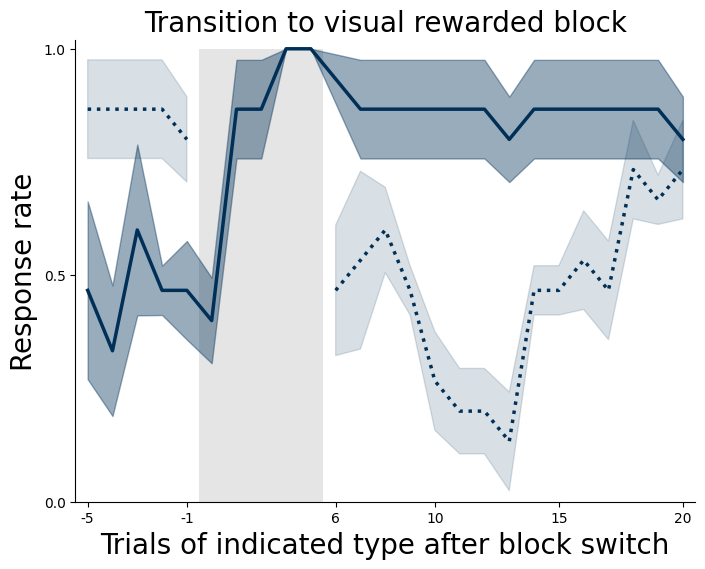

In [15]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches

save_dir = r"Z:\vayle\muscimol_ORB_behavior_plots"

stimNames = ('vis1', 'sound1', 'vis2', 'sound2')
stimLabels = ('vis target (control)', 'aud target (control)', 'vis non-target (control)', 'aud target (control)')
preTrials = 5
postTrials = 20
x = np.arange(-preTrials, postTrials + 1)  # x-axis: trials before/after block switch

for lbl in trialsDf:
    for rewardStim, blockLabel in zip(('vis1', 'sound1'), ('visual rewarded blocks', 'auditory rewarded blocks')):
        fig, ax = plt.subplots(figsize=(8, 6))
        
        # Highlight the first 5 post-switch trials
        ax.add_patch(matplotlib.patches.Rectangle(
            [-0.5, -1], width=5, height=2, facecolor='0.5', edgecolor=None, alpha=0.2, zorder=0
        ))

        for stim, stimLbl, clr, ls in zip(stimNames, stimLabels, ('#003057','#003057'), ('-', 'dotted')):
            y = []
            for m in trialsDf[lbl]:
                subj_y = []
                for s in trialsDf[lbl][m]:
                    df = trialsDf[lbl][m][s]
                    trials = df.stim_name == stim
                    r = df.is_response
                    for blockInd in range(6):
                        blockTrials = df.block_index == blockInd
                        # Determine which stimulus is rewarded in this block
                        blockRewStim = 'vis1' if df[blockTrials].iloc[0]['stim_name'] == 'vis1' else 'sound1'
                        if blockInd > 0 and blockRewStim == rewardStim:
                            arr = np.full(preTrials + postTrials + 1, np.nan)
                            # Pre-switch trials
                            pre = r[(df.block_index == blockInd - 1) & trials]
                            i = min(preTrials, pre.size)
                            arr[preTrials - i:preTrials] = pre[-i:]
                            # Post-switch trials
                            post = r[(df.block_index == blockInd) & trials]
                            if stim == blockRewStim:
                                i = min(postTrials, post.size)
                                arr[preTrials:preTrials + i] = post[:i]
                            else:
                                i = min(postTrials - 5, post.size)
                                arr[preTrials + 5:preTrials + 5 + i] = post[:i]
                            subj_y.append(arr)
                # Average across subjects
                if subj_y:
                    y.append(np.nanmean(subj_y, axis=0))
            # Average and SEM across mice
            if y:
                m = np.nanmean(y, axis=0)
                s = np.nanstd(y, axis=0) / (len(y) ** 0.5)
                    
                    # Set different alpha values based on line style
                fill_alpha = 0.4 if ls == '-' else 0.15  # Darker for solid, lighter for dotted
                    
                ax.plot(x, m, color=clr, ls=ls, label=stimLbl, linewidth=2.5)
                ax.fill_between(x, m - s, m + s, color=clr, alpha=fill_alpha)
        
        # Formatting
        for side in ('right', 'top'):
            ax.spines[side].set_visible(False)
        ax.tick_params(direction='out', top=False, right=False, labelsize=10)
        ax.set_xticks([-5, -1, 5, 9, 14, 19])
        ax.set_xticklabels([-5, -1, 6, 10, 15, 20])
        ax.set_yticks([0, 0.5, 1])
        ax.set_xlim([-preTrials - 0.5, postTrials - 0.5])
        ax.set_ylim([0, 1.02])
        ax.set_xlabel('Trials of indicated type after block switch', fontsize=20)
        ax.set_ylabel('Response rate', fontsize=20)
        ax.set_title("Transition to visual rewarded block", fontsize=20)
        ax.legend(bbox_to_anchor=(1, 1), loc='upper left', color='black', fontsize=20)
        
        plt.tight_layout()
        filename = f"figure_{lbl}_{blockLabel.replace(' ', '_')}.svg"
        # full_path = f"{save_dir}\\{filename}"
        plt.savefig(full_path)
        plt.show()

C:\Users\vayle.lafehr\AppData\Local\Temp\ipykernel_32924\1193423217.py:51: RuntimeWarning: Mean of empty slice
  y.append(np.nanmean(subj_y, axis=0))
C:\Users\vayle.lafehr\AppData\Local\Temp\ipykernel_32924\1193423217.py:54: RuntimeWarning: Mean of empty slice
  m = np.nanmean(y, axis=0)


TypeError: Legend.__init__() got an unexpected keyword argument 'color'

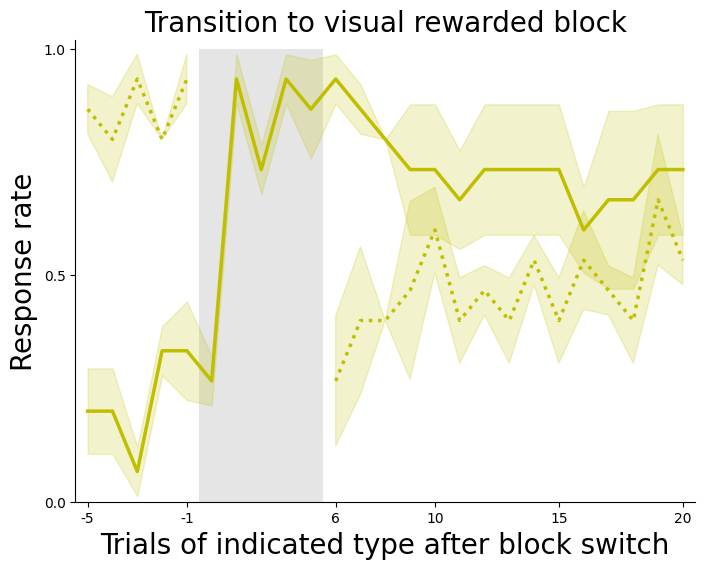

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches

save_dir = r"Z:\vayle\muscimol_ORB_behavior_plots"

stimNames = ('vis1', 'sound1', 'vis2', 'sound2')
stimLabels = ('vis target (muscimol)', 'aud target (muscimol)', 'vis non-target (control)', 'aud non-target (control)')
preTrials = 5
postTrials = 20
x = np.arange(-preTrials, postTrials + 1)  # x-axis: trials before/after block switch

for lbl in trialsDf:
    for rewardStim, blockLabel in zip(('vis1', 'sound1'), ('visual rewarded blocks', 'auditory rewarded blocks')):
        fig, ax = plt.subplots(figsize=(8, 6))
        
        # Highlight the first 5 post-switch trials
        ax.add_patch(matplotlib.patches.Rectangle(
            [-0.5, -1], width=5, height=2, facecolor='0.5', edgecolor=None, alpha=0.2, zorder=0
        ))

        for stim, stimLbl, clr, ls in zip(stimNames, stimLabels, ('y','y'), ('-', 'dotted')):
            y = []
            for m in trialsDf[lbl]:
                subj_y = []
                for s in trialsDf[lbl][m]:
                    df = trialsDf[lbl][m][s]
                    trials = df.stim_name == stim
                    r = df.is_response
                    for blockInd in range(6):
                        blockTrials = df.block_index == blockInd
                        # Determine which stimulus is rewarded in this block
                        blockRewStim = 'vis1' if df[blockTrials].iloc[0]['stim_name'] == 'vis1' else 'sound1'
                        if blockInd > 0 and blockRewStim == rewardStim:
                            arr = np.full(preTrials + postTrials + 1, np.nan)
                            # Pre-switch trials
                            pre = r[(df.block_index == blockInd - 1) & trials]
                            i = min(preTrials, pre.size)
                            arr[preTrials - i:preTrials] = pre[-i:]
                            # Post-switch trials
                            post = r[(df.block_index == blockInd) & trials]
                            if stim == blockRewStim:
                                i = min(postTrials, post.size)
                                arr[preTrials:preTrials + i] = post[:i]
                            else:
                                i = min(postTrials - 5, post.size)
                                arr[preTrials + 5:preTrials + 5 + i] = post[:i]
                            subj_y.append(arr)
                # Average across subjects
                if subj_y:
                    y.append(np.nanmean(subj_y, axis=0))
            # Average and SEM across mice
            if y:
                m = np.nanmean(y, axis=0)
                s = np.nanstd(y, axis=0) / (len(y) ** 0.5)
                ax.plot(x, m, color=clr, ls=ls, label=stimLbl, linewidth=2.5)
                ax.fill_between(x, m - s, m + s, color=clr, alpha=0.2)
        
        # Formatting
        for side in ('right', 'top'):
            ax.spines[side].set_visible(False)
        ax.tick_params(direction='out', top=False, right=False, labelsize=10)
        ax.set_xticks([-5, -1, 5, 9, 14, 19])
        ax.set_xticklabels([-5, -1, 6, 10, 15, 20])
        ax.set_yticks([0, 0.5, 1])
        ax.set_xlim([-preTrials - 0.5, postTrials - 0.5])
        ax.set_ylim([0, 1.02])
        ax.set_xlabel('Trials of indicated type after block switch', fontsize=20)
        ax.set_ylabel('Response rate', fontsize=20)
        ax.set_title("Transition to visual rewarded block", fontsize=20)
        ax.legend(bbox_to_anchor=(1, 1), loc='upper left', color='black', fontsize=20)
        plt.tight_layout()
        filename = f"figure_{lbl}_{blockLabel.replace(' ', '_')}.svg"
        # full_path = f"{save_dir}\\{filename}"
        plt.savefig(full_path)
        plt.show()

C:\Users\vayle.lafehr\AppData\Local\Temp\ipykernel_32924\1845601612.py:51: RuntimeWarning: Mean of empty slice
  y.append(np.nanmean(subj_y, axis=0))
C:\Users\vayle.lafehr\AppData\Local\Temp\ipykernel_32924\1845601612.py:54: RuntimeWarning: Mean of empty slice
  m = np.nanmean(y, axis=0)
c:\Users\vayle.lafehr\AppData\Local\anaconda3\envs\dr_analysis\Lib\site-packages\numpy\lib\nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


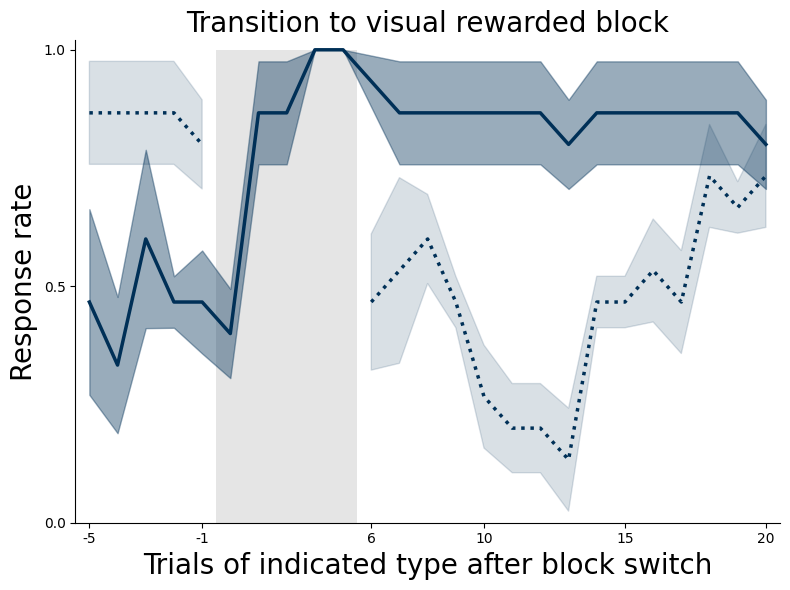

C:\Users\vayle.lafehr\AppData\Local\Temp\ipykernel_32924\1845601612.py:51: RuntimeWarning: Mean of empty slice
  y.append(np.nanmean(subj_y, axis=0))
C:\Users\vayle.lafehr\AppData\Local\Temp\ipykernel_32924\1845601612.py:54: RuntimeWarning: Mean of empty slice
  m = np.nanmean(y, axis=0)
c:\Users\vayle.lafehr\AppData\Local\anaconda3\envs\dr_analysis\Lib\site-packages\numpy\lib\nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


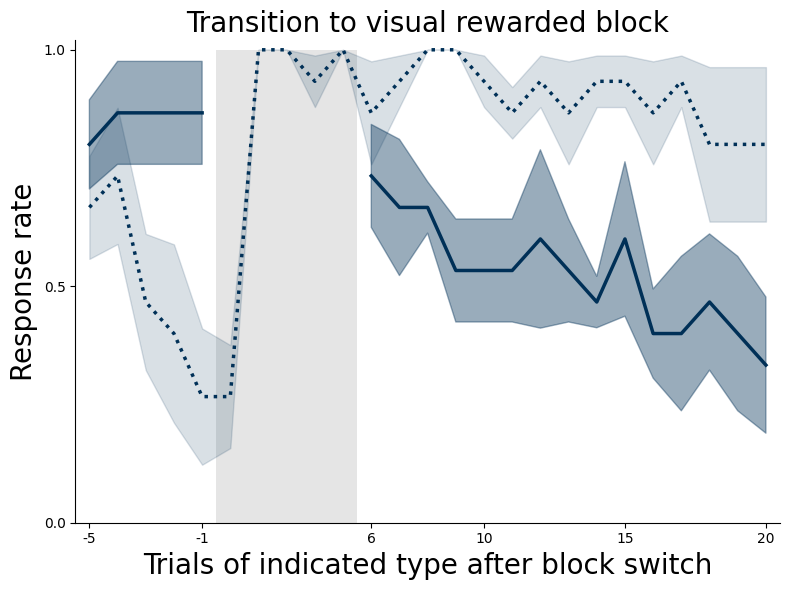

C:\Users\vayle.lafehr\AppData\Local\Temp\ipykernel_32924\1845601612.py:51: RuntimeWarning: Mean of empty slice
  y.append(np.nanmean(subj_y, axis=0))
C:\Users\vayle.lafehr\AppData\Local\Temp\ipykernel_32924\1845601612.py:54: RuntimeWarning: Mean of empty slice
  m = np.nanmean(y, axis=0)
c:\Users\vayle.lafehr\AppData\Local\anaconda3\envs\dr_analysis\Lib\site-packages\numpy\lib\nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


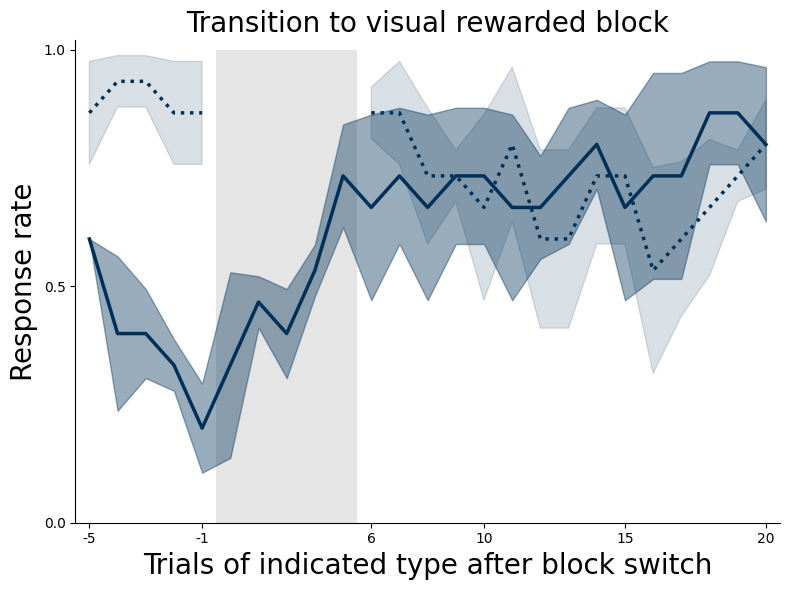

C:\Users\vayle.lafehr\AppData\Local\Temp\ipykernel_32924\1845601612.py:51: RuntimeWarning: Mean of empty slice
  y.append(np.nanmean(subj_y, axis=0))
C:\Users\vayle.lafehr\AppData\Local\Temp\ipykernel_32924\1845601612.py:54: RuntimeWarning: Mean of empty slice
  m = np.nanmean(y, axis=0)
c:\Users\vayle.lafehr\AppData\Local\anaconda3\envs\dr_analysis\Lib\site-packages\numpy\lib\nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


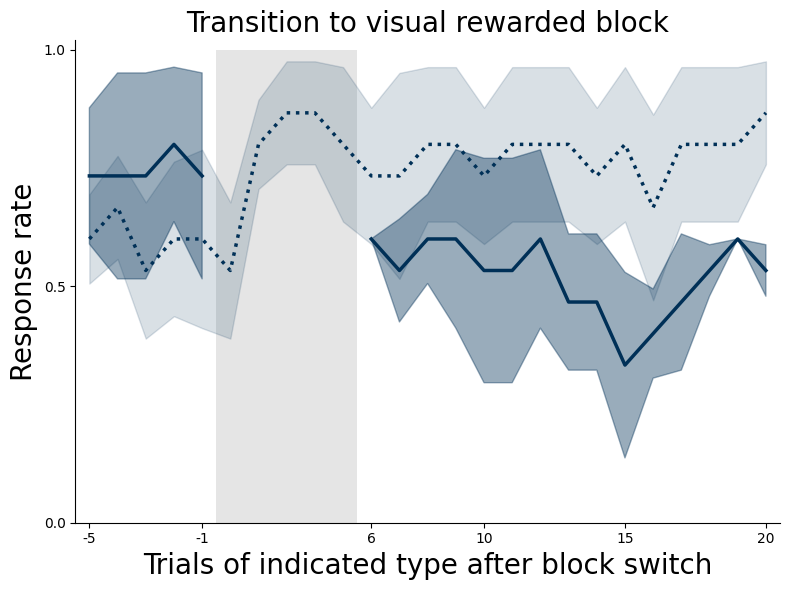

In [19]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches

save_dir = r"Z:\vayle\muscimol_ORB_behavior_plots"

stimNames = ('vis1', 'sound1', 'vis2', 'sound2')
stimLabels = ('vis target (muscimol)', 'aud target (muscimol)', 'vis non-target (control)', 'aud non-target (control)')
preTrials = 5
postTrials = 20
x = np.arange(-preTrials, postTrials + 1)  # x-axis: trials before/after block switch

for lbl in trialsDf:
    for rewardStim, blockLabel in zip(('vis1', 'sound1'), ('visual rewarded blocks', 'auditory rewarded blocks')):
        fig, ax = plt.subplots(figsize=(8, 6))
        
        # Highlight the first 5 post-switch trials
        ax.add_patch(matplotlib.patches.Rectangle(
            [-0.5, -1], width=5, height=2, facecolor='0.5', edgecolor=None, alpha=0.2, zorder=0
        ))

        for stim, stimLbl, clr, ls in zip(stimNames, stimLabels, ('#003057', '#003057'), ('-', 'dotted')):
            y = []
            for m in trialsDf[lbl]:
                subj_y = []
                for s in trialsDf[lbl][m]:
                    df = trialsDf[lbl][m][s]
                    trials = df.stim_name == stim
                    r = df.is_response
                    for blockInd in range(6):
                        blockTrials = df.block_index == blockInd
                        # Determine which stimulus is rewarded in this block
                        blockRewStim = 'vis1' if df[blockTrials].iloc[0]['stim_name'] == 'vis1' else 'sound1'
                        if blockInd > 0 and blockRewStim == rewardStim:
                            arr = np.full(preTrials + postTrials + 1, np.nan)
                            # Pre-switch trials
                            pre = r[(df.block_index == blockInd - 1) & trials]
                            i = min(preTrials, pre.size)
                            arr[preTrials - i:preTrials] = pre[-i:]
                            # Post-switch trials
                            post = r[(df.block_index == blockInd) & trials]
                            if stim == blockRewStim:
                                i = min(postTrials, post.size)
                                arr[preTrials:preTrials + i] = post[:i]
                            else:
                                i = min(postTrials - 5, post.size)
                                arr[preTrials + 5:preTrials + 5 + i] = post[:i]
                            subj_y.append(arr)
                # Average across subjects
                if subj_y:
                    y.append(np.nanmean(subj_y, axis=0))
            # Average and SEM across mice
            if y:
                m = np.nanmean(y, axis=0)
                s = np.nanstd(y, axis=0) / (len(y) ** 0.5)
                
                # Set different alpha values based on line style
                fill_alpha = 0.4 if ls == '-' else 0.15  # Darker for solid, lighter for dotted
                
                ax.plot(x, m, color=clr, ls=ls, label=stimLbl, linewidth=2.5)
                ax.fill_between(x, m - s, m + s, color=clr, alpha=fill_alpha)
        
        # Formatting
        for side in ('right', 'top'):
            ax.spines[side].set_visible(False)
        ax.tick_params(direction='out', top=False, right=False, labelsize=10)
        ax.set_xticks([-5, -1, 5, 9, 14, 19])
        ax.set_xticklabels([-5, -1, 6, 10, 15, 20])
        ax.set_yticks([0, 0.5, 1])
        ax.set_xlim([-preTrials - 0.5, postTrials - 0.5])
        ax.set_ylim([0, 1.02])
        ax.set_xlabel('Trials of indicated type after block switch', fontsize=20)
        ax.set_ylabel('Response rate', fontsize=20)
        ax.set_title("Transition to visual rewarded block", fontsize=20)
        # ax.legend(bbox_to_anchor=(1, 1), loc='upper left', fontsize=20)
        plt.tight_layout()
        filename = f"figure_{lbl}_{blockLabel.replace(' ', '_')}.svg"
        full_path = f"{save_dir}\\{filename}"
        plt.savefig(full_path)
        plt.show()

C:\Users\vayle.lafehr\AppData\Local\Temp\ipykernel_28244\2674093901.py:71: RuntimeWarning: Mean of empty slice
  y.append(np.nanmean(mouse_data, axis=0))
C:\Users\vayle.lafehr\AppData\Local\Temp\ipykernel_28244\2674093901.py:74: RuntimeWarning: Mean of empty slice
  mean_response = np.nanmean(y, axis=0)
c:\Users\vayle.lafehr\AppData\Local\anaconda3\envs\dr_analysis\Lib\site-packages\numpy\lib\nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
C:\Users\vayle.lafehr\AppData\Local\Temp\ipykernel_28244\2674093901.py:71: RuntimeWarning: Mean of empty slice
  y.append(np.nanmean(mouse_data, axis=0))
C:\Users\vayle.lafehr\AppData\Local\Temp\ipykernel_28244\2674093901.py:74: RuntimeWarning: Mean of empty slice
  mean_response = np.nanmean(y, axis=0)
c:\Users\vayle.lafehr\AppData\Local\anaconda3\envs\dr_analysis\Lib\site-packages\numpy\lib\nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.


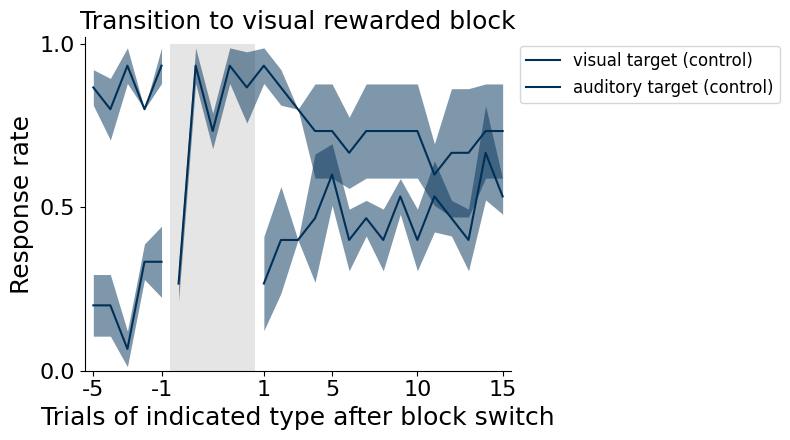

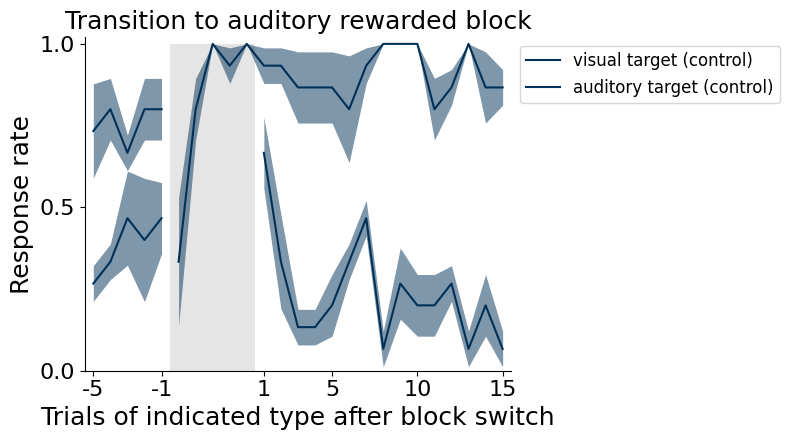

In [21]:
# %%
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches
import scipy.stats

# Define stimulus names and labels
stim_names = ('vis1', 'sound1')
stim_labels = ('visual target', 'auditory target')

# Number of trials before and after block switch
pre_trials = 5
post_trials = 20

# X-axis values: trial indices relative to block switch
x = np.arange(-pre_trials, post_trials + 1)

# Loop over rewarded stimulus types and block labels
for reward_stim, block_label in zip(('vis1', 'sound1'), ('visual rewarded block', 'auditory rewarded block')):
    fig, ax = plt.subplots(figsize=(8, 4.5))

    # Add shaded rectangle to indicate block switch period
    ax.add_patch(
        matplotlib.patches.Rectangle(
            [-0.5, -1], width=5, height=2, facecolor='0.5', edgecolor=None, alpha=0.2, zorder=0
        )
    )

    # Loop over trial conditions (e.g., control, muscimol)
    for trial_label, line_style, alpha_line, alpha_fill in zip(
        trialsDf, ('-'), (1, 0.5), (0.5, 0.25)
    ):
        # Loop over stimulus types
        for stim, stim_lbl, color in zip(stim_names, stim_labels, ('#003057', '#003057')):
            y = []
            # Loop over mice
            for mouse in trialsDf[trial_label]:
                mouse_data = []
                # Loop over sessions
                for session in trialsDf[trial_label][mouse]:
                    df = trialsDf[trial_label][mouse][session]
                    trials_mask = df.stim_name == stim
                    response_mask = df.is_response
                    # Loop over blocks
                    for block_idx in range(6):
                        block_mask = df.block_index == block_idx
                        # Determine which stimulus is rewarded in this block
                        block_rew_stim = (
                            'vis1' if df[block_mask].iloc[0]['stim_name'] == 'vis1' else 'sound1'
                        )
                        # Only analyze blocks after the first, where the rewarded stimulus matches
                        if block_idx > 0 and block_rew_stim == reward_stim:
                            trial_array = np.full(pre_trials + post_trials + 1, np.nan)
                            # Get responses for previous block (pre)
                            pre_mask = (df.block_index == block_idx - 1) & trials_mask
                            pre_responses = response_mask[pre_mask]
                            i_pre = min(pre_trials, pre_responses.size)
                            trial_array[pre_trials - i_pre : pre_trials] = pre_responses[-i_pre:]
                            # Get responses for current block (post)
                            post_mask = (df.block_index == block_idx) & trials_mask
                            post_responses = response_mask[post_mask]
                            if stim == block_rew_stim:
                                i_post = min(post_trials, post_responses.size)
                                trial_array[pre_trials : pre_trials + i_post] = post_responses[:i_post]
                            else:
                                i_post = min(post_trials - 5, post_responses.size)
                                trial_array[pre_trials + 5 : pre_trials + 5 + i_post] = post_responses[:i_post]
                            mouse_data.append(trial_array)
                # Average across sessions for this mouse
                if mouse_data:
                    y.append(np.nanmean(mouse_data, axis=0))
            # Average across mice
            if y:
                mean_response = np.nanmean(y, axis=0)
                sem_response = np.nanstd(y, axis=0) / (len(y) ** 0.5)
                # Plot pre-trials
                ax.plot(
                    x[:pre_trials], mean_response[:pre_trials], color=color, ls=line_style,
                    alpha=alpha_line, label=f"{stim_lbl} ({trial_label})"
                )
                ax.fill_between(
                    x[:pre_trials], (mean_response + sem_response)[:pre_trials],
                    (mean_response - sem_response)[:pre_trials], color=color, alpha=alpha_fill, lw=0
                )
                # Plot post-trials
                ax.plot(
                    x[pre_trials:], mean_response[pre_trials:], ls=line_style,
                    color=color, alpha=alpha_line
                )
                ax.fill_between(
                    x[pre_trials:], (mean_response + sem_response)[pre_trials:],
                    (mean_response - sem_response)[pre_trials:], color=color, alpha=alpha_fill, lw=0
                )

    # Beautify plot
    for side in ('right', 'top'):
        ax.spines[side].set_visible(False)
    ax.tick_params(direction='out', top=False, right=False, labelsize=16)
    ax.set_xticks([-5, -1, 5, 9, 14, 19])
    ax.set_xticklabels([-5, -1, 1, 5, 10, 15])
    ax.set_yticks([0, 0.5, 1])
    ax.set_xlim([-pre_trials - 0.5, post_trials - 0.5])
    ax.set_ylim([0, 1.02])
    ax.set_xlabel('Trials of indicated type after block switch', fontsize=18)
    ax.set_ylabel('Response rate', fontsize=18)
    ax.set_title(f'Transition to {block_label}', fontsize=18)
    ax.legend(bbox_to_anchor=(1, 1), loc='upper left', fontsize=12)
    plt.tight_layout()

In [23]:
# %%
def adjust_response_rate(rate, n_trials):
    """
    Adjusts response rate to avoid infinite z-scores in d-prime calculation.
    """
    if rate == 0:
        rate = 0.5 / n_trials
    elif rate == 1:
        rate = 1 - 0.5 / n_trials
    return rate

def calc_dprime(hit_rate, false_alarm_rate, n_go, n_nogo):
    """
    Calculates d-prime from hit and false alarm rates.
    """
    hr = adjust_response_rate(hit_rate, n_go)
    far = adjust_response_rate(false_alarm_rate, n_nogo)
    z_scores = [scipy.stats.norm.ppf(r) for r in (hr, far)]
    return z_scores[0] - z_scores[1]

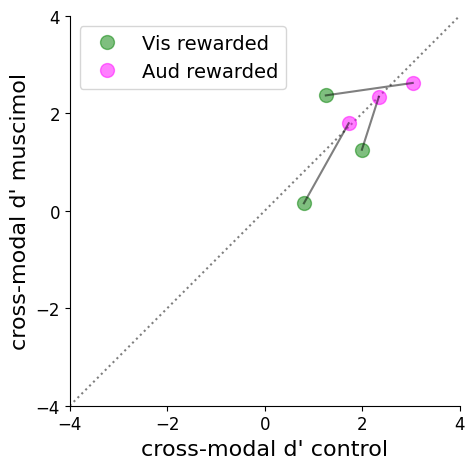

In [24]:
# %%
fig, ax = plt.subplots()
alim = (-4, 4)
ax.plot(alim, alim, 'k:', alpha=0.5)  # Diagonal reference line

for mouse_idx, mouse in enumerate(mice):
    # Store d-prime values for control and muscimol conditions
    dprime_control = [[], []]
    dprime_muscimol = [[], []]
    for dprime_list, trial_label in zip((dprime_control, dprime_muscimol), trialsDf):
        for session in trialsDf[trial_label][mouse]:
            df = trialsDf[trial_label][mouse][session]
            for i, context in enumerate(('is_vis_rewarded', 'is_aud_rewarded')):
                # Select trials in context and not reward scheduled
                context_mask = df[context] & ~df.is_reward_scheduled
                vis_mask = context_mask & df.is_vis_target
                aud_mask = context_mask & df.is_aud_target
                # Determine which is rewarded/non-rewarded
                if context == 'is_vis_rewarded':
                    rewarded_mask, nonrewarded_mask = vis_mask, aud_mask
                else:
                    rewarded_mask, nonrewarded_mask = aud_mask, vis_mask
                n_hit = df.is_response[rewarded_mask].size
                hit_rate = df.is_response[rewarded_mask].sum() / n_hit if n_hit > 0 else 0
                n_fa = df.is_response[nonrewarded_mask].size
                fa_rate = df.is_response[nonrewarded_mask].sum() / n_fa if n_fa > 0 else 0
                dprime_list[i].append(calc_dprime(hit_rate, fa_rate, n_hit, n_fa))
    # Plot mean d-prime for each context
    for i, (label, color) in enumerate(zip(('Vis rewarded', 'Aud rewarded'), ('green', 'magenta'))):
        plot_label = label if mouse_idx == 0 else None  # Only label first mouse for legend
        ax.plot(
            np.mean(dprime_control[i]), np.mean(dprime_muscimol[i]),
            'o', color=color, ms=10, alpha=0.5, label=plot_label
        )
    # Connect points for each mouse
    ax.plot(
        [np.mean(d) for d in dprime_control], [np.mean(d) for d in dprime_muscimol],
        'k-', alpha=0.5
    )

# Beautify plot
for side in ('right', 'top'):
    ax.spines[side].set_visible(False)
ax.tick_params(direction='out', top=False, right=False, labelsize=12)
ax.set_xticks(np.arange(-4, 5, 2))
ax.set_yticks(np.arange(-4, 5, 2))
ax.set_xlim(alim)
ax.set_ylim(alim)
ax.set_aspect('equal')
ax.set_xlabel("cross-modal d' control", fontsize=16)
ax.set_ylabel("cross-modal d' muscimol", fontsize=16)
ax.legend(fontsize=14)
# plt.savefig(r"Z:\vayle\muscimol_ORB_behavior_plots\crossmodal_dprime_modality_asymmetry_overview", dpi=300)
plt.tight_layout()

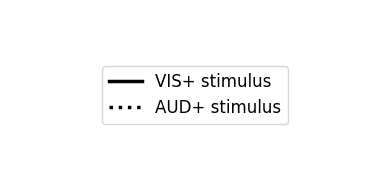

In [128]:
import matplotlib.pyplot as plt
import matplotlib.lines as mlines

# Create custom legend elements
solid_line = mlines.Line2D([], [], color='black', linestyle='-', linewidth=2.5, label='VIS+ stimulus')
dotted_line = mlines.Line2D([], [], color='black', linestyle=':', linewidth=2.5, label='AUD+ stimulus')

# Create the legend
plt.figure(figsize=(4, 2))
plt.legend(handles=[solid_line, dotted_line], loc='center', fontsize=12)
plt.axis('off')  # Hide axes
plt.tight_layout()
plt.show()

In [66]:
print(df)

      start_time    stop_time  quiescent_start_time  quiescent_stop_time  \
id                                                                         
0       3.119324     8.623887              3.119324             4.587151   
1      10.625559    16.130179             10.625559            12.093448   
2      16.547197    22.051757             16.547197            18.015055   
3      22.435421    27.956686             22.435421            23.903320   
4      28.907478    34.428766             28.907478            30.375335   
..           ...          ...                   ...                  ...   
535  3599.388301  3604.976267           3599.388301          3600.872883   
536  3606.610993  3612.132271           3606.610993          3608.078883   
537  3612.932935  3618.470871           3612.932935          3614.417487   
538  3619.271565  3624.809520           3619.271565          3620.739427   
539  3626.677713  3632.249060           3626.677713          3628.162276   

     stim_s

In [ ]:
# %%
# stimNames = ('vis1','sound1')
# stimLabels = ('visual target','auditory target')
# preTrials = 5
# postTrials = 20
# x = np.arange(-preTrials,postTrials+1) 
# for rewardStim,blockLabel in zip(('vis1','sound1'),('visual rewarded block','auditory rewarded block')):
#     fig = plt.figure(figsize=(8,4.5))
#     ax = fig.add_subplot(1,1,1)
#     ax.add_patch(matplotlib.patches.Rectangle([-0.5,-1],width=5,height=2,facecolor='0.5',edgecolor=None,alpha=0.2,zorder=0))
#     for lbl,ls,alphaLine,alphaFill in zip(trialsDf,('-','--'),(1,0.5),(0.5,0.25)):
#         for stim,stimLbl,clr in zip(stimNames,stimLabels,'gm'):
#             y = []
#             for m in trialsDf[lbl]:
#                 y.append([])
#                 for s in trialsDf[lbl][m]:
#                     df = trialsDf[lbl][m][s]
#                     trials = df.stim_name == stim
#                     r = df.is_response
#                     for blockInd in range(6):
#                         blockTrials = df.block_index == blockInd
#                         blockRewStim = 'vis1' if df[blockTrials].iloc[0]['stim_name'] == 'vis' else 'sound1'
#                         if blockInd > 0 and blockRewStim == rewardStim:
#                             y[-1].append(np.full(preTrials+postTrials+1,np.nan))
#                             pre = r[(df.block_index==blockInd-1) & trials]
#                             i = min(preTrials,pre.size)
#                             y[-1][-1][preTrials-i:preTrials] = pre[-i:]
#                             post = r[(df.block_index==blockInd) & trials]
#                             if stim == blockRewStim:
#                                 i = min(postTrials,post.size)
#                                 y[-1][-1][preTrials:preTrials+i] = post[:i]
#                             else:
#                                 i = min(postTrials-5,post.size)
#                                 y[-1][-1][preTrials+5:preTrials+5+i] = post[:i]
#                 y[-1] = np.nanmean(y[-1],axis=0)
#             m = np.nanmean(y,axis=0)
#             s = np.nanstd(y,axis=0)/(len(y)**0.5)
#             ax.plot(x[:preTrials],m[:preTrials],color=clr,ls=ls,alpha=alphaLine,label=stimLbl+' ('+lbl+')')
#             ax.fill_between(x[:preTrials],(m+s)[:preTrials],(m-s)[:preTrials],color=clr,alpha=alphaFill,lw=0)
#             ax.plot(x[preTrials:],m[preTrials:],ls=ls,color=clr,alpha=alphaLine)
#             ax.fill_between(x[preTrials:],(m+s)[preTrials:],(m-s)[preTrials:],color=clr,alpha=alphaFill,lw=0)
#     for side in ('right','top'):
#         ax.spines[side].set_visible(False)
#     ax.tick_params(direction='out',top=False,right=False,labelsize=16)
#     ax.set_xticks([-5,-1,5,9,14,19])
#     ax.set_xticklabels([-5,-1,1,5,10,15])
#     ax.set_yticks([0,0.5,1])
#     ax.set_xlim([-preTrials-0.5,postTrials-0.5])
#     ax.set_ylim([0,1.02])
#     ax.set_xlabel('Trials of indicated type after block switch',fontsize=18)
#     ax.set_ylabel('Response rate',fontsize=18)
#     ax.set_title('transition to '+blockLabel,fontsize=18)
#     ax.legend(bbox_to_anchor=(1,1),loc='upper left',fontsize=12)
#     plt.tight_layout()

# # %%
# def calcDprime(hitRate,falseAlarmRate,goTrials,nogoTrials):
#     hr = adjustResponseRate(hitRate,goTrials)
#     far = adjustResponseRate(falseAlarmRate,nogoTrials)
#     z = [scipy.stats.norm.ppf(r) for r in (hr,far)]
#     return z[0]-z[1]


# def adjustResponseRate(r,n):
#     if r == 0:
#         r = 0.5/n
#     elif r == 1:
#         r = 1 - 0.5/n
#     return r

# #%%
# fig = plt.figure()
# ax = fig.add_subplot(1,1,1)
# alim = (-4,4)
# ax.plot(alim,alim,'k:',alpha=0.5)
# for k,m in enumerate(mice):
#     x = [[],[]]
#     y = [[],[]]
#     for d,lbl in zip((x,y),trialsDf):
#         for s in trialsDf[lbl][m]:
#             df = trialsDf[lbl][m][s]
#             for i,context in enumerate(('is_vis_context','is_aud_context')):
#                 trials = df[context] & ~df.is_reward_scheduled
#                 vis,aud = (trials & df.is_vis_target,trials & df.is_aud_target)
#                 rew,nonRew = (vis,aud) if context=='is_vis_context' else (aud,vis)
#                 hn = df.is_response[rew].size
#                 hr = df.is_response[rew].sum() / hn
#                 fan = df.is_response[nonRew].size
#                 far = df.is_response[nonRew].sum() / fan
#                 d[i].append(calcDprime(hr,far,hn,fan))
#     for i,(lbl,clr) in enumerate(zip(('Vis rewarded','Aud rewarded'),('k','tab:orange'))):
#         lbl = None if k>0 else lbl
#         ax.plot(np.mean(x[i]),np.mean(y[i]),'o',color=clr,ms=10,alpha=0.5,label=lbl)
#     ax.plot([np.mean(d) for d in x],[np.mean(d) for d in y],'k-',alpha=0.5)
# for side in ('right','top'):
#     ax.spines[side].set_visible(False)
# ax.tick_params(direction='out',top=False,right=False,labelsize=12)
# ax.set_xticks(np.arange(-4,5,2))
# ax.set_yticks(np.arange(-4,5,2))
# ax.set_xlim(alim)
# ax.set_ylim(alim)
# ax.set_aspect('equal')
# ax.set_xlabel('d\' control', fontsize=16)
# ax.set_ylabel('d\' muscimol',fontsize=16)
# ax.legend(fontsize=14)
# plt.tight_layout()


In [ ]:
blockRewStim = 'vis1' if df[blockTrials].iloc[0]['stim_name'] == 'vis' else 'sound1'

TypeError: 'blockRewStim' is an invalid keyword argument for print()

In [4]:
import npc_sessions
import pandas as pd
import polars as pl

session_ids = [
    '728053_2024-11-18','728053_2024-11-19', '728053_2024-11-20', '728053_2024-11-21','774470_2025-07-29','774470_2025-07-30','782106_2025-07-07','782106_2025-07-14','782106_2025-07-08', '782106_2025-07-15','767405_2025-05-19','767405_2025-05-20', '767405_2025-05-28', '767405_2025-05-29','739828_2025-02-10','739828_2025-02-11','739828_2025-02-17', '739828_2025-02-18','774916_2025-03-24', '774916_2025-03-25', '774916_2025-03-31', '774916_2025-04-01', '772657_2025-02-24', '772657_2025-02-25', '772657_2025-03-03', '772657_2025-03-04']

control = ['728053_2024-11-18', '728053_2024-11-20','774470_2025-07-29','782106_2025-07-07','782106_2025-07-14','767405_2025-05-28','767405_2025-05-19','739828_2025-02-10','739828_2025-02-17','772657_2025-02-24', '772657_2025-03-03', '774916_2025-03-24', '774916_2025-03-31']
muscimol = ['728053_2024-11-19', '728053_2024-11-21','774470_2025-07-30','782106_2025-07-08', '782106_2025-07-15','767405_2025-05-29','767405_2025-05-20','739828_2025-02-11','739828_2025-02-18', '772657_2025-02-25', '772657_2025-03-04','774916_2025-03-25', '774916_2025-04-01']

trials = []
for session_id in session_ids:
    session = npc_sessions.Session(session_id)
    t = session.trials[:]
    t['session_id'] = session_id
    trials.append(pl.DataFrame(t))
(
    pl.concat(trials)
    .rename({'sesion_id': 'session_id'}, strict=False)
    .with_columns(
        (pl.col("rewarded_modality").first() == "aud")
        .over("session_id")
        .alias("is_first_block_aud"),
        pl.col('session_id').str.split('_').list.get(0).alias('subject_id'),
        pl.col('session_id').is_in(control).alias('is_control'),
    )
    .write_parquet('vayle_muscimol.parquet')
)
 

In [2]:
import vl_convert as vlc

In [ ]:
import altair as alt

df = (
    pl.read_parquet("vayle_muscimol.parquet")        
)

next_rew_df = (
    df.unique(['session_id', 'block_index']).sort('block_index').group_by('session_id', maintain_order=True).agg('block_index', 'rewarded_modality')
    .with_columns(
        pl.col('rewarded_modality').list.shift(1).alias('prev_rewarded_modality'),
        pl.col('rewarded_modality').list.shift(-1).alias('next_rewarded_modality'),
    )
    .explode('block_index', 'prev_rewarded_modality', 'next_rewarded_modality')
    .drop('rewarded_modality')
)

# - vis block to vis block transitions
#   - vis target, unrewarded -> vis target rewarded, after all autorewards or on second autoreward
#
trial_to_use = 1 # second autoreward
to_vis_rew_df = (
    df
    .join(next_rew_df, on=['session_id', 'block_index'])
    .filter(
        pl.col('is_vis_target'),
    )
    .with_columns(
        (pl.col('trial_index_in_block') == pl.col('trial_index_in_block').max()).over('session_id', 'block_index').alias('is_last_trial_in_block'),
        (pl.col('trial_index_in_block') == trial_to_use).over('session_id', 'block_index').alias('is_first_trial_in_block'),
    )
    .with_columns(
        pl.when(pl.col('is_last_trial_in_block') & pl.col('is_aud_rewarded') & pl.col('next_rewarded_modality').eq('aud'))
        .then(-1)
        .when(pl.col('is_first_trial_in_block') & pl.col('is_vis_rewarded') & pl.col('prev_rewarded_modality').eq('vis'))
        .then(1)
        .otherwise(None)
        .alias('trial')
    )
    .drop_nulls('trial')
    .with_columns(
        pl.col('is_response').sum().over('session_id', 'trial').alias('n_responses'),
        pl.col('is_vis_target').len().over('session_id', 'trial').alias('n_trials'),
        (pl.col('is_response').sum() / pl.col('is_vis_target').len()).over('session_id', 'trial').alias('response probability')
    )
    # .select('trial', 'is_control', 'session_id', 'is_response', 'trial_index_in_block', 'n_trials', 'block_index', 'response probability')
    .sort('session_id')
    .group_by('subject_id', 'trial', 'is_control')
    .agg(
        pl.col('response probability').mean(),
    )
) 
lines = alt.Chart(to_vis_rew_df, width=80, height=150).mark_line(point=True).encode(
    x='trial:N',
    y='mean(response probability):Q',
    color='is_control:N'
)
dots = alt.Chart(to_vis_rew_df).mark_point(filled=True, size=50).encode(
    x=alt.X('trial:N', title={'Target trials relative','to context change'}),
    y=alt.Y('mean(response probability):Q', title='vis target response probability'),  
    color=alt.Color('is_control:N').scale(range=[ "#C4C418", '#003057'])
)
error = alt.Chart(to_vis_rew_df).mark_errorbar(color="#C41818").encode(
    x=alt.X('trial:N', title={'Target trials relative','to context change'}),
    y=alt.Y('mean(response probability):Q', title='vis target response probability'),  
    detail=alt.Color('is_control:N'),
)
chart = (error + lines + dots).properties(title='aud → vis')
chart.save('aud_to_vis_transition_vis_target_response_probability.html')
# chart.save('aud_to_vis_transition_vis_target_response_probability.svg')
# chart.save('aud_to_vis_transition_vis_target_response_probability.pdf')
chart

alt.LayerChart(...)

In [151]:
import altair as alt

df = (
    pl.read_parquet("vayle_muscimol.parquet")        
)

next_rew_df = (
    df.unique(['session_id', 'block_index']).sort('block_index').group_by('session_id', maintain_order=True).agg('block_index', 'rewarded_modality')
    .with_columns(
        pl.col('rewarded_modality').list.shift(1).alias('prev_rewarded_modality'),
        pl.col('rewarded_modality').list.shift(-1).alias('next_rewarded_modality'),
    )
    .explode('block_index', 'prev_rewarded_modality', 'next_rewarded_modality')
    .drop('rewarded_modality')
)

# - vis block to aud block transitions
#   - aud target, unrewarded -> aud target rewarded, after all autorewards or on second autoreward
#
trial_to_use = 1 # second autoreward
to_aud_rew_df = (
    df
    .join(next_rew_df, on=['session_id', 'block_index'])
    .filter(
        pl.col('is_aud_target'),
    )
    .with_columns(
        (pl.col('trial_index_in_block') == pl.col('trial_index_in_block').max()).over('session_id', 'block_index').alias('is_last_trial_in_block'),
        (pl.col('trial_index_in_block') == trial_to_use).over('session_id', 'block_index').alias('is_first_trial_in_block'),
    )
    .with_columns(
        pl.when(pl.col('is_last_trial_in_block') & pl.col('is_vis_rewarded') & pl.col('next_rewarded_modality').eq('vis'))
        .then(-1)
        .when(pl.col('is_first_trial_in_block') & pl.col('is_aud_rewarded') & pl.col('prev_rewarded_modality').eq('aud'))
        .then(1)
        .otherwise(None)
        .alias('trial')
    )
    .drop_nulls('trial')
    .with_columns(
        pl.col('is_response').sum().over('session_id', 'trial').alias('n_responses'),
        pl.col('is_aud_target').len().over('session_id', 'trial').alias('n_trials'),
        (pl.col('is_response').sum() / pl.col('is_aud_target').len()).over('session_id', 'trial').alias('response probability')
    )
    .sort('session_id')
    .group_by('subject_id', 'trial', 'is_control')
    .agg(
        pl.col('response probability').mean(),
    )
) 

lines = alt.Chart(to_aud_rew_df, width=80, height=150).mark_line(point=True).encode(
    x='trial:N',
    y='mean(response probability):Q',
    color='is_control:N'
)
dots = alt.Chart(to_aud_rew_df).mark_point(filled=True, size=50).encode(
    x=alt.X('trial:N', title={'Target trials relative','to context change'}),
    y=alt.Y('mean(response probability):Q', title='aud target response probability'),  
    color=alt.Color('is_control:N').scale(range=[ "#C4C418", '#003057'])
)
error = alt.Chart(to_aud_rew_df).mark_errorbar(color="#C41818").encode(
    x=alt.X('trial:N', title={'Target trials relative','to context change'}),
    y=alt.Y('mean(response probability):Q', title='aud target response probability'),  
    detail=alt.Color('is_control:N'),
)
chart = (error + lines + dots).properties(title='vis → aud')
chart.save('vis_to_aud_transition_aud_target_response_probability.html')
chart

alt.LayerChart(...)

In [4]:

import vl_convert as vlc

ModuleNotFoundError: No module named 'vl_convert'

In [7]:
import altair as alt

df = (
    pl.read_parquet("vayle_muscimol.parquet")        
)

next_rew_df = (
    df.unique(['session_id', 'block_index']).sort('block_index').group_by('session_id', maintain_order=True).agg('block_index', 'rewarded_modality')
    .with_columns(
        pl.col('rewarded_modality').list.shift(1).alias('prev_rewarded_modality'),
        pl.col('rewarded_modality').list.shift(-1).alias('next_rewarded_modality'),
    )
    .explode('block_index', 'prev_rewarded_modality', 'next_rewarded_modality')
    .drop('rewarded_modality')
)

# - vis block to aud block transitions
#   - aud target, unrewarded -> aud target rewarded
#
trial_to_use = 1 # second autoreward
to_aud_rew_df = (
    df
    .join(next_rew_df, on=['session_id', 'block_index'])
    .filter(
        pl.col('is_aud_target'),
    )
    .with_columns(
        (pl.col('trial_index_in_block') == pl.col('trial_index_in_block').max()).over('session_id', 'block_index').alias('is_last_trial_in_block'),
        (pl.col('trial_index_in_block') == trial_to_use).over('session_id', 'block_index').alias('is_first_trial_in_block'),
    )
    .with_columns(
        pl.when(pl.col('is_last_trial_in_block') & pl.col('is_vis_rewarded') & pl.col('next_rewarded_modality').eq('aud'))
        .then(-1)
        .when(pl.col('is_first_trial_in_block') & pl.col('is_aud_rewarded') & pl.col('prev_rewarded_modality').eq('vis'))
        .then(1)
        .otherwise(None)
        .alias('trial')
    )
    .drop_nulls('trial')
    .with_columns(
        pl.col('is_response').sum().over('session_id', 'trial').alias('n_responses'),
        pl.col('is_aud_target').len().over('session_id', 'trial').alias('n_trials'),
        (pl.col('is_response').sum() / pl.col('is_aud_target').len()).over('session_id', 'trial').alias('response probability')
    )
    .sort('session_id')
    .group_by('subject_id', 'trial', 'is_control')
    .agg(
        pl.col('response probability').mean(),
    )
) 

lines = alt.Chart(to_aud_rew_df, width=80, height=150).mark_line(point=True).encode(
    x='trial:N',
    y='mean(response probability):Q',
    color='is_control:N'
)
dots = alt.Chart(to_aud_rew_df).mark_point(filled=True, size=50).encode(
    x=alt.X('trial:N', title={'Target trials relative to context change'}),
    y=alt.Y('mean(response probability):Q', title='aud target response probability'),  
    color=alt.Color('is_control:N').scale(range=[ "#C4C418", '#003057'])
)
error = alt.Chart(to_aud_rew_df).mark_errorbar(color="#C41818").encode(
    x=alt.X('trial:N', title={'Target trials relative','to context change'}),
    y=alt.Y('mean(response probability):Q', title='aud target response probability'),  
    detail=alt.Color('is_control:N'),
)
chart = (error + lines + dots).properties(title='vis → aud')
chart.save('vis_to_aud_transition_aud_target_response_probability.html')
chart.save('aud_to_vis_transition_vis_target_response_probability.svg')
chart.save(r'C:\Users\vayle.lafehr\Downloads\vis_to_aud_transition_aud_target_response_probability.svg')
chart

alt.LayerChart(...)

In [8]:
import altair as alt

df = (
    pl.read_parquet("vayle_muscimol.parquet")        
)

next_rew_df = (
    df.unique(['session_id', 'block_index']).sort('block_index').group_by('session_id', maintain_order=True).agg('block_index', 'rewarded_modality')
    .with_columns(
        pl.col('rewarded_modality').list.shift(1).alias('prev_rewarded_modality'),
        pl.col('rewarded_modality').list.shift(-1).alias('next_rewarded_modality'),
    )
    .explode('block_index', 'prev_rewarded_modality', 'next_rewarded_modality')
    .drop('rewarded_modality')
)

# - vis block to aud block transitions
#   - vis target, rewarded -> vis target unrewarded
#
trial_to_use = 6 # second autoreward
to_aud_rew_df = (
    df
    .join(next_rew_df, on=['session_id', 'block_index'])
    .filter(
        pl.col('is_vis_target'),
    )
    .with_columns(
        (pl.col('trial_index_in_block') == pl.col('trial_index_in_block').max()).over('session_id', 'block_index').alias('is_last_trial_in_block'),
        (pl.col('trial_index_in_block') == trial_to_use).over('session_id', 'block_index').alias('is_first_trial_in_block'),
    )
    .with_columns(
        pl.when(pl.col('is_last_trial_in_block') & pl.col('is_vis_rewarded') & pl.col('next_rewarded_modality').eq('aud'))
        .then(-1)
        .when(pl.col('is_first_trial_in_block') & pl.col('is_aud_rewarded') & pl.col('prev_rewarded_modality').eq('vis'))
        .then(1)
        .otherwise(None)
        .alias('trial')
    )
    .drop_nulls('trial')
    .with_columns(
        pl.col('is_response').sum().over('session_id', 'trial').alias('n_responses'),
        pl.col('is_vis_target').len().over('session_id', 'trial').alias('n_trials'),
        (pl.col('is_response').sum() / pl.col('is_vis_target').len()).over('session_id', 'trial').alias('response probability')
    )
    .sort('session_id')
    .group_by('subject_id', 'trial', 'is_control')
    .agg(
        pl.col('response probability').mean(),
    )
) 

lines = alt.Chart(to_aud_rew_df, width=80, height=150).mark_line(point=True).encode(
    x='trial:N',
    y='mean(response probability):Q',
    color='is_control:N'
)
dots = alt.Chart(to_aud_rew_df).mark_point(filled=True, size=50).encode(
    x=alt.X('trial:N', title='Target trials relative to context change'),
    y=alt.Y('mean(response probability):Q', title='vis target response probability'),  
    color=alt.Color('is_control:N').scale(range=[ "#C4C418", '#003057'])
)
error = alt.Chart(to_aud_rew_df).mark_errorbar(color="#C41818").encode(
    x=alt.X('trial:N', title='Target trials relative to context change'),
    y=alt.Y('mean(response probability):Q', title='vis target response probability'),  
    detail=alt.Color('is_control:N'),
)
chart = (error + lines + dots).properties(title='vis → aud ')
chart.save('vis_to_aud_transition_vis_target_response_probability.html')
chart.save('aud_to_vis_transition_vis_target_response_probability.svg')
chart.save(r'C:\Users\vayle.lafehr\Downloads\vis_to_aud_transition_vis_target_response_probability.svg')
chart

alt.LayerChart(...)

In [157]:
import altair as alt

df = (
    pl.read_parquet("vayle_muscimol.parquet")        
)

next_rew_df = (
    df.unique(['session_id', 'block_index']).sort('block_index').group_by('session_id', maintain_order=True).agg('block_index', 'rewarded_modality')
    .with_columns(
        pl.col('rewarded_modality').list.shift(1).alias('prev_rewarded_modality'),
        pl.col('rewarded_modality').list.shift(-1).alias('next_rewarded_modality'),
    )
    .explode('block_index', 'prev_rewarded_modality', 'next_rewarded_modality')
    .drop('rewarded_modality')
)

# - vis block to aud block transitions
#   - vis target, rewarded -> vis target unrewarded
#
trial_to_use = 1 # second autoreward
to_aud_rew_df = (
    df
    .join(next_rew_df, on=['session_id', 'block_index'])
    .filter(
        pl.col('is_vis_target'),
    )
    .with_columns(
        (pl.col('trial_index_in_block') == pl.col('trial_index_in_block').max()).over('session_id', 'block_index').alias('is_last_trial_in_block'),
        (pl.col('trial_index_in_block') == trial_to_use).over('session_id', 'block_index').alias('is_first_trial_in_block'),
    )
    .with_columns(
        pl.when(pl.col('is_last_trial_in_block') & pl.col('is_vis_rewarded') & pl.col('next_rewarded_modality').eq('aud'))
        .then(-1)
        .when(pl.col('is_first_trial_in_block') & pl.col('is_aud_rewarded') & pl.col('prev_rewarded_modality').eq('vis'))
        .then(1)
        .otherwise(None)
        .alias('trial')
    )
    .drop_nulls('trial')
    .with_columns(
        pl.col('is_response').sum().over('session_id', 'trial').alias('n_responses'),
        pl.col('is_vis_target').len().over('session_id', 'trial').alias('n_trials'),
        (pl.col('is_response').sum() / pl.col('is_vis_target').len()).over('session_id', 'trial').alias('response probability')
    )
    .sort('session_id')
    .group_by('subject_id', 'trial', 'is_control')
    .agg(
        pl.col('response probability').mean(),
    )
) 

lines = alt.Chart(to_aud_rew_df, width=80, height=150).mark_line().encode(
    x='trial:N',
    y='mean(response probability):Q',
    color='is_control:N'
)
dots = alt.Chart(to_aud_rew_df).mark_point(filled=True, size=50).encode(
    x=alt.X('trial:N', title='Target trials relative to context change'),
    y=alt.Y('mean(response probability):Q', title='vis target response probability'),  
    color=alt.Color('is_control:N').scale(range=[ "#C4C418", '#003057'])
)
error = alt.Chart(to_aud_rew_df).mark_errorbar().encode(
    x=alt.X('trial:N', title='Target trials relative to context change'),
    y=alt.Y('mean(response probability):Q', title='vis target response probability'),  
    detail=alt.Color('is_control:N'),
)
chart = (error + lines + dots).properties(title='vis → aud (vis target)')
chart.save('vis_to_aud_transition_vis_target_response_probability.html')
chart

alt.LayerChart(...)